# Using this one to BEAUTIFY PLOTS

For now, eliminate pretor window and just go up until first tornado report.

In [1]:
from case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
from cartopy import crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import seaborn.objects as so
from scipy import stats
from scipy.stats import permutation_test
import warnings
warnings.filterwarnings("ignore")
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrow
from matplotlib.patches import Patch

# Functions

In [3]:
def hodo_plot(u_list, v_list, heights, component_range, title, color_list, label_list, lower_limit, upper_limit, legend_position, figsizex, figsizey):
    '''
    component_range = single number, how far you want the hodograph plot to extent in m/s
    colors = list of strings of desired colors for hodograph, amount of colors must be = to # of boundary intervals
    '''
    
    from matplotlib import rcParams, rcParamsDefault
    import matplotlib.patheffects as pe
    rcParams.update(rcParamsDefault)
    fig, ax = plt.subplots(1, 1, figsize=(figsizex, figsizey))
    hodo = metpy.plots.Hodograph(ax, component_range=component_range)
    hodo.add_grid(increment=5)
    ax.set_xlim(-upper_limit, lower_limit)  # Only negative x values
    ax.set_ylim(-lower_limit, upper_limit)     
    for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
        x = speed / np.sqrt(2)
        y = speed / np.sqrt(2)
        ax.text(-x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')
    
    #colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
    boundaries = [50, 500, 1000, 1500, 2000]
    
    for u, v, color, label in zip(u_list, v_list, color_list, label_list):
        h = hodo.plot_colormapped(u, v, heights, color= color, label=label, linewidth=3)
    # hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
    # hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
    # hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])
    
    #ax.scatter(0,0, 'ko')
    ax.set_xlabel('Average U-component Wind (m/s)', fontsize=13)
    ax.set_ylabel('Average V-component Wind (m/s)', fontsize=13)
    ax.set_title(f'{title}', fontsize=13,fontweight='bold', wrap=True)

    for u,v,color in zip(u_list, v_list, color_list):
        
        #for i,z in zip([0, 0.5, 1, 2], enumerate([0,45,95,195])):
        for i,z in zip([0, 0.5, 1, 2], [0,45,95,195]):
            try:
                if np.isnan(u[z]):
                    pass
                else:
                    circle = plt.Circle((u[z], v[z]), radius=0.7,color=color,zorder=30, alpha=0.5)
                    ax.add_patch(circle)
                    label = ax.annotate(i, xy=(u[z], v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold", path_effects=[pe.withStroke(linewidth=3, foreground='black')])
            # path_effects lets you put an outline around your text
            except: pass
    
    #ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
    #plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
    
    plt.plot(0,0, 'x', markersize = 20, label = 'Observed Storm Motion', color = 'black', markeredgewidth = 3)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(loc=legend_position, fontsize=13)
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/{title}', bbox_inches='tight')
    plt.show()

Why not just make a nf ff column instead of pretor_nf, pretor_ff, etc... I think I'm dumb for only just thinking of that...

In [4]:
import pandas as pd
import numpy as np

#def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, tor_time):

def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, angle2, tor_time):
    '''
    angle2 = angle above 0 degrees that you want to be greater than (upper right quadrant)
    '''
    df_tor = pd.DataFrame()
    df_nontor = pd.DataFrame()
    df_all_tor = pd.DataFrame()
    df_all_nontor = pd.DataFrame()
    
    try:
        print(csv_name)
        df = pd.read_csv(csv_name)
        print(f'CSV size: {np.shape(df)}')

        # Filter data based on distance and angle
        nf = df[(df['Distance'] <= nf_dist) & ((df['Angle'] <= angle1) & (df['Angle'] >= angle0) | (df['Angle'] >= angle2))]
        ff = df[(df['Distance'] > ff_dist) & ((df['Angle'] <= angle1) & (df['Angle'] >= angle0) | (df['Angle'] >= angle2))]

        inflow = df[((df['Angle'] <= angle1) & (df['Angle'] >= angle0) | (df['Angle'] >= angle2))]
        # Check if the dataset contains tornadic cases
        if df['Time From Tor (min)'].ne('nontor').any():
            # nf AND ff
            tor = inflow
            pretor = inflow[inflow['Time From Tor (min)'] < tor_time]
            dtor = inflow[inflow['Time From Tor (min)'] == tor_time]
            posttor = inflow[inflow['Time From Tor (min)'] > tor_time]

            #nf
            tor_nf = nf
            pretor_nf = nf[nf['Time From Tor (min)'] < tor_time]
            dtor_nf = nf[nf['Time From Tor (min)'] == tor_time]
            posttor_nf = nf[nf['Time From Tor (min)'] > tor_time]

            # ff
            tor_ff = ff
            pretor_ff = ff[ff['Time From Tor (min)'] < tor_time]
            dtor_ff = ff[ff['Time From Tor (min)'] == tor_time]
            posttor_ff = ff[ff['Time From Tor (min)'] > tor_time]

            tor_inflow = [tor, pretor, dtor, posttor]
            inflow_labels = ['tor', 'pretor', 'dtor', 'posttor']
            tor_seg = [tor_nf, pretor_nf, dtor_nf, posttor_nf, tor_ff, pretor_ff, dtor_ff, posttor_ff]
            labels = ['tor nf','pretor nf', 'dtor nf', 'posttor nf', 'tor ff', 'pretor ff', 'dtor ff', 'posttor ff']

            # tor_inflow = [pretor, dtor, posttor]
            # inflow_labels = ['pretor', 'dtor', 'posttor']
            # tor_seg = [pretor_nf, dtor_nf, posttor_nf, tor_ff, pretor_ff, dtor_ff, posttor_ff]
            # labels = ['pretor nf', 'dtor nf', 'posttor nf', 'pretor ff', 'dtor ff', 'posttor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for infl, torall in zip(tor_inflow, inflow_labels):
                    seg = infl[infl['u or v'] == wind]
                    seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                    
                    df_temp = pd.DataFrame(seg_avg).T
                    df_temp['label'] = torall
                    df_temp['wind'] = wind
                    df_temp['date'] = dates

                    df_tor = pd.concat([df_tor, df_temp], ignore_index=True)
                    
                    for tor, lab in zip(tor_seg, labels):
                        seg = tor[tor['u or v'] == wind]
                        seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                        
                        df_temp = pd.DataFrame(seg_avg).T
                        df_temp['label'] = lab
                        df_temp['wind'] = wind
                        df_temp['date'] = dates
                        #df_temp['ka'] = kas
                        
                        df_all_tor = pd.concat([df_all_tor, df_temp], ignore_index=True)

        # Check if the dataset contains nontornadic cases
        if df['Time From Tor (min)'].eq('nontor').any():

            nontor = inflow
            nf_nt = df[(df['Distance'] <= nf_dist) & (df['Angle'] <= angle1)]
            ff_nt = df[(df['Distance'] > ff_dist) & (df['Angle'] <= angle1)]

            nontor_inflow = [nontor]
            nt_lab = ['nontor']
            nontor_seg = [nf_nt, ff_nt]
            nontor_labels = ['nontor nf', 'nontor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for nt, ntlabel in zip(nontor_inflow, nt_lab):
                    ntseg = nt[nt['u or v'] == wind]
                    ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)

                    df_temp = pd.DataFrame(ntseg_avg).T
                    df_temp['label'] = nt_lab
                    df_temp['wind'] = wind
                    df_temp['date'] = dates
                    df_nontor = pd.concat([df_nontor, df_temp], ignore_index=True)
                    
                    for nontor, nonlab in zip(nontor_seg, nontor_labels):
                        ntseg = nontor[nontor['u or v'] == wind]
                        ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)
    
                        df_temp = pd.DataFrame(ntseg_avg).T
                        df_temp['label'] = nonlab
                        df_temp['wind'] = wind
                        df_temp['date'] = dates
                        #df_temp['ka'] = kas
    
                        df_all_nontor = pd.concat([df_all_nontor, df_temp], ignore_index=True)

    except FileNotFoundError:
        print(f"File not found: {csv_name}")
        pass

    return df_tor, df_nontor, df_all_tor, df_all_nontor

In [5]:
def averaging_u_and_v(comp_tor_all, comp_nontor_all):

    # tor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)
    # tor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)

    # tor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    # tor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    
    pretor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    pretor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    
    dtor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    dtor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    
    posttor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    posttor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    
    pretor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    pretor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    
    dtor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    dtor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    
    posttor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)
    posttor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)

    nontor_u_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    nontor_v_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    
    nontor_u_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)
    nontor_v_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)

    tor_u_nf = np.nanmean([pretor_u_nf, dtor_u_nf, posttor_u_nf], axis=0)
    tor_v_nf = np.nanmean([pretor_v_nf, dtor_v_nf, posttor_v_nf], axis=0)

    tor_u_ff = np.nanmean([pretor_u_ff, dtor_u_ff, posttor_u_ff], axis=0)
    tor_v_ff = np.nanmean([pretor_v_ff, dtor_v_ff, posttor_v_ff], axis=0)
                          
    
    return locals()

In [6]:
def averaging_u_and_v_nodist(comp_tor_all, comp_nontor_all):

    # tor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)
    # tor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)

    # tor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    # tor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    
    nontor_u = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor')].iloc[:, :196], axis=0)
    nontor_v = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor')].iloc[:, :196], axis=0)

    tor_u = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor')].iloc[:, :196], axis=0)
    tor_v = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor')].iloc[:, :196], axis=0)
    
    return locals()

In [7]:
def kde_plot(df, col, hue, figsize, title, color_tor, color_nontor, tor_mean, nontor_mean, tor_CI, nontor_CI):
    
    fig, ax = plt.subplots(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, ax=ax)
    
    torpltCI = ax.axvspan(tor_CI[0], tor_CI[1], color=color_tor, alpha=0.2, label='Tor 95% CI')
    nontorpltCI = ax.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label='Nontor 95% CI')
    torline = ax.axvline(tor_mean, color=color_tor, label='Mean Tor')
    nontorline = ax.axvline(nontor_mean, color=color_nontor, label='Mean Nontor')
    handles, labels = ax.get_legend_handles_labels()
    #ax.legend(handles=handles, labels=labels)
    ax.grid(True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [8]:
def kde_plot_plus(df, col, hue, figsize, title, colors, means, CIs):
    
    fig, ax = plt.subplots(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, ax=ax)

    for c, m, ci in zip(colors, means, CIs):
        torpltCI = ax.axvspan(ci[0], ci[1], color=c, alpha=0.2, label='Tor 95% CI')
        #nontorpltCI = ax.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label='Nontor 95% CI')
        torline = ax.axvline(m, color=c, label='Mean Tor')
        #nontorline = ax.axvline(nontor_mean, color=color_nontor, label='Mean Nontor')
        handles, labels = ax.get_legend_handles_labels()
        #ax.legend(handles=handles, labels=labels)
    ax.grid(True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [9]:
very_dark_red = "#4B0000"

# Dates

In [10]:
#dates = ['20220523', '20220524', '20220531','20230524', '20230527', '20230609','20230611', '20230612', '20240502', '20240504', '20240519', '20240523', '20240602']

# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240502', '20240504', '20240506',
#           '20240523', '20240528']
# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
#           '20240523', '20240528', '20240602']
# GETTING RID OF 20240504 AND 20240502 BECAUSE IT WAS TOO HIGH (TOO LOW), STRANGE OUTLIER AND 20240528
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240506', '20240519'
          '20240523', '20240528', '20240602']
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)

# VADs scan data (heights, ranges, etc)

In [ ]:
r = pyart.io.read('/Volumes/Buhrman_4TB/dealiased_data/LIFT24/20240519/ka1/Ka1240519220312.nc')

In [ ]:
np.shape(r.range['data'])

# Not composited u and v

In [ ]:
df_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        try:
            date = pd.DataFrame()
            not_comp_file_name = f'case_dfs/new/{d}_uv_{ka}_all.csv'
            print(not_comp_file_name)
            df = pd.read_csv(not_comp_file_name)
            print(np.shape(df))
            df['Date'] = d
            
            if df['Time From Tor (min)'].eq('nontor').any():
                df['Tor or Nontor'] = 'nontor'
            else:
                df['Tor or Nontor'] = 'tor'
            
            df_all = pd.concat([df_all, df], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name}")
            continue

In [11]:
def tor_id_new_time(ka_df, storm_event_data, event_type, tornado_location, timezone, daylight_savings):
    '''
    This function uses .csv from NOAA's Storm Events Database to compare 
    the times VADs were taken with when the tornado was reported.

    ka_df = dataframe you want the tor ids to be added to
    date = date the data from the storm event database was recorded (MMDDYYYY)
    event_type = is typically 'Tornado' but for posterity left it as a variable
    storm_event_data = csv from the storm event database
    tornado_location = str of the desired location name IN ALL CAPS
    timezone = str of timezone in format US/timezone (Central, Mountain, etc)
    daylight_savings = False, the database reports in standard time, even during daylight savings
    '''
    tor_begin_time = []
    tor_end_time = []
    tor_begin_date = []
    tor_end_date = []
    vads_tor_time = []
    vads_tor_nontor = []
    tor_id = storm_event_data.EVENT_TYPE == event_type
    tor_loc = storm_event_data.BEGIN_LOCATION.isin(tornado_location)
    
    for i in range(len(tor_id)):
        if tor_id[i] == True and tor_loc[i] == True:
            print(storm_event_data.BEGIN_TIME[i], storm_event_data.BEGIN_LOCATION[i])
            tor_begin_time.append(storm_event_data.BEGIN_TIME[i])
            tor_end_time.append(storm_event_data.END_TIME[i])
            tor_begin_date.append(storm_event_data.BEGIN_DATE[i])
            tor_end_date.append(storm_event_data.END_DATE[i])
        else:
            continue
            
    tor_begin_time_array = np.array(tor_begin_time)
    tor_end_time_array = np.array(tor_end_time)

    tor_start_dt_list = []
    tor_end_dt_list = []
    
    for i in range(len(tor_begin_time_array)):
        tor_start = tor_begin_date[i] + str(f' {tor_begin_time_array[i]}')
        tor_start_dt = datetime.strptime(tor_start, '%m/%d/%Y %H%M')
        print(tor_start_dt)
        local_time_start = pytz.timezone(timezone).localize(tor_start_dt, is_dst = daylight_savings)
        
        if local_time_start.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_start = local_time_start + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_start = local_time_start

        start_utc = corrected_time_start.astimezone(pytz.utc)
        tor_start_dt_list.append(start_utc)
        
        tor_end = tor_end_date[i] + str(f' {tor_end_time_array[i]}')
        tor_end_dt = datetime.strptime(tor_end, '%m/%d/%Y %H%M')
        local_time_end = pytz.timezone(timezone).localize(tor_end_dt, is_dst = daylight_savings)

        if local_time_end.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_end = local_time_end + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_end = local_time_end

        end_utc = corrected_time_end.astimezone(pytz.utc)
        tor_end_dt_list.append(end_utc)

    print(min(tor_start_dt_list))
    
    for dt_str in ka_df.Datetime:
        dt_str = str(dt_str)
        dt = datetime.strptime(dt_str + str(f'+00:00'), '%Y-%m-%d %H:%M:%S%z') # makes non naive datetime
        if dt < min(tor_start_dt_list):
            # if the vad time is <= the tor begin time AND is <= the tor begin day
            vads_tor_time.append('pre tor')
            
        if (dt >= min(tor_start_dt_list)) & (dt < max(tor_end_dt_list)):
                vads_tor_time.append('during tor')
                
        if dt >= max(tor_end_dt_list):
                vads_tor_time.append('post tor')

            
        # if (tor_start_dt_list[0] - dt).seconds > 1800:
        #     vads_tor_nontor.append('pre tor')
            
        # elif (tor_start_dt_list[0] - dt).seconds <= 1800:
        #     vads_tor_nontor.append('tor')

        if ((min(tor_start_dt_list)) - dt).seconds > 1800:
            vads_tor_nontor.append('pre tor')
            
        elif ((min(tor_start_dt_list)) - dt).seconds <= 1800:
            vads_tor_nontor.append('tor')

        elif dt >= max(tor_end_dt_list):
            vads_tor_nontor.append('post tor')
            
        else:
            vads_tor_nontor.append('x')

    #ka_df.insert(4, 'Tor', vads_tor_time)

    return vads_tor_time, vads_tor_nontor

In [12]:
def time_from_tor(ka_df, storm_event_data, event_type, tornado_location, timezone, daylight_savings):
    '''
    This function uses .csv from NOAA's Storm Events Database to compare 
    the times VADs were taken with when the tornado was reported.

    ka_df = dataframe you want the tor ids to be added to
    date = date the data from the storm event database was recorded (MMDDYYYY)
    event_type = is typically 'Tornado' but for posterity left it as a variable
    storm_event_data = csv from the storm event database
    tornado_location = str of the desired location name IN ALL CAPS
    timezone = str of timezone in format US/timezone (Central, Mountain, etc)
    daylight_savings = False, the database reports in standard time, even during daylight savings
    '''
    tor_begin_time = []
    tor_end_time = []
    tor_begin_date = []
    tor_end_date = []
    vads_tor_time = []
    vads_tor_nontor = []
    tor_id = storm_event_data.EVENT_TYPE == event_type
    tor_loc = storm_event_data.BEGIN_LOCATION.isin(tornado_location)
    
    for i in range(len(tor_id)):
        if tor_id[i] == True and tor_loc[i] == True:
            print(storm_event_data.BEGIN_TIME[i], storm_event_data.BEGIN_LOCATION[i])
            tor_begin_time.append(storm_event_data.BEGIN_TIME[i])
            tor_end_time.append(storm_event_data.END_TIME[i])
            tor_begin_date.append(storm_event_data.BEGIN_DATE[i])
            tor_end_date.append(storm_event_data.END_DATE[i])
        else:
            continue
            
    tor_begin_time_array = np.array(tor_begin_time)
    tor_end_time_array = np.array(tor_end_time)

    tor_start_dt_list = []
    tor_end_dt_list = []
    
    for i in range(len(tor_begin_time_array)):
        tor_start = tor_begin_date[i] + str(f' {tor_begin_time_array[i]}')
        tor_start_dt = datetime.strptime(tor_start, '%m/%d/%Y %H%M')
        print(tor_start_dt)
        local_time_start = pytz.timezone(timezone).localize(tor_start_dt, is_dst = daylight_savings)
        
        if local_time_start.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_start = local_time_start + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_start = local_time_start

        start_utc = corrected_time_start.astimezone(pytz.utc)
        tor_start_dt_list.append(start_utc)
        
        tor_end = tor_end_date[i] + str(f' {tor_end_time_array[i]}')
        tor_end_dt = datetime.strptime(tor_end, '%m/%d/%Y %H%M')
        local_time_end = pytz.timezone(timezone).localize(tor_end_dt, is_dst = daylight_savings)

        if local_time_end.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_end = local_time_end + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_end = local_time_end

        end_utc = corrected_time_end.astimezone(pytz.utc)
        tor_end_dt_list.append(end_utc)

    print(f'start:{min(tor_start_dt_list)}')
    print(f'end:{max(tor_end_dt_list)}')
    
    for dt_str in ka_df.Datetime:
        dt_str = str(dt_str)
        dt = datetime.strptime(dt_str + str(f'+00:00'), '%Y-%m-%d %H:%M:%S%z') # makes non naive datetime
        #to_tor = (tor_start_dt_list[0] - dt).total_seconds() / 60 time after tor is negative
        #to_tor = (dt - tor_start_dt_list[0]).total_seconds() / 60 # time after tor is positive
        
        # if (tor_start_dt_list[0] <= dt <= max(tor_end_dt_list)): # if time occurs while tornado is ongoing, time til tor =0
        #     vads_tor_time.append(0)
        # else:
        #     to_tor = (dt - tor_start_dt_list[0]).total_seconds() / 60
        #     vads_tor_time.append(to_tor)

        if (min(tor_start_dt_list) <= dt <= max(tor_end_dt_list)): # if time occurs while tornado is ongoing, time til tor =0
            vads_tor_time.append(0)
        else:
            to_tor = (dt - min(tor_start_dt_list)).total_seconds() / 60
            vads_tor_time.append(to_tor)

    return vads_tor_time

In [13]:
df_all_new = pd.DataFrame()
#for ka in kas:
for d in dates:
    for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_*_all.csv'):
        try:
            not_comp_file_name_new = file
            print(not_comp_file_name_new)
            df_new = pd.read_csv(not_comp_file_name_new)
            df_new['Date'] = d
            print(np.shape(df_new))
            if df_new['Time From Tor (min)'].eq('nontor').any():
                df_new['Tor or Nontor'] = 'nontor'
            else:
                df_new['Tor or Nontor'] = 'tor'
                
            df_all_new = pd.concat([df_all_new, df_new], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name_new}")
            continue

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
(120, 202)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
(20, 202)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
(100, 202)
case_dfs/new/new_secondtrip/tornadic/20230524_uv_ka2_all.csv
(284, 202)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
(506, 202)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
(388, 202)
case_dfs/new/new_secondtrip/nontornadic/20230612_uv_ka2_all.csv
(198, 202)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
(572, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka2_all.csv
(352, 202)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
(314, 202)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
(850, 202)
case_dfs/new/new_secondtrip/nontornadic/20240528_uv_ka1_all.csv
(1050, 202)
case_dfs/new/new_secondtrip/tornadic/2024060

In [ ]:
df_all_new

In [14]:
# Get the list of column names greater than 100
#cols_above_100 = [str(i) for i in range(101, 199)]  # up to 198
cols_above_100 = [col for col in df_all_new.columns if col.isdigit() and 100 <= int(col) <= 198]
# Set those columns to NaN for the target date
df_all_new.loc[df_all_new['Date'] == '20240501', cols_above_100] = np.nan
#df_all_new.loc[df_all_new['Date'] == '20240528', cols_above_100] = np.nan

In [ ]:
df_all_new

In [ ]:
df_all_new['Tor or Nontor'].value_counts()

In [15]:
vad_df = df_all_new[df_all_new['Date'] == '20220523']
morton = pd.read_csv('/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_20220523.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
times = time_from_tor(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
#vad_df['Tor Times'] = tor_df
#vad_df['Tor or Nontor'] = tor_nontor
vad_df['Time From Tor (min)'] = times
df_all_new.loc[df_all_new['Date'] == '20220523', 'Time From Tor (min)'] = times

1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
2022-05-23 23:50:00+00:00
1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
start:2022-05-23 23:50:00+00:00
end:2022-05-24 01:58:00+00:00


In [ ]:
list(np.array(tor_data.BEGIN_LOCATION))

In [16]:
d = '20230615'
vad_df = df_all_new[df_all_new['Date'] == d]
tor_data = pd.read_csv(f'/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_{d}.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
times = time_from_tor(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
#vad_df['Tor Times'] = tor_df
#vad_df['Tor or Nontor'] = tor_nontor
vad_df['Time From Tor (min)'] = times

df_all_new.loc[df_all_new['Date'] == d, 'Time From Tor (min)'] = times

1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
2023-06-15 21:58:00+00:00
1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
start:2023-06-15 21:58:00+00:00
end:2023-06-16 00:27:00+00:00


In [17]:
df_all_new['NF or FF'] = np.where(df_all_new['Distance'] <= 30, 'nf', 'ff')

In [18]:
def classify_tor_time(x):
    if x == 'nontor':
        return 'nontor'
    elif x < 0:
        return 'pretor'
    elif x == 0:
        return 'dtor'
    elif x > 0:
        return 'posttor'

df_all_new['Tor Time'] = df_all_new['Time From Tor (min)'].apply(classify_tor_time)

In [19]:
df_all_new[df_all_new['Tor or Nontor'] == 'tor']['Date'].value_counts()

Date
20230615    924
20230527    506
20230524    284
20240602    262
20220523    140
Name: count, dtype: int64

In [20]:
nf_dist = 30
ff_dist = 50
minangle = 0
midangle = 45
maxangle = 90

In [21]:
df = df_all_new[(df_all_new['u or v'] == 'u') & (df_all_new['Angle'] >= minangle) & (df_all_new['Angle'] <= maxangle) & (df_all_new['Distance'] < 50)]

In [22]:
df.groupby(['Tor Time', 'Date']).size().reset_index(name='counts').sort_values(by='Date')

,Tor Time,Date,counts
0,dtor,20220523,11
12,pretor,20220523,1
3,nontor,20220524,29
9,posttor,20230524,100
1,dtor,20230527,6
10,posttor,20230527,5
13,pretor,20230527,116
4,nontor,20230611,35
5,nontor,20230613,10
2,dtor,20230615,212


In [ ]:
df_all_new[df_all_new['Date'] == '20230615']['Time From Tor (min)']

In [ ]:
# # Get the list of column names greater than 100
# cols_above_100 = [str(i) for i in range(101, 199)]  # up to 198

# # Set those columns to NaN for the target date
# df_all_new.loc[df_all_new['Date'] == '20240501', cols_above_100] = np.nan
# df_all_new.loc[df_all_new['Date'] == '20240528', cols_above_100] = np.nan

In [ ]:
df_all_new

## Sorting noncomp u and v

In [ ]:
dist = 20
angle = 90
angle_upper = 315
nf_u_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'u')]
nf_v_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

ff_u_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper))  & (df_all['u or v'] == 'u')]
ff_v_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

In [ ]:
inflow_u_all = df_all[((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'u')]
inflow_v_all = df_all[((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

In [ ]:
nf_u_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
nf_v_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

ff_u_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
ff_v_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

In [ ]:
inflow_u_all_new = df_all_new[((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
inflow_v_all_new = df_all_new[((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

In [ ]:
def categorize_data(df):
    tor_time = 0
    
    # Convert 'Time From Tor (min)' to numeric, setting errors='coerce' to turn 'nontor' into NaN
    df = df.copy()  # Prevent modifying original DataFrame
    df['Time Numeric'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')
    
    categories = {
        "nontor": df[df['Time From Tor (min)'] == 'nontor'],
        "tor": df[df['Time From Tor (min)'] != 'nontor'],
        "pretor": df[df['Time Numeric'].notna() & (df['Time Numeric'] < tor_time)],
        "dtor": df[df['Time Numeric'].notna() & (df['Time Numeric'] == tor_time)],
        "posttor": df[df['Time Numeric'].notna() & (df['Time Numeric'] > tor_time)]
    }
    
    return categories

# Apply function to each dataset
nf_u_categories = categorize_data(nf_u_all)
ff_u_categories = categorize_data(ff_u_all)
nf_v_categories = categorize_data(nf_v_all)
ff_v_categories = categorize_data(ff_v_all)


nf_u_categories_new = categorize_data(nf_u_all_new)
ff_u_categories_new = categorize_data(ff_u_all_new)
nf_v_categories_new = categorize_data(nf_v_all_new)
ff_v_categories_new = categorize_data(ff_v_all_new)

inflow_u_categories = categorize_data(inflow_u_all)
inflow_v_categories = categorize_data(inflow_v_all)

inflow_u_categories_new = categorize_data(inflow_u_all_new)
inflow_v_categories_new = categorize_data(inflow_v_all_new)
# Example usage
#nf_u_categories['pretor']  # Near-field U pre-tornadic

# Compositing new way (calculate everything for individual VADs and then average afterwards)

## Making SRH and SRW Columns for df_all_new

In [23]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [24]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[:, i]**2), (v.iloc[:,i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [25]:
def composite_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0)
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [26]:
def bulk_shear(u0, v0, u1, v1):
    '''
    u0 = bottom level
    u1 = top level
    This function gives a vector pointing from the low level to the upper level
    '''
    delta_u = u1 - u0
    delta_v = v1 - v0
    
    V_mag = np.sqrt(np.nansum([delta_u**2, delta_v**2], axis=0))  # Wind magnitude
    return V_mag

In [27]:
srw_all = []
srw_sfc = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]

    bulkshear0100 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,10], df_v.iloc[:,10])
    bulkshear0250 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,25], df_v.iloc[:,25])
    bulkshear0500 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,50], df_v.iloc[:,50])
    bulkshear01 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,100], df_v.iloc[:,100])
    bulkshear02 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,195], df_v.iloc[:,195])

    df_all_new.loc[df_u.index, '0-100m Bulk Shear Mag'] = bulkshear0100
    df_all_new.loc[df_u.index, '0-250m Bulk Shear Mag'] = bulkshear0250
    df_all_new.loc[df_u.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    df_all_new.loc[df_u.index, '0-1km Bulk Shear Mag'] = bulkshear01
    df_all_new.loc[df_u.index, '0-2km Bulk Shear Mag'] = bulkshear02

    df_all_new.loc[df_v.index, '0-100m Bulk Shear Mag'] = bulkshear0100
    df_all_new.loc[df_v.index, '0-250m Bulk Shear Mag'] = bulkshear0250
    df_all_new.loc[df_v.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    df_all_new.loc[df_v.index, '0-1km Bulk Shear Mag'] = bulkshear01
    df_all_new.loc[df_v.index, '0-2km Bulk Shear Mag'] = bulkshear02
    
    srw_values_sfc = comp_srw(df_u, df_v, 0)
    
    df_all_new.loc[df_u.index, 'SFC SRW Mag'] = srw_values_sfc  # Assign to correct indices
    df_all_new.loc[df_v.index, 'SFC SRW Mag'] = srw_values_sfc

    srw_values_100 = comp_srw(df_u, df_v, 10)
    
    df_all_new.loc[df_u.index, '0-100m SRW Mag'] = srw_values_100  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-100m SRW Mag'] = srw_values_100

    srw_values_250 = comp_srw(df_u, df_v, 25)
    
    df_all_new.loc[df_u.index, '0-250m SRW Mag'] = srw_values_250  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-250m SRW Mag'] = srw_values_250

    srw_values_500 = comp_srw(df_u, df_v, 50)
    
    df_all_new.loc[df_u.index, '0-500m SRW Mag'] = srw_values_500  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRW Mag'] = srw_values_500

    srw_values_1km = comp_srw(df_u, df_v, 100)
    
    df_all_new.loc[df_u.index, '0-1km SRW Mag'] = srw_values_1km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRW Mag'] = srw_values_1km

    srw_values_2km = comp_srw(df_u, df_v, 194)
    df_all_new.loc[df_u.index, '0-2km SRW Mag'] = srw_values_2km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRW Mag'] = srw_values_2km

In [28]:
srh_all = []
srh_0to2km = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]

    #print(range(len(df_u)))
    
    srh_values02 = [
        composite_srh_nan(df_u.iloc[i, :196], df_v.iloc[i, :196]) 
        for i in range(len(df_u))
    ]

    srh_values01 = [
        composite_srh_nan(df_u.iloc[i, :96], df_v.iloc[i, :96]) 
        for i in range(len(df_u))
    ]

    srh_values05 = [
        composite_srh_nan(df_u.iloc[i, :50], df_v.iloc[i, :50]) 
        for i in range(len(df_u))
    ]

    srh_values025 = [
        composite_srh_nan(df_u.iloc[i, :25], df_v.iloc[i, :25]) 
        for i in range(len(df_u))
    ]

    srh_values10 = [
        composite_srh_nan(df_u.iloc[i, :10], df_v.iloc[i, :10]) 
        for i in range(len(df_u))
    ]

    df_all_new.loc[df_u.index, '0-100m SRH'] = srh_values10  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-100m SRH'] = srh_values10
    
    df_all_new.loc[df_u.index, '0-250m SRH'] = srh_values025  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-250m SRH'] = srh_values025
    
    df_all_new.loc[df_u.index, '0-500m SRH'] = srh_values05  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRH'] = srh_values05
    
    df_all_new.loc[df_u.index, '0-1km SRH'] = srh_values01  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRH'] = srh_values01
    
    df_all_new.loc[df_u.index, '0-2km SRH'] = srh_values02  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRH'] = srh_values02


# Critical Angle

In [29]:
def bulk_shear(u0, v0, u1, v1):
    '''
    u0 = bottom level
    u1 = top level
    This function gives a vector pointing from the low level to the upper level
    '''
    delta_u = u1 - u0
    delta_v = v1 - v0
    return delta_u, delta_v

In [30]:
def percent_streamwise_vorticity(u, v, heights):
    """
    Compute the percent of streamwise vorticity at each level.

    Parameters:
    - u: Array of storm-relative u-wind components
    - v: Array of storm-relative v-wind components
    - heights: Array of heights corresponding to u, v

    Returns:
    - percent_sw: Array of percent streamwise vorticity at each level
    """
    du_dz = np.gradient(u, heights, axis=0)
    dv_dz = -np.gradient(v, heights, axis=0)
    V_mag = np.sqrt(u**2 + v**2)  # Wind magnitude
    omega_s = (du_dz * (u / V_mag)) + (dv_dz * (v / V_mag))  # Streamwise vorticity
    omega_h = np.sqrt(np.array(du_dz)**2 + np.array(dv_dz)**2)  # Total horizontal vorticity magnitude

    percent_sw = (omega_s / omega_h) * 100  # Convert to percent
    
    return percent_sw

In [31]:
def compute_critical_angle(u_surf, v_surf, u_ref, v_ref, u_storm, v_storm):
    """
    Compute the critical angle between the storm motion and low-level shear vector.

    A · B = |A||B|cos(theta)

    Parameters:
        u_surf, v_surf: Wind components at the surface
        u_ref, v_ref: Wind components at the reference level (e.g., 500m or 1km)
        u_storm, v_storm: Storm motion components

    Returns:
        Critical angle in degrees
    """
    # Compute shear vector (reference level minus surface)
    shear_u = u_ref - u_surf
    shear_v = v_ref - v_surf

    # Compute magnitudes
    shear_mag = np.sqrt(shear_u**2 + shear_v**2)
    storm_mag = np.sqrt(u_storm**2 + v_storm**2)

    # Compute dot product between shear vector and storm motion
    dot_product = (u_storm * shear_u) + (v_storm * shear_v)

    # Compute critical angle
    critical_angle_rad = np.arccos(dot_product / (storm_mag * shear_mag))
    critical_angle_deg = np.degrees(critical_angle_rad)

    return critical_angle_deg

In [32]:
us = df_all_new[df_all_new['u or v'] == 'u']
vs = df_all_new[df_all_new['u or v'] == 'v']

u0 = np.array(us.iloc[:, 0])
v0 = np.array(vs.iloc[:, 0])

u100 = np.array(us.iloc[:, 10])
v100 = np.array(vs.iloc[:, 10])

u250 = np.array(us.iloc[:, 25])
v250 = np.array(vs.iloc[:, 25])

u500 = np.array(us.iloc[:, 50])
v500 = np.array(vs.iloc[:, 50])

critical_angle_degu10 = compute_critical_angle(u0, v0, u100, v100, u0, v0)
critical_angle_degv10 = compute_critical_angle(u0, v0, u100, v100, u0, v0)

critical_angle_degu25 = compute_critical_angle(u0, v0, u250, v250, u0, v0)
critical_angle_degv25 = compute_critical_angle(u0, v0, u250, v250, u0, v0)

critical_angle_degu = compute_critical_angle(u0, v0, u500, v500, u0, v0)
critical_angle_degv = compute_critical_angle(u0, v0, u500, v500, u0, v0)

df_all_new.loc[df_all_new['u or v'] == 'u', '0-100m Critical_Angle'] = critical_angle_degu10
df_all_new.loc[df_all_new['u or v'] == 'v', '0-100m Critical_Angle'] = critical_angle_degv10

df_all_new.loc[df_all_new['u or v'] == 'u', '0-250m Critical_Angle'] = critical_angle_degu25
df_all_new.loc[df_all_new['u or v'] == 'v', '0-250m Critical_Angle'] = critical_angle_degv25

df_all_new.loc[df_all_new['u or v'] == 'u', '0-500m Critical_Angle'] = critical_angle_degu
df_all_new.loc[df_all_new['u or v'] == 'v', '0-500m Critical_Angle'] = critical_angle_degv

## Avg critical angle

In [ ]:
def mean_and_CI(data, confidence_level):
    
    x = np.nanmean(data, axis=0)
    degrees_freedom = len(data) - 1
    x_strd_error = stats.sem(data, nan_policy='omit')
    x_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=x, scale=x_strd_error)
    return x, x_95conf

In [ ]:
avg_crit_angle = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    df = df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 0) & (df_all_new['Angle'] <= 90)]
    if df['Tor or Nontor'].eq('tor').any():
        tn = 'tor'
        avg_tor_critical_angle = np.nanmean(df[(df['u or v'] == 'u')]['Critical_Angle'])
        angle045 = np.nanmean(df[(df['u or v'] == 'u')&(df['Angle'] >= 0)&(df['Angle'] <= 45)]['Critical_Angle'])
        angle4590 = np.nanmean(df[(df['u or v'] == 'u')&(df['Angle'] > 45)&(df['Angle'] <= 90)]['Critical_Angle'])
        ca = pd.DataFrame()
        ca['Tor or Nontor'] = [tn]
        ca['Avg_Critical_Angle'] = [avg_tor_critical_angle]
        ca['Avg_Critical_Angle_0-45'] = [angle045]
        ca['Avg_Critical_Angle_45-90'] = [angle4590]

    elif df['Tor or Nontor'].eq('nontor').any():
        tn = 'nontor'
        avg_tor_critical_angle = np.nanmean(df[(df['u or v'] == 'u')]['Critical_Angle'])
        angle045 = np.nanmean(df[(df['u or v'] == 'u')&(df['Angle'] >= 0)&(df['Angle'] <= 45)]['Critical_Angle'])
        angle4590 = np.nanmean(df[(df['u or v'] == 'u')&(df['Angle'] > 45)&(df['Angle'] <= 90)]['Critical_Angle'])
        ca = pd.DataFrame()
        ca['Tor or Nontor'] = [tn]
        ca['Avg_Critical_Angle'] = [avg_tor_critical_angle]
        ca['Avg_Critical_Angle_0-45'] = [angle045]
        ca['Avg_Critical_Angle_45-90'] = [angle4590]

    avg_crit_angle = pd.concat([avg_crit_angle, ca], ignore_index=True)

In [ ]:
avg_crit_angle

In [ ]:
avg_tor_crit_angle, torcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'tor']['Avg_Critical_Angle'], 0.95)
avg_nontor_crit_angle, nontorcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'nontor']['Avg_Critical_Angle'], 0.95)

print(f'tor mean crit angle: {avg_tor_crit_angle}')
print(f'nontor mean crit angle: {avg_nontor_crit_angle}')
kde_plot(avg_crit_angle, 'Avg_Critical_Angle', 'Tor or Nontor', (7,3), 'Tor vs Nontor Critical Angle Averaged Per IOP', 'red', 'blue', 
         avg_tor_crit_angle, avg_nontor_crit_angle, torcaCI, nontorcaCI)

In [ ]:
avg_tor_crit_angle, torcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'tor']['Avg_Critical_Angle_0-45'], 0.95)
avg_nontor_crit_angle, nontorcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'nontor']['Avg_Critical_Angle_0-45'], 0.95)

print(f'tor mean crit angle 0-45 deg: {avg_tor_crit_angle}')
print(f'nontor mean crit angle 0-45 deg: {avg_nontor_crit_angle}')
kde_plot(avg_crit_angle, 'Avg_Critical_Angle_0-45', 'Tor or Nontor', (7,3), 'Tor vs Nontor Critical Angle Averaged 0-45 deg Per IOP', 'red', 'blue', 
         avg_tor_crit_angle, avg_nontor_crit_angle, torcaCI, nontorcaCI)

In [ ]:
avg_tor_crit_angle, torcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'tor']['Avg_Critical_Angle_45-90'], 0.95)
avg_nontor_crit_angle, nontorcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'nontor']['Avg_Critical_Angle_45-90'], 0.95)

print(f'tor mean crit angle 45-90 deg: {avg_tor_crit_angle}')
print(f'nontor mean crit angle 45-90 deg: {avg_nontor_crit_angle}')
kde_plot(avg_crit_angle, 'Avg_Critical_Angle_45-90', 'Tor or Nontor', (7,3), 'Tor vs Nontor Critical Angle Averaged 45-90 deg Per IOP', 'red', 'blue', 
         avg_tor_crit_angle, avg_nontor_crit_angle, torcaCI, nontorcaCI)

In [ ]:
us = [inflow_u_categories_new, inflow_u_categories_new]
vs = [inflow_v_categories_new, inflow_v_categories_new]
cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']

critical_angle_df = pd.DataFrame()

for ucomp, vcomp, col in zip(us, vs, cats):
    u0 = np.array(ucomp[col].iloc[:, 0])
    v0 = np.array(vcomp[col].iloc[:, 0])

    u500 = np.array(ucomp[col].iloc[:, 50])
    v500 = np.array(vcomp[col].iloc[:, 50])

    #print(u[0])
    critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
    ca = pd.DataFrame()

    print(col)

    ca['tor or nontor'] = [col] * len(critical_angle_deg)
    ca['critical_angle'] = critical_angle_deg

    critical_angle_df = pd.concat([critical_angle_df, ca])
    
    print(f'avg {col} critical angle: {np.nanmean(critical_angle_deg)}')
    
    fig = plt.figure(figsize=(5,4))
    counts, bins = np.histogram(critical_angle_deg, density=True)
    plt.hist(bins[:-1], bins, weights=counts)
    #plt.boxplot([avg_omega_s_percent_2km])
    plt.title(f'{col} critical angle (deg)')
    plt.show()

In [ ]:
us = [inflow_u_categories_new, inflow_u_categories_new]
vs = [inflow_v_categories_new, inflow_v_categories_new]
cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']

critical_angle_df = pd.DataFrame()

for ucomp, vcomp, col in zip(us, vs, cats):
    u0 = np.array(ucomp[col].iloc[:, 0])
    v0 = np.array(vcomp[col].iloc[:, 0])

    u500 = np.array(ucomp[col].iloc[:, 50])
    v500 = np.array(vcomp[col].iloc[:, 50])

    #print(u[0])
    critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
    ca = pd.DataFrame()

    print(col)

    ca['tor or nontor'] = [col] * len(critical_angle_deg)
    ca['critical_angle'] = critical_angle_deg

    critical_angle_df = pd.concat([critical_angle_df, ca])
    
    print(f'avg {col} critical angle: {np.nanmean(critical_angle_deg)}')
    
    fig = plt.figure(figsize=(5,4))
    counts, bins = np.histogram(critical_angle_deg, density=True)
    plt.hist(bins[:-1], bins, weights=counts)
    #plt.boxplot([avg_omega_s_percent_2km])
    plt.title(f'{col} critical angle (deg)')
    plt.show()

In [ ]:
new_2ndtrip

In [ ]:
np.shape(new_2ndtrip['tor_u_nf'])

We need average critical angle per deployment, below is not that

In [ ]:
us = [new_2ndtrip['tor_u_nf'], new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_nf'], new_2ndtrip['nontor_u_ff'],]
vs = [new_2ndtrip['tor_v_nf'], new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_nf'], new_2ndtrip['nontor_v_ff'],]
cats = ['nf', 'ff', 'nf', 'ff']
catstor = ['tor', 'tor', 'nontor', 'nontor']
#cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']
height = 50
critical_angle_df = pd.DataFrame()


for i, (ucomp, vcomp) in enumerate(zip(us, vs)):
    #for col in cats:
    u0 = np.array(ucomp[0])
    v0 = np.array(vcomp[0])
    
    u500 = np.array(ucomp[height])
    v500 = np.array(vcomp[height])
    
    #print(u[0])
    critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
    ca = pd.DataFrame()
    
    ca['tor or nontor'] = [catstor[i]] #* len(critical_angle_deg)
    ca['NF or FF'] = [cats[i]]
    ca['critical_angle'] = critical_angle_deg
    
    print(f'avg {cats[i]} critical angle: {np.nanmean(critical_angle_deg)}')
    
    critical_angle_df = pd.concat([critical_angle_df, ca])
        
        #fig = plt.figure(figsize=(5,4))
        #counts, bins = np.histogram(critical_angle_deg, density=True)
        #plt.hist(bins[:-1], bins, weights=counts)
        #plt.boxplot([avg_omega_s_percent_2km])
        #plt.title(f'{col} critical angle (deg)')
        #plt.show()

In [ ]:
critical_angle_df

In [ ]:
tor_nf_u, tor_nf_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'nf', 'u')
tor_nf_v, tor_nf_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'nf', 'v')

tor_ff_u, tor_ff_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'ff', 'u')
tor_ff_v, tor_ff_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'ff', 'v')

tor_045_u, tor_045_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '0-45 deg', 'u')
tor_045_v, tor_045_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '0-45 deg', 'v')

tor_4590_u, tor_4590_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '45-90 deg', 'u')
tor_4590_v, tor_4590_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '45-90 deg', 'v')

nontor_nf_u, nontor_nf_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'nf', 'u')
nontor_nf_v, nontor_nf_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'nf', 'v')

nontor_ff_u, nontor_ff_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'ff', 'u')
nontor_ff_v, nontor_ff_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'ff', 'v')

nontor_045_u, nontor_045_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '0-45 deg', 'u')
nontor_045_v, nontor_045_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '0-45 deg', 'v')

nontor_4590_u, nontor_4590_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '45-90 deg', 'u')
nontor_4590_v, nontor_4590_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '45-90 deg', 'v')

In [ ]:
us = [tor_nf_u, tor_ff_u, tor_045_u, tor_4590_u, nontor_nf_u, nontor_ff_u, nontor_045_u, nontor_4590_u]
vs = [tor_nf_v, tor_ff_v, tor_045_v, tor_4590_v, nontor_nf_v, nontor_ff_v, nontor_045_v, nontor_4590_v]
cats = ['nf', 'ff', '0-45', '45-90', 'nf', 'ff', '0-45', '45-90']
catstor = ['tor', 'tor', 'tor', 'tor', 'nontor', 'nontor', 'nontor', 'nontor']
#cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']
height = 50
critical_angle_df = pd.DataFrame()

for d in sorted(set(uv_spec_comp['Date'])):
    for i, (ucomp, vcomp) in enumerate(zip(us, vs)):
        #for col in cats:
        ucomp = ucomp[ucomp['Date'] == d]
        vcomp = vcomp[vcomp['Date'] == d]
        
        u0 = np.array(ucomp.iloc[:, 0])
        v0 = np.array(vcomp.iloc[:, 0])
        
        u500 = np.array(ucomp.iloc[:, height])
        v500 = np.array(vcomp.iloc[:, height])
        
        #print(u[0])
        critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
        ca = pd.DataFrame()
        
        ca['tor or nontor'] = [catstor[i]] * len(critical_angle_deg)
        ca['label'] = [cats[i]] * len(critical_angle_deg)
        ca['critical_angle'] = critical_angle_deg
        ca['Date'] = d
        
        #print(f'avg {cats[i]} critical angle: {np.nanmean(critical_angle_deg)}')
        
        critical_angle_df = pd.concat([critical_angle_df, ca], ignore_index=True)
            
            #fig = plt.figure(figsize=(5,4))
            #counts, bins = np.histogram(critical_angle_deg, density=True)
            #plt.hist(bins[:-1], bins, weights=counts)
            #plt.boxplot([avg_omega_s_percent_2km])
            #plt.title(f'{col} critical angle (deg)')
            #plt.show()

In [ ]:
hue = 'tor or nontor'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'critical_angle'
label = 'nf'
#nforff = 'nf'
#h = '0-2km'
ca_df = critical_angle_df[critical_angle_df['label'] == label]
ca_tor_mean, ca_torCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'tor'][col], 0.95)
ca_nontor_mean, ca_nontorCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'nontor'][col], 0.95)

print(f'tor {label} {col} mean: {ca_tor_mean}')
print(f'nontor {label} {col} mean: {ca_nontor_mean}')

kde_plot(ca_df, col, hue, (7,3), f'{hue} {label} {col} Avergaed Per IOP', 
         'red', 'blue', 
         ca_tor_mean, ca_nontor_mean, ca_torCI, ca_nontorCI)

In [ ]:
hue = 'tor or nontor'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'critical_angle'
label = 'ff'
#nforff = 'nf'
#h = '0-2km'
ca_df = critical_angle_df[critical_angle_df['label'] == label]
ca_tor_mean, ca_torCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'tor'][col], 0.95)
ca_nontor_mean, ca_nontorCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'nontor'][col], 0.95)

print(f'tor {label} {col} mean: {ca_tor_mean}')
print(f'nontor {label} {col} mean: {ca_nontor_mean}')

kde_plot(ca_df, col, hue, (7,3), f'{hue} {label} {col} Avergaed Per IOP', 
         'red', 'blue', 
         ca_tor_mean, ca_nontor_mean, ca_torCI, ca_nontorCI)

In [ ]:
hue = 'tor or nontor'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'critical_angle'
label = '0-45'
#nforff = 'nf'
#h = '0-2km'
ca_df = critical_angle_df[critical_angle_df['label'] == label]
ca_tor_mean, ca_torCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'tor'][col], 0.95)
ca_nontor_mean, ca_nontorCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'nontor'][col], 0.95)

print(f'tor {label} {col} mean: {ca_tor_mean}')
print(f'nontor {label} {col} mean: {ca_nontor_mean}')

kde_plot(ca_df, col, hue, (7,3), f'{hue} {label} {col} Avergaed Per IOP', 
         'red', 'blue', 
         ca_tor_mean, ca_nontor_mean, ca_torCI, ca_nontorCI)

In [ ]:
hue = 'tor or nontor'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'critical_angle'
label = '45-90'
#nforff = 'nf'
#h = '0-2km'
ca_df = critical_angle_df[critical_angle_df['label'] == label]
ca_tor_mean, ca_torCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'tor'][col], 0.95)
ca_nontor_mean, ca_nontorCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'nontor'][col], 0.95)

print(f'tor {label} {col} mean: {ca_tor_mean}')
print(f'nontor {label} {col} mean: {ca_nontor_mean}')

kde_plot(ca_df, col, hue, (7,3), f'{hue} {label} {col} Avergaed Per IOP', 
         'red', 'blue', 
         ca_tor_mean, ca_nontor_mean, ca_torCI, ca_nontorCI)

# Compositing per condition per IOP (i.e. angle range or NF/FF per condition to average together for analysis)

In [33]:
def comp_per_condition_new(df, nf_dist, ff_dist, minangle, midangle, maxangle):

    # distance conditions
    # NF

    conditions_df = pd.DataFrame()
    
    #df = df_all_new[df_all_new['Date'] == date]
    inflow = df[(df['Angle'] <= maxangle) & (df['Angle'] >= minangle)]
    #inflow = inflow[inflow['Angle'] >= minangle]

    nf = inflow[inflow['Distance'] <= nf_dist]
    ff = inflow[(inflow['Distance'] > nf_dist) & (inflow['Distance'] < ff_dist)]
    
    col = ['SFC SRW Mag', '0-100m SRW Mag', '0-250m SRW Mag', '0-500m SRW Mag', '0-1km SRW Mag', '0-2km SRW Mag', '0-100m SRH', '0-250m SRH', '0-500m SRH', '0-1km SRH', '0-2km SRH', 
           '0-100m Bulk Shear Mag', '0-250m Bulk Shear Mag', '0-500m Bulk Shear Mag', '0-1km Bulk Shear Mag', '0-2km Bulk Shear Mag', '0-100m Critical_Angle', '0-250m Critical_Angle', '0-500m Critical_Angle']

    srwh = ['SRW', 'SRW', 'SRW', 'SRW', 'SRW', 'SRW', 'SRH', 'SRH', 'SRH', 'SRH', 'SRH', 'Bulk Shear', 'Bulk Shear', 'Bulk Shear', 'Bulk Shear', 'Bulk Shear', 
            'Critical Angle', 'Critical Angle', 'Critical Angle']
    height = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km', '0-100m', '0-250m', '0-500m']
    
    for c, s, h in zip(col, srwh, height):
        
        nf_avg = np.nanmean(nf[c])
        ff_avg = np.nanmean(ff[c])

        
        angle_df045 = df[(df['Angle'] >= minangle) & (df['Angle'] <= midangle)]
        #angle_df045 = angle_df045[angle_df045['Angle'] <= midangle]
        
        angle045_avg = np.nanmean(angle_df045[c])
        # nf_ff_df['0-45 deg avg'] = [angle045_avg]

        angle_df4590 = df[(df['Angle'] <= maxangle) & (df['Angle'] > midangle)]
        #angle_df4590 = angle_df4590[angle_df4590['Angle'] >= midangle]

        angle4590_avg = np.nanmean(angle_df4590[c])
        # nf_ff_df['45-90 deg avg'] = [angle4590_avg]

        nf_ff_df = pd.DataFrame({
                            'Dist avg': [nf_avg, ff_avg],
                            'NF or FF': ['nf', 'ff'],
                            'Angle avg': [angle045_avg, angle4590_avg],
                            'Azimuth': ['045', '4590'],
                            'Mean Distance': [np.nanmean(nf['Distance']), np.nanmean(ff['Distance'])],
                            'Mean Angle': [np.nanmean(angle_df045['Angle']), np.nanmean(angle_df4590['Angle'])],
                        })

        nf_ff_df['Height'] = h
        nf_ff_df['SRW or SRH'] = s
        
        conditions_df = pd.concat([conditions_df, nf_ff_df], ignore_index=True)

    return conditions_df

In [34]:
def comp_per_condition_avg_uv(df_all_new, date, nf_dist, minangle, midangle, maxangle):

    # distance conditions
    # NF

    conditions_df = pd.DataFrame()
    
    df = df_all_new[df_all_new['Date'] == date]
    inflow = df[df['Angle'] <= maxangle]
    inflow = df[df['Angle'] >= maxangle]

    nf = inflow[inflow['Distance'] <= nf_dist]
    ff = inflow[(inflow['Distance'] > nf_dist) & (inflow['Distance'] < 50)]
    
    uv = ['u', 'v']
    dist = ['nf', 'ff']
    nfff = [nf, ff]
    #angle = ['0-45 deg', '45-90 deg']
    #anglea = 

    #col = ['u or v']
    
    #srwh = ['SRW', 'SRW', 'SRW', 'SRW', 'SRH', 'SRH', 'SRH']
    #height = ['SFC', '0-500m', '0-1km', '0-2km', '0-500m', '0-1km', '0-2km']
    
    #for c, s, h in zip(col, srwh, height):
    for uorv in uv:
        #for f, d in zip(nfff, dist):
        nfu = nf[nf['u or v'] == uorv]
        ffu = ff[ff['u or v'] == uorv]

        nfu_avg = np.nanmean(nfu.iloc[:, :196], axis=0)
        ffu_avg = np.nanmean(ffu.iloc[:, :196], axis=0)
    
        nf_df = pd.DataFrame(nfu_avg).T
        ff_df = pd.DataFrame(ffu_avg).T

        nf_df['NF or FF'] = 'nf'
        ff_df['NF or FF'] = 'ff'
    
        nf_ff_df = pd.concat([nf_df, ff_df])
        #nf_ff_df['Date'] = [date]
        
        dfu = df[df['u or v'] == uorv]
        # nf_ff_df = pd.DataFrame({
        #                             'Dist avg': [nf_avg, ff_avg],
        #                             'NF or FF': ['nf', 'ff']
        #                         })
        #nf_ff_df['FF avg'] = [ff_avg]
        # nf_ff_df['Height'] = h
        # nf_ff_df['SRW or SRH'] = s
        
        angle_df045u = dfu[dfu['Angle'] >= minangle]
        angle_df045u = angle_df045u[angle_df045u['Angle'] <= midangle]
        
        # angle_df045v = dfv[dfv['Angle'] >= minangle]
        # angle_df045v = angle_df045v[angle_df045v['Angle'] <= midangle]
        
        angle045u_avg = np.nanmean(angle_df045u.iloc[:, :196], axis=0)
        angle_df0 = pd.DataFrame(angle045u_avg).T
        angle_df0['Azimuth'] = ['045 deg']
        #angle045v_avg = np.nanmean(angle_df045v.iloc[:, :196], axis=0)
        # nf_ff_df['0-45 deg avg'] = [angle045_avg]
    
        angle_df4590u = dfu[dfu['Angle'] <= maxangle]
        #angle_df4590v = dfv[dfv['Angle'] <= maxangle]
        angle_df4590u = angle_df4590u[angle_df4590u['Angle'] >= midangle]
    
        angle4590u_avg = np.nanmean(angle_df4590u.iloc[:, :196], axis=0)
        angle_df45 = pd.DataFrame(angle4590u_avg).T
        angle_df45['Azimuth'] = ['4590 deg']
        #angle4590v_avg = np.nanmean(angle_df4590v.iloc[:, :196], axis=0)
        # nf_ff_df['45-90 deg avg'] = [angle4590_avg]

        angle_df = pd.concat([angle_df0, angle_df45])
        nf_ff_df['u or v'] = uorv

    conditions_df = pd.concat([nf_ff_df, angle_df])
            #nf_ff_df['NF or FF'] = f
        
            # nf_ff_df = pd.DataFrame({
            #                     'Dist u avg': [nfu_avg, ffu_avg],
            #                     'Dist v avg': [nfv_avg, ffv_avg],
            #                     'NF or FF': ['nf', 'ff'],
            #                     'Angle u avg': [angle045u_avg, angle4590u_avg],
            #                     'Angle v avg': [angle045v_avg, angle4590v_avg],
            #                     'Angle': ['0-45', '45-90'],
            #                     #'u or v': ['u', 'v']
                        
            #                 })
        
            #nf_ff_df['Height'] = h
            #nf_ff_df['SRW or SRH'] = s
            #nf_ff_df['u or v'] = uorv
    
    #conditions_df = pd.concat([conditions_df, nf_ff_df])

    return conditions_df

In [35]:
nf_dist = 30
ff_dist = 50
minangle = 0
midangle = 45
maxangle = 90

In [36]:
avg_comp = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df = pd.DataFrame()
    nontor_df = pd.DataFrame()
    df = df_all_new[(df_all_new['u or v'] == 'u') & (df_all_new['Date'] == d) & (df_all_new['Angle'] >= minangle) & (df_all_new['Angle'] <= maxangle) & (df_all_new['Distance'] < 50)]
    #df = dd
    
    if df['Tor or Nontor'].eq('tor').any():
        pretor = df[df['Time From Tor (min)'] < 0]
        dtor = df[df['Time From Tor (min)'] == 0]
        posttor = df[df['Time From Tor (min)'] > 0]
        pretor_df = comp_per_condition_new(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
        dtor_df = comp_per_condition_new(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
        posttor_df = comp_per_condition_new(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)

        pretor_df['Tor Time'] = 'pretor'
        dtor_df['Tor Time'] = 'dtor'
        posttor_df['Tor Time'] = 'posttor'

        tor_df = pd.concat([pretor_df, dtor_df, posttor_df])
        tor_df['Tor or Nontor'] = 'tor'
        tor_df['Date'] = d

    elif df['Tor or Nontor'].eq('nontor').any():
        nontor = comp_per_condition_new(df, nf_dist, 40, minangle, midangle, maxangle)
        nontor['Tor or Nontor'] = 'nontor'
        nontor['Date'] = d
        nontor['Tor Time'] = 'nontor'

        nontor_df = pd.concat([nontor_df, nontor])
 
    avg_comp = pd.concat([avg_comp, tor_df, nontor_df], ignore_index=True)

In [37]:
avg_comp_nfff = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df = pd.DataFrame()
    nontor_df = pd.DataFrame()
    df = df_all_new[df_all_new['u or v'] == 'u']
    df = df[df['Date'] == d]

    
    if df['Tor or Nontor'].eq('tor').any():
        has_nf = (df['Distance'] < nf_dist).any() # nf_dist used to be 21
        has_ff = ((df['Distance'] < 50) & (df['Distance'] > nf_dist)).any()
        
        if has_nf and has_ff:
            pretor = df[df['Time From Tor (min)'] < 0]
            dtor = df[df['Time From Tor (min)'] == 0]
            posttor = df[df['Time From Tor (min)'] > 0]
            pretor_df = comp_per_condition_new(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
            dtor_df = comp_per_condition_new(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
            posttor_df = comp_per_condition_new(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)
    
            pretor_df['Tor Time'] = 'pretor'
            dtor_df['Tor Time'] = 'dtor'
            posttor_df['Tor Time'] = 'posttor'
    
            tor_df = pd.concat([pretor_df, dtor_df, posttor_df])
            tor_df['Tor or Nontor'] = 'tor'
            tor_df['Date'] = d

    elif df['Tor or Nontor'].eq('nontor').any():
        has_nf = (df['Distance'] < nf_dist).any()
        has_ff = ((df['Distance'] < 50) & (df['Distance'] > nf_dist)).any()
        if has_nf and has_ff:
            nontor = comp_per_condition_new(df, nf_dist, 40, minangle, midangle, maxangle)
            nontor['Tor or Nontor'] = 'nontor'
            nontor['Date'] = d
            nontor['Tor Time'] = 'nontor'
    
            nontor_df = pd.concat([nontor_df, nontor])

    else:
        continue
    
 
    avg_comp_nfff = pd.concat([avg_comp_nfff, tor_df, nontor_df], ignore_index=True)

In [ ]:
avg_comp_nfff

In [38]:
avg_comp_pred = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df = pd.DataFrame()
    nontor_df = pd.DataFrame()
    df = df_all_new[(df_all_new['u or v'] == 'u') & (df_all_new['Date'] == d)]
    
    if df['Tor or Nontor'].eq('tor').any():
        # Check that both pretor and dtor times exist
        has_pretor = (df['Time From Tor (min)'] < 0).any()
        has_dtor = (df['Time From Tor (min)'] == 0).any()
        has_posttor = (df['Time From Tor (min)'] > 0).any()

        if has_pretor and has_dtor and has_posttor:
            pretor = df[df['Time From Tor (min)'] < 0]
            dtor = df[df['Time From Tor (min)'] == 0]
            posttor = df[df['Time From Tor (min)'] > 0]

            pretor_df = comp_per_condition_new(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
            dtor_df = comp_per_condition_new(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
            posttor_df = comp_per_condition_new(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)

            pretor_df['Tor Time'] = 'pretor'
            dtor_df['Tor Time'] = 'dtor'
            posttor_df['Tor Time'] = 'posttor'

            tor_df = pd.concat([pretor_df, dtor_df, posttor_df])
            tor_df['Tor or Nontor'] = 'tor'
            tor_df['Date'] = d

    elif df['Tor or Nontor'].eq('nontor').any():
        nontor = comp_per_condition_new(df, nf_dist, 40, minangle, midangle, maxangle)
        nontor['Tor or Nontor'] = 'nontor'
        nontor['Date'] = d
        nontor['Tor Time'] = 'nontor'

        nontor_df = pd.concat([nontor_df, nontor])
 
    avg_comp_pred = pd.concat([avg_comp_pred, tor_df, nontor_df], ignore_index=True)


In [ ]:
avg_comp_pred

In [39]:
pred_dist = avg_comp_pred.groupby(['Date', 'Tor Time', 'Height', 'SRW or SRH', 'Tor or Nontor', 'NF or FF'])[['Dist avg']].mean().reset_index()
pred_az = avg_comp_pred.groupby(['Date', 'Tor Time', 'Height', 'SRW or SRH', 'Tor or Nontor', 'Azimuth'])[['Angle avg']].mean().reset_index()

In [ ]:
pred_dist

In [40]:
ttdist = pred_dist.groupby(['Date', 'Height', 'SRW or SRH', 'Tor or Nontor', 'Tor Time'])['Dist avg'].mean().reset_index()
ttaz = pred_az.groupby(['Date', 'Height', 'SRW or SRH', 'Tor or Nontor', 'Tor Time'])['Angle avg'].mean().reset_index()

In [41]:
ttdist = ttdist.dropna()
ttaz = ttaz.dropna()

In [ ]:
ttdist

In [42]:
tt = pd.concat([ttdist, ttaz], ignore_index=True)

In [ ]:
tt

In [ ]:
avg_comp

In [43]:
comp_to_find_dist = avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-1km')]
avg_comp_dist = comp_to_find_dist.groupby(['Date', 'Tor or Nontor', 'NF or FF'])['Mean Distance'].mean().reset_index()
avg_comp_az = comp_to_find_dist.groupby(['Date', 'Tor or Nontor', 'Azimuth'])['Mean Angle'].mean().reset_index()
avg_comp_tor_nontor_dist = comp_to_find_dist.groupby(['Date', 'Tor or Nontor'])['Mean Distance'].mean().reset_index()

In [ ]:
avg_comp_tor_nontor_dist

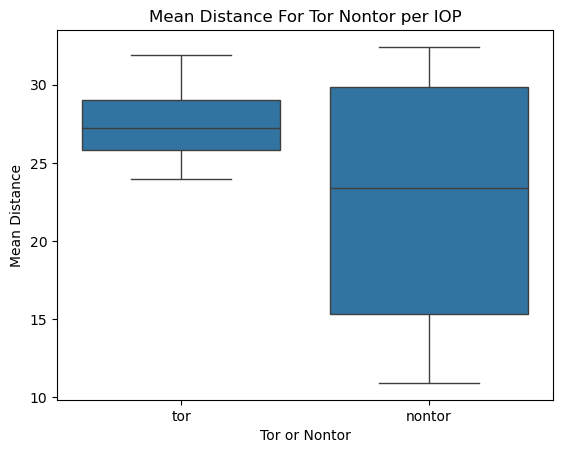

In [44]:
sns.boxplot(avg_comp_tor_nontor_dist, x='Tor or Nontor', y='Mean Distance')
plt.title('Mean Distance For Tor Nontor per IOP')
plt.show()

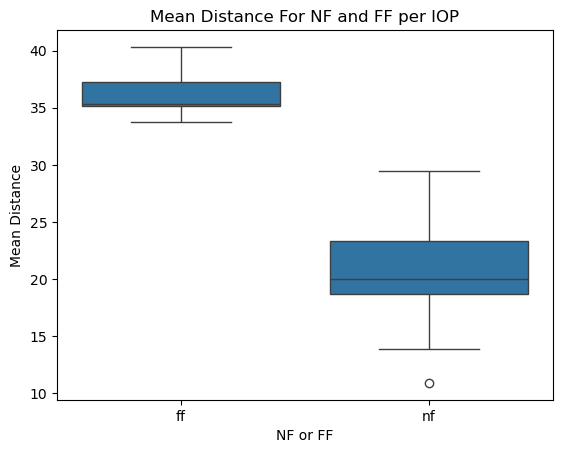

In [45]:
sns.boxplot(avg_comp_dist, x='NF or FF', y='Mean Distance')
plt.title('Mean Distance For NF and FF per IOP')
plt.show()

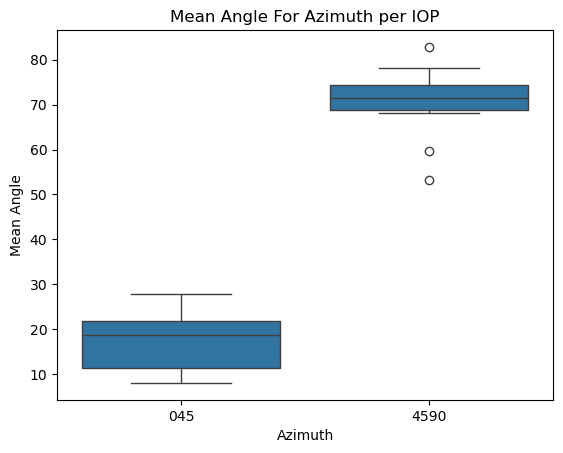

In [46]:
sns.boxplot(avg_comp_az, x='Azimuth', y='Mean Angle')
plt.title('Mean Angle For Azimuth per IOP')
plt.show()

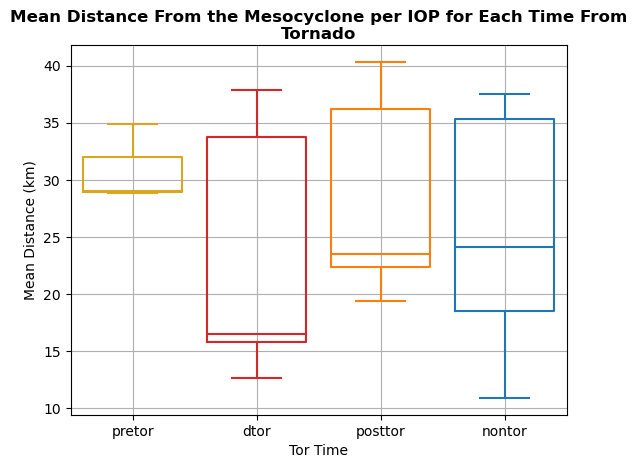

In [47]:
hue_order= ['nontor', 'pretor', 'dtor', 'posttor']

plot_data = avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-1km')]
sns.boxplot(plot_data, x='Tor Time', y='Mean Distance', hue='Tor Time', fill=False, palette =['tab:blue', 'goldenrod', 'tab:red', 'tab:orange', ], hue_order= ['nontor', 'pretor', 'dtor', 'posttor'])

# grouped = plot_data.groupby(['Tor Time'])['Mean Distance']

#     #dfa = pd.DataFrame()
    
# for i, ((x_val, hue_val), values) in enumerate(grouped):
#     median = np.median(values.dropna())
#     # Get the position on the x-axis using orderings
#     #x_index = height_order.index(x_val)
#     hue_index = hue_order.index(hue_val)
#     num_hues = len(hue_order)
    
#     # Calculate box position (adjust for hue spread)
#     xpos = x_index - 0.4 + (hue_index + 0.5) * (0.8 / num_hues)

#     ax.text(xpos, median, f'{median:.1f}', ha='center', va='bottom', fontsize=10, color='black')
    
plt.title('Mean Distance From the Mesocyclone per IOP for Each Time From Tornado', fontweight='bold', wrap=True)
plt.grid()
plt.ylabel('Mean Distance (km)')
#plt.xticks(ticks=[0, 1], labels=['0-45 degrees', '45-90 degrees'])
plt.show()

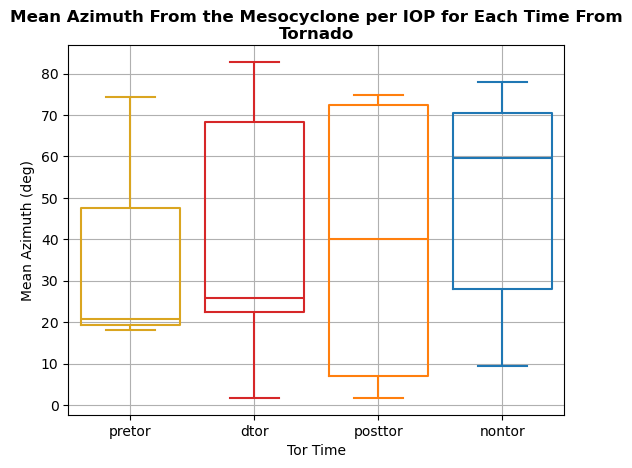

In [48]:
sns.boxplot(avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-1km')],x='Tor Time', y='Mean Angle', hue='Tor Time', fill=False, palette =['tab:blue', 'goldenrod', 'tab:red', 'tab:orange'], hue_order= ['nontor', 'pretor', 'dtor', 'posttor'])
plt.title('Mean Azimuth From the Mesocyclone per IOP for Each Time From Tornado', fontweight='bold', wrap=True)
plt.grid()
plt.ylabel('Mean Azimuth (deg)')
#plt.xticks(ticks=[0, 1], labels=['0-45 degrees', '45-90 degrees'])
plt.show()

In [ ]:
avg_comp_nfff

In [49]:
dist_both = avg_comp_nfff.groupby(['Date', 'Tor or Nontor', 'Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()

In [ ]:
dist_both

Now average pretor, dtor, and posttor into one column each, then average those for total tor. ONLY NEED TO DO DISTANCE AVGING SINCE THAT HAS INFLOW IN IT ALREADY

In [ ]:
avg_comp[avg_comp['SRW or SRH'] == 'Critical Angle']['Height'].value_counts()

Let's not average pretor, dtor, posttor per date into one tor, lets average them all together first and then do big composite

In [50]:
summary = avg_comp.dropna().groupby(['Date', 'Tor Time', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

In [51]:
summary

,Date,Tor Time,Height,SRW or SRH,Dist avg
0,20220523,dtor,0-100m,Bulk Shear,4.171915
1,20220523,dtor,0-100m,Critical Angle,57.614000
2,20220523,dtor,0-100m,SRH,-10.503777
3,20220523,dtor,0-100m,SRW,22.476047
4,20220523,dtor,0-1km,Bulk Shear,12.844357
...,...,...,...,...,...
223,20240528,nontor,0-500m,Bulk Shear,7.776975
224,20240528,nontor,0-500m,Critical Angle,85.848304
225,20240528,nontor,0-500m,SRH,54.480508
226,20240528,nontor,0-500m,SRW,14.843035


Finding avg distances and azimuths

In [52]:
# choose one group to find avg dist and azimuth
just_one = avg_comp[(avg_comp['Height'] == '0-1km') & (avg_comp['SRW or SRH'] == 'SRH')]

mean_dist_az = just_one.groupby(['Date', 'Tor or Nontor', 'Mean Distance', 'Mean Angle', 'Azimuth'])[['Dist avg']].mean().reset_index()
mean_az_dist = just_one.groupby(['Date', 'Tor or Nontor', 'Mean Distance', 'Mean Angle', 'NF or FF'])[['Angle avg']].mean().reset_index()

mean_dist_az_tt = just_one.groupby(['Date', 'Tor or Nontor', 'Tor Time', 'Mean Distance', 'Mean Angle', 'Azimuth'])[['Dist avg']].mean().reset_index()
mean_az_dist_tt = just_one.groupby(['Date', 'Tor or Nontor', 'Tor Time', 'Mean Distance', 'Mean Angle', 'NF or FF'])[['Angle avg']].mean().reset_index()

mean_dist= mean_dist_az.groupby(['Date', 'Tor or Nontor', 'Azimuth'])[['Mean Distance']].mean().reset_index()
mean_dist_tt = mean_dist_az_tt.groupby(['Date', 'Tor or Nontor', 'Azimuth', 'Tor Time'])[['Mean Distance']].mean().reset_index()

mean_az= mean_az_dist.groupby(['Date', 'Tor or Nontor', 'NF or FF'])[['Mean Angle']].mean().reset_index()
mean_az_tt = mean_az_dist_tt.groupby(['Date', 'Tor or Nontor', 'NF or FF', 'Tor Time'])[['Mean Angle']].mean().reset_index()

mean_dist_nodate = mean_dist.groupby(['Tor or Nontor', 'Azimuth'])[['Mean Distance']].mean().reset_index()
mean_az_nodate = mean_az.groupby(['Tor or Nontor', 'NF or FF'])[['Mean Angle']].mean().reset_index()

mean_dist_nodate_tt = mean_dist_tt.groupby(['Tor or Nontor', 'Tor Time','Azimuth'])[['Mean Distance']].mean().reset_index()
mean_az_nodate_tt = mean_az_tt.groupby(['Tor or Nontor', 'Tor Time', 'NF or FF'])[['Mean Angle']].mean().reset_index()

mean_t_dist = mean_dist.groupby(['Date', 'Tor or Nontor'])[['Mean Distance']].mean().reset_index()
mean_t_az = mean_az.groupby(['Date', 'Tor or Nontor'])[['Mean Angle']].mean().reset_index()

mean_dist_tt = mean_dist_tt.groupby(['Date', 'Tor or Nontor', 'Tor Time','Azimuth'])[['Mean Distance']].mean().reset_index()
mean_az_tt = mean_az_tt.groupby(['Date', 'Tor or Nontor', 'Tor Time', 'NF or FF'])[['Mean Angle']].mean().reset_index()

mean_t_dist_nodate = mean_t_dist.groupby(['Tor or Nontor'])[['Mean Distance']].mean().reset_index()
mean_t_az_nodate = mean_t_az.groupby(['Tor or Nontor'])[['Mean Angle']].mean().reset_index()

mean_locs = pd.concat([mean_dist, mean_az], ignore_index=True)
mean_locs_tt = pd.concat([mean_dist_tt, mean_az_tt], ignore_index=True)

mean_locs_tnt = pd.concat([mean_t_dist, mean_t_az], ignore_index=True)

mean_locs_nodate = pd.concat([mean_dist_nodate, mean_az_nodate], ignore_index=True)

mean_locs_tnt_nodate = pd.concat([mean_t_dist_nodate, mean_t_az_nodate], ignore_index=True)

NameError: name 'height_order' is not defined

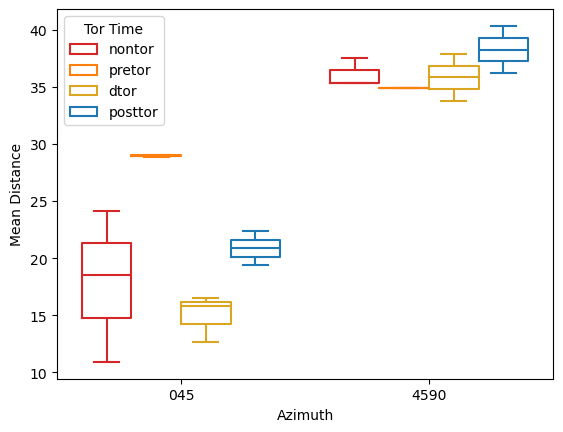

In [53]:
sns.boxplot(mean_locs_tt, x='Azimuth', y='Mean Distance', hue='Tor Time', fill=False, palette =['tab:red', 'tab:orange', 'goldenrod', 'tab:blue'], hue_order=['nontor', 'pretor', 'dtor', 'posttor'])

grouped = plot_data.groupby(['Azimuth', 'Tor Time'])['Mean Distance']

    #dfa = pd.DataFrame()
    
for i, ((x_val, hue_val), values) in enumerate(grouped):
    median = np.median(values.dropna())
    # Get the position on the x-axis using orderings
    x_index = height_order.index(x_val)
    hue_index = hue_order.index(hue_val)
    num_hues = len(hue_order)
    
    # Calculate box position (adjust for hue spread)
    xpos = x_index - 0.4 + (hue_index + 0.5) * (0.8 / num_hues)

    ax.text(xpos, median, f'{median:.1f}', ha='center', va='bottom', fontsize=10, color='black')
    
plt.title('Mean Distance From the Mesocyclone For Azimuth Ranges', fontweight='bold')
plt.grid()
plt.ylabel('Mean Distance (km)')
plt.xticks(ticks=[0, 1], labels=['0-45 degrees', '45-90 degrees'])
plt.show()

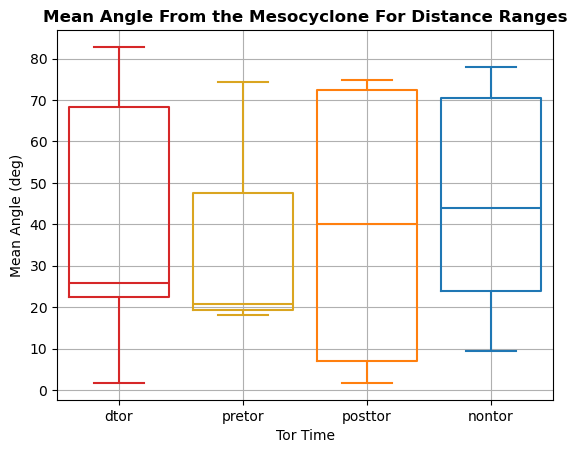

In [54]:
sns.boxplot(mean_locs_tt, x='Tor Time', y='Mean Angle', hue='Tor Time', fill=False, hue_order=['nontor', 'pretor', 'dtor', 'posttor'],  palette =['tab:blue', 'goldenrod', 'tab:red', 'tab:orange'],)
plt.title('Mean Angle From the Mesocyclone For Distance Ranges', fontweight='bold')
plt.grid()
plt.ylabel('Mean Angle (deg)')
#plt.xticks(ticks=[0, 1], labels=['NF', 'FF'])
plt.show()

In [ ]:
mean_locs

In [ ]:
mean_locs_tnt

In [55]:
mean_dist_az_pretor = just_one.groupby(['Date', 'Tor Time', 'Mean Distance', 'Mean Angle', 'NF or FF'])[['Dist avg']].mean().reset_index()
mean_az_dist_pretor = just_one.groupby(['Date', 'Tor Time', 'Mean Distance', 'Mean Angle', 'Azimuth'])[['Angle avg']].mean().reset_index()

mean_dist_pretor = mean_dist_az_pretor.groupby(['Date', 'Tor Time'])[['Mean Distance']].mean().reset_index()

mean_az_pretor = mean_az_dist_pretor.groupby(['Date', 'Tor Time'])[['Mean Angle']].mean().reset_index()

In [ ]:
mean_dist_pretor

In [ ]:
mean_az_pretor

Average pretor, dtor, and posttor per day and then do big average below

In [56]:
summarynotor = summary[(summary['Tor Time'] != 'nontor')]
toravg_all = summarynotor.groupby(['Date', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()
#distnotor = avg_comp_dist[avg_comp_dist['Tor Time'] != 'nontor']
avg_comp_notor = avg_comp[(avg_comp['Tor Time'] != 'nontor')]
dist_tor_avg_all = avg_comp_notor.groupby(['Date', 'Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()
dist_tor_avg_nodate = avg_comp_notor.groupby(['Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()

#anglenotor = avg_comp_angle[avg_comp_angle['Tor Time'] != 'nontor']
angle_tor_avg_all = avg_comp_notor.groupby(['Date', 'Height', 'SRW or SRH', 'Azimuth'])[['Angle avg']].mean().reset_index()
angle_tor_avg_nodate = avg_comp_notor.groupby(['Height', 'SRW or SRH', 'Azimuth'])[['Angle avg']].mean().reset_index()

In [57]:
dist_tor_avg_all['Tor or Nontor'] = 'tor'
angle_tor_avg_all['Tor or Nontor'] = 'tor'

dist_tor_avg_nodate['Tor or Nontor'] = 'tor'
angle_tor_avg_nodate['Tor or Nontor'] = 'tor'

In [58]:
toravg_all['Tor Time'] = 'tor'

In [59]:
avg_tor_comp = toravg_all.groupby(['Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

In [60]:
avg_tor_comp['Tor Time'] = 'tor'

In [61]:
summarynontor = summary[summary['Tor Time'] == 'nontor']
nontoravg_all = summarynontor.groupby(['Date', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()
avg_nontor_comp = nontoravg_all.groupby(['Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

avg_comp_nontor = avg_comp[avg_comp['Tor Time'] == 'nontor']
#distnontor = avg_comp_dist[avg_comp_dist['Tor Time'] == 'nontor']
dist_nontor_avg_all = avg_comp_nontor.groupby(['Date', 'Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()
dist_nontor_avg_nodate = avg_comp_nontor.groupby(['Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()

anglenontor = avg_comp_nontor[avg_comp_nontor['Tor Time'] == 'nontor']
angle_nontor_avg_all = avg_comp_nontor.groupby(['Date', 'Height', 'SRW or SRH', 'Azimuth'])[['Angle avg']].mean().reset_index()
angle_nontor_avg_nodate = avg_comp_nontor.groupby(['Height', 'SRW or SRH', 'Azimuth'])[['Angle avg']].mean().reset_index()

In [62]:
dist_nontor_avg_all['Tor or Nontor'] = 'nontor'
angle_nontor_avg_all['Tor or Nontor'] = 'nontor'

dist_nontor_avg_nodate['Tor or Nontor'] = 'nontor'
angle_nontor_avg_nodate['Tor or Nontor'] = 'nontor'

In [63]:
nontoravg_all['Tor Time'] = 'nontor'

In [64]:
avg_nontor_comp['Tor Time'] = 'nontor'

In [65]:
dist_angle_avg_date = pd.concat([dist_tor_avg_all, angle_tor_avg_all, dist_nontor_avg_all, angle_nontor_avg_all], ignore_index=True)

In [66]:
dist_angle_avg_nodate = pd.concat([dist_tor_avg_nodate, angle_tor_avg_nodate, dist_nontor_avg_nodate, angle_nontor_avg_nodate], ignore_index=True)

In [67]:
avg_all_comp_per_date = pd.concat([nontoravg_all, toravg_all], ignore_index=True)

In [68]:
avg_all_comp = pd.concat([avg_nontor_comp, avg_tor_comp], ignore_index=True)

In [69]:
avg_total_comp = summary.groupby(['Tor Time', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

avg comp averaging with barplots is not the same as avg_all_comp (averaging before letting the barplots do it)

### avg_all_comp (avgs pretor, dtor, posttor, and all dates)

In [ ]:
srw_or_srh = 'SRW'
col = 'Dist avg'
df = avg_all_comp[avg_all_comp['SRW or SRH'] == srw_or_srh]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor Time')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
df = avg_all_comp[avg_all_comp['SRW or SRH'] == srw_or_srh]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor Time')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'Bulk Shear'
col = 'Dist avg'
df = avg_all_comp[avg_all_comp['SRW or SRH'] == srw_or_srh]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor Time')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs')
plt.show()

### dist_angle_avg_nodate (NF vs FF, 0-45 vs 45-90, averaged tor times)

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
df = dist_angle_avg_nodate[dist_angle_avg_nodate['SRW or SRH'] == srw_or_srh]
ax = sns.barplot(df, y = col, x = 'Tor or Nontor', hue = 'Height')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs (AVGS NF AND FF ALL TOGETHER NOT PER DATE SO DOUBLE DATAPOINTS, ARTIFICIALLY HIGH DONT USE, USE AVG_ALL_COMP FOR TOTAL SRW SRH INSTEAD', wrap=True)
plt.show()

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
nforff = 'nf'
df = dist_angle_avg_nodate[(dist_angle_avg_nodate['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_nodate['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Tor or Nontor', hue = 'Height')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
nforff = 'ff'
df = dist_angle_avg_nodate[(dist_angle_avg_nodate['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_nodate['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Tor or Nontor', hue = 'Height')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'Critical Angle'
col = 'Angle avg'
#nforff = 'ff'
df = dist_angle_avg_nodate[(dist_angle_avg_nodate['SRW or SRH'] == srw_or_srh)] #& (dist_angle_avg_nodate['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Tor or Nontor', hue = 'Angle')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} 0-500m Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
nforff = 'nf'
df = avg_comp[(avg_comp['SRW or SRH'] == srw_or_srh) & (avg_comp['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {nforff} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
col = 'Dist avg'
nforff = 'nf'
df = avg_comp[(avg_comp['SRW or SRH'] == srw_or_srh) & (avg_comp['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {nforff} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
col = 'Dist avg'
nforff = 'ff'
df =avg_comp[(avg_comp['SRW or SRH'] == srw_or_srh) & (avg_comp['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {nforff} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
#df = avg_comp[avg_comp['SRW or SRH'] == srw_or_srh]
col = 'Dist avg'
nforff = 'ff'
df = avg_comp[(avg_comp['SRW or SRH'] == srw_or_srh) & (avg_comp['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {nforff} {srw_or_srh} Distribution for ALL VADs')
plt.show()

spec comp did not average pretor, dtor, and posttor per date before averaging so may be skewed if some days have more pretor vads than dtor, etc

In [ ]:
date = '20220523'
srw_or_srh = 'SRW'
spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'Dist avg'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'NF or FF')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs {date}')
plt.show()

In [ ]:
date = '20220523'
srw_or_srh = 'SRH'
spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'Dist avg'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'NF or FF')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs {date}')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'ff'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'ff'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
spec_comp

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Angle avg'
#nforff = 'nf'
angle = '0-45'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
#spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Angle'] == angle]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {angle} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Angle avg'
#nforff = 'nf'
angle = '45-90'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
#spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Angle'] == angle]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {angle} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
def wide_barplot_comp_iops(srw_or_srh, values, nforff, spec_comp, index, columns):
    
    fig = plt.figure(figsize=(10,5))
    spec_comp = spec_comp[spec_comp['SRW or SRH'] == srw_or_srh]
    spec_comp = spec_comp[spec_comp['NF or FF'] == nforff]
    
    spec_comp_wide = spec_comp.pivot(index=index, columns=columns, values=values)
    sns.barplot(spec_comp_wide)
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.ylabel(srw_or_srh)
    plt.title(f'{nforff} {srw_or_srh} Averaged per {values} for all IOPs')
    plt.show()
    return spec_comp_wide

In [ ]:
srw_or_srh = 'SRH'
nforff = 'nf'
index = 'Height'
columns = 'Date'
values = 'Dist avg'
s_nf_srh = wide_barplot_comp_iops(srw_or_srh, values, nforff, spec_comp, index, columns)

In [ ]:
srw_or_srh = 'SRH'
nforff = 'ff'
index = 'Height'
columns = 'Date'
values = 'Dist avg'
s_ff_srh = wide_barplot_comp_iops(srw_or_srh, values, nforff, spec_comp, index, columns)

In [ ]:
s_nf_srh

In [ ]:
sns.barplot(s_nf_srh['20220524'])
plt.title('SRH')

In [ ]:
nf_u_categories['tor'].Date

In [ ]:
np.shape(nf_u_categories['nontor'])

In [ ]:
np.shape(ff_u_categories['nontor'])

In [ ]:
np.shape(nf_u_categories['tor'])

In [ ]:
np.shape(ff_u_categories['tor'])

In [ ]:
np.shape(nf_u_categories_new['nontor'])

In [ ]:
np.shape(ff_u_categories_new['nontor'])

In [ ]:
np.shape(nf_u_categories_new['tor'])

In [ ]:
inflow_u_categories_new

In [ ]:
np.shape(ff_u_categories_new['tor'])

In [ ]:
inflow_u_all

In [ ]:
inflow_u_categories

In [ ]:
def

In [ ]:
df_all_new

Is this already accounted for in SRH?

## Compositing cases

In [ ]:
def composite_cases(files, dates, nf_dist, ff_dist, minangle, maxangle, additionalangle, tor_time, kas):
    comp_tor_all_nodist = pd.DataFrame()
    comp_nontor_all_nodist = pd.DataFrame()
    
    comp_tor_all = pd.DataFrame()
    comp_nontor_all = pd.DataFrame()
    
    for ka in kas:
        for d in dates:
            for file in glob.glob(files):
                    comp_tor_nodist, comp_nontor_nodist, comp_tor, comp_nontor = comp_per_case(file, ka, d, nf_dist, ff_dist, minangle, maxangle, additionalangle, tor_time)
                    #comp_tor['Tor or Nontor'] = 'tor'
                    #comp_nontor['Tor or Nontor'] = 'nontor'
            
                    comp_tor_all_nodist = pd.concat([comp_tor_all_nodist, comp_tor_nodist])
                    comp_nontor_all_nodist = pd.concat([comp_nontor_all_nodist, comp_nontor_nodist])
                    
                    comp_tor_all = pd.concat([comp_tor_all, comp_tor])
                    comp_nontor_all = pd.concat([comp_nontor_all, comp_nontor])

                    return comp_tor_all_nodist, comp_nontor_all_nodist, comp_tor_all, comp_nontor_all

In [ ]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 0
angle1 = 90
angle2 = 350
tor_time = 0
kas = ['ka1', 'ka2']

In [ ]:
comp_tor_all_nodist, comp_nontor_all_nodist, comp_tor_all, comp_nontor_all = composite_cases(
    f'case_dfs/new/new_secondtrip/*/{d}_uv_*_all.csv', dates, nf_dist, ff_dist, angle0, angle1, angle2, tor_time, kas)

In [ ]:
comp_tor_all_nodist = pd.DataFrame()
comp_nontor_all_nodist = pd.DataFrame()

comp_tor_all = pd.DataFrame()
comp_nontor_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        comp_tor_nodist, comp_nontor_nodist, comp_tor, comp_nontor = comp_per_case(f'case_dfs/new/{d}_uv_{ka}_all.csv', ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
        #comp_tor['Tor or Nontor'] = 'tor'
        #comp_nontor['Tor or Nontor'] = 'nontor'

        comp_tor_all_nodist = pd.concat([comp_tor_all_nodist, comp_tor_nodist])
        comp_nontor_all_nodist = pd.concat([comp_nontor_all_nodist, comp_nontor_nodist])
        
        comp_tor_all = pd.concat([comp_tor_all, comp_tor])
        comp_nontor_all = pd.concat([comp_nontor_all, comp_nontor])

In [ ]:
comp_tor_all_nodist_new = pd.DataFrame()
comp_nontor_all_nodist_new = pd.DataFrame()

comp_tor_all_new = pd.DataFrame()
comp_nontor_all_new = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new = pd.concat([comp_nontor_all_new, comp_nontor_new])

In [ ]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 0
angle1 = 45
angle2 = 360
tor_time = 0

In [ ]:
comp_tor_all_nodist_new045 = pd.DataFrame()
comp_nontor_all_nodist_new045 = pd.DataFrame()

comp_tor_all_new045 = pd.DataFrame()
comp_nontor_all_new045 = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new045 = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new045 = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new045 = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new045 = pd.concat([comp_nontor_all_new, comp_nontor_new])

In [ ]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 45
angle1 = 90
angle2 = 360
tor_time = 0

In [ ]:
comp_tor_all_nodist_new4590 = pd.DataFrame()
comp_nontor_all_nodist_new4590 = pd.DataFrame()

comp_tor_all_new4590 = pd.DataFrame()
comp_nontor_all_new4590 = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new4590 = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new4590 = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new4590 = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new4590 = pd.concat([comp_nontor_all_new, comp_nontor_new])

In [ ]:
comp_tor_all_nodist_new = pd.DataFrame()
comp_nontor_all_nodist_new = pd.DataFrame()

comp_tor_all_new = pd.DataFrame()
comp_nontor_all_new = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new = pd.concat([comp_nontor_all_new, comp_nontor_new])

In [ ]:
# comp_tor_all_nodist.dropna(inplace=True)
comp_tor_all_nodist_new.dropna(inplace=True)

# comp_nontor_all_nodist.dropna(inplace=True)
comp_nontor_all_nodist_new.dropna(inplace=True)

#comp_tor_all_nodist045.dropna(inplace=True)
comp_tor_all_nodist_new045.dropna(inplace=True)

#comp_nontor_all_nodist045.dropna(inplace=True)
comp_nontor_all_nodist_new045.dropna(inplace=True)

#comp_tor_all_nodist4590.dropna(inplace=True)
comp_tor_all_nodist_new4590.dropna(inplace=True)

#comp_nontor_all_nodist4590.dropna(inplace=True)
comp_nontor_all_nodist_new4590.dropna(inplace=True)

In [ ]:
comp_tor_all.date.value_counts()

In [ ]:
# comp_tor_all.dropna(inplace=True)
# comp_nontor_all.dropna(inplace=True)
comp_tor_all_new.dropna(inplace=True)
comp_nontor_all_new.dropna(inplace=True)

comp_tor_all_new045.dropna(inplace=True)
comp_nontor_all_new045.dropna(inplace=True)

comp_tor_all_new4590.dropna(inplace=True)
comp_nontor_all_new4590.dropna(inplace=True)

In [ ]:
comp_tor_all.date.value_counts()

In [ ]:
comp_nontor_all.date.value_counts()

In [ ]:
comp_tor_all_new.date.value_counts()

In [ ]:
comp_tor_all_new.date.value_counts()

In [ ]:
comp_tor_all_new.label.value_counts()

# Composite u and v and Hodographs

## new uv comp method

In [ ]:
df_all_new['Time From Tor (min)']

In [ ]:
def comp_per_condition_avg_uv(df_all_new, nf_dist, minangle, midangle, maxangle):
    all_conditions = []
    conditions_df = pd.DataFrame()
    
    #df = df_all_new[df_all_new['Date'] == date]

    inflow = df[df['Angle'] <= maxangle]
    inflow = inflow[inflow['Angle'] >= minangle]
    #inflow = inflow[inflow['Angle'] >= minangle]

    # inflowtor = inflow[inflow['Tor or Nontor'] == 'tor']

    # dfpretor = inflowtor[inflowtor['Time From Tor (min)'] < 0]
    # dfdtor = inflowtor[inflowtor['Time From Tor (min)'] == 0]
    # dfposttor = inflowtor[inflowtor['Time From Tor (min)'] > 0]
    
    # inflow = df[df['Angle'] <= maxangle]
    # inflow = inflow[inflow['Angle'] >= minangle]

    nf = inflow[inflow['Distance'] <= nf_dist]
    ff = inflow[inflow['Distance'] > nf_dist]
    
    uv = ['u', 'v']
    dist = ['nf', 'ff']
    nfff = [nf, ff]
    
    for uorv in uv:
        nfu = nf[nf['u or v'] == uorv]
        ffu = ff[ff['u or v'] == uorv]

        nfu_avg = np.nanmean(nfu.iloc[:, :196], axis=0)
        ffu_avg = np.nanmean(ffu.iloc[:, :196], axis=0)
    
        nf_df = pd.DataFrame(nfu_avg).T
        ff_df = pd.DataFrame(ffu_avg).T

        nf_df['NF or FF'] = 'nf'
        ff_df['NF or FF'] = 'ff'

        # nf_df['u or v'] = uorv
        # ff_df['u or v'] = uorv
    
        nf_ff_df = pd.concat([nf_df, ff_df])
        nf_ff_df['u or v'] = uorv
        
        dfu = df[df['u or v'] == uorv]
        
        angle_df045u = dfu[dfu['Angle'] >= minangle]
        angle_df045u = angle_df045u[angle_df045u['Angle'] <= midangle]
        
        
        angle045u_avg = np.nanmean(angle_df045u.iloc[:, :196], axis=0)
        angle_df0 = pd.DataFrame(angle045u_avg).T
        angle_df0['Angle'] = ['0-45 deg']
    
        angle_df4590u = dfu[dfu['Angle'] <= maxangle]
        angle_df4590u = angle_df4590u[angle_df4590u['Angle'] >= midangle]
    
        angle4590u_avg = np.nanmean(angle_df4590u.iloc[:, :196], axis=0)
        angle_df45 = pd.DataFrame(angle4590u_avg).T
        angle_df45['Angle'] = ['45-90 deg']

        angle_df = pd.concat([angle_df0, angle_df45])
        #angle_df['u or v'] = uorv
        angle_df['u or v'] = uorv
        
        all_conditions.append(pd.concat([nf_ff_df, angle_df]))

    conditions_df = pd.concat(all_conditions, ignore_index=True)

    return conditions_df

In [ ]:
def comp_per_condition_avg_uv(df, nf_dist, ff_dist, minangle, midangle, maxangle):
    all_conditions = []
    conditions_df = pd.DataFrame()
    
    #df = df_all_new[df_all_new['Date'] == date]

    inflow = df[(df['Angle'] <= maxangle)] #| (df['Angle'] >=350)]
    inflow = inflow[inflow['Angle'] >= minangle]
    #inflow = inflow[inflow['Angle'] >= minangle]

    # inflowtor = inflow[inflow['Tor or Nontor'] == 'tor']

    # dfpretor = inflowtor[inflowtor['Time From Tor (min)'] < 0]
    # dfdtor = inflowtor[inflowtor['Time From Tor (min)'] == 0]
    # dfposttor = inflowtor[inflowtor['Time From Tor (min)'] > 0]
    
    # inflow = df[df['Angle'] <= maxangle]
    # inflow = inflow[inflow['Angle'] >= minangle]

    nf = inflow[inflow['Distance'] <= nf_dist]
    ff = inflow[(inflow['Distance'] > nf_dist) & (inflow['Distance'] < ff_dist)]
    
    uv = ['u', 'v']
    dist = ['nf', 'ff']
    nfff = [nf, ff]
    
    for uorv in uv:
        nfu = nf[nf['u or v'] == uorv]
        ffu = ff[ff['u or v'] == uorv]

        nfu_avg = np.nanmean(nfu.iloc[:, :196], axis=0)
        ffu_avg = np.nanmean(ffu.iloc[:, :196], axis=0)
    
        nf_df = pd.DataFrame(nfu_avg).T
        ff_df = pd.DataFrame(ffu_avg).T

        nf_df['NF or FF'] = 'nf'
        ff_df['NF or FF'] = 'ff'

        # nf_df['u or v'] = uorv
        # ff_df['u or v'] = uorv
    
        nf_ff_df = pd.concat([nf_df, ff_df])
        nf_ff_df['u or v'] = uorv
        
        dfu = df[df['u or v'] == uorv]
        
        #angle_df045u = dfu[dfu['Angle'] >= minangle]
        angle_df045u = dfu[(dfu['Angle'] >= minangle)] #| (dfu['Angle'] >= 350)]
        angle_df045u = angle_df045u[angle_df045u['Angle'] <= midangle]
        
        
        angle045u_avg = np.nanmean(angle_df045u.iloc[:, :196], axis=0)
        angle_df0 = pd.DataFrame(angle045u_avg).T
        angle_df0['Azimuth'] = ['0-45 deg']
    
        angle_df4590u = dfu[dfu['Angle'] <= maxangle]
        angle_df4590u = angle_df4590u[angle_df4590u['Angle'] >= midangle]
    
        angle4590u_avg = np.nanmean(angle_df4590u.iloc[:, :196], axis=0)
        angle_df45 = pd.DataFrame(angle4590u_avg).T
        angle_df45['Azimuth'] = ['45-90 deg']

        angle_df = pd.concat([angle_df0, angle_df45])
        #angle_df['u or v'] = uorv
        angle_df['u or v'] = uorv
        
        all_conditions.append(pd.concat([nf_ff_df, angle_df]))

    conditions_df = pd.concat(all_conditions, ignore_index=True)

    return conditions_df

In [ ]:
nf_dist = 30
ff_dist = 50
minangle = 0
midangle = 45
maxangle = 90

In [ ]:
uv_avg_comp = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df_uv = pd.DataFrame()
    nontor_df_uv = pd.DataFrame()
    df = df_all_new[df_all_new['Date'] == d]
    if df['Tor or Nontor'].eq('tor').any():
        pretor = df[df['Time From Tor (min)'] < 0]
        dtor = df[df['Time From Tor (min)'] == 0]
        posttor = df[df['Time From Tor (min)'] > 0]
        pretor_df_uv = comp_per_condition_avg_uv(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
        dtor_df_uv = comp_per_condition_avg_uv(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
        posttor_df_uv = comp_per_condition_avg_uv(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)
    #test = comp_per_condition_avg_uv(df_all_new, d, nf_dist, minangle, midangle, maxangle)
    #test['Date'] = d
        pretor_df_uv['Tor Time'] = 'pretor'
        dtor_df_uv['Tor Time'] = 'dtor'
        posttor_df_uv['Tor Time'] = 'posttor'

        tor_df_uv = pd.concat([pretor_df_uv, dtor_df_uv, posttor_df_uv], ignore_index=True)
        tor_df_uv['Tor or Nontor'] = 'tor'
        tor_df_uv['Date'] = d
    #eep = df_all_new[df_all_new['Date'] == d]
    
    
    elif df['Tor or Nontor'].eq('nontor').any():
        df = df[df['Distance'] < 40]
        nontor_df_uv = comp_per_condition_avg_uv(df, nf_dist, 40, minangle, midangle, maxangle)
        nontor_df_uv['Tor or Nontor'] = 'nontor'
        nontor_df_uv['Date'] = d
        nontor_df_uv['Tor Time'] = 'nontor'
        
    uv_avg_comp = pd.concat([uv_avg_comp, tor_df_uv, nontor_df_uv], ignore_index=True)

In [ ]:
uv_avg_comp

In [ ]:
b = uv_avg_comp.groupby(['Date', 'Tor Time', 'u or v'], dropna=True)[uv_avg_comp.columns[:196]].mean().reset_index()

In [ ]:
c = b.dropna()

In [ ]:
uv_tortimes = c.groupby(['Tor Time', 'u or v'], dropna=True)[uv_avg_comp.columns[:196]].mean().reset_index()

In [ ]:
uv_tor_only = uv_avg_comp[uv_avg_comp['Tor Time'] != 'nontor']

preunf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)
dunf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)
postunf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)

prevnf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)
dvnf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)
postvnf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)

torunf = np.nanmean([preunf, dunf, postunf], axis=0)
torvnf = np.nanmean([prevnf, dvnf, postvnf], axis=0)

preuff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)
duff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)
postuff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)

prevff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)
dvff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)
postvff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)

toruff = np.nanmean([preuff, duff, postuff], axis=0)
torvff = np.nanmean([prevff, dvff, postvff], axis=0)

torunfdf = pd.DataFrame(torunf).T
torvnfdf = pd.DataFrame(torvnf).T

toruffdf = pd.DataFrame(toruff).T
torvffdf = pd.DataFrame(torvff).T

torunfdf['u or v'] = 'u'
torvnfdf['u or v'] = 'v'
torunfdf['NF or FF'] = 'nf'
torvnfdf['NF or FF'] = 'nf'

toruffdf['u or v'] = 'u'
torvffdf['u or v'] = 'v'
toruffdf['NF or FF'] = 'ff'
torvffdf['NF or FF'] = 'ff'

tordf = pd.concat([torunfdf, torvnfdf, toruffdf, torvffdf], ignore_index=True)
tordf['Tor or Nontor'] = 'tor'

In [ ]:
uv_tor_only = uv_avg_comp[uv_avg_comp['Tor Time'] != 'nontor']

preu45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Azimuth'] == '0-45 deg')].iloc[:,:196], axis=0)
du45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Azimuth'] == '0-45 deg')].iloc[:,:196], axis=0)
postu45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Azimuth'] == '0-45 deg')].iloc[:,:196], axis=0)

prev45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Azimuth'] == '0-45 deg')].iloc[:,:196], axis=0)
dv45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Azimuth'] == '0-45 deg')].iloc[:,:196], axis=0)
postv45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Azimuth'] == '0-45 deg')].iloc[:,:196], axis=0)

toru45 = np.nanmean([preu45, du45, postu45], axis=0)
torv45 = np.nanmean([prev45, dv45, postv45], axis=0)

preu90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Azimuth'] == '45-90 deg')].iloc[:,:196], axis=0)
du90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Azimuth'] == '45-90 deg')].iloc[:,:196], axis=0)
postu90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Azimuth'] == '45-90 deg')].iloc[:,:196], axis=0)

prev90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Azimuth'] == '45-90 deg')].iloc[:,:196], axis=0)
dv90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Azimuth'] == '45-90 deg')].iloc[:,:196], axis=0)
postv90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Azimuth'] == '45-90 deg')].iloc[:,:196], axis=0)

toru90 = np.nanmean([preu90, du90, postu90], axis=0)
torv90 = np.nanmean([prev90, dv90, postv90], axis=0)

toru45df = pd.DataFrame(toru45).T
torv45df = pd.DataFrame(torv45).T

toru90df = pd.DataFrame(toru90).T
torv90df = pd.DataFrame(torv90).T

toru45df['u or v'] = 'u'
torv45df['u or v'] = 'v'
toru45df['Azimuth'] = '0-45 deg'
torv45df['Azimuth'] = '0-45 deg'

toru90df['u or v'] = 'u'
torv90df['u or v'] = 'v'
toru90df['Azimuth'] = '45-90 deg'
torv90df['Azimuth'] = '45-90 deg'

torangledf = pd.concat([toru45df, torv45df, toru90df, torv90df], ignore_index=True)
torangledf['Tor or Nontor'] = 'tor'

In [ ]:
uv_tor_only = uv_avg_comp[uv_avg_comp['Tor Time'] != 'nontor']
uv_nontor_only = uv_avg_comp[uv_avg_comp['Tor Time'] == 'nontor']

uv_tor_only_avg_dist = uv_tor_only.groupby(['Date', 'NF or FF', 'u or v'], dropna=True)[uv_tor_only.columns[:196]].mean().reset_index() # avg pretor, dtor, etc per day
uv_tor_only_avg_angle = uv_tor_only.groupby(['Date', 'Azimuth', 'u or v'], dropna=True)[uv_tor_only.columns[:196]].mean().reset_index()
uv_tor_only_avg_dist['Tor or Nontor'] = 'tor'
uv_tor_only_avg_angle['Tor or Nontor'] = 'tor'

uv_tor_all_avg_dist = uv_tor_only_avg_dist.groupby(['NF or FF', 'u or v'], dropna=True)[uv_tor_only_avg_dist.columns[3:199]].mean().reset_index()
uv_tor_all_avg_angle = uv_tor_only_avg_angle.groupby(['Azimuth', 'u or v'], dropna=True)[uv_tor_only_avg_angle.columns[3:199]].mean().reset_index()
uv_tor_all_avg_dist['Tor or Nontor'] = 'tor'
uv_tor_all_avg_angle['Tor or Nontor'] = 'tor'

uv_nontor_only_avg_dist = uv_nontor_only.groupby(['Date', 'NF or FF', 'u or v'], dropna=True)[uv_nontor_only.columns[:196]].mean().reset_index() # avg pretor, dtor, etc per day
uv_nontor_only_avg_angle = uv_nontor_only.groupby(['Date', 'Azimuth', 'u or v'], dropna=True)[uv_nontor_only.columns[:196]].mean().reset_index()
uv_nontor_only_avg_dist['Tor or Nontor'] = 'nontor'
uv_nontor_only_avg_angle['Tor or Nontor'] = 'nontor'

uv_nontor_all_avg_dist = uv_nontor_only.groupby(['NF or FF', 'u or v'], dropna=True)[uv_nontor_only.columns[:196]].mean().reset_index()
uv_nontor_all_avg_angle = uv_nontor_only.groupby(['Azimuth', 'u or v'], dropna=True)[uv_nontor_only.columns[:196]].mean().reset_index()
uv_nontor_all_avg_dist['Tor or Nontor'] = 'nontor'
uv_nontor_all_avg_angle['Tor or Nontor'] = 'nontor'

uv_avg_comp_dates = pd.concat([uv_tor_only_avg_dist, uv_tor_only_avg_angle, uv_nontor_only_avg_dist, uv_nontor_only_avg_angle], ignore_index=True)

In [ ]:
uv_avg_comp_dates

In [ ]:
tor_nontor_all = uv_avg_comp_dates.groupby(['u or v', 'Tor or Nontor'])[uv_avg_comp_dates.columns[3:199]].mean().reset_index()

In [ ]:
tor_nontor_all

In [ ]:
uv_avg_comp_dates

In [ ]:
uv_tor_all_avg_angle

## Hodos

### composites

In [ ]:
tor_u = uv_tor_all_avg_angle[uv_tor_all_avg_angle['u or v'] == 'u']
tor_v = uv_tor_all_avg_angle[uv_tor_all_avg_angle['u or v'] == 'v']

nontor_u = uv_nontor_all_avg_angle[uv_nontor_all_avg_angle['u or v'] == 'u']
nontor_v = uv_nontor_all_avg_angle[uv_nontor_all_avg_angle['u or v'] == 'v']

nontor_heights = np.arange(50, 1010, 10)
                     
hodo_plot([np.array(tor_u[tor_u['Azimuth'] == '0-45 deg'].iloc[:, 2:198]).flatten(), np.array(nontor_u[nontor_u['Azimuth'] == '0-45 deg'].iloc[:, 2:198]).flatten(), 
           np.array(tor_u[tor_u['Azimuth'] == '45-90 deg'].iloc[:, 2:198]).flatten(), np.array(nontor_u[nontor_u['Azimuth'] == '45-90 deg'].iloc[:, 2:198]).flatten()], 
          [np.array(tor_v[tor_v['Azimuth'] == '0-45 deg'].iloc[:, 2:198]).flatten(), np.array(nontor_v[nontor_v['Azimuth'] == '0-45 deg'].iloc[:, 2:198]).flatten(), 
           np.array(tor_v[tor_v['Azimuth'] == '45-90 deg'].iloc[:, 2:198]).flatten(), np.array(nontor_v[nontor_v['Azimuth'] == '45-90 deg'].iloc[:, 2:198]).flatten()], heights, 25, 
          'Storm-Relative Composite Mesocyclone-Relative Azimuth Hodographs', ['tab:red', 'tab:blue', very_dark_red, 'darkblue'],
          ['Tornadic (0-45 deg)', 'Nontornadic (0-45 deg)', 'Tornadic (45-90 deg)', 'Nontornadic (45-90 deg)'], 10, 25, 'lower left', 6,6)

In [ ]:
tor_u = uv_tor_all_avg_angle[uv_tor_all_avg_angle['u or v'] == 'u']
tor_v = uv_tor_all_avg_angle[uv_tor_all_avg_angle['u or v'] == 'v']

nontor_u = uv_nontor_all_avg_angle[uv_nontor_all_avg_angle['u or v'] == 'u']
nontor_v = uv_nontor_all_avg_angle[uv_nontor_all_avg_angle['u or v'] == 'v']

nontor_heights = np.arange(50, 1010, 10)
                     
hodo_plot([np.array(tor_u[tor_u['Azimuth'] == '0-45 deg'].iloc[:, 2:198]).flatten(), 
           np.array(tor_u[tor_u['Azimuth'] == '45-90 deg'].iloc[:, 2:198]).flatten()], 
          [np.array(tor_v[tor_v['Azimuth'] == '0-45 deg'].iloc[:, 2:198]).flatten(), 
           np.array(tor_v[tor_v['Azimuth'] == '45-90 deg'].iloc[:, 2:198]).flatten()], heights, 25, 
          'Storm-Relative Composite Mesocyclone-Relative Azimuth Hodographs', ['tab:red', very_dark_red],
          ['Tornadic (E)', 'Tornadic (S)'], 5, 25, 'lower left', 6,6)

In [ ]:
tor_u = uv_tor_all_avg_angle[uv_tor_all_avg_angle['u or v'] == 'u']
tor_v = uv_tor_all_avg_angle[uv_tor_all_avg_angle['u or v'] == 'v']

nontor_u = uv_nontor_all_avg_angle[uv_nontor_all_avg_angle['u or v'] == 'u']
nontor_v = uv_nontor_all_avg_angle[uv_nontor_all_avg_angle['u or v'] == 'v']

nontor_heights = np.arange(50, 1010, 10)
                     
hodo_plot([np.array(nontor_u[nontor_u['Azimuth'] == '0-45 deg'].iloc[:, 2:98]).flatten(), 
           np.array(nontor_u[nontor_u['Azimuth'] == '45-90 deg'].iloc[:, 2:98]).flatten()], 
          [np.array(nontor_v[nontor_v['Azimuth'] == '0-45 deg'].iloc[:, 2:98]).flatten(), 
        np.array(nontor_v[nontor_v['Azimuth'] == '45-90 deg'].iloc[:, 2:98]).flatten()], nontor_heights, 25, 
          'Storm-Relative Composite Mesocyclone-Relative Azimuth Hodographs', ['tab:blue', 'darkblue'],
          ['Nontornadic (E)', 'Nontornadic (S)'], 5, 25, 'lower left', 6,6)

In [ ]:
uv_tor_all_avg_dist

In [ ]:
tor_u.iloc[:, 2:198]

In [ ]:
np.shape(heights)

In [ ]:
uv_avg_comp_dates_dist = pd.concat([uv_tor_only_avg_dist, uv_nontor_only_avg_dist], ignore_index=True)

tor_nontor_all_no_repeat = uv_avg_comp_dates_dist.groupby(['u or v', 'Tor or Nontor'])[uv_avg_comp_dates_dist.columns[3:199]].mean().reset_index()

In [ ]:
tor_nontor_all_no_repeat

In [ ]:
# tor_u = tor_nontor_all[(tor_nontor_all['u or v'] == 'u') & (tor_nontor_all['Tor or Nontor'] == 'tor')]
# tor_v = tor_nontor_all[(tor_nontor_all['u or v'] == 'v') & (tor_nontor_all['Tor or Nontor'] == 'tor')]

# nontor_u = tor_nontor_all[(tor_nontor_all['u or v'] == 'u') & (tor_nontor_all['Tor or Nontor'] == 'nontor')]
# nontor_v = tor_nontor_all[(tor_nontor_all['u or v'] == 'v') & (tor_nontor_all['Tor or Nontor'] == 'nontor')]

tor_u = tor_nontor_all_no_repeat[(tor_nontor_all_no_repeat['u or v'] == 'u') & (tor_nontor_all_no_repeat['Tor or Nontor'] == 'tor')]
tor_v = tor_nontor_all_no_repeat[(tor_nontor_all_no_repeat['u or v'] == 'v') & (tor_nontor_all_no_repeat['Tor or Nontor'] == 'tor')]

nontor_u = tor_nontor_all_no_repeat[(tor_nontor_all_no_repeat['u or v'] == 'u') & (tor_nontor_all_no_repeat['Tor or Nontor'] == 'nontor')]
nontor_v = tor_nontor_all_no_repeat[(tor_nontor_all_no_repeat['u or v'] == 'v') & (tor_nontor_all_no_repeat['Tor or Nontor'] == 'nontor')]
                     
hodo_plot([np.array(tor_u.iloc[:, 2:198]).flatten(), np.array(nontor_u.iloc[:, 2:198]).flatten()], 
           [np.array(tor_v.iloc[:, 2:198]).flatten(), np.array(nontor_v.iloc[:, 2:198]).flatten()], heights, 25, 
          'Storm-Relative Composite Tornadic vs Nontornadic Hodographs', ['tab:red', 'tab:blue'],
          ['Tornadic', 'Nontornadic'], 10, 25, 'lower left', 6,6)

In [ ]:
tor_u = tor_nontor_all[(tor_nontor_all['u or v'] == 'u') & (tor_nontor_all['Tor or Nontor'] == 'tor')]
tor_v = tor_nontor_all[(tor_nontor_all['u or v'] == 'v') & (tor_nontor_all['Tor or Nontor'] == 'tor')]

nontor_u = tor_nontor_all[(tor_nontor_all['u or v'] == 'u') & (tor_nontor_all['Tor or Nontor'] == 'nontor')]
nontor_v = tor_nontor_all[(tor_nontor_all['u or v'] == 'v') & (tor_nontor_all['Tor or Nontor'] == 'nontor')]

# tor_u = tor_nontor_all_no_repeat[(tor_nontor_all_no_repeat['u or v'] == 'u') & (tor_nontor_all_no_repeat['Tor or Nontor'] == 'tor')]
# tor_v = tor_nontor_all_no_repeat[(tor_nontor_all_no_repeat['u or v'] == 'v') & (tor_nontor_all_no_repeat['Tor or Nontor'] == 'tor')]

# nontor_u = tor_nontor_all_no_repeat[(tor_nontor_all_no_repeat['u or v'] == 'u') & (tor_nontor_all_no_repeat['Tor or Nontor'] == 'nontor')]
# nontor_v = tor_nontor_all_no_repeat[(tor_nontor_all_no_repeat['u or v'] == 'v') & (tor_nontor_all_no_repeat['Tor or Nontor'] == 'nontor')]
                     
hodo_plot([np.array(tor_u.iloc[:, 2:198]).flatten(), np.array(nontor_u.iloc[:, 2:198]).flatten()], 
           [np.array(tor_v.iloc[:, 2:198]).flatten(), np.array(nontor_v.iloc[:, 2:198]).flatten()], heights, 25, 
          'Storm-Relative Composite Tornadic vs Nontornadic Hodographs', ['tab:red', 'tab:blue'],
          ['Tornadic', 'Nontornadic'], 10, 25, 'lower left', 6,6)

In [ ]:
tor_u = uv_tor_all_avg_dist[uv_tor_all_avg_dist['u or v'] == 'u']
tor_v = uv_tor_all_avg_dist[uv_tor_all_avg_dist['u or v'] == 'v']

nontor_u = uv_nontor_all_avg_dist[uv_nontor_all_avg_dist['u or v'] == 'u']
nontor_v = uv_nontor_all_avg_dist[uv_nontor_all_avg_dist['u or v'] == 'v']
                     
hodo_plot([np.array(tor_u[tor_u['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), np.array(nontor_u[nontor_u['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), 
           np.array(tor_u[tor_u['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten(), np.array(nontor_u[nontor_u['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten()], 
          [np.array(tor_v[tor_v['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), np.array(nontor_v[nontor_v['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), 
           np.array(tor_v[tor_v['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten(), np.array(nontor_v[nontor_v['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten()], heights, 25, 
          'Storm-Relative Composite Mesocyclone-Relative Distance Hodographs', ['tab:red', 'tab:blue', very_dark_red, 'darkblue'],
          ['Tornadic Near-Field', 'Nontornadic Near-Field', 'Tornadic Far-Field', 'Nontornadic Far-Field'], 10, 25, 'lower left', 6,6)

In [ ]:
tor_u = uv_tor_all_avg_dist[uv_tor_all_avg_dist['u or v'] == 'u']
tor_v = uv_tor_all_avg_dist[uv_tor_all_avg_dist['u or v'] == 'v']

nontor_u = uv_nontor_all_avg_dist[uv_nontor_all_avg_dist['u or v'] == 'u']
nontor_v = uv_nontor_all_avg_dist[uv_nontor_all_avg_dist['u or v'] == 'v']
                     
hodo_plot([np.array(tor_u[tor_u['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), 
           np.array(tor_u[tor_u['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten()], 
          [np.array(tor_v[tor_v['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), 
           np.array(tor_v[tor_v['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten()], heights, 25, 
          'Storm-Relative Composite Mesocyclone-Relative Distance Hodographs', ['tab:red', very_dark_red],
          ['Tornadic NF', 'Tornadic FF'], 5, 25, 'lower left', 6,6)

In [ ]:
tor_u = uv_tor_all_avg_dist[uv_tor_all_avg_dist['u or v'] == 'u']
tor_v = uv_tor_all_avg_dist[uv_tor_all_avg_dist['u or v'] == 'v']

nontor_u = uv_nontor_all_avg_dist[uv_nontor_all_avg_dist['u or v'] == 'u']
nontor_v = uv_nontor_all_avg_dist[uv_nontor_all_avg_dist['u or v'] == 'v']

nontor_heights = np.arange(50, 1010, 10)
                     
hodo_plot([np.array(nontor_u[nontor_u['NF or FF'] == 'nf'].iloc[:, 2:98]).flatten(), 
           np.array(nontor_u[nontor_u['NF or FF'] == 'ff'].iloc[:, 2:98]).flatten()], 
          [np.array(nontor_v[nontor_v['NF or FF'] == 'nf'].iloc[:, 2:98]).flatten(), 
           np.array(nontor_v[nontor_v['NF or FF'] == 'ff'].iloc[:, 2:98]).flatten()], nontor_heights, 25, 
          'Storm-Relative Composite Mesocyclone-Relative Distance Hodographs', ['tab:blue', 'darkblue'],
          ['Nontornadic NF', 'Nontornadic FF'], 5, 25, 'upper left', 6,6)

In [ ]:
np.shape(nontor_u)

In [ ]:
# eep = {'u': np.array(tor_u[tor_u['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten(),
#        'v': np.array(tor_v[tor_v['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten()
#       }

In [ ]:
# eep = pd.DataFrame(eep)

In [ ]:
# eep.to_csv('/Users/juliabman/Desktop/tornadic_hodograph.csv')

In [ ]:
df = uv_tortimes
preu = np.array(df[(df['Tor Time'] == 'pretor') & (df['u or v'] == 'u')].iloc[:, 2:]).flatten()
du = np.array(df[(df['Tor Time'] == 'dtor') & (df['u or v'] == 'u')].iloc[:, 2:]).flatten()
postu = np.array(df[(df['Tor Time'] == 'posttor') & (df['u or v'] == 'u')].iloc[:, 2:]).flatten()

prev = np.array(df[(df['Tor Time'] == 'pretor') & (df['u or v'] == 'v')].iloc[:, 2:]).flatten()
dv = np.array(df[(df['Tor Time'] == 'dtor') & (df['u or v'] == 'v')].iloc[:, 2:]).flatten()
postv = np.array(df[(df['Tor Time'] == 'posttor') & (df['u or v'] == 'v')].iloc[:, 2:]).flatten()

nontor_u = tor_nontor_all[(tor_nontor_all['u or v'] == 'u') & (tor_nontor_all['Tor or Nontor'] == 'nontor')]
nontor_u = np.array(nontor_u.iloc[:, 2:198]).flatten()
nontor_v = tor_nontor_all[(tor_nontor_all['u or v'] == 'v') & (tor_nontor_all['Tor or Nontor'] == 'nontor')]
nontor_v = np.array(nontor_v.iloc[:, 2:198]).flatten()

hodo_plot([preu, du, postu, nontor_u], [prev, dv, postv, nontor_v], heights, 25, 
          'Storm-Relative Composite Temporal Subset Hodographs', ['goldenrod', 'tab:red', 'tab:orange', 'tab:blue'],
          ['Pretornadic', 'During-Tornado', 'Post-Tornadic', 'Nontornadic'], 10, 25, 'lower left', 6,6)

### per IOP

In [ ]:
c

In [ ]:
groups = dict(tuple(
    c[c['Date'] == '20230615']
    .groupby(['Tor Time', 'u or v'])
))

pret_c_u = groups.get(('pretor', 'u'))
pret_c_v = groups.get(('pretor', 'v'))

dt_c_u = groups.get(('dtor', 'u'))
dt_c_v = groups.get(('dtor', 'v'))

post_c_u = groups.get(('posttor', 'u'))
post_c_v = groups.get(('posttor', 'v'))

In [ ]:
post_c_v.iloc[:, 3:-1]

In [ ]:
hodo_plot([np.array(pret_c_u.iloc[:, 3:]).flatten(), np.array(dt_c_u.iloc[:, 3:]).flatten(), np.array(post_c_u.iloc[:,3:]).flatten()], 
          [np.array(pret_c_v.iloc[:,3:]).flatten(), np.array(dt_c_v.iloc[:,3:]).flatten(), np.array(post_c_v.iloc[:,3:]).flatten()], heights, 25, 
          '20230615 Storm-Relative Composite Temporal Subset Hodographs', ['goldenrod', 'tab:red', 'tab:orange'],
          ['Pretornadic', 'During-Tornado', 'Post-Tornadic'], 20, 30, 'lower right', 6,6)

In [ ]:
nontor = uv_avg_comp_dates[uv_avg_comp_dates['Tor or Nontor'] == 'nontor']
for d in sorted(set(nontor['Date'])):
    da = nontor[nontor['Date'] == d]
    nontor_u = da[da['u or v'] == 'u']
    nontor_v = da[da['u or v'] == 'v']

    try:
        hodo_plot([np.array(nontor_u[nontor_u['Azimuth'] == '0-45 deg'].iloc[:, 3:199]).flatten(), 
                   ], 
                  [np.array(nontor_v[nontor_v['Azimuth'] == '0-45 deg'].iloc[:, 3:199]).flatten(), 
                    ], heights, 25, 
                  f'{d} Storm-Relative Composite Mesocyclone-Relative Azimuth Hodographs', [very_dark_red],
                  ['Nontornadic (E)'], 5, 25, 'lower right', 6,6)

        # hodo_plot([ 
        #    np.array(nontor_u[nontor_u['Azimuth'] == '45-90 deg'].iloc[:, 3:199]).flatten()], 
        #   [ 
        #     np.array(nontor_v[nontor_v['Azimuth'] == '45-90 deg'].iloc[:, 3:199]).flatten()], heights, 40, 
        #   f'{d} Storm-Relative Composite Mesocyclone-Relative Azimuth Hodographs', ['darkblue'],
        #   ['Nontornadic (S)'], 10, 40, 'lower right', 6,6)
        
    except Exception as e:
        print(f"Skipping date {d} due to error: {e}")
        continue

In [ ]:
nontor = uv_avg_comp_dates[uv_avg_comp_dates['Tor or Nontor'] == 'nontor']
for d in sorted(set(nontor['Date'])):
    da = nontor[nontor['Date'] == d]
    nontor_u = da[da['u or v'] == 'u']
    nontor_v = da[da['u or v'] == 'v']

    try:
        hodo_plot([np.array(nontor_u[nontor_u['Azimuth'] == '0-45 deg'].iloc[:, 3:199]).flatten(), 
                   np.array(nontor_u[nontor_u['Azimuth'] == '45-90 deg'].iloc[:, 3:199]).flatten()], 
                  [np.array(nontor_v[nontor_v['Azimuth'] == '0-45 deg'].iloc[:, 3:199]).flatten(), 
                    np.array(nontor_v[nontor_v['Azimuth'] == '45-90 deg'].iloc[:, 3:199]).flatten()], heights, 25, 
                  f'{d} Storm-Relative Composite Mesocyclone-Relative Azimuth Hodographs', [very_dark_red, 'darkblue'],
                  ['Nontornadic (E)', 'Nontornadic (S)'], 5, 25, 'lower right', 6,6)
        
    except Exception as e:
        print(f"Skipping date {d} due to error: {e}")
        continue

In [ ]:
nontor = uv_avg_comp_dates[uv_avg_comp_dates['Tor or Nontor'] == 'nontor']
for d in sorted(set(nontor['Date'])):
    da = nontor[nontor['Date'] == d]
    nontor_u = da[da['u or v'] == 'u']
    nontor_v = da[da['u or v'] == 'v']

    try:
        hodo_plot([np.array(nontor_u[nontor_u['NF or FF'] == 'nf'].iloc[:, 3:199]).flatten(), 
                   np.array(nontor_u[nontor_u['NF or FF'] == 'ff'].iloc[:, 3:199]).flatten()], 
                  [np.array(nontor_v[nontor_v['NF or FF'] == 'nf'].iloc[:, 3:199]).flatten(), 
                    np.array(nontor_v[nontor_v['NF or FF'] == 'ff'].iloc[:, 3:199]).flatten()], heights, 25, 
                  f'{d} Storm-Relative Composite Mesocyclone-Relative Distance Hodographs', [very_dark_red, 'darkblue'],
                  ['Nontornadic (NF)', 'Nontornadic (FF)'], 5, 25, 'lower right', 6,6)
        
    except Exception as e:
        print(f"Skipping date {d} due to error: {e}")
        continue

In [ ]:
uv_spec_comp = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    test = comp_per_condition_avg_uv(df_all_new, d, nf_dist, minangle, midangle, maxangle)
    test['Date'] = d
    eep = df_all_new[df_all_new['Date'] == d]
    
    
    if eep['Tor or Nontor'].eq('tor').any():
        test['Tor or Nontor'] = 'tor'
    else:
        test['Tor or Nontor'] = 'nontor'
        
    uv_spec_comp = pd.concat([uv_spec_comp, test], ignore_index=True)

In [ ]:
uv_spec_comp['u or v'].value_counts()

In [ ]:
def uv_comp_sort_avg(uv_spec_comp, tor_or_nontor, col, col_value, u_or_v):
    sort = uv_spec_comp[(uv_spec_comp['Tor or Nontor'] == tor_or_nontor) & 
    (uv_spec_comp[col] == col_value) & (uv_spec_comp['u or v'] == u_or_v)]

    sort_avg = np.nanmean(sort.iloc[:, :196], axis=0)

    return sort, sort_avg

In [ ]:
tor_nf_u, tor_nf_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'nf', 'u')
tor_nf_v, tor_nf_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'nf', 'v')

tor_ff_u, tor_ff_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'ff', 'u')
tor_ff_v, tor_ff_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'ff', 'v')

tor_045_u, tor_045_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '0-45 deg', 'u')
tor_045_v, tor_045_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '0-45 deg', 'v')

tor_4590_u, tor_4590_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '45-90 deg', 'u')
tor_4590_v, tor_4590_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '45-90 deg', 'v')

nontor_nf_u, nontor_nf_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'nf', 'u')
nontor_nf_v, nontor_nf_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'nf', 'v')

nontor_ff_u, nontor_ff_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'ff', 'u')
nontor_ff_v, nontor_ff_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'ff', 'v')

nontor_045_u, nontor_045_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '0-45 deg', 'u')
nontor_045_v, nontor_045_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '0-45 deg', 'v')

nontor_4590_u, nontor_4590_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '45-90 deg', 'u')
nontor_4590_v, nontor_4590_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '45-90 deg', 'v')

In [ ]:
tor_4590_u

In [ ]:
hodo_plot([tor_nf_u_avg, nontor_nf_u_avg, tor_ff_u_avg, nontor_ff_u_avg], 
          [tor_nf_v_avg, nontor_nf_v_avg, tor_ff_v_avg, nontor_ff_v_avg], heights, 25, 
          'Tor Nontor NF and FF Composites', ['tab:red', 'tab:blue', 'darkred', 'darkblue'],
          ['Tor NF', 'Nontor NF', 'Tor FF', 'Nontor FF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([tor_045_u_avg, nontor_045_u_avg, tor_4590_u_avg, nontor_4590_u_avg], 
          [tor_045_v_avg, nontor_045_v_avg, tor_4590_v_avg, nontor_4590_v_avg], heights, 25, 
          'Tor Nontor 0-45 and 45-90 Deg Composites', ['tab:red', 'tab:blue', 'darkred', 'darkblue'],
          ['Tor 0-45 deg', 'Nontor 0-45 deg', 'Tor 45-90 deg', 'Nontor 45-90 deg'], 5, 25, 'lower right', 6,6)

## oldest way, but has best hodos

In [ ]:
#old_2ndtrip = averaging_u_and_v(comp_tor_all, comp_nontor_all)
new_2ndtrip = averaging_u_and_v(comp_tor_all_new, comp_nontor_all_new)
new_2ndtrip

In [ ]:
new_2ndtrip045 = averaging_u_and_v_nodist(comp_tor_all_nodist_new045, comp_nontor_all_nodist_new045)
new_2ndtrip4590 = averaging_u_and_v_nodist(comp_tor_all_nodist_new4590, comp_nontor_all_nodist_new4590)

In [ ]:
new_2ndtrip4590 

In [ ]:
new_2ndtrip045

In [ ]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['pretor_u_nf'], old_2ndtrip['dtor_u_nf'], old_2ndtrip['posttor_u_nf'], 
           old_2ndtrip['nontor_u_nf']], 
           [old_2ndtrip['tor_v_nf'], old_2ndtrip['pretor_v_nf'], old_2ndtrip['dtor_v_nf'], old_2ndtrip['posttor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6, 6)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['nontor_u_nf']], [old_2ndtrip['tor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['tab:red', 'tab:blue'], 
    ['All Tornadic', 'All Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([old_2ndtrip['pretor_u_ff'], old_2ndtrip['dtor_u_ff'], old_2ndtrip['posttor_u_ff'], old_2ndtrip['nontor_u_ff']], 
           [old_2ndtrip['pretor_v_ff'], old_2ndtrip['dtor_v_ff'], old_2ndtrip['posttor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower right', 6,6)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_ff'], old_2ndtrip['nontor_u_ff']], [old_2ndtrip['tor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:red', 'tab:blue'], 
    ['All Tornadic', 'Nontornadic'], 5, 25, 'lower left', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['pretor_u_nf'], new_2ndtrip['dtor_u_nf'], new_2ndtrip['posttor_u_nf'], new_2ndtrip['nontor_u_nf']], 
           [new_2ndtrip['tor_v_nf'], new_2ndtrip['pretor_v_nf'], new_2ndtrip['dtor_v_nf'], new_2ndtrip['posttor_v_nf'], new_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_ff'], new_2ndtrip['pretor_u_ff'], new_2ndtrip['dtor_u_ff'], new_2ndtrip['posttor_u_ff'], new_2ndtrip['nontor_u_ff']], 
           [new_2ndtrip['tor_v_ff'], new_2ndtrip['pretor_v_ff'],new_2ndtrip['dtor_v_ff'], new_2ndtrip['posttor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic','Pre Tornadic', 'Tor', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower right',6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['nontor_u_nf'], new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_ff']], 
          [new_2ndtrip['tor_v_nf'], new_2ndtrip['nontor_v_nf'], new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Tor VS Nontor Composites NEW', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['nontor_u_nf']], 
          [new_2ndtrip['tor_v_nf'], new_2ndtrip['nontor_v_nf']], heights, 25, 
    'Tor VS Nontor NF Composites NEW', ['tab:red', 'tab:blue'], 
    ['All Tornadic NF', 'Nontornadic NF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_ff']], 
          [new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Tor VS Nontor FF Composites NEW', ['tab:red', 'tab:blue'], 
    ['All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip045['tor_u'], new_2ndtrip045['nontor_u']], 
          [new_2ndtrip045['tor_v'], new_2ndtrip045['nontor_v']], heights, 25, 
    'Tor VS Nontor 0-45 Degrees Composites NEW', ['tab:red', 'tab:blue'], 
    ['Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip4590['tor_u'], new_2ndtrip4590['nontor_u']], 
          [new_2ndtrip4590['tor_v'], new_2ndtrip4590['nontor_v']], heights, 25, 
    'Tor VS Nontor 45-90 Degrees Composites NEW', ['tab:red', 'tab:blue'], 
    ['Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
784/196

In [ ]:
tor_winds_new

In [ ]:
tor_nf_u = tor_winds_new['NF_u_mean_0-2km']
tor_nf_v = tor_winds_new['NF_v_mean_0-2km']
tor_ff_u = tor_winds_new['FF_u_mean_0-2km']
tor_ff_v = tor_winds_new['FF_v_mean_0-2km']

avg_tor_nf_u = np.nansum([tor_nf_u.iloc[:196], tor_nf_u.iloc[196:392], tor_nf_u.iloc[392:588], tor_nf_u.iloc[588:]], axis=0) / 4
avg_tor_nf_v = np.nansum([tor_nf_v.iloc[:196], tor_nf_v.iloc[196:392], tor_nf_v.iloc[392:588], tor_nf_v.iloc[588:]], axis=0) / 4

avg_tor_ff_u = np.nansum([tor_ff_u.iloc[:196], tor_ff_u.iloc[196:392], tor_ff_u.iloc[392:588], tor_ff_u.iloc[588:]], axis=0) / 4
avg_tor_ff_v = np.nansum([tor_ff_v.iloc[:196], tor_ff_v.iloc[196:392], tor_ff_v.iloc[392:588], tor_ff_v.iloc[588:]], axis=0) / 4

In [ ]:
nontor_nf_u = nontor_winds_new['NF_u_mean_0-2km']
nontor_nf_v = nontor_winds_new['NF_v_mean_0-2km']
nontor_ff_u = nontor_winds_new['FF_u_mean_0-2km']
nontor_ff_v = nontor_winds_new['FF_v_mean_0-2km']

avg_nontor_nf_u = np.nansum([nontor_nf_u.iloc[:196], nontor_nf_u.iloc[196:392]], axis=0)/ 2
avg_nontor_nf_v = np.nansum([nontor_nf_v.iloc[:196],nontor_nf_v.iloc[196:392]], axis=0) / 2

avg_nontor_ff_u = np.nansum([nontor_ff_u.iloc[:196],nontor_ff_u.iloc[196:392]], axis=0) / 2
avg_nontor_ff_v = np.nansum([nontor_ff_v.iloc[:196],nontor_ff_v.iloc[196:392]], axis=0) / 2

In [ ]:
np.shape(avg_tor_nf_u)

In [ ]:
hodo_plot([avg_tor_nf_u, avg_nontor_nf_u, avg_tor_ff_u, avg_nontor_ff_u], 
          [avg_tor_nf_v, avg_nontor_nf_v, avg_tor_ff_v, avg_nontor_ff_v], heights, 25, 
    'Tor VS Nontor Composites NEW (Only For Cases with Both NF and FF)', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 5,5)

# Tor Time rate of change

In [ ]:
df_all_new

In [ ]:
import numpy as np
df = df_all_new.copy()

df['Time From Tor (min)'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')

pt = df[df['Time From Tor (min)'] < 0]
# Compute time differences (in minutes) and SRH differences
dt = np.sum(pt['Time From Tor (min)'].values)  # time intervals (should be negative)
dSRH = np.diff(pt['0-2km SRH'].values)

# Calculate rate of change (ΔSRH / Δtime)
rate_of_change = dSRH / dt  # This will have length len(df) - 1

# Add it to the DataFrame (aligned with the midpoints of intervals)
df_midpoints = pt.iloc[1:].copy()
df_midpoints['SRH_rate_of_change'] = rate_of_change


In [ ]:
for d in sorted(set(df_midpoints['Date'])):
    df = df_midpoints[df_midpoints['Date'] == d]
    plt.scatter(df['Time From Tor (min)'], df['SRH_rate_of_change'])
    plt.title(f'{d} 0-2km SRH Rate of Change Time from tor')
    plt.show()

# Linear Regression

In [ ]:
df_all_new

In [ ]:
df_all_new['Angle']

In [ ]:
df_all_new['Time From Tor (min)']

In [ ]:
df_all_new['u or v']

In [122]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [123]:
df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)]

In [1]:
df['Tor or Nontor']

NameError: name 'df' is not defined

In [125]:
dep_var_names = df_all_new.columns[-19:-1].tolist()

In [126]:
dep_var_names

['0-100m Bulk Shear Mag',
 '0-250m Bulk Shear Mag',
 '0-500m Bulk Shear Mag',
 '0-1km Bulk Shear Mag',
 '0-2km Bulk Shear Mag',
 'SFC SRW Mag',
 '0-100m SRW Mag',
 '0-250m SRW Mag',
 '0-500m SRW Mag',
 '0-1km SRW Mag',
 '0-2km SRW Mag',
 '0-100m SRH',
 '0-250m SRH',
 '0-500m SRH',
 '0-1km SRH',
 '0-2km SRH',
 '0-100m Critical_Angle',
 '0-250m Critical_Angle']

In [134]:
linear_results = []

#df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)]

#dep_var_names = df_all_new.columns[-19:].tolist()

for tnt in ['tor', 'nontor']:
    df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)]
    df = df[df['Tor or Nontor'] == tnt]
    
    for var in dep_var_names:
        y = df[var]#.dropna()
        #print(y)
        
        # Make sure X and y align
        X_dist = df.loc[y.index, ['Distance']]
        X_azim = df.loc[y.index, ['Angle']]
        #X_meso = df.loc[y.index, ['Meso Max']]
        # Add constant term
        X_dist_const = sm.add_constant(X_dist)
        X_azim_const = sm.add_constant(X_azim)
        X_meso_const = sm.add_constant(X_meso)
        
        # Fit models
        model_dist = sm.OLS(y, X_dist_const).fit()
        model_azim = sm.OLS(y, X_azim_const).fit()
        model_meso = sm.OLS(y, X_meso_const).fit()
        
        # Optional: Combined model
        X_both = df.loc[y.index, ['Distance', 'Angle', 'Meso Max']]
        X_both_const = sm.add_constant(X_both)
        model_both = sm.OLS(y, X_both_const).fit()
        
        # Save results
        linear_results.append({
            'T or NT': tnt,
            'Variable': var,
            'R²_distance': model_dist.rsquared,
            'R²_azimuth': model_azim.rsquared,
            'R²_meso': model_meso.rsquared,
            'R²_combined': model_both.rsquared
        })
    
    # Turn into a DataFrame for easy viewing
    linear_reg_df = pd.DataFrame(linear_results)
    
    # Sort by highest R² if desired
    #linear_reg_df = linear_reg_df#.sort_values(by='R²_combined', ascending=False)
    
print(linear_reg_df)

   T or NT               Variable  R²_distance  R²_azimuth   R²_meso  \
0      tor  0-100m Bulk Shear Mag     0.023777    0.029847  0.038372   
1      tor  0-250m Bulk Shear Mag     0.001362    0.050866  0.086117   
2      tor  0-500m Bulk Shear Mag     0.011760    0.008746  0.007118   
3      tor   0-1km Bulk Shear Mag     0.064086    0.004310  0.001725   
4      tor   0-2km Bulk Shear Mag     0.068715    0.109873  0.065452   
5      tor            SFC SRW Mag     0.014369    0.089864  0.051040   
6      tor         0-100m SRW Mag     0.025675    0.105073  0.062008   
7      tor         0-250m SRW Mag     0.058957    0.106862  0.046521   
8      tor         0-500m SRW Mag     0.053556    0.084132  0.022874   
9      tor          0-1km SRW Mag     0.051311    0.102844  0.010327   
10     tor          0-2km SRW Mag     0.090374    0.137708  0.000035   
11     tor             0-100m SRH     0.003918    0.002865  0.077053   
12     tor             0-250m SRH     0.027678    0.012732  0.12

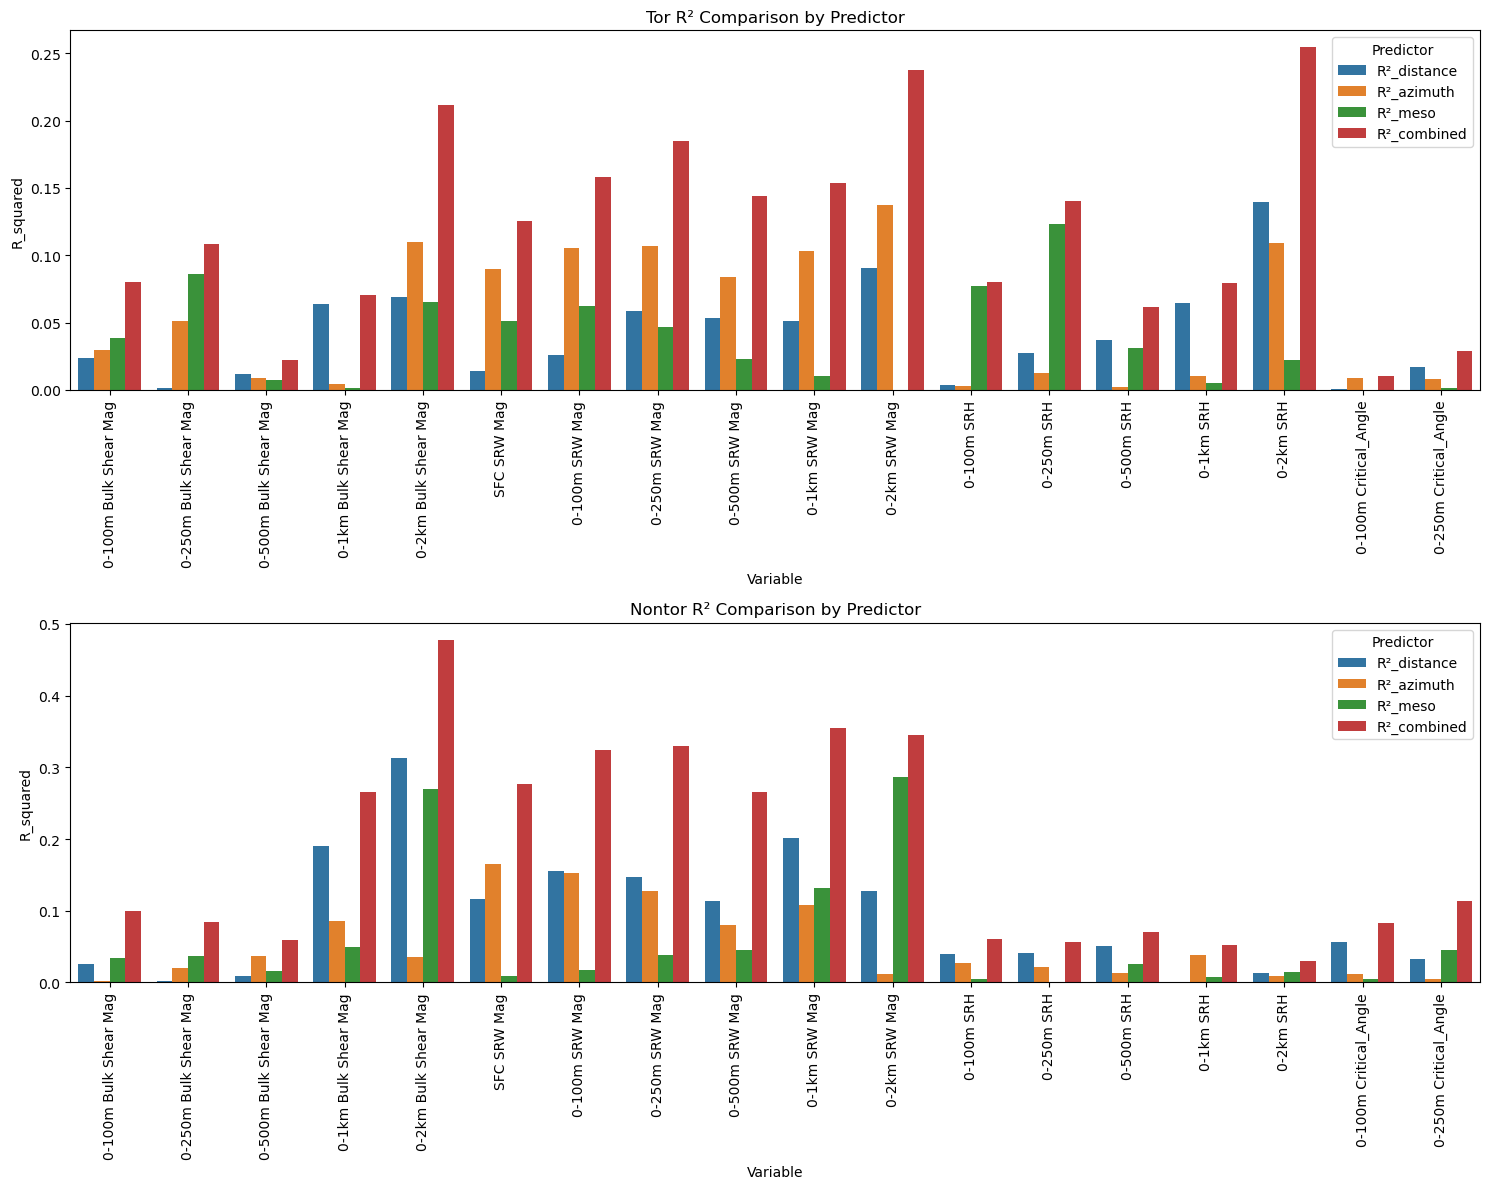

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: reshape to long format for easier plotting
plot_df = linear_reg_df.melt(id_vars=['T or NT', 'Variable'], 
                          value_vars=['R²_distance', 'R²_azimuth', 'R²_meso', 'R²_combined'],
                          var_name='Predictor', value_name='R_squared')

fig, axes = plt.subplots(2,1, figsize=(15, 12))
#plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df[plot_df['T or NT'] == 'tor'], ax = axes[0], x='Variable', y='R_squared', hue='Predictor')
#axes[0].set_xticks(rotation=90)
axes[0].set_title('Tor R² Comparison by Predictor')
labels = axes[0].get_xticklabels()
plt.setp(labels, rotation=90, horizontalalignment='center')

sns.barplot(data=plot_df[plot_df['T or NT'] == 'nontor'], ax = axes[1], x='Variable', y='R_squared', hue='Predictor')
#axes[1].set_xticks(rotation=90)
axes[1].set_title('Nontor R² Comparison by Predictor')
labels = axes[1].get_xticklabels()
plt.setp(labels, rotation=90, horizontalalignment='center')

plt.tight_layout()
plt.show()

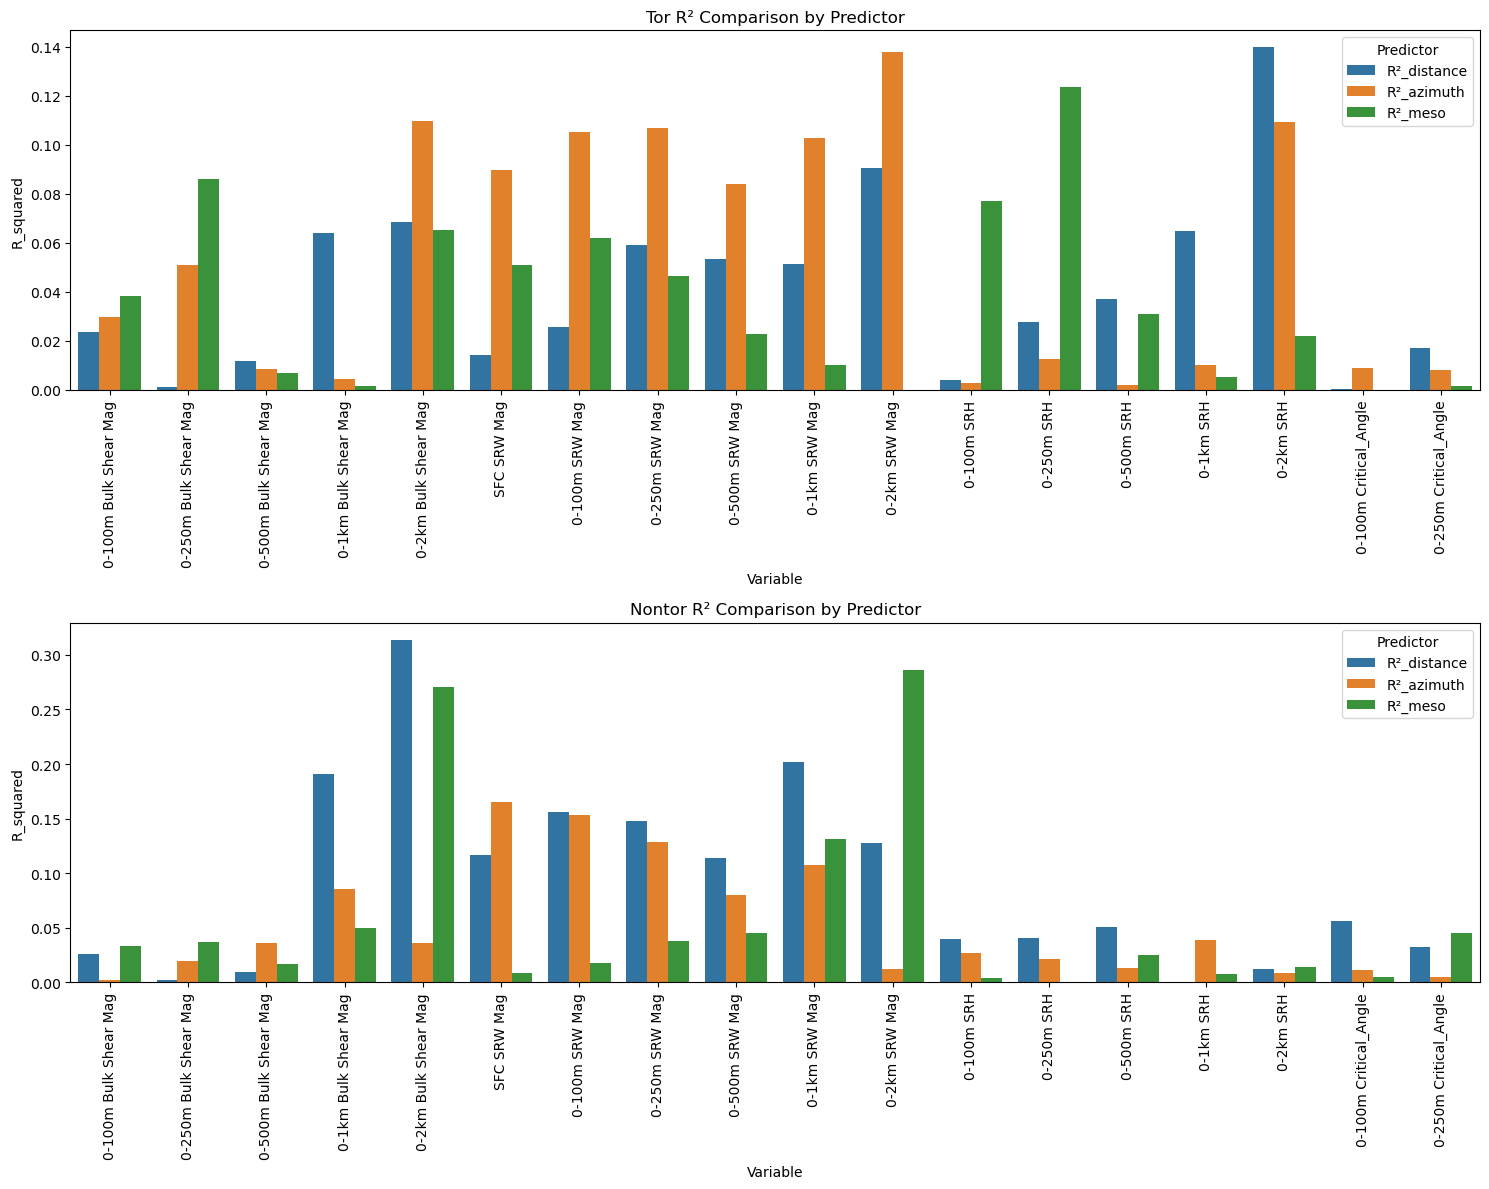

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: reshape to long format for easier plotting
plot_df = linear_reg_df.melt(id_vars=['T or NT', 'Variable'], 
                          value_vars=['R²_distance', 'R²_azimuth', 'R²_meso'],
                          var_name='Predictor', value_name='R_squared')

fig, axes = plt.subplots(2,1, figsize=(15, 12))
#plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df[plot_df['T or NT'] == 'tor'], ax = axes[0], x='Variable', y='R_squared', hue='Predictor')
#axes[0].set_xticks(rotation=90)
axes[0].set_title('Tor R² Comparison by Predictor')
labels = axes[0].get_xticklabels()
plt.setp(labels, rotation=90, horizontalalignment='center')

sns.barplot(data=plot_df[plot_df['T or NT'] == 'nontor'], ax = axes[1], x='Variable', y='R_squared', hue='Predictor')
#axes[1].set_xticks(rotation=90)
axes[1].set_title('Nontor R² Comparison by Predictor')
labels = axes[1].get_xticklabels()
plt.setp(labels, rotation=90, horizontalalignment='center')

plt.tight_layout()
plt.show()

In [ ]:
plot_df

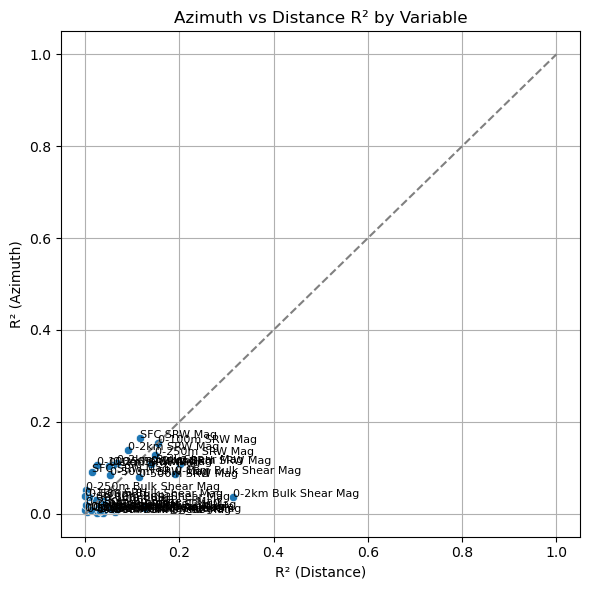

In [137]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=linear_reg_df, x='R²_distance', y='R²_azimuth')

# Add 1:1 reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

for _, row in linear_reg_df.iterrows():
    plt.text(row['R²_distance'], row['R²_azimuth'], row['Variable'], fontsize=8)

plt.xlabel('R² (Distance)')
plt.ylabel('R² (Azimuth)')
plt.title('Azimuth vs Distance R² by Variable')
plt.grid(True)
plt.tight_layout()
plt.show()


In [138]:
linear_results_t = []
for var in dep_var_names:

    df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)]
    df = df.copy()
    df = df[df['Time From Tor (min)'] != 'nontor']
    df['Time From Tor (min)'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')
    
    y = df[var].dropna()
    
    # Make sure X and y align
    X_time = df.loc[y.index, ['Time From Tor (min)']]
    
    # Add constant term
    X_time_const = sm.add_constant(X_time)
    
    # Fit models
    model_time = sm.OLS(y, X_time_const).fit()
    
    # Optional: Combined model
   # X_both = df.loc[y.index, ['Distance', 'Angle']]
    #X_both_const = sm.add_constant(X_both)
   # model_both = sm.OLS(y, X_both_const).fit()
    
    # Save results
    linear_results_t.append({
        'Variable': var,
        'R²_timefromtor': model_time.rsquared,
        #'R²_azimuth': model_azim.rsquared,
        #'R²_combined': model_both.rsquared
    })

# Turn into a DataFrame for easy viewing
linear_reg_t_df = pd.DataFrame(linear_results_t)

# Sort by highest R² if desired
linear_reg_t_df = linear_reg_t_df#.sort_values(by='R²_timefromtor', ascending=False)

print(linear_reg_t_df)

                 Variable  R²_timefromtor
0   0-100m Bulk Shear Mag        0.016645
1   0-250m Bulk Shear Mag        0.088521
2   0-500m Bulk Shear Mag        0.044575
3    0-1km Bulk Shear Mag        0.014353
4    0-2km Bulk Shear Mag        0.129467
5             SFC SRW Mag        0.092692
6          0-100m SRW Mag        0.068807
7          0-250m SRW Mag        0.059965
8          0-500m SRW Mag        0.017498
9           0-1km SRW Mag        0.000514
10          0-2km SRW Mag        0.025272
11             0-100m SRH        0.125747
12             0-250m SRH        0.249669
13             0-500m SRH        0.180211
14              0-1km SRH        0.022760
15              0-2km SRH        0.004298
16  0-100m Critical_Angle        0.062054
17  0-250m Critical_Angle        0.028443


In [139]:
both_lin_reg = pd.concat([linear_reg_df[linear_reg_df['T or NT'] == 'tor'], linear_reg_t_df['R²_timefromtor']], axis=1)

In [140]:
both_lin_reg

,T or NT,Variable,R²_distance,R²_azimuth,R²_meso,R²_combined,R²_timefromtor
0,tor,0-100m Bulk Shear Mag,0.023777,0.029847,0.038372,0.080497,0.016645
1,tor,0-250m Bulk Shear Mag,0.001362,0.050866,0.086117,0.108191,0.088521
2,tor,0-500m Bulk Shear Mag,0.011760,0.008746,0.007118,0.022580,0.044575
3,tor,0-1km Bulk Shear Mag,0.064086,0.004310,0.001725,0.070674,0.014353
4,tor,0-2km Bulk Shear Mag,0.068715,0.109873,0.065452,0.211496,0.129467
5,tor,SFC SRW Mag,0.014369,0.089864,0.051040,0.125534,0.092692
6,tor,0-100m SRW Mag,0.025675,0.105073,0.062008,0.158332,0.068807
7,tor,0-250m SRW Mag,0.058957,0.106862,0.046521,0.184681,0.059965
8,tor,0-500m SRW Mag,0.053556,0.084132,0.022874,0.143900,0.017498
9,tor,0-1km SRW Mag,0.051311,0.102844,0.010327,0.153622,0.000514


In [141]:
both_lin_reg.sort_values(by='R²_timefromtor', ascending=False)

,T or NT,Variable,R²_distance,R²_azimuth,R²_meso,R²_combined,R²_timefromtor
12,tor,0-250m SRH,0.027678,0.012732,0.123582,0.140504,0.249669
13,tor,0-500m SRH,0.037207,0.001999,0.030871,0.061679,0.180211
4,tor,0-2km Bulk Shear Mag,0.068715,0.109873,0.065452,0.211496,0.129467
11,tor,0-100m SRH,0.003918,0.002865,0.077053,0.079826,0.125747
5,tor,SFC SRW Mag,0.014369,0.089864,0.051040,0.125534,0.092692
1,tor,0-250m Bulk Shear Mag,0.001362,0.050866,0.086117,0.108191,0.088521
6,tor,0-100m SRW Mag,0.025675,0.105073,0.062008,0.158332,0.068807
16,tor,0-100m Critical_Angle,0.000416,0.008980,0.000001,0.010310,0.062054
7,tor,0-250m SRW Mag,0.058957,0.106862,0.046521,0.184681,0.059965
2,tor,0-500m Bulk Shear Mag,0.011760,0.008746,0.007118,0.022580,0.044575


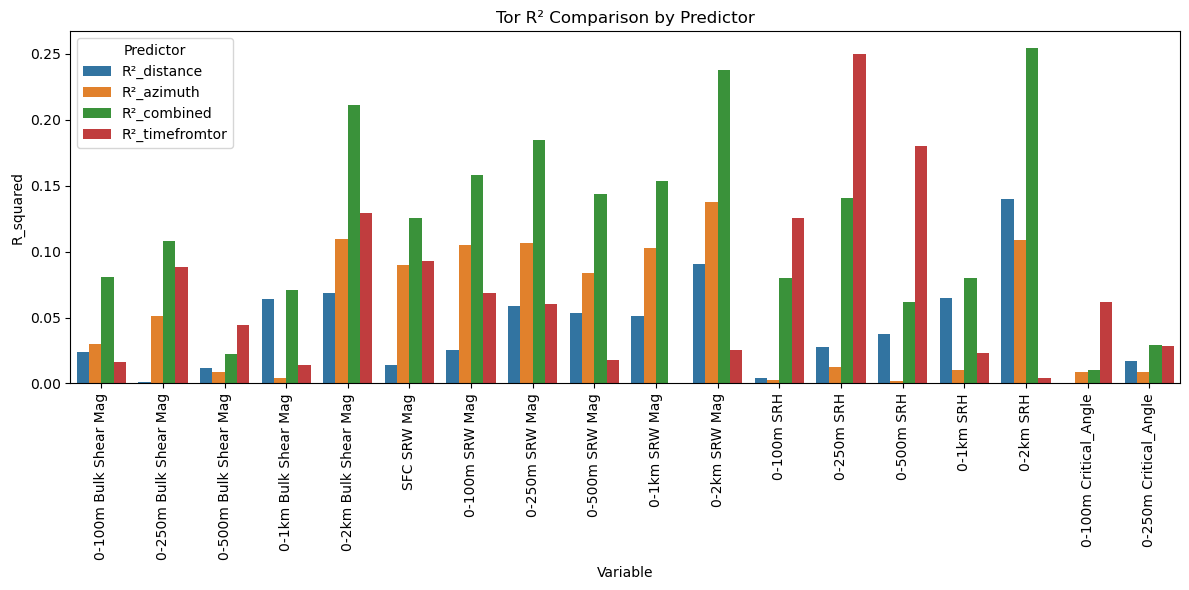

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: reshape to long format for easier plotting
plot_df = both_lin_reg.melt(id_vars='Variable', 
                          value_vars=['R²_distance', 'R²_azimuth', 'R²_combined', 'R²_timefromtor'],
                          var_name='Predictor', value_name='R_squared')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Variable', y='R_squared', hue='Predictor')
plt.xticks(rotation=90)
plt.title('Tor R² Comparison by Predictor')
plt.tight_layout()
plt.show()

# Stepwise Regression

In [143]:
import statsmodels.api as sm
from scipy.stats import pearsonr
# --- Stepwise function (from earlier) ---
def stepwise_selection(X, y,
                       initial_features=[],
                       threshold_in= 0.15,#0.05,
                       threshold_out= 0.15,#0.10,
                       verbose=False):
    included = list(initial_features)
    while True:
        changed = False

        # Forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_col]]))).fit()
            new_pval[new_col] = model.pvalues.get(new_col, 1.0)
        best_pval = new_pval.min() if not new_pval.empty else None
        if best_pval is not None and best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True

        # Backward step
        if included:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
            pvalues = model.pvalues.iloc[1:]  # exclude intercept
            worst_pval = pvalues.max() if not pvalues.empty else None
            if worst_pval is not None and worst_pval > threshold_out:
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                changed = True

        if not changed:
            break

    return included

In [144]:
dep_var_names = ['0-100m Bulk Shear Mag',
     '0-250m Bulk Shear Mag',
     '0-500m Bulk Shear Mag',
     '0-1km Bulk Shear Mag',
     '0-2km Bulk Shear Mag',
     'SFC SRW Mag',
     '0-100m SRW Mag',
     '0-250m SRW Mag',
     '0-500m SRW Mag',
     '0-1km SRW Mag',
     '0-2km SRW Mag',
     '0-100m SRH',
     '0-250m SRH',
     '0-500m SRH',
     '0-1km SRH',
     '0-2km SRH',
     '0-100m Critical_Angle',
     '0-250m Critical_Angle',
     '0-500m Critical_Angle']

In [ ]:
# Predictors — you can expand this list
predictors = ['Meso Max']#, 'Distance', 'Angle']#, 'Time From Tor (min)']

results = []
#df = df_all_new.copy()

#df['Time From Tor (min)'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')
#df = df[(df['u or v'] == 'v') & (df['Distance'] < 50) & (df['Angle'] <= 90)]

for tnt in ['tor', 'nontor']:
    df = df_all_new.copy()
    df = df[(df['u or v'] == 'v') & (df['Distance'] < 50) & (df['Angle'] <= 90)]
    df = df[df['Tor or Nontor'] == tnt]
    
    for var in predictors:  
        y = df[var].dropna()
        if y.empty:
            continue  # Skip if no data
    
        # Align X to y
        X = df.loc[y.index, dep_var_names]
    
        # Stepwise feature selection
        selected = stepwise_selection(X, y)
    
        # Fit final model
        X_selected = sm.add_constant(X[selected])
        model = sm.OLS(y, X_selected).fit()

        #if len(selected) == 1:
            # Single predictor: standard Pearson r
            # predictor = selected[0]
            # r, p_corr = pearsonr(X[predictor], y)
        # else:
        #     # Multiple predictors: report multiple correlation coefficient R
        #     r = np.sqrt(model.rsquared)
        #     p_corr = None  # Not well-defined for multiple predictors
        
        # r_list = []
        # p_corr_list = []
        # for predictor in selected:
        #     r, p_corr = pearsonr(X[predictor], y)
        #     r_list.append(r)
        #     p_corr_list.append(p_corr)

        r_dict = {}
        p_corr_dict = {}

        for predictor in selected:
            r, p_corr = pearsonr(X[predictor], y)
            r_dict[predictor] = r
            p_corr_dict[predictor] = p_corr
    
        # Save results
        results.append({
            'Variable': var,
            'Selected Predictors': selected,
            'Adjusted R²': model.rsquared_adj,
            'AIC': model.aic,
            'BIC': model.bic,
            'p-values': model.pvalues.to_dict(),
            'r': r_dict,
            'p_corr': p_corr_dict,
            'Tor or Nontor': tnt,
        })

# Convert to DataFrame for easy viewing
    results_df = pd.DataFrame(results)

# Sort by Adjusted R² (optional)
#results_df = results_df.sort_values(by='Adjusted R²', ascending=False)

print(results_df[['Variable', 'Selected Predictors', 'Adjusted R²']])

# KDE Distributions

In [ ]:
def mean_and_CI(data, confidence_level):
    
    x = np.nanmean(data, axis=0)
    degrees_freedom = len(data) - 1
    x_strd_error = stats.sem(data, nan_policy='omit')
    x_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=x, scale=x_strd_error)
    return x, x_95conf

In [ ]:
def kde_plot(df, col, hue, figsize, label, title, color_tor, color_nontor, tor_mean, nontor_mean, tor_CI, nontor_CI, ci):
    
    fig = plt.figure(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, label = label)
                    
    plt.title(title)
    
    plt.axvspan(tor_CI[0], tor_CI[1], color=color_tor, alpha=0.2, label=f'Tor {ci}% CI')
    plt.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label=f'Nontor {ci}% CI')
    plt.axvline(tor_mean, color=color_tor, label=f'Mean Tor:{tor_mean:.2f}')
    plt.axvline(nontor_mean, color=color_nontor, label=f'Mean Nontor:{nontor_mean:.2f}')
    plt.grid()
    plt.tight_layout()
    plt.legend()
    plt.show()

In [ ]:
def kde_plot_plus(df, col, hue, figsize, title, colors, means, CIs, labels, c_i):
    
    fig, ax = plt.subplots(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, ax=ax)

    for c, m, ci, l in zip(colors, means, CIs, labels):
        torpltCI = ax.axvspan(ci[0], ci[1], color=c, alpha=0.2, label=f'{l} {c_i}% CI')
        #nontorpltCI = ax.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label='Nontor 95% CI')
        torline = ax.axvline(m, color=c, label=f'{l}: {m:.2f}')
        #nontorline = ax.axvline(nontor_mean, color=color_nontor, label='Mean Nontor')
        #handles, labels = ax.get_legend_handles_labels()
        #ax.legend(handles=handles, labels=labels)
    ax.grid(True)
    ax.set_title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## df_all_new

In [ ]:
dftor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
dfnontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']

In [ ]:
dftor

In [ ]:
#plt.figure(figsize = (12, 4))
df = df_all_new
p = so.Plot(df, x='0-2km SRH', color='Tor or Nontor').add(sns.objects.Area(), 
                                                          sns.objects.KDE(common_norm=False)).label(title = 'KDE Tor Nontor 0-2km SRH NEW').layout(size=(5,3))
p.show()

In [ ]:
tor_02_v_mean, tor_02_v_CI = mean_and_CI(dftor[dftor['u or v'] == 'v']['195'], 0.95)
nontor_02_v_mean, nontor_02_v_CI = mean_and_CI(dfnontor[dfnontor['u or v'] == 'v']['195'], 0.95)

In [ ]:
tor_02_v_mean

In [ ]:
def kde_plot(df, col, hue, figsize, title, color_tor, color_nontor, tor_mean, nontor_mean, tor_CI, nontor_CI):
    
    fig, ax = plt.subplots(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, ax=ax)
    
    torpltCI = ax.axvspan(tor_CI[0], tor_CI[1], color=color_tor, alpha=0.2, label='Tor 95% CI')
    nontorpltCI = ax.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label='Nontor 95% CI')
    torline = ax.axvline(tor_mean, color=color_tor, label='Mean Tor')
    nontorline = ax.axvline(nontor_mean, color=color_nontor, label='Mean Nontor')
    handles, labels = ax.get_legend_handles_labels()
    #ax.legend(handles=handles, labels=labels)
    ax.grid(True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## u and v

### uv_avg_comp (skews results because it has pretor, dtor, and posttor entries all as their own 'tor' labelled section, inflating the tor sample numbers)
good for plotting pretor, dtor, etc relationships though

In [ ]:
uv_avg_comp

In [ ]:
avg_pretor_02_v, pretorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'pretor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_dtor_02_v, dtorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'dtor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_posttor_02_v, posttorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'posttor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'nontor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
print(f'pretor:{avg_pretor_02_v}')
print(f'dtor:{avg_dtor_02_v}')
print(f'posttor:{avg_posttor_02_v}')
print(f'nontor:{avg_nontor_02_v}')

kde_plot_plus(uv_avg_comp, 195, 'Tor Time', (7,3), 'Tor Times 0-2km SRW v Component Averaged Per IOP', ['tab:blue', 'orange', 'green', 'tab:red'], 
         [avg_pretor_02_v, avg_dtor_02_v, avg_posttor_02_v, avg_nontor_02_v], [pretorvCI, dtorvCI, posttorvCI, nontorvCI])

In [ ]:
avg_pretor_02_v, pretorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'pretor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
avg_dtor_02_v, dtorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'dtor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
avg_posttor_02_v, posttorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'posttor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'nontor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
print(f'pretor:{avg_pretor_02_v}')
print(f'dtor:{avg_dtor_02_v}')
print(f'posttor:{avg_posttor_02_v}')
print(f'nontor:{avg_nontor_02_v}')

kde_plot_plus(uv_avg_comp, 0, 'Tor Time', (7,3), 'Tor Times SFC SRW v Component Averaged Per IOP', ['tab:blue', 'orange', 'green', 'tab:red'], 
         [avg_pretor_02_v, avg_dtor_02_v, avg_posttor_02_v, avg_nontor_02_v], [pretorvCI, dtorvCI, posttorvCI, nontorvCI])

In [ ]:
avg_tor_02_v, torvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'tor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'nontor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(uv_avg_comp, 195, 'Tor or Nontor', (7,3), 'Tor vs Nontor 0-2km SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI)

In [ ]:
avg_tor_02_v, torvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'tor') & (uv_avg_comp['u or v']=='u') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'nontor') & (uv_avg_comp['u or v']=='u') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(uv_avg_comp, 195, 'Tor or Nontor', (7,3), 'Tor vs Nontor 0-2km SRW u Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI)

In [ ]:
avg_tor_02_v, torvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'tor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'nontor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(uv_avg_comp, 195, 'Tor or Nontor', (7,3), 'Tor vs Nontor SFC SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI)

### uv_avg_comp_dates (u and v components) (fixes skewness because it averages pretor etc per IOP before being composited)

In [ ]:
uv_avg_comp_dates

In [ ]:
tor_vs_nontor_perc_dif = pd.DataFrame()

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 195, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor 0-2km SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), use_continuity=False, 
                             alternative='greater')

stat, p = ttest_ind(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), equal_var=False, 
                             alternative='greater')

eep = pd.DataFrame()
eep['u or v'] = ['v']
eep['Height'] = ['0-2km']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)
print(p_value)
print(f't-test: {p}')

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 100, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor 0-1km SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), use_continuity=False, 
                             alternative='greater') 

stat, p = ttest_ind(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), equal_var=False, 
                             alternative='greater') 
print(f't-test: {p}')

eep = pd.DataFrame()
eep['u or v'] = ['v']
eep['Height'] = ['0-1km']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)
print(p_value)

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 0, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor SFC SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), use_continuity=False,
                            alternative='greater') 

stat, p = ttest_ind(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), equal_var=False,
                            alternative='greater') 
print(p_value)
print(f't-test: {p}')


eep = pd.DataFrame()
eep['u or v'] = ['v']
eep['Height'] = ['SFC']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 0, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor SFC SRW u Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), use_continuity=False,
                            alternative='greater') 

print(p_value)

eep = pd.DataFrame()
eep['u or v'] = ['u']
eep['Height'] = ['SFC']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 100, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor 0-1km SRW u Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), use_continuity=False,
                            alternative='greater') 

print(p_value)

eep = pd.DataFrame()
eep['u or v'] = ['u']
eep['Height'] = ['0-1km']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 195, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor 0-2km SRW u Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), use_continuity=False,
                            alternative='greater') 

print(p_value)

eep = pd.DataFrame()
eep['u or v'] = ['u']
eep['Height'] = ['0-2km']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
tor_vs_nontor_perc_dif

In [ ]:
srw_all = []
srw_sfc = []

for d in set(uv_avg_comp_dates['Date']):

    
    df_u = uv_avg_comp_dates[(uv_avg_comp_dates['Date'] == d) & (uv_avg_comp_dates['u or v'] == 'u')]
    df_v = uv_avg_comp_dates[(uv_avg_comp_dates['Date'] == d) & (uv_avg_comp_dates['u or v'] == 'v')]

    bulkshear0500 = bulk_shear(df_u.iloc[:,3], df_v.iloc[:,3], df_u.iloc[:,54], df_v.iloc[:,54])
    bulkshear01 = bulk_shear(df_u.iloc[:,3], df_v.iloc[:,3], df_u.iloc[:,104], df_v.iloc[:,104])
    bulkshear02 = bulk_shear(df_u.iloc[:,3], df_v.iloc[:,3], df_u.iloc[:,198], df_v.iloc[:,198])

    uv_avg_comp_dates.loc[df_u.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    uv_avg_comp_dates.loc[df_u.index, '0-1km Bulk Shear Mag'] = bulkshear01
    uv_avg_comp_dates.loc[df_u.index, '0-2km Bulk Shear Mag'] = bulkshear02
    
    uv_avg_comp_dates.loc[df_v.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    uv_avg_comp_dates.loc[df_v.index, '0-1km Bulk Shear Mag'] = bulkshear01
    uv_avg_comp_dates.loc[df_v.index, '0-2km Bulk Shear Mag'] = bulkshear02
    
    srw_values_sfc = comp_srw(df_u, df_v, 0)
    
    uv_avg_comp_dates.loc[df_u.index, 'SFC SRW Mag'] = srw_values_sfc  # Assign to correct indices
    uv_avg_comp_dates.loc[df_v.index, 'SFC SRW Mag'] = srw_values_sfc

    srw_values_500 = comp_srw(df_u, df_v, 54)
    
    uv_avg_comp_dates.loc[df_u.index, '0-500m SRW Mag'] = srw_values_500  # Assign to correct indices
    uv_avg_comp_dates.loc[df_v.index, '0-500m SRW Mag'] = srw_values_500

    srw_values_1km = comp_srw(df_u, df_v, 104)
    
    uv_avg_comp_dates.loc[df_u.index, '0-1km SRW Mag'] = srw_values_1km  # Assign to correct indices
    uv_avg_comp_dates.loc[df_v.index, '0-1km SRW Mag'] = srw_values_1km

    srw_values_2km = comp_srw(df_u, df_v, 198)
    uv_avg_comp_dates.loc[df_u.index, '0-2km SRW Mag'] = srw_values_2km  # Assign to correct indices
    uv_avg_comp_dates.loc[df_v.index, '0-2km SRW Mag'] = srw_values_2km

## SRW SRH

### avg_all_comp_per_date (SRH, SRW) (fixes skewness because it averages pretor etc per IOP before being composited)

#### Tor vs Nontor

##### SRW

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)

perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
tor_vs_nontor_perc_dif

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-2km SRW Mag',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRW'
h = '0-1km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
tor_vs_nontor_perc_dif

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-1km SRW Mag',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRW'
h = 'SFC'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor SFC SRW',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRW'
h = '0-500m'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-500m SRW',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

##### SRH

In [ ]:
srw_or_srh = 'SRH'
h = '0-2km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-2km SRH',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRH'
h = '0-1km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-1km SRH',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRH'
h = '0-500m'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-500m SRH',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

##### Bulk Shear

In [ ]:
srw_or_srh = 'Bulk Shear'
h = '0-500m'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-500m Bulk Shear',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'Bulk Shear'
h = '0-1km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-1km Bulk Shear',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'Bulk Shear'
h = '0-2km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-2km Bulk Shear',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

##### Critical Angle

In [ ]:
srw_or_srh = 'Critical Angle'
h = '0-500m'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)

perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-500m Critical Angle',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
tor_vs_nontor_perc_dif.sort_values(by='% Diff')

#### NF vs FF

In [ ]:
dist_angle_avg_date

##### SRW

In [ ]:
srw_or_srh = 'SRW'
h = 'SFC'
col = 'Dist avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'nf'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'ff'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'nf'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'ff'][col], 0.85)

print(f' nf tor: {nftor02srwmean}')
print(f' ff tor: {fftor02srwmean}')
print(f' nf nontor: {nfnontor02srwmean}')
print(f' ff nontor: {ffnontor02srwmean}')

In [ ]:
kde_plot_plus(dftor, col, 'NF or FF', (7,3), 'KDE Tor NF vs FF SFC SRW 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['nf', 'ff'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'NF or FF', (7,3), 'KDE Nontor NF vs FF SFC SRW 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['nf', 'ff'], 85)

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
col = 'Dist avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'nf'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'ff'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'nf'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'ff'][col], 0.85)

print(f' nf tor: {nftor02srwmean}')
print(f' ff tor: {fftor02srwmean}')
print(f' nf nontor: {nfnontor02srwmean}')
print(f' ff nontor: {ffnontor02srwmean}')

In [ ]:
kde_plot_plus(dftor, col, 'NF or FF', (7,3), 'KDE Tor NF vs FF 0-2km SRW 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['nf', 'ff'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'NF or FF', (7,3), 'KDE Nontor NF vs FF 0-2km SRW 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['nf', 'ff'], 85)

##### SRH

In [ ]:
srw_or_srh = 'SRH'
h = '0-2km'
col = 'Dist avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'nf'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'ff'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'nf'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'ff'][col], 0.85)

print(nftor02srwmean)
print(fftor02srwmean)
print(nfnontor02srwmean)
print(ffnontor02srwmean)

In [ ]:
kde_plot_plus(dftor, col, 'NF or FF', (7,3), 'KDE Tor NF vs FF 0-2km SRH 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['nf', 'ff'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'NF or FF', (7,3), 'KDE Nontor NF vs FF 0-2km SRH 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['nf', 'ff'], 85)

##### Critical Angle

In [ ]:
srw_or_srh = 'Critical Angle'
h = '0-500m'
col = 'Dist avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'nf'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'ff'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'nf'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'ff'][col], 0.85)

print(nftor02srwmean)
print(fftor02srwmean)
print(nfnontor02srwmean)
print(ffnontor02srwmean)

In [ ]:
kde_plot_plus(dftor, col, 'NF or FF', (7,3), 'KDE TOR NF vs FF 0-500m Critical Angle 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['nf', 'ff'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'NF or FF', (7,3), 'KDE NONTOR NF vs FF 0-500m Critical Angle 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['nf', 'ff'], 85)

#### 0-45 vs 45-90

##### Critical Angle

In [ ]:
srw_or_srh = 'Critical Angle'
h = '0-500m'
col = 'Angle avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['Angle'] == '0-45'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['Angle'] == '45-90'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['Angle'] == '0-45'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['Angle'] == '45-90'][col], 0.85)

print(nftor02srwmean)
print(fftor02srwmean)
print(nfnontor02srwmean)
print(ffnontor02srwmean)

In [ ]:
kde_plot_plus(dftor, col, 'Angle', (7,3), 'KDE TOR 0-45 vs 45-90 0-500m Critical Angle 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['0-45', '45-90'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'Angle', (7,3), 'KDE NONTOR 0-45 vs 45-90 0-500m Critical Angle 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['0-45', '45-90'], 85)

### avg_comp df (SRW, SRH), skews results because it has pretor, dtor, and posttor entries all as their own 'tor' labelled section, inflating the tor sample numbers
Good for plotting the pretor, dtor, posttor relationships though

In [ ]:
avg_comp

#### SRW

In [ ]:
kde_plot(avg_comp, 'Dist avg', 'Tor Time', (7,3), 'KDE Tor Nontor SFC NF SRW NEW',
         'blue', 'red', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI)

In [ ]:
srw_or_srh = 'SRW'
h = 'SFC'
nforff = 'nf'
df = avg_comp
df = df[(df['SRW or SRH'] == srw_or_srh) & (df['Height'] == h) & (df['NF or FF'] == 'nf')]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.95)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.95)
print(tor02srwmean)
print(nontor02srwmean)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor or Nontor', (7,3), 'KDE Tor Nontor SFC NF SRW NEW',
         'blue', 'red', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI)

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
nforff = 'nf'
df = avg_comp
df = df[(df['SRW or SRH'] == srw_or_srh) & (df['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.95)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.95)
print(tor02srwmean)
print(nontor02srwmean)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor or Nontor', (7,3), 'KDE Tor Nontor 0-2km SRW NEW',
         'blue', 'red', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI)

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
nforff = 'nf'
df = avg_comp
df = df[(df['SRW or SRH'] == srw_or_srh) & (df['Height'] == h) & (df['NF or FF'] == 'nf')]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.95)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.95)
print(tor02srwmean)
print(nontor02srwmean)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor or Nontor', (7,3), 'KDE Tor Nontor 0-2km NF SRW NEW',
         'blue', 'red', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI)

In [ ]:
toronly = summary[summary['Tor Time'] != 'nontor']

In [ ]:
toronly

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
#nforff = 'nf'
df = toronly
df = df[(df['SRW or SRH'] == srw_or_srh) & (df['Height'] == h)]
dfpretor = df[df['Tor Time'] == 'pretor']
dfdtor = df[df['Tor Time'] == 'dtor']
dfposttor = df[df['Tor Time'] == 'posttor']
#dfnontor = df[df['Tor or Nontor'] == 'nontor']
tor02premean, tor02preCI = mean_and_CI(dfpretor['Dist avg'], 0.95)
tor02dmean, tor02dCI = mean_and_CI(dfdtor['Dist avg'], 0.95)
tor02postmean, tor02postCI = mean_and_CI(dfposttor['Dist avg'], 0.95)
# nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.95)
#print(tor02srwmean)
#print(nontor02srwmean)

In [ ]:
tor02premean

In [ ]:
tor02dmean

In [ ]:
tor02postmean

In [ ]:
kde_plot(toronly, 'Dist avg', 'Tor Time', (7,3), 'KDE Tor Time 0-2km SRH', 'red', 'blue', tor02premean, tor02dmean, tor02preCI, tor02dCI)

## df_all_new (not composited beforehand stats)

In [ ]:
tor_02_v_mean, tor_02_v_CI = mean_and_CI(dftor[dftor['u or v'] == 'v']['195'], 0.95)
nontor_02_v_mean, nontor_02_v_CI = mean_and_CI(dfnontor[dfnontor['u or v'] == 'v']['195'], 0.95)

In [ ]:
kde_plot(df_all_new[df_all_new['u or v'] == 'v'], '195', 'Tor or Nontor', (7,3), 'SRW v component (m/s)', 'KDE Tor Nontor 0-2km SRW v NEW',
         'blue', 'red', tor_02_v_mean, nontor_02_v_mean, tor_02_v_CI, nontor_02_v_CI)

In [ ]:
#plt.figure(figsize = (12, 4))
df = df_all_new
df = df[df['u or v'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x='195', hue='Tor or Nontor', common_norm=False, label = 'SRW v component (m/s)')
                
plt.title('KDE Tor Nontor 0-2km SRW v NEW')

plt.axvspan(tor_02_v_CI[0], tor_02_v_CI[1], color='blue', alpha=0.2, label='Tor 95% CI')
plt.axvspan(nontor_02_v_CI[0], nontor_02_v_CI[1], color='red', alpha=0.2, label='Nontor 95% CI')
plt.axvline(tor_02_v_mean, color='blue', label='Mean Tor')
plt.axvline(nontor_02_v_mean, color='red', label='Mean Nontor')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
tor_02_srh_mean, tor_02_srh_CI = mean_and_CI(dftor['0-2km SRH'], 0.95)
nontor_02_srh_mean, nontor_02_srh_CI = mean_and_CI(dfnontor['0-2km SRH'], 0.95)

In [ ]:
kde_plot(df_all_new, '0-2km SRH', 'Tor or Nontor', (7,3), '0-2km SRH (m2/s2)', 'KDE Tor Nontor 0-2km SRH NEW',
         'blue', 'red', tor_02_srh_mean, nontor_02_srh_mean, tor_02_srh_CI, nontor_02_srh_CI)

## Older comp way

In [ ]:
spec_comp

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
#nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
#spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {h} {srw_or_srh} Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
#nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
#spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)
print(f'tor {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {srw_or_srh} mean: {comp_nontor_02_srh_mean}')
kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {h} {srw_or_srh} Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {nforff} {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {nforff} {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {nforff} {h} {srw_or_srh} Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
spec_comp_datetor

In [ ]:
np.shape(spec_comp_datetor[col])

DOF are number of IOPs (assuming one supercell per IOP), like CP2020.

In [ ]:
comp_tor_02_srh_mean

In [ ]:
comp_nontor_02_srh_mean

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {nforff} {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {nforff} {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {nforff} {h} {srw_or_srh} Mag Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
comp_tor_02_srh_mean

In [ ]:
comp_nontor_02_srh_mean

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'ff'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {nforff} {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {nforff} {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {nforff} {h} {srw_or_srh} Mag Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'ff'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {nforff} {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {nforff} {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {nforff} {h} {srw_or_srh} Mag Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

# Permutation tests and p-values 

In [ ]:
def test_stat(x, y):
    return np.nanmean(x) - np.nanmean(y)

from scipy.stats import permutation_test

## tor vs nontor

### u test FOR ALL categories

In [ ]:
avg_all_comp_per_date

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = avg_all_comp_per_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH'])

# Loop over each group
for (height, param), group in grouped:
    # Split into tornadic and nontornadic
    tor = group[group['Tor Time'] == 'tor']['Dist avg'].dropna()
    nontor = group[group['Tor Time'] == 'nontor']['Dist avg'].dropna()

    # Only run test if both groups have enough data
    if len(tor) > 1 and len(nontor) > 1:
        stat, p_value = mannwhitneyu(tor, nontor, use_continuity=False, alternative='greater')  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean(),
            'Nontornadic Mean': nontor.mean(),
            'p-value': p_value,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df = results_df.sort_values(by='p-value')


In [ ]:
results_df

In [ ]:
# p-values are the same for some rows, checking to make sure its not from duplicate values in the data itself
# Are the actual values identical across different label groups?
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor Time'])['Dist avg'].apply(list).reset_index()

# Check for identical lists across rows
grouped['Dist avg'] = grouped['Dist avg'].apply(lambda x: sorted([round(v, 6) for v in x]))  # rounding to clean float noise
dupes = grouped.duplicated(['Dist avg'], keep=False)
grouped[dupes]

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = avg_all_comp_per_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH'])

# Loop over each group
for (height, param), group in grouped:
    # Split into tornadic and nontornadic
    tor = group[group['Tor Time'] == 'tor']['Dist avg'].dropna()
    nontor = group[group['Tor Time'] == 'nontor']['Dist avg'].dropna()

    # Only run test if both groups have enough data
    if len(tor) > 1 and len(nontor) > 1:
        stat, p_value = mannwhitneyu(tor, nontor, use_continuity=False)  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean(),
            'Nontornadic Mean': nontor.mean(),
            'p-value': p_value,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_dfnogreater = results_df.sort_values(by='p-value')


In [ ]:
results_dfnogreater # how much different are the datasets from each other (checking mostly for critical angle since larger doesnt necessarily mean better)

In [ ]:
dist_angle_avg_date

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date

# Initialize lists to hold separate results
tor_results = []
nontor_results = []

# Group by Height and SRW/SRH

grouped = df.groupby(['Height', 'SRW or SRH'])

for param, param_group in df.groupby('SRW or SRH'):
    for height, group in param_group.groupby('Height'):
    # Get the two groups based on 'Tor or Nontor'
        tor_nf = group[(group['Tor or Nontor'] == 'tor') & (group['NF or FF'] == 'nf')]['Dist avg'].dropna()
        tor_ff = group[(group['Tor or Nontor'] == 'tor') & (group['NF or FF'] == 'ff')]['Dist avg'].dropna()
    
        nontor_nf = group[(group['Tor or Nontor'] == 'nontor') & (group['NF or FF'] == 'nf')]['Dist avg'].dropna()
        nontor_ff = group[(group['Tor or Nontor'] == 'nontor') & (group['NF or FF'] == 'ff')]['Dist avg'].dropna()
    
        # Tornadic NF vs FF
        #if len(tor_nf) > 1 and len(tor_ff) > 1:
        stat, p = mannwhitneyu(tor_nf, tor_ff, use_continuity=False)
        tor_results.append({
            'Height': height,
            'Variable': param,
            'NF Median': tor_nf.median(),
            'FF Median': tor_ff.median(),
            'diff': tor_nf.median() - tor_ff.median(),
            '%diff': 100 * ((tor_nf.median() - tor_ff.median()) / (tor_nf.median() + tor_ff.median())),
            'p-value': p,
            'NF IOPs': len(tor_nf),
            'FF IOPs': len(tor_ff)
        })
        
        # Nontornadic NF vs FF
        #if len(nontor_nf) > 1 and len(nontor_ff) > 1:
        stat, p = mannwhitneyu(nontor_nf, nontor_ff, use_continuity=False)
        nontor_results.append({
            'Height': height,
            'Variable': param,
            'NF Median': nontor_nf.median(),
            'FF Median': nontor_ff.median(),
            'diff': nontor_nf.median() - nontor_ff.median(),
            '%diff': 100 * ((nontor_nf.median() - nontor_ff.median()) / (nontor_nf.median() + nontor_ff.median())),
            'p-value': p,
            'NF IOPs': len(nontor_nf),
            'FF IOPs': len(nontor_ff)
        })

# Convert to DataFrames
tor_df_dist = pd.DataFrame(tor_results)#.sort_values(by='Height').sort_values(by='SRW or SRH')
nontor_df_dist = pd.DataFrame(nontor_results)#.sort_values(by='p-value')


In [ ]:
tor_df_dist.sort_values(by='%diff')

In [ ]:
tor_df_dist.round(2).to_csv('/Users/juliabman/Desktop/tor_dist.csv', sep='\t', index=False)

In [ ]:
nontor_df_dist.sort_values(by='%diff')

In [ ]:
nontor_df_dist.round(2).to_csv('/Users/juliabman/Desktop/nontor_dist.csv', sep='\t', index=False)

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date

# Initialize lists to hold separate results
tor_results = []
nontor_results = []

# Group by Height and SRW/SRH
grouped = df.groupby(['Height', 'SRW or SRH'])

#for (height, param), group in grouped:
for param, param_group in df.groupby('SRW or SRH'):
    for height, group in param_group.groupby('Height'):
    # Get the two groups based on 'Tor or Nontor'
        tor_nf = group[(group['Tor or Nontor'] == 'tor') & (group['Azimuth'] == '045')]['Angle avg'].dropna()
        tor_ff = group[(group['Tor or Nontor'] == 'tor') & (group['Azimuth'] == '4590')]['Angle avg'].dropna()
    
        nontor_nf = group[(group['Tor or Nontor'] == 'nontor') & (group['Azimuth'] == '045')]['Angle avg'].dropna()
        nontor_ff = group[(group['Tor or Nontor'] == 'nontor') & (group['Azimuth'] == '4590')]['Angle avg'].dropna()
    
        # Tornadic NF vs FF
        #if len(tor_nf) > 1 and len(tor_ff) > 1:
        stat, p = mannwhitneyu(tor_nf, tor_ff, use_continuity=False)
        tor_results.append({
            'Height': height,
            'SRW or SRH': param,
            'Forward Sector Median': tor_nf.median(),
            'Right Sector Median': tor_ff.median(),
            '%diff': 100 * ((tor_nf.median() - tor_ff.median()) / (tor_nf.median() + tor_ff.median())),
            'p-value': p,
            'Forward IOPs': len(tor_nf),
            'Right IOPs': len(tor_ff)
        })
        
        # Nontornadic NF vs FF
        #if len(nontor_nf) > 1 and len(nontor_ff) > 1:
        stat, p = mannwhitneyu(nontor_nf, nontor_ff, use_continuity=False)
        nontor_results.append({
            'Height': height,
            'SRW or SRH': param,
            'Forward Sector Median': nontor_nf.median(),
            'Right Sector Median': nontor_ff.median(),
            '%diff': 100 * ((nontor_nf.median() - nontor_ff.median()) / (nontor_nf.median() + nontor_ff.median())),
            'p-value': p,
            'Forward IOPs': len(nontor_nf),
            'Right IOPs': len(nontor_ff)
        })

# Convert to DataFrames
tor_df = pd.DataFrame(tor_results)
nontor_df = pd.DataFrame(nontor_results)


In [ ]:
tor_df.sort_values(by='%diff')

In [ ]:
tor_df.round(2).to_csv('/Users/juliabman/Desktop/tor_az.csv', sep='\t', index=False)

In [ ]:
nontor_df.sort_values(by='%diff')

In [ ]:
nontor_df.round(2).to_csv('/Users/juliabman/Desktop/nontor_az.csv', sep='\t', index=False)

In [ ]:
summary

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = summary

# Initialize lists to hold separate results
pretordtor_results = []
pretorposttor_results = []
pretornontor_results = []
dtornontor_results = []
posttornontor_results = []
# Group by Height and SRW/SRH

grouped = df.groupby(['Height', 'SRW or SRH'])

for param, param_group in df.groupby('SRW or SRH'):
    for height, group in param_group.groupby('Height'):
    # Get the two groups based on 'Tor or Nontor'
        tor_pretor = group[(group['Tor Time'] == 'pretor')]['Dist avg'].dropna()
        tor_dtor = group[(group['Tor Time'] == 'dtor')]['Dist avg'].dropna()
    
        tor_posttor = group[(group['Tor Time'] == 'posttor')]['Dist avg'].dropna()
        nontor = group[(group['Tor Time'] == 'nontor')]['Dist avg'].dropna()
    
        # Tornadic NF vs FF
        #if len(tor_nf) > 1 and len(tor_ff) > 1:
        stat, p = mannwhitneyu(tor_pretor, tor_dtor, use_continuity=False)
        pretordtor_results.append({
            'Height': height,
            'Variable': param,
            'Pretor Median': tor_pretor.median(),
            'Dtor Median': tor_dtor.median(),
            '%diff': 100 * ((tor_pretor.median() - tor_dtor.median()) / (tor_pretor.median() + tor_dtor.median())),
            'p-value': p,
            'Pretor IOPs': len(tor_pretor),
            'Dtor IOPs': len(tor_dtor)
        })
        
        # Nontornadic NF vs FF
        #if len(nontor_nf) > 1 and len(nontor_ff) > 1:
        stat, p = mannwhitneyu(tor_pretor, tor_posttor, use_continuity=False)
        pretorposttor_results.append({
            'Height': height,
            'Variable': param,
            'Pretor Median': tor_pretor.median(),
            'Posttor Median': tor_posttor.median(),
            '%diff': 100 * ((tor_pretor.median() - tor_posttor.median()) / (tor_pretor.median() + tor_posttor.median())),
            'p-value': p,
            'Pretor IOPs': len(tor_pretor),
            'Posttor IOPs': len(tor_posttor)
        })

        stat, p = mannwhitneyu(tor_pretor, nontor, use_continuity=False)
        pretornontor_results.append({
            'Height': height,
            'Variable': param,
            'Pretor Median': tor_pretor.median(),
            'Nontor Median': nontor.median(),
            '%diff': 100 * ((tor_pretor.median() - nontor.median()) / (tor_pretor.median() + nontor.median())),
            'p-value': p,
            'Pretor IOPs': len(tor_pretor),
            'Nontor IOPs': len(nontor)
        })

        stat, p = mannwhitneyu(tor_dtor, nontor, use_continuity=False)
        dtornontor_results.append({
            'Height': height,
            'Variable': param,
            'Dtor Median': tor_dtor.median(),
            'Nontor Median': nontor.median(),
            '%diff': 100 * ((tor_dtor.median() - nontor.median()) / (tor_dtor.median() + nontor.median())),
            'p-value': p,
            'Dtor IOPs': len(tor_dtor),
            'Nontor IOPs': len(nontor)
        })

        stat, p = mannwhitneyu(tor_posttor, nontor, use_continuity=False)
        posttornontor_results.append({
            'Height': height,
            'Variable': param,
            'Posttor Median': tor_posttor.median(),
            'Nontor Median': nontor.median(),
            '%diff': 100 * ((tor_posttor.median() - nontor.median()) / (tor_posttor.median() + nontor.median())),
            'p-value': p,
            'Posttor IOPs': len(tor_posttor),
            'Nontor IOPs': len(nontor)
        })
# Convert to DataFrames
pretordtor_df_dist = pd.DataFrame(pretordtor_results)#.sort_values(by='Height').sort_values(by='SRW or SRH')
pretorposttor_df_dist = pd.DataFrame(pretorposttor_results)#.sort_values(by='p-value')
pretornontor_df = pd.DataFrame(pretornontor_results)
dtornontor_df = pd.DataFrame(dtornontor_results)
posttornontor_df = pd.DataFrame(posttornontor_results)

In [ ]:
pretordtor_df_dist

In [ ]:
pretorposttor_df_dist

In [ ]:
pretornontor_df

In [ ]:
dtornontor_df

In [ ]:
posttornontor_df

In [76]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = summary  # Assuming 'summary' is already defined

# Function to compute Mann-Whitney U and summary stats
def compute_stats(group1, group2, label1, label2):
    if len(group1) > 0 and len(group2) > 0:
        stat, p = mannwhitneyu(group1, group2, use_continuity=False)
        median1 = group1.median()
        median2 = group2.median()
        #percent_diff = 100 * ((median1 - median2) / (median1 + median2)) if (median1 + median2) != 0 else 0 # this equation is wrong, should be average of denominator not sum
        #percent_diff = 100 * ((median1 - median2) / (median1 + median2)/2) if (median1 + median2) != 0 else 0
        percent_diff = 100 * ((median2 - median1) / (median1)) if (median1) != 0 else 0
        return {
            'Group 1': label1,
            'Group 2': label2,
            'Group 1 Median': median1,
            'Group 2 Median': median2,
            '%diff': percent_diff,
            'p-value': p,
            'Group 1 IOPs': len(group1),
            'Group 2 IOPs': len(group2)
        }
    return None

# Initialize result containers
results_dict = {
    'Pretor vs Dtor': [],
    'Pretor vs Posttor': [],
    'Pretor vs Nontor': [],
    'Dtor vs Posttor': [],
    'Dtor vs Nontor': [],
    'Posttor vs Nontor': []
}

# Group data
grouped = df.groupby(['SRW or SRH', 'Height'])

for (param, height), group in grouped:
    tor_pretor = group[group['Tor Time'] == 'pretor']['Dist avg'].dropna()
    tor_dtor = group[group['Tor Time'] == 'dtor']['Dist avg'].dropna()
    tor_posttor = group[group['Tor Time'] == 'posttor']['Dist avg'].dropna()
    nontor = group[group['Tor Time'] == 'nontor']['Dist avg'].dropna()

    comparisons = [
        ('Pretor vs Dtor', tor_pretor, tor_dtor, 'Pretor', 'Dtor'),
        ('Pretor vs Posttor', tor_pretor, tor_posttor, 'Pretor', 'Posttor'),
        ('Pretor vs Nontor', tor_pretor, nontor, 'Pretor', 'Nontor'),
        ('Dtor vs Posttor', tor_dtor, tor_posttor, 'Dtor', 'Posttor'),
        ('Dtor vs Nontor', tor_dtor, nontor, 'Dtor', 'Nontor'),
        ('Posttor vs Nontor', tor_posttor, nontor, 'Posttor', 'Nontor')
    ]

    for key, grp1, grp2, lbl1, lbl2 in comparisons:
        stats = compute_stats(grp1, grp2, lbl1, lbl2)
        if stats:
            stats.update({'Height': height, 'Variable': param, 'Comparison': key})
            results_dict[key].append(stats)

# Convert and label each result group
all_dfs = [pd.DataFrame(records) for records in results_dict.values()]
all_results_df = pd.concat(all_dfs, ignore_index=True)

# Concatenate all into one DataFrame
#all_results_df = pd.concat(all_dfs, ignore_index=True)
# Convert to DataFrames
# pretordtor_df = pd.DataFrame(results_dict['Pretor vs Dtor'])
# pretorposttor_df = pd.DataFrame(results_dict['Pretor vs Posttor'])
# pretornontor_df = pd.DataFrame(results_dict['Pretor vs Nontor'])
# dtorposttor_df = pd.DataFrame(results_dict['Dtor vs Posttor'])
# dtornontor_df = pd.DataFrame(results_dict['Dtor vs Nontor'])
# posttornontor_df = pd.DataFrame(results_dict['Posttor vs Nontor'])


In [ ]:
all_results_df

In [ ]:
all_results_df[all_results_df['p-value'] < 0.10]

In [ ]:
all_results_df.round(2).to_csv('/Users/juliabman/Desktop/all_tor_times_stats.csv', index=False)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot for heatmap
heat_df = all_results_df[all_results_df['p-value'] < 0.05].pivot_table(
    index='Height',
    columns='Variable',
    values='%diff',
    aggfunc='mean'
)

sns.heatmap(heat_df, annot=True, cmap='coolwarm', center=0)
plt.title('Mean % Difference (Significant Comparisons Only)')
plt.show()

In [77]:
# List of variables and comparisons you want to split by
variables = ['SRH', 'SRW', 'Bulk Shear', 'Critical Angle']
comparisons =  ['Pretor vs Dtor',
    'Pretor vs Posttor',
    'Pretor vs Nontor',
    'Dtor vs Posttor',
    'Dtor vs Nontor',
    'Posttor vs Nontor']

# Store the tables in a nested dictionary for later access or export
subtables = {}

for var in variables:
    subtables[var] = {}
    #for comp in comparisons:
    filtered = all_results_df[
        (all_results_df['Variable'] == var)
    ].copy()
    
    if not filtered.empty:
        # Optional: Sort by Height or %diff for better presentation
        filtered.sort_values(by='Height', inplace=True)
        
        # Save to nested dictionary
        subtables[var] = filtered
        
        # Display a preview if desired
        #print(f"\n===== {var} | {comp} =====")
        display(filtered[['Height', 'Variable', 'Comparison', 'Group 1 Median',
                          'Group 2 Median', '%diff', 'p-value']])

,Height,Variable,Comparison,Group 1 Median,Group 2 Median,%diff,p-value
8,0-100m,SRH,Pretor vs Dtor,8.599018,19.600790,127.942183,0.800000
84,0-100m,SRH,Dtor vs Nontor,19.600790,0.822554,-95.803467,1.000000
103,0-100m,SRH,Posttor vs Nontor,10.338708,0.822554,-92.043941,0.228571
27,0-100m,SRH,Pretor vs Posttor,8.599018,10.338708,20.231264,0.800000
65,0-100m,SRH,Dtor vs Posttor,19.600790,10.338708,-47.253614,1.000000
46,0-100m,SRH,Pretor vs Nontor,8.599018,0.822554,-90.434330,0.800000
85,0-1km,SRH,Dtor vs Nontor,277.074971,83.610441,-69.823892,0.057143
66,0-1km,SRH,Dtor vs Posttor,277.074971,177.250852,-36.027837,0.400000
104,0-1km,SRH,Posttor vs Nontor,177.250852,83.610441,-52.829315,0.400000
47,0-1km,SRH,Pretor vs Nontor,160.481463,83.610441,-47.900250,0.266667


,Height,Variable,Comparison,Group 1 Median,Group 2 Median,%diff,p-value
13,0-100m,SRW,Pretor vs Dtor,23.690136,22.476047,-5.124873,1.000000
89,0-100m,SRW,Dtor vs Nontor,22.476047,20.984588,-6.635770,0.857143
70,0-100m,SRW,Dtor vs Posttor,22.476047,26.133991,16.274857,1.000000
51,0-100m,SRW,Pretor vs Nontor,23.690136,20.984588,-11.420569,0.800000
32,0-100m,SRW,Pretor vs Posttor,23.690136,26.133991,10.315918,0.800000
108,0-100m,SRW,Posttor vs Nontor,26.133991,20.984588,-19.703854,0.857143
109,0-1km,SRW,Posttor vs Nontor,20.129001,17.344425,-13.833653,0.857143
33,0-1km,SRW,Pretor vs Posttor,20.567610,20.129001,-2.132522,1.000000
71,0-1km,SRW,Dtor vs Posttor,25.226347,20.129001,-20.206434,0.700000
90,0-1km,SRW,Dtor vs Nontor,25.226347,17.344425,-31.244799,0.628571


,Height,Variable,Comparison,Group 1 Median,Group 2 Median,%diff,p-value
0,0-100m,Bulk Shear,Pretor vs Dtor,2.279580,2.984685,30.931405,0.800000
76,0-100m,Bulk Shear,Dtor vs Nontor,2.984685,3.349385,12.219041,0.857143
95,0-100m,Bulk Shear,Posttor vs Nontor,3.247110,3.349385,3.149746,0.857143
19,0-100m,Bulk Shear,Pretor vs Posttor,2.279580,3.247110,42.443363,0.200000
57,0-100m,Bulk Shear,Dtor vs Posttor,2.984685,3.247110,8.792358,0.700000
38,0-100m,Bulk Shear,Pretor vs Nontor,2.279580,3.349385,46.929966,0.133333
77,0-1km,Bulk Shear,Dtor vs Nontor,12.844357,10.249702,-20.200739,0.057143
58,0-1km,Bulk Shear,Dtor vs Posttor,12.844357,13.659564,6.346810,0.700000
96,0-1km,Bulk Shear,Posttor vs Nontor,13.659564,10.249702,-24.963183,0.400000
39,0-1km,Bulk Shear,Pretor vs Nontor,8.205965,10.249702,24.905504,0.800000


,Height,Variable,Comparison,Group 1 Median,Group 2 Median,%diff,p-value
5,0-100m,Critical Angle,Pretor vs Dtor,23.266775,57.614000,147.623492,0.400000
100,0-100m,Critical Angle,Posttor vs Nontor,85.608793,48.092994,-43.822366,0.628571
24,0-100m,Critical Angle,Pretor vs Posttor,23.266775,85.608793,267.944392,0.400000
43,0-100m,Critical Angle,Pretor vs Nontor,23.266775,48.092994,106.702454,0.533333
62,0-100m,Critical Angle,Dtor vs Posttor,57.614000,85.608793,48.590261,0.700000
81,0-100m,Critical Angle,Dtor vs Nontor,57.614000,48.092994,-16.525507,1.000000
6,0-250m,Critical Angle,Pretor vs Dtor,47.644837,62.572178,31.330447,0.800000
25,0-250m,Critical Angle,Pretor vs Posttor,47.644837,93.612550,96.479944,0.800000
44,0-250m,Critical Angle,Pretor vs Nontor,47.644837,53.527829,12.347595,1.000000
101,0-250m,Critical Angle,Posttor vs Nontor,93.612550,53.527829,-42.819815,0.628571


In [78]:
filtered_df = pd.concat(
    [
        df.assign(Variable=var)
        for var, df in subtables.items()
    ],
    ignore_index=True
)

In [79]:
filtered_df.loc[filtered_df['p-value'] < 0.05]

,Group 1,Group 2,Group 1 Median,Group 2 Median,%diff,p-value,Group 1 IOPs,Group 2 IOPs,Height,Variable,Comparison


In [80]:
# filtered_df = filtered_df[
#     (filtered_df['Group 1'] == 'Pretor') &
#     (filtered_df['Group 2'] != 'Nontor')
# ]

filtered_df = filtered_df[
            (filtered_df['Comparison'] == 'Pretor vs Dtor') |
            (filtered_df['Comparison'] == 'Dtor vs Posttor')
]

#filtered_df = filtered_df[
    #(filtered_df['Group 2'] == 'Nontor') #&
    #(filtered_df['Group 2'] != 'Nontor')
    #]


In [81]:
filtered_df

,Group 1,Group 2,Group 1 Median,Group 2 Median,%diff,p-value,Group 1 IOPs,Group 2 IOPs,Height,Variable,Comparison
0,Pretor,Dtor,8.599018,19.600790,127.942183,0.8,2,3,0-100m,SRH,Pretor vs Dtor
4,Dtor,Posttor,19.600790,10.338708,-47.253614,1.0,3,3,0-100m,SRH,Dtor vs Posttor
7,Dtor,Posttor,277.074971,177.250852,-36.027837,0.4,3,3,0-1km,SRH,Dtor vs Posttor
11,Pretor,Dtor,160.481463,277.074971,72.652321,0.2,2,3,0-1km,SRH,Pretor vs Dtor
16,Dtor,Posttor,59.878187,43.414043,-27.496063,1.0,3,3,0-250m,SRH,Dtor vs Posttor
17,Pretor,Dtor,38.748479,59.878187,54.530416,0.8,2,3,0-250m,SRH,Pretor vs Dtor
20,Dtor,Posttor,366.791318,393.044265,7.157461,1.0,3,3,0-2km,SRH,Dtor vs Posttor
21,Pretor,Dtor,236.246196,366.791318,55.258084,0.2,2,3,0-2km,SRH,Pretor vs Dtor
25,Dtor,Posttor,110.667309,98.853807,-10.674789,1.0,3,3,0-500m,SRH,Dtor vs Posttor
27,Pretor,Dtor,110.097441,110.667309,0.517604,1.0,2,3,0-500m,SRH,Pretor vs Dtor


In [82]:
combined = []

for var, df in subtables.items():
    idx = df[(df['Group 1'] == 'Pretor') & (df['Group 2'] != 'Nontor')].groupby('Height')['%diff'].idxmax()
    tmp = df.loc[idx].copy()
    tmp['Variable'] = var
    combined.append(idx)

max_rows_by_height_df = pd.concat(combined, ignore_index=True)

In [ ]:
max_rows_by_height_df

In [ ]:
from pandas.io.formats.style import Styler

# Define a function to color the p-value cells
def highlight_pval(val):
    if val < 0.05:
        return 'background-color: orange'  # red for p < 0.05
    elif val < 0.10:
        return 'background-color: lightcoral'       # yellow for 0.05 <= p < 0.10
    return ''

# Custom height orders per variable
height_orders = {
    'SRH': ['0-100m', '0-250m','0-500m', '0-1km', '0-2km'],
    'SRW': ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km'],
    'Bulk Shear': ['0-100m', '0-250m','0-500m', '0-1km', '0-2km'],
    'Critical Angle': ['0-100m', '0-250m','0-500m']
}

# Define Excel path
output_path = "/Users/juliabman/Desktop/styled_comparisons_new2.xlsx"
#desired_order = ['Height', 'Variable', 'Comparison', 'Group 1', 'Group 2', 'Group 1 Median', 'Group 2 Median', '%diff', 'p-value', 'Group 1 IOPs', 'Group 2 IOPs']
desired_order = ['Height', 'Variable', 'Comparison', '%diff', 'p-value', 'Group 1 IOPs', 'Group 2 IOPs']

# Use ExcelWriter to export styled DataFrames to Excel
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for var, df in subtables.items():
        df = df.copy()
        
        if var in height_orders:
            df['Height'] = pd.Categorical(df['Height'],
                                          categories=height_orders[var],
                                          ordered=True)
            df.sort_values(by='Height', inplace=True)

        # Reorder columns
        df = df[desired_order]
        styled = df.style.applymap(highlight_pval, subset=['p-value'])
        styled.to_excel(writer, sheet_name=var[:31], float_format="%.3f", index=False)

#### t test

In [ ]:
from scipy.stats import ttest_ind

results = []

df = avg_all_comp_per_date

grouped = df.groupby(['Height', 'SRW or SRH'])

for (height, param), group in grouped:
    tor = group[group['Tor Time'] == 'tor']['Dist avg'].dropna()
    nontor = group[group['Tor Time'] == 'nontor']['Dist avg'].dropna()

    if len(tor) > 1 and len(nontor) > 1:
        # Two-sample t-test (Welch’s, unequal variances)
        stat, p = ttest_ind(tor, nontor, equal_var=False, alternative='greater')

        # Convert to one-tailed p-value: testing if tor > nontor
        #if stat > 0:
           # p_one_tailed = p_two_tailed / 2
        #else:
           # p_one_tailed = 1 - (p_two_tailed / 2)

        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean(),
            'Nontornadic Mean': nontor.mean(),
            'p (tor > nontor)': p,
            'Significant at 90%+?': p < 0.10,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

welch_results_df = pd.DataFrame(results)


In [ ]:
welch_results_df.sort_values(by = 'p (tor > nontor)')

In [ ]:
from scipy.stats import ttest_ind

results = []

df = avg_all_comp_per_date

grouped = df.groupby(['Height', 'SRW or SRH'])

for (height, param), group in grouped:
    tor = group[group['Tor Time'] == 'tor']['Dist avg'].dropna()
    nontor = group[group['Tor Time'] == 'nontor']['Dist avg'].dropna()

    if len(tor) > 1 and len(nontor) > 1:
        # Two-sample t-test (Welch’s, unequal variances)
        stat, p = ttest_ind(tor, nontor, equal_var=False)

        # Convert to one-tailed p-value: testing if tor > nontor
        #if stat > 0:
           # p_one_tailed = p_two_tailed / 2
        #else:
           # p_one_tailed = 1 - (p_two_tailed / 2)

        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean(),
            'Nontornadic Mean': nontor.mean(),
            'p': p,
            'Significant at 90%+?': p < 0.10,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

welch_results_df_nogreater = pd.DataFrame(results)


In [ ]:
welch_results_df_nogreater.sort_values(by='p')

#### mixed lm

In [ ]:
df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)].iloc[:, 197:]

In [ ]:
df_all_new

In [ ]:
def classify_tor_time(x):
    if x == 'nontor':
        return 'nontor'
    elif x < 0:
        return 'pretor'
    elif x == 0:
        return 'dtor'
    elif x > 0:
        return 'posttor'

df_all_new['Tor Time'] = df_all_new['Time From Tor (min)'].apply(classify_tor_time)

In [ ]:
df_all_new['Tor Time'].value_counts()

In [ ]:
# Identify the metadata (non-measurement) columns
id_vars = ['Date', 'Datetime', 'Tor or Nontor', 'Distance', 'Angle', 'Time From Tor (min)', 'Tor Time', 'NF or FF'] #'Azimuth']
df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)].iloc[:, 197:]
# Automatically find all columns that are not metadata
value_vars = [col for col in df.columns if col not in id_vars]

# Melt the dataframe
df_long = pd.melt(
    df,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='variable',
    value_name='value'
)


In [ ]:
df_long

In [ ]:
df_long['TorNontor'] = df_long['Tor or Nontor'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')
df_long['Date'] = pd.to_datetime(df_long['Date'])

In [ ]:
import statsmodels.formula.api as smf

# Convert to categories just in case
df_long['TorNontor'] = df_long['Tor or Nontor'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')
df_long['Date'] = pd.to_datetime(df_long['Date'])

# Run one model per variable
results = {}

for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]
    
    try:
        model = smf.mixedlm("value ~ TorNontor", data=df_sub, groups="Date")
        result = model.fit()
        results[var] = result
        print(f"\n=== {var} ===")
        print(result.summary())
    except Exception as e:
        print(f"\n=== {var} ===")
        print(f"Model failed: {e}")
        


In [ ]:
summary_data = []

for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]
    
    try:
        model = smf.mixedlm("value ~ TorNontor", data=df_sub, groups="Date")
        result = model.fit()

        intercept = result.params['Intercept']
        coef = result.params.get('TorNontor[T.tor]', 0)  # fallback if only one group
        pval = result.pvalues.get('TorNontor[T.tor]', float('nan'))

        summary_data.append({
            'variable': var,
            'nontornadic_mean': intercept,
            'tornadic_mean': intercept + coef,
            'mean_difference': coef,
            '%diff': 100* (coef/((intercept + coef) + intercept)),
            'p_value': pval
        })

    except Exception as e:
        print(f"Model failed for {var}: {e}")


In [ ]:
import statsmodels.formula.api as smf
summary_data = []

for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]

    try:
        model = smf.mixedlm("value ~ TorNontor", data=df_sub, groups="Date")
        result = model.fit()

        intercept = result.params['Intercept']
        coef = result.params.get('TorNontor[T.tor]', 0)
        pval = result.pvalues.get('TorNontor[T.tor]', float('nan'))

        # Confidence interval
        ci = result.conf_int()
        lower = ci.loc['TorNontor[T.tor]', 0] if 'TorNontor[T.tor]' in ci.index else float('nan')
        upper = ci.loc['TorNontor[T.tor]', 1] if 'TorNontor[T.tor]' in ci.index else float('nan')

        summary_data.append({
            'variable': var,
            'nontornadic_mean': intercept,
            'tornadic_mean': intercept + coef,
            'mean_difference': coef,
            #'%diff': 100 * (coef / ((intercept + coef) + intercept)),
            #'%diff': 100 * (coef / intercept),
            '%diff': 200 * (coef / (intercept + intercept + coef)),
            'p_value': pval,
            'ci_lower': lower,
            'ci_upper': upper
        })

    except Exception as e:
        print(f"Model failed for {var}: {e}")


In [ ]:
summary_data = pd.DataFrame(summary_data)

In [ ]:
summary_data.sort_values(by='p_value')

In [ ]:
summary_data.sort_values(by='%diff')

In [ ]:
a = summary_data.round(5)

In [ ]:
a

In [ ]:
a.to_csv('/Users/juliabman/Desktop/torvsnontor.csv', sep='\t', index=False)

In [ ]:
summary_data.sort_values(by='%diff')

##### only with pretor

In [ ]:
# Identify the metadata (non-measurement) columns
id_vars = ['Date', 'Datetime', 'Tor or Nontor', 'Distance', 'Angle', 'Time From Tor (min)', 'Tor Time'] #'NF or FF', 'Azimuth']
df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90) & (df_all_new['Tor Time'] == 'pretor') | (df_all_new['Tor Time'] == 'nontor')].iloc[:, 197:]
# Automatically find all columns that are not metadata
value_vars = [col for col in df.columns if col not in id_vars]

# Melt the dataframe
df_long = pd.melt(
    df,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='variable',
    value_name='value'
)

In [ ]:
df_long

In [ ]:
df_long['TorNontor'] = df_long['Tor or Nontor'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')
df_long['Date'] = pd.to_datetime(df_long['Date'])


summary_data_pretor = []

for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]

    try:
        model = smf.mixedlm("value ~ TorNontor", data=df_sub, groups="Date")
        result = model.fit()

        intercept = result.params['Intercept']
        coef = result.params.get('TorNontor[T.tor]', 0)
        pval = result.pvalues.get('TorNontor[T.tor]', float('nan'))

        # Confidence interval
        ci = result.conf_int()
        lower = ci.loc['TorNontor[T.tor]', 0] if 'TorNontor[T.tor]' in ci.index else float('nan')
        upper = ci.loc['TorNontor[T.tor]', 1] if 'TorNontor[T.tor]' in ci.index else float('nan')

        summary_data_pretor.append({
            'variable': var,
            'nontornadic_mean': intercept,
            'tornadic_mean': intercept + coef,
            'mean_difference': coef,
            '%diff': 100 * (coef / ((intercept + coef) + intercept)),
            'p_value': pval,
            'ci_lower': lower,
            'ci_upper': upper
        })

    except Exception as e:
        print(f"Model failed for {var}: {e}")


In [ ]:
# Convert to categories just in case
df_long['TorNontor'] = df_long['Tor or Nontor'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')
df_long['Date'] = pd.to_datetime(df_long['Date'])

# Run one model per variable
results = {}

for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]
    
    try:
        model = smf.mixedlm("value ~ TorNontor", data=df_sub, groups="Date")
        result = model.fit()
        results[var] = result
        print(f"\n=== {var} ===")
        print(result.summary())
    except Exception as e:
        print(f"\n=== {var} ===")
        print(f"Model failed: {e}")


In [ ]:
summary_datapretor = pd.DataFrame(summary_data_pretor)

In [ ]:
summary_datapretor.sort_values(by='p_value')

#### confidence interval plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

summary_df = pd.DataFrame(summary_data)
# Set seaborn theme
sns.set(style='whitegrid')

# Create a column for color based on significance levels
def color_category(row):
    if (0.05 < row['p_value'] < 0.1):
        return 'near'
    elif row['p_value'] <= 0.05:
        return 'sig'
    else:
        return 'ns'

summary_df['sig_category'] = summary_df.apply(color_category, axis=1)

# Define custom colors
palette = {
    # 'sig': 'darkorange',
    # 'near': 'salmon',
    # 'ns': 'gray'

    'sig': 'black',
    'near': 'gray',
    'ns': 'white'
}

# Plot
plt.figure(figsize=(7, len(summary_df) * 0.5))

# Add a vertical line at zero
plt.axvline(0, color='black', linestyle='--')

ax = sns.scatterplot(
    data=summary_df,
    x='mean_difference',
    y='variable',
    hue='sig_category',
    palette=palette,
    s=100,
    style='sig_category',  # Optional: differentiate with markers
    markers={'sig': 'o', 'near': 'o', 'ns': 'o'},
    edgecolor = 'black',
    zorder=1
)
yticks = dict(zip(summary_df['variable'], range(len(summary_df))))
offset = 0.2
# Add error bars manually (95% CI)
for _, row in summary_df.iterrows():
    y_pos = yticks[row['variable']] - offset
    ax.plot(
        [row['ci_lower'], row['ci_upper']],
        [y_pos, y_pos],
        color='black',
        linewidth=1,
        zorder=2
    )
    
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05',
           markerfacecolor='black', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p < 0.10',
           markerfacecolor='gray', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='p ≥ 0.10',
           markerfacecolor='white', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], color='black', lw=1.5, label='95% Confidence Interval'),
    
]

# Apply legend
ax.legend(handles=legend_elements, title='P Values')

plt.xlabel('Tornadic - Nontornadic Mean Difference')
plt.ylabel('Variable')
plt.title('Estimated Tornadic - Nontornadic Mean Differences (LMM)', fontweight='bold', wrap=True)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

summary_df = pd.DataFrame(summary_data)
# Set seaborn theme
sns.set(style='whitegrid')

# Create a column for color based on significance levels
def color_category(row):
    if (0.05 < row['p_value'] < 0.1):
        return 'near'
    elif row['p_value'] <= 0.05:
        return 'sig'
    else:
        return 'ns'

summary_df['sig_category'] = summary_df.apply(color_category, axis=1)

# Define custom colors
palette = {
    # 'sig': 'darkorange',
    # 'near': 'salmon',
    # 'ns': 'gray'

    'sig': 'black',
    'near': 'gray',
    'ns': 'white'
}

# Plot
plt.figure(figsize=(7, len(summary_df) * 0.5))

# Add a vertical line at zero
plt.axvline(0, color='black', linestyle='--')

ax = sns.scatterplot(
    data=summary_df,
    #x='mean_difference',
    x='%diff',
    y='variable',
    hue='sig_category',
    palette=palette,
    s=100,
    style='sig_category',  # Optional: differentiate with markers
    markers={'sig': 'o', 'near': 'o', 'ns': 'o'},
    edgecolor = 'black',
    zorder=1
)
yticks = dict(zip(summary_df['variable'], range(len(summary_df))))
offset = 0.2
# Add error bars manually (95% CI)
# for _, row in summary_df.iterrows():
#     y_pos = yticks[row['variable']] - offset
#     ax.plot(
#         [row['ci_lower'], row['ci_upper']],
#         [y_pos, y_pos],
#         color='black',
#         linewidth=1,
#         zorder=2
#     )
    
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05',
           markerfacecolor='black', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p < 0.10',
           markerfacecolor='gray', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='p ≥ 0.10',
           markerfacecolor='white', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], color='black', lw=1.5, label='95% Confidence Interval'),
    
]

# Apply legend
ax.legend(handles=legend_elements, title='P Values')

plt.xlabel('Tornadic - Nontornadic Mean Difference')
plt.ylabel('Variable')
plt.title('Estimated Tornadic - Nontornadic Mean Differences (LMM)', fontweight='bold', wrap=True)

plt.tight_layout()
plt.show()

In [ ]:
improved_labels = ['BWS0100', 'BWS0250', 'BWS0500', 'BWS01km', 'BWS02km', 'SRW50', 'SRW100', 'SRW250', 'SRW500', 'SRW1km', 'SRW2km',
                   'SRH0100', 'SRH0250', 'SRH0500', 'SRH01km', 'SRH02km', 'CA0100', 'CA0250', 'CA0500']

In [ ]:
def assign_group(var):
    if 'Bulk Shear' in var:
        return 'BWS'
    elif 'SRW' in var:
        return 'SRW'
    elif 'SRH' in var:
        return 'SRH'
    elif 'Critical_Angle' in var:
        return 'CA'
    else:
        return np.nan

summary_df['group'] = summary_df['variable'].apply(assign_group)

In [ ]:
max_idx = (
    summary_df
    .loc[summary_df.groupby('group')['%diff'].apply(lambda s: s.abs().idxmax())]
    .index
)

In [ ]:
plt.figure(figsize=(7, len(summary_df) * 0.5))
ax = sns.barplot(data=summary_df, x='%diff', y='variable')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)

# Recolor bars
for i, bar in enumerate(ax.patches):
    #if summary_df.index[i] in max_idx:
       # bar.set_color('tab:orange')
   # else:
        bar.set_color('gray')

# Add significance dots
for i, bar in enumerate(ax.patches):
    p = summary_df.iloc[i]['p_value']

    y = bar.get_y() + bar.get_height() / 2
    x = bar.get_width()

    if p < 0.05:
        ax.scatter(x + 10, y, color='black', s=60, zorder=5, edgecolor='black')
        #ax.scatter(115, y, color='black', s=60, zorder=5, edgecolor='black')
    elif 0.05 <= p < 0.1:
        ax.scatter(x + 10, y, color='lightgray', s=60, zorder=5, edgecolor='black')
        #ax.scatter(115, y, color='gray', s=60, zorder=5, edgecolor='black')

plt.yticks(ticks=np.arange(len(improved_labels)), labels=improved_labels)
plt.xlabel('Percent Difference (%)')
plt.ylabel('Variable')
plt.title(
    'Percent Difference Between Mean Tornadic and Nontornadic Variables',
    fontweight='bold',
    wrap=True
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p < 0.05',
           markerfacecolor='black', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='0.05 ≤ p < 0.1',
           markerfacecolor='lightgray', markersize=6),
]

ax.legend(handles=legend_elements, frameon=True)

plt.show()

In [ ]:
plt.figure(figsize=(len(summary_df) * 0.5, 7))
ax = sns.barplot(data=summary_df, y='%diff', x='variable')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Recolor bars
for i, bar in enumerate(ax.patches):
    # if summary_df.index[i] in max_idx:
    #     bar.set_color('tab:orange')
    # else:
        bar.set_color('lightgray')

# Add significance dots
for i, bar in enumerate(ax.patches):
    p = summary_df.iloc[i]['p_value']

    y = bar.get_x() + bar.get_height() / 2
    x = bar.get_width()

    if p < 0.05:
        ax.scatter(x + 10, y, color='black', s=60, zorder=5, edgecolor='black')
        #ax.scatter(115, y, color='black', s=60, zorder=5, edgecolor='black')
    elif 0.05 <= p < 0.1:
        ax.scatter(x + 10, y, color='lightgray', s=60, zorder=5, edgecolor='black')
        #ax.scatter(115, y, color='gray', s=60, zorder=5, edgecolor='black')

plt.xticks(ticks=np.arange(len(improved_labels)), labels=improved_labels, rotation=45)
plt.xlabel('Percent Difference (%)')
plt.ylabel('Variable')
plt.title(
    'Percent Difference Between Mean Tornadic and Nontornadic Variables',
    fontweight='bold',
    wrap=True
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p < 0.05',
           markerfacecolor='black', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='0.05 ≤ p < 0.1',
           markerfacecolor='lightgray', markersize=6),
]

ax.legend(handles=legend_elements, frameon=True)

plt.show()

In [ ]:
summary)

In [ ]:
custom_order = [
    '0-100m Bulk Shear', '0-250m Bulk Shear', '0-500m Bulk Shear', '0-1km Bulk Shear', '0-2km Bulk Shear',
    'SFC SRW', '0-100m SRW', '0-250m SRW', '0-500m SRW', '0-1km SRW', '0-2km SRW',
    '0-100m SRH', '0-250m SRH', '0-500m SRH', '0-1km SRH', '0-2km SRH',
    '0-100m Critical Angle', '0-250m Critical Angle', '0-500m Critical Angle'
]

In [ ]:
tor_df_dist['Tor or Nontor'] = 'tor'
nontor_df_dist['Tor or Nontor'] = 'nontor'

tor_df_dist['variable'] = (
    tor_df_dist['Height'].astype(str) + ' ' + tor_df_dist['Variable']
)

nontor_df_dist['variable'] = (
    nontor_df_dist['Height'].astype(str) + ' ' + nontor_df_dist['Variable']
)


tor_df_dist['variable'] = pd.Categorical(tor_df_dist['variable'], categories=custom_order, ordered=True)
nontor_df_dist['variable'] = pd.Categorical(nontor_df_dist['variable'], categories=custom_order, ordered=True)

tor_df_dist = tor_df_dist.sort_values('variable').reset_index(drop=True)
nontor_df_dist = nontor_df_dist.sort_values('variable').reset_index(drop=True)

diff_df_dist = pd.concat([tor_df_dist, nontor_df_dist], axis=0, ignore_index=True)

In [ ]:
df_tor = diff_df_dist[diff_df_dist['Tor or Nontor'] == 'tor']
df_nontor = diff_df_dist[diff_df_dist['Tor or Nontor'] == 'nontor']

max_idx_tor_dist = (
    df_tor
    .loc[df_tor.groupby('Variable')['%diff'].apply(lambda s: s.abs().idxmax())]
    .index
)

max_idx_nontor_dist = (
    df_nontor
    .loc[df_nontor.groupby('Variable')['%diff'].apply(lambda s: s.abs().idxmax())]
    .index
)

max_idx_dist = set(max_idx_tor_dist).union(max_idx_nontor_dist)

In [ ]:
diff_df_dist

In [ ]:
df[df['%diff'] == 100]

In [ ]:
summary_df

In [ ]:
df

In [ ]:
plot_df = summary_df.melt(
    id_vars=['variable', 'p_value'],
    value_vars=['nontornadic_mean', 'tornadic_mean'],
    var_name='type',
    value_name='mean'
)

fig, ax = plt.subplots(figsize=(24, 6))

sns.barplot(
    data=plot_df,
    x='variable',
    y='mean',
    hue='type',
    palette={'nontornadic_mean':'blue', 'tornadic_mean':'red'},
    ax=ax
)

for i, row in summary_df.iterrows():

    p = row['p_value']

    if p < 0.05:
        color = 'black'
    elif p < 0.1:
        color = 'gray'
    else:
        continue

    # x location slightly past the larger bar
    x_pos = max(row['nontornadic_mean'], row['tornadic_mean']) * 1.05

    ax.scatter(i, x_pos, color=color, s=50, zorder=5)

ax.set_xlabel('Mean')
ax.set_ylabel('')
ax.legend(title='')
ax.set_xticks(rotation='35')

plt.tight_layout()
plt.show()

In [ ]:
plot_df

In [ ]:
plot_df = summary_df.copy()

plot_df[['height','param']] = plot_df['variable'].str.split(' ', expand=True)

plot_df = plot_df.melt(
    id_vars=['variable','height','param','pvalue'],
    value_vars=['nontornadic_mean','tornadic_mean'],
    var_name='type',
    value_name='mean'
)
plot_df['type'] = plot_df['type'].replace({
    'nontornadic_mean':'Nontornadic',
    'tornadic_mean':'Tornadic'
})
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    plot_df,
    row='param',
    col='height',
    sharex=False,
    height=2.5,
    margin_titles=True
)

g.map_dataframe(
    sns.barplot,
    x='mean',
    y='type',
    order=['Nontornadic','Tornadic'],
    palette={'Nontornadic':'blue','Tornadic':'red'}
)

for ax, ((param, height), sub) in zip(
        g.axes.flat,
        summary_df.assign(
            height=lambda d: d['variable'].str.split(' ').str[0],
            param=lambda d: d['variable'].str.split(' ').str[1]
        ).groupby(['param','height'])):

    row = sub.iloc[0]
    p = row['pvalue']

    if p < 0.05:
        color = 'black'
    elif p < 0.1:
        color = 'gray'
    else:
        continue

    xmax = max(row['nontornadic_mean'], row['tornadic_mean'])
    ax.scatter(xmax*1.05, 0.5, color=color, s=35, zorder=10)

g.set_axis_labels("Mean", "")
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

# --------------------------
# Step 0: Prepare dataframe
# --------------------------
df = diff_df_dist.copy().reset_index(drop=True)
df[df['%diff'] == 100] = np.nan
# Ensure hue order is consistent
df['Tor or Nontor'] = pd.Categorical(df['Tor or Nontor'], categories=['tor', 'nontor'], ordered=True)

# Compute max |%diff| indices per Tor/Nontor group
df_tor = df[df['Tor or Nontor'] == 'tor']
df_nontor = df[df['Tor or Nontor'] == 'nontor']

max_idx_tor = df_tor.groupby('Variable')['%diff'].apply(lambda s: s.abs().idxmax())
max_idx_nontor = df_nontor.groupby('Variable')['%diff'].apply(lambda s: s.abs().idxmax())
max_idx_dist = set(max_idx_tor).union(max_idx_nontor)

# Precompute bar colors
def get_bar_color(row):
    is_max = row.name in max_idx_dist
    if row['Tor or Nontor'] == 'tor':
        return 'lightcoral' #if is_max else 'rosybrown'
    else:
        return 'lightblue' #if is_max else 'lightsteelblue'

df['color'] = df.apply(get_bar_color, axis=1)

# --------------------------
# Step 1: Plot
# --------------------------
plt.figure(figsize=(7, 8.5))
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
ax = sns.barplot(
    data=df,
    x='%diff',
    y='variable',
    hue='Tor or Nontor',
    dodge=False,
    order=custom_order
)

# --------------------------
# Step 2: Recolor bars
# --------------------------
# Seaborn draws bars in order: variable1->tor, variable1->nontor, variable2->tor, variable2->nontor ...
n_hue = df['Tor or Nontor'].nunique()
bars = ax.patches

for i, bar in enumerate(bars):
    # Compute which row in df corresponds to this bar
    row_idx = i // n_hue * n_hue + i % n_hue
    if row_idx >= len(df):
        continue
    bar.set_color(df.loc[row_idx, 'color'])

# --------------------------
# Step 3: Add significance dots
# --------------------------
for i, bar in enumerate(bars):
    y = bar.get_y() + bar.get_height() / 2
    x = bar.get_width()
    
    row_idx = i // n_hue * n_hue + i % n_hue
    if row_idx >= len(df):
        continue
    p = df.loc[row_idx, 'p-value']
    
    if p < 0.05:
        ax.scatter(x + 5, y, color='black', s=50, zorder=5)
    elif 0.05 <= p < 0.1:
        ax.scatter(x + 5, y, color='lightgray', s=50, zorder=5, edgecolor='black')

# --------------------------
# Step 4: Labels, title
# --------------------------
plt.xlabel('Percent Difference (%)')
plt.ylabel('Variable')
plt.title(
    'Percent Difference Between Median NF - FF Tornadic and Nontornadic Variables',
    fontweight='bold'
)

# --------------------------
# Step 5: Custom legend
# --------------------------
legend_elements = [
    #Line2D([0], [0], color='tab:red', lw=6, label='Tornadic (max |%diff|)'),
    Line2D([0], [0], color='lightcoral', lw=6, label='Tornadic'),
    #Line2D([0], [0], color='tab:blue', lw=6, label='Nontornadic (max |%diff|)'),
    Line2D([0], [0], color='lightblue', lw=6, label='Nontornadic'),
    Line2D([0], [0], marker='o', color='w', label='p < 0.05',
           markerfacecolor='black', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='0.05 ≤ p < 0.1',
           markerfacecolor='lightgray', markersize=6),
]

plt.yticks(ticks=np.arange(len(improved_labels)), labels=improved_labels)
ax.legend(handles=legend_elements, frameon=True, loc='best')

plt.tight_layout()
plt.show()


In [ ]:
avg_all_comp_per_date

In [ ]:
summary_data

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data[summary_data['variable'] != 'Critical_Angle'])
summary_df = summary_df[~summary_df['variable'].str.contains('SRH', case=False, na=False)]

# Sort for better visuals
#summary_df = summary_df.sort_values('mean_difference')

# Add a column for significance
summary_df['significant'] = summary_df['p_value'] < 0.05

# Set seaborn theme
sns.set(style='whitegrid')

# Plot
plt.figure(figsize=(7, len(summary_df) * 0.5))
ax = sns.pointplot(
    data=summary_df,
    x='mean_difference',
    y='variable',
    join=False,
    hue='significant',
    palette={True: 'darkorange', False: 'gray'},
    dodge=0.5,
    markers='o',
    ci=None
)

yticks = dict(zip(summary_df['variable'], range(len(summary_df))))
# Add error bars manually (95% CI)
for _, row in summary_df.iterrows():
    y_pos = yticks[row['variable']]
    ax.plot(
        [row['ci_lower'], row['ci_upper']],
        [y_pos, y_pos],
        color='black',
        linewidth=1,
    )
# Add a vertical line at zero
plt.axvline(0, color='red', linestyle='--')

# Labels and title
plt.xlabel('Tornadic - Nontornadic Mean Difference')
plt.ylabel('Variable')
plt.title('Estimated Tornadic - Nontornadic Mean Differences with 95% CI', fontweight='bold')
plt.legend(title='p < 0.05', loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data[summary_data['variable'] != 'Critical_Angle'])
summary_df = summary_df[summary_df['variable'].str.contains('SRH', case=False, na=False)]

# Sort for better visuals
#summary_df = summary_df.sort_values('mean_difference')

# Add a column for significance
summary_df['significant'] = summary_df['p_value'] < 0.05

# Set seaborn theme
sns.set(style='whitegrid')

# Plot
plt.figure(figsize=(7, 5))
ax = sns.pointplot(
    data=summary_df,
    x='mean_difference',
    y='variable',
    join=False,
    hue='significant',
    palette={True: 'darkorange', False: 'gray'},
    dodge=0.5,
    markers='o',
    ci=None
)

yticks = dict(zip(summary_df['variable'], range(len(summary_df))))
# Add error bars manually (95% CI)
for _, row in summary_df.iterrows():
    y_pos = yticks[row['variable']]
    ax.plot(
        [row['ci_lower'], row['ci_upper']],
        [y_pos, y_pos],
        color='black',
        linewidth=1,
    )
# Add a vertical line at zero
plt.axvline(0, color='red', linestyle='--')

# Labels and title
plt.xlabel('Tornadic - Nontornadic Mean Difference')
plt.ylabel('Variable')
plt.title('Estimated Tornadic - Nontornadic Mean Differences with 95% CI', fontweight='bold')
plt.legend(title='p < 0.05', loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:
summary_df

## Tor/Nontor, NF/FF, Az Boxplots and Barplots

### barplots

In [ ]:
dist_angle_avg_date

In [ ]:
# Filter to only 'tor' and only pretor and dtor
nfff_only = dist_angle_avg_date[
                     (dist_angle_avg_date['NF or FF'].isin(['nf', 'ff']))]

# Pivot the data to have 'pretor' and 'dtor' as columns
pivotednfff = nfff_only.pivot_table(index=['Date', 'SRW or SRH', 'Height', 'Tor or Nontor'],
                                columns='NF or FF',
                                values='Dist avg').reset_index()

# Drop rows where either pretor or dtor is missing
pivotednfff = pivotednfff.dropna(subset=['nf', 'ff'])

# Compute the difference
pivotednfff['nf_minus_ff'] = pivotednfff['nf'] - pivotednfff['ff']


In [ ]:
pivotednfff['Date'].value_counts()

In [ ]:
dist_both[dist_both['Tor or Nontor'] == 'nontor']['Date'].value_counts()

In [ ]:
dist_angle_avg_date[dist_angle_avg_date['Tor or Nontor'] == 'nontor']['Date'].value_counts()

In [ ]:
mean_locs_nodate

In [ ]:
a = dist_angle_avg_date.groupby(['Height', 'SRW or SRH', 'NF or FF', 'Tor or Nontor'])['Dist avg'].mean().reset_index()

In [ ]:
sns.barplot(a[(a['Tor or Nontor'] == 'tor') & (a['SRW or SRH'] == 'SRW')], x='Height', y='Dist avg', hue='NF or FF')

### boxplots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# First plot: Mean Azimuth from the Mesocyclone for Distance Ranges
sns.boxplot(
    data=mean_locs,
    x='NF or FF',
    y='Mean Angle',
    hue='Tor or Nontor',
    fill=False,
    palette=['tab:red', 'tab:blue'],
    order=['nf', 'ff'],
    ax=axes[0]
)
axes[0].set_title('Mean Azimuth From the Mesocyclone For Distance Ranges', fontweight='bold')
axes[0].set_ylabel('Mean Azimuth (Deg)')
axes[0].set_xlabel('')  # Optional, if you want to remove x-axis label
axes[0].grid(True)

# Second plot: Mean Distance from the Mesocyclone for Azimuth Ranges
sns.boxplot(
    data=mean_locs,
    x='Azimuth',
    y='Mean Distance',
    hue='Tor or Nontor',
    fill=False,
    palette=['tab:red', 'tab:blue'],
    ax=axes[1]
)
axes[1].set_title('Mean Distance From the Mesocyclone For Azimuth Ranges', fontweight='bold')
axes[1].set_ylabel('Mean Distance (km)')
axes[1].set_xlabel('')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['0-45 degrees', '45-90 degrees'])
axes[1].grid(True)

# Avoid duplicate legends
axes[1].legend_.remove()  # Remove second legend if desired
#fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for legend
plt.show()


In [ ]:
def tor_nontor_boxplot(df, srw_srh, x, y, nf, ff, tor_check, tor_nontor, hue, fill, ylabel, title, ax, cmap, height_order, hue_order, legend_labels):

    #plot_data = df[(df['SRW or SRH'] == srw_srh)] #& (df['Tor or Nontor'] == tor_nontor)]
    
    if tor_check == True:
        plot_data = df[(df['SRW or SRH'] == srw_srh) & (df['Tor or Nontor'] == tor_nontor)]
    else:
        plot_data = df[(df['SRW or SRH'] == srw_srh)]
    #sns.set_theme(style='blackgrid')  # Ensure the theme supports grids
    
    pct_diffs = {}
    
    for height in height_order:
        try:
            #nf_vals = plot_data[(plot_data[x] == height) & (plot_data[hue] == 'tor')][y].dropna()
            #ff_vals = plot_data[(plot_data[x] == height) & (plot_data[hue] == 'nontor')][y].dropna()
            
            nf_vals = plot_data[(plot_data[x] == height) & (plot_data[hue] == nf)][y].dropna()
            ff_vals = plot_data[(plot_data[x] == height) & (plot_data[hue] == ff)][y].dropna()
    
            if len(nf_vals) > 0 and len(ff_vals) > 0:
                nf_med = np.median(nf_vals)
                ff_med = np.median(ff_vals)
                pct_diff = 100 * (nf_med - ff_med) / ff_med
                pct_diffs[height] = pct_diff
            else:
                pct_diffs[height] = np.nan
        except Exception:
            pct_diffs[height] = np.nan

        # ---- Annotate percent difference beneath x-ticks ----
    for i, height in enumerate(height_order):
        pct = pct_diffs.get(height, np.nan)
        if not np.isnan(pct):
            ax.text(
                i,                    # x in data coords (tick index)
                -0.16,                # y in axes coords (below ticks)
                f"{pct:+.0f}%",
                ha='center',
                va='top',
                transform=ax.get_xaxis_transform(),
                fontsize=12,
                color='dimgray',
                fontweight='bold'
            )

            has_sig = 'Sig' in plot_data.columns
        # make sig black dots
            if has_sig:
                sig_vals = plot_data.loc[plot_data[x] == height, 'Sig']
                if (sig_vals == 'sig').any():
                    ax.plot(i, -0.21, 'ko',
                               transform=ax.get_xaxis_transform(),
                               clip_on=False)
            
    sns.boxplot(
        plot_data,
        x=x,
        y=y,
        hue=hue,
        fill=fill,
        ax=ax,
        palette=cmap,
        order=height_order,
        hue_order=hue_order,
        #showmeans=True,
    )

    ax.grid(True)
   # Handle if cmap is a dict or a list/colormap
    if isinstance(cmap, dict):
        colors = [cmap[h] for h in hue_order]
    else:
        # If it's a list-like palette or a colormap name, convert it to RGBs
        try:
            colors = sns.color_palette(cmap, n_colors=len(hue_order))
        except Exception:
            colors = cmap[:len(hue_order)]
            
    
    handles = [
        Patch(facecolor=colors[i], label=legend_labels[i])
        for i in range(len(hue_order))
    ]

    ax.legend(handles=handles, title=hue)
        # Update legend labels
    handles, labels = ax.get_legend_handles_labels()
    
    ax.legend(handles, legend_labels, title=hue)
    
    grouped = plot_data.groupby([x, hue])[y]

    #dfa = pd.DataFrame()

    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=12)
    ax.grid(True, axis='both', which='both')
    ax.set_ylabel(ylabel)
    #ax.set_ylabel(ylabel, fontsize=14)
    #ax.set_xlabel(fontsize=14)
    ax.set_title(title)
    ax.tick_params(axis='x', pad=15)
    
    for i, ((x_val, hue_val), values) in enumerate(grouped):
        #median = np.median(values.dropna())
        median = np.median(values.dropna())
        # Get the position on the x-axis using orderings
        x_index = height_order.index(x_val)
        hue_index = hue_order.index(hue_val)
        num_hues = len(hue_order)
        
        # Calculate box position (adjust for hue spread)
        xpos = x_index - 0.4 + (hue_index + 0.5) * (0.8 / num_hues)

        ax.text(xpos, median, f'{median:.1f}', ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

    #dfa = compute_median_differences(df, srw_srh, tor_nontor, x, y, hue, height_order, hue_order)
    #return dfa

#### Old NF FF and Az boxplot functions

In [ ]:
def compute_median_differences(df, srw_srh, tor_nontor, x, y, hue, height_order, hue_order):
    # Filter data
    plot_data = df[(df['SRW or SRH'] == srw_srh) & (df['Tor or Nontor'] == tor_nontor)]

    # Group by x and hue
    grouped = plot_data.groupby([x, hue])[y].median().reset_index()
    grouped = grouped.rename(columns={y: 'median'})

    # Pivot so hues become columns
    pivot = grouped.pivot(index=x, columns=hue, values='median').reindex(index=height_order)

    # Optional: Reorder hue columns
    pivot = pivot[hue_order]

    # Compute percent difference (100 * (B - A) / A)
    # Assumes hue_order = [A, B]
    col1, col2 = hue_order
    pivot['percent_diff'] = 100 * (pivot[col2] - pivot[col1]) / (pivot[col1] + pivot[col2])

    return pivot.reset_index()

In [ ]:
def nf_ff_boxplot(df, srw_srh, tor_nontor, x, y, hue, fill, ylabel, title, ax, cmap, height_order, hue_order, legend_labels):

    plot_data = df[(df['SRW or SRH'] == srw_srh) & (df['Tor or Nontor'] == tor_nontor)]
    #sns.set_theme(style='blackgrid')  # Ensure the theme supports grids

    # ---- Compute percent difference (NF vs FF) per height ----
    pct_diffs = {}
    
    for height in height_order:
        try:
            nf_vals = plot_data[(plot_data[x] == height) & (plot_data[hue] == 'nf')][y].dropna()
            ff_vals = plot_data[(plot_data[x] == height) & (plot_data[hue] == 'ff')][y].dropna()
    
            if len(nf_vals) > 0 and len(ff_vals) > 0:
                nf_med = np.median(nf_vals)
                ff_med = np.median(ff_vals)
                pct_diff = 100 * (nf_med - ff_med) / ff_med if (ff_med) != 0 else 0
                pct_diffs[height] = pct_diff
            else:
                pct_diffs[height] = np.nan
        except Exception:
            pct_diffs[height] = np.nan

        # ---- Annotate percent difference beneath x-ticks ----
    for i, height in enumerate(height_order):
        pct = pct_diffs.get(height, np.nan)
        if not np.isnan(pct):
            ax.text(
                i,                    # x in data coords (tick index)
                -0.15,                # y in axes coords (below ticks)
                f"{pct:+.0f}%",
                ha='center',
                va='top',
                transform=ax.get_xaxis_transform(),
                fontsize=12,
                color='dimgray'
            )


    sns.boxplot(plot_data, x=x, y=y, hue=hue, fill=fill, ax=ax, palette=cmap, order=height_order, hue_order=hue_order)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=12)
    ax.grid(True, axis='both', which='both')
    ax.set_ylabel(ylabel)
    #ax.set_ylabel(ylabel, fontsize=14)
    #ax.set_xlabel(fontsize=14)
    ax.set_title(title)
    ax.tick_params(axis='x', pad=15)
    
   # Handle if cmap is a dict or a list/colormap
    if isinstance(cmap, dict):
        colors = [cmap[h] for h in hue_order]
    else:
        # If it's a list-like palette or a colormap name, convert it to RGBs
        try:
            colors = sns.color_palette(cmap, n_colors=len(hue_order))
        except Exception:
            colors = cmap[:len(hue_order)]
            
    
    handles = [
        Patch(facecolor=colors[i], label=legend_labels[i])
        for i in range(len(hue_order))
    ]

    ax.legend(handles=handles, title=hue)
        # Update legend labels
    handles, labels = ax.get_legend_handles_labels()
    
    ax.legend(handles, legend_labels, title=hue)
    
    grouped = plot_data.groupby([x, hue])[y]

    #dfa = pd.DataFrame()
    
    for i, ((x_val, hue_val), values) in enumerate(grouped):
        median = np.median(values.dropna())
        # Get the position on the x-axis using orderings
        x_index = height_order.index(x_val)
        hue_index = hue_order.index(hue_val)
        num_hues = len(hue_order)
        
        # Calculate box position (adjust for hue spread)
        xpos = x_index - 0.4 + (hue_index + 0.5) * (0.8 / num_hues)

        ax.text(xpos, median, f'{median:.1f}', ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

    #dfa = compute_median_differences(df, srw_srh, tor_nontor, x, y, hue, height_order, hue_order)
    #return dfa

This is really lazy, dont judge me:

In [ ]:
def az_boxplot(df, srw_srh, tor_nontor, x, y, hue, fill, ylabel, title, ax, cmap, height_order, hue_order, legend_labels):

    plot_data = df[(df['SRW or SRH'] == srw_srh) & (df['Tor or Nontor'] == tor_nontor)]
    #sns.set_theme(style='blackgrid')  # Ensure the theme supports grids

    # ---- Compute percent difference (NF vs FF) per height ----
    pct_diffs = {}
    
    for height in height_order:
        try:
            nf_vals = plot_data[(plot_data[x] == height) & (plot_data[hue] == '045')][y].dropna()
            ff_vals = plot_data[(plot_data[x] == height) & (plot_data[hue] == '4590')][y].dropna()
    
            if len(nf_vals) > 0 and len(ff_vals) > 0:
                nf_med = np.median(nf_vals)
                ff_med = np.median(ff_vals)
                pct_diff = 100 * (nf_med - ff_med) / ff_med if (ff_med) != 0 else 0
                pct_diffs[height] = pct_diff
            else:
                pct_diffs[height] = np.nan
        except Exception:
            pct_diffs[height] = np.nan

        # ---- Annotate percent difference beneath x-ticks ----
    for i, height in enumerate(height_order):
        pct = pct_diffs.get(height, np.nan)
        if not np.isnan(pct):
            ax.text(
                i,                    # x in data coords (tick index)
                -0.15,                # y in axes coords (below ticks)
                f"{pct:+.0f}%",
                ha='center',
                va='top',
                transform=ax.get_xaxis_transform(),
                fontsize=12,
                color='dimgray',
                fontweight='bold'
            )


    sns.boxplot(plot_data, x=x, y=y, hue=hue, fill=fill, ax=ax, palette=cmap, order=height_order, hue_order=hue_order)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=12)
    ax.grid(True, axis='both', which='both')
    ax.set_ylabel(ylabel)
    #ax.set_ylabel(ylabel, fontsize=14)
    #ax.set_xlabel(fontsize=14)
    ax.set_title(title)
    ax.tick_params(axis='x', pad=15)
    
   # Handle if cmap is a dict or a list/colormap
    if isinstance(cmap, dict):
        colors = [cmap[h] for h in hue_order]
    else:
        # If it's a list-like palette or a colormap name, convert it to RGBs
        try:
            colors = sns.color_palette(cmap, n_colors=len(hue_order))
        except Exception:
            colors = cmap[:len(hue_order)]
            
    
    handles = [
        Patch(facecolor=colors[i], label=legend_labels[i])
        for i in range(len(hue_order))
    ]

    ax.legend(handles=handles, title=hue)
        # Update legend labels
    handles, labels = ax.get_legend_handles_labels()
    
    ax.legend(handles, legend_labels, title=hue)
    
    grouped = plot_data.groupby([x, hue])[y]

    #dfa = pd.DataFrame()
    
    for i, ((x_val, hue_val), values) in enumerate(grouped):
        median = np.median(values.dropna())
        # Get the position on the x-axis using orderings
        x_index = height_order.index(x_val)
        hue_index = hue_order.index(hue_val)
        num_hues = len(hue_order)
        
        # Calculate box position (adjust for hue spread)
        xpos = x_index - 0.4 + (hue_index + 0.5) * (0.8 / num_hues)

        ax.text(xpos, median, f'{median:.1f}', ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

    #dfa = compute_median_differences(df, srw_srh, tor_nontor, x, y, hue, height_order, hue_order)
    #return dfa

In [ ]:
dist_angle_avg_date['hue_combo'] = (
    dist_angle_avg_date['Tor or Nontor'] + ' – ' + dist_angle_avg_date['NF or FF']
)

In [ ]:
cmap = {
    'Tor – NF': 'tab:red',
    'Tor – FF': 'darkred',
    'Nontor – NF': 'tab:blue',
    'Nontor – FF': 'darkblue'
}

In [ ]:
def nf_ff_boxplot_united(
    df, srw_srh, x, y, fill, ylabel, title,
    ax, cmap, height_order, hue_order, legend_labels
):
    plot_data = df[df['SRW or SRH'] == srw_srh]

    sns.boxplot(
        data=plot_data,
        x=x,
        y=y,
        hue='hue_combo',
        #fill=fill,
        ax=ax,
        palette=cmap,
        order=height_order,
        hue_order=hue_order,
    )

    ax.grid(True)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.legend(title='Category')

In [ ]:
def compute_median_differences(df, srw_values, tor_nontor, x, y, hue, height_order, hue_order):
    results = []

    for srw_srh in srw_values:
        # Filter for specific SRW/SRH and tor/nontor condition
        subset = df[(df['SRW or SRH'] == srw_srh) & (df['Tor or Nontor'] == tor_nontor)]

        # Compute medians grouped by [srw_srh, x, hue]
        grouped = subset.groupby([x, hue])[y].median().reset_index()
        grouped = grouped.rename(columns={y: 'median'})

        # Pivot so hues are columns
        pivot = grouped.pivot(index=x, columns=hue, values='median').reindex(index=height_order)

        # Ensure hue order
        #pivot = pivot[hue_order]

        # Calculate percent difference (assumes hue_order = [A, B])
        col1, col2 = hue_order
        pivot['percent_diff'] = 100 * (pivot[col2] - pivot[col1]) / pivot[col1]

        # Add srw_srh label to the result
        pivot[srw_col] = srw_srh

        results.append(pivot.reset_index())

    # Concatenate all results
    full_result = pd.concat(results, ignore_index=True)

    return full_result

In [ ]:
dist_angle_avg_date

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
hue_order = ['nf', 'ff']

srw_diff = compute_median_differences(dist_angle_avg_date, 'SRW', 'tor', 'Height', 'Dist avg', 'NF or FF', sfc_order, hue_order)
srh_diff = compute_median_differences(dist_angle_avg_date, 'SRH', 'tor', 'Height', 'Dist avg', 'NF or FF', height_order, hue_order)
bws_diff = compute_median_differences(dist_angle_avg_date, 'Bulk Shear', 'tor', 'Height', 'Dist avg', 'NF or FF', height_order, hue_order)
ca_diff = compute_median_differences(dist_angle_avg_date, 'Critical Angle', 'tor', 'Height', 'Dist avg', 'NF or FF', ca_order, hue_order)

In [ ]:
dist_angle_avg_date

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
fig, axes = plt.subplots(1, 2, figsize=(14, 12))
hue_order =  ['Tor – NF',
    'Tor – FF',
    'Nontor – NF',
    'Nontor – FF']
legend_labels = ['Near-field', 'Far-field']

nf_ff_boxplot_united(dist_angle_avg_date, 'SRH', 'Height', 'Dist avg', False, 'SRH (m$^{2}$ s$^{-2})$', 'Tornadic SRH', axes[0], cmap, height_order, hue_order, legend_labels)

In [ ]:
avg_all_comp_per_date

### boxplots

In [70]:
sig = summary_df[summary_df['p_value'] < 0.05]['variable']
sig

NameError: name 'summary_df' is not defined

In [ ]:
avg_all_comp_per_date['Variable'] = avg_all_comp_per_date['Height'] + ' ' + avg_all_comp_per_date['SRW or SRH']

In [ ]:
sig_list = ['SFC SRW', '0-100m SRW', '0-500m SRH', '0-1km SRH', '0-2km SRH']

avg_all_comp_per_date['Sig'] = np.where(
    avg_all_comp_per_date['Variable'].isin(sig_list),
    'sig',
    'nonsig'
)

In [ ]:
avg_all_comp_per_date

In [ ]:
avg_all_comp_per_date.columns

In [ ]:
#### TOR NONTOR #####

height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
#fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
cmap = ['tab:red','tab:blue']
hue_order = ['tor', 'nontor']
legend_labels = ['Tornadic', 'Nontornadic']

tor_nontor_boxplot(avg_all_comp_per_date, 'SRH', 'Height', 'Dist avg', 'tor', 'nontor', False, _, 'Tor Time', False, 'Mean SRH (m$^{2}$ s$^{-2})$', 'Storm-Relative Helicity', axes[0], cmap, height_order, hue_order, legend_labels)
tor_nontor_boxplot(avg_all_comp_per_date, 'SRW', 'Height', 'Dist avg', 'tor', 'nontor', False, _, 'Tor Time', False, 'Mean SRW (m s$^{-1})$', 'Storm-Relative Wind', axes[1], cmap, sfc_order, hue_order, legend_labels)
tor_nontor_boxplot(avg_all_comp_per_date, 'Bulk Shear', 'Height', 'Dist avg', 'tor', 'nontor', False, _, 'Tor Time', False, 'Mean Bulk Shear (m$^{} $ s$^{-1})$', 'Bulk Wind Shear', axes[2], cmap, height_order, hue_order, legend_labels)
tor_nontor_boxplot(avg_all_comp_per_date, 'Critical Angle', 'Height', 'Dist avg', 'tor', 'nontor', False, _, 'Tor Time', False, 'Mean Angle (deg)', 'Critical Angle', axes[3], cmap, ca_order, hue_order, legend_labels)

axes[0].set_ylim(-70,600)
axes[2].set_ylim(0,35)
axes[1].set_ylim(0,35)
axes[3].set_ylim(0,100)

legend_patches = []   # <-- collect both tor + nontor here

for tnt in ['tor', 'nontor']:

    df = df_all_new[
        (df_all_new['u or v'] == 'v') &
        (df_all_new['Angle'] <= 90) &
        (df_all_new['Distance'] <= 50) &
        (df_all_new['Tor or Nontor'] == tnt)
    ]
    a = df['Tor or Nontor'].value_counts()

    dist_angle = avg_all_comp_per_date[
        (avg_all_comp_per_date['Height'] == '0-1km') &
        (avg_all_comp_per_date['SRW or SRH'] == 'SRH') &
        (avg_all_comp_per_date['Tor Time'] == tnt)
    ]

    tor_counts = dist_angle.groupby('Tor Time').size()

    # Colors + labels
    colors = {'tor': 'tab:red', 'nontor': 'tab:blue'}
    dist_label_map = {'tor': 'Tornadic', 'nontor': 'Nontornadic'}

    if tnt in tor_counts:
        label = (
            f"{dist_label_map[tnt]} "
            f"(IOPs: {tor_counts.get(tnt, 0)}, "
            f"VADs: {a.get(tnt, 0)})"
        )

        legend_patches.append(
            Patch(
                facecolor='none',
                edgecolor=colors[tnt],
                linewidth=1.5,
                label=label
            )
        )

# ---- ADD LEGEND ONCE ----
axes[0].legend(
    handles=legend_patches,
    loc='upper left',
    fontsize=12,
    title_fontsize=12,
    frameon=True
)

axes[1].get_legend().set_visible(False)
axes[2].get_legend().set_visible(False)
axes[3].get_legend().set_visible(False)
plt.suptitle('Tornadic vs Nontornadic Mean Variables', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
a

In [ ]:
#### TOR NONTOR #####

height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
fig, axes = plt.subplots(1, 1, figsize=(10, 8))

plt.rcParams.update({'font.size': 12})

cmap = ['tab:red','tab:blue']
hue_order = ['tor', 'nontor']
legend_labels = ['Tornadic', 'Nontornadic']

#tor_nontor_boxplot(avg_all_comp_per_date, 'SRH', 'Height', 'Dist avg', 'Tor Time', False, 'SRH (m$^{2}$ s$^{-2})$', 'Tornadic vs Nontornadic Mean Storm-Relative Helicity', axes, cmap, height_order, hue_order, legend_labels)
#tor_nontor_boxplot(avg_all_comp_per_date, 'SRW', 'Height', 'Dist avg', 'Tor Time', False, 'SRW (m s$^{-1})$', 'Tornadic vs Nontornadic Mean Storm-Relative Wind', axes, cmap, sfc_order, hue_order, legend_labels)
#tor_nontor_boxplot(avg_all_comp_per_date, 'Bulk Shear', 'Height', 'Dist avg', 'Tor Time', False, 'Bulk Shear (m$^{} $ s$^{-1})$', 'Tornadic vs Nontornadic Mean Bulk Wind Shear', axes, cmap, height_order, hue_order, legend_labels)
tor_nontor_boxplot(avg_all_comp_per_date, 'Critical Angle', 'Height', 'Dist avg', 'Tor Time', False, 'Angle (deg)', 'Tornadic vs Nontornadic Mean Critical Angle', axes, cmap, ca_order, hue_order, legend_labels)

#axes.set_ylim(-70,600)
#axes.set_ylim(0,25)
#axes[0,1].set_ylim(0,35)
axes.set_ylim(0,100)

legend_patches = []   # <-- collect both tor + nontor here

for tnt in ['tor', 'nontor']:

    df = df_all_new[
        (df_all_new['u or v'] == 'v') &
        (df_all_new['Angle'] <= 90) &
        (df_all_new['Distance'] <= 50) &
        (df_all_new['Tor or Nontor'] == tnt)
    ]
    a = df['Tor or Nontor'].value_counts()

    dist_angle = avg_all_comp_per_date[
        (avg_all_comp_per_date['Height'] == '0-1km') &
        (avg_all_comp_per_date['SRW or SRH'] == 'SRH') &
        (avg_all_comp_per_date['Tor Time'] == tnt)
    ]

    tor_counts = dist_angle.groupby('Tor Time').size()

    # Colors + labels
    colors = {'tor': 'tab:red', 'nontor': 'tab:blue'}
    dist_label_map = {'tor': 'Tornadic', 'nontor': 'Nontornadic'}

    if tnt in tor_counts:
        label = (
            f"{dist_label_map[tnt]} "
            f"(IOPs: {tor_counts.get(tnt, 0)}, "
            f"VADs: {a.get(tnt, 0)})"
        )

        legend_patches.append(
            Patch(
                facecolor='none',
                edgecolor=colors[tnt],
                linewidth=1.5,
                label=label
            )
        )

# ---- ADD LEGEND ONCE ----
axes.legend(
    handles=legend_patches,
    loc='upper left',
    fontsize=12,
    title_fontsize=12,
    frameon=True
)

#axes[0,1].get_legend().set_visible(False)
#axes[1,0].get_legend().set_visible(False)
#axes[1,1].get_legend().set_visible(False)
#plt.suptitle('Tornadic vs Nontornadic Mean Variables', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#df_all_new['NF or FF'] = np.where(df_all_new['Distance'] <= 30, 'nf', 'ff')
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Source - https://stackoverflow.com/a
# Posted by Herman Schaaf, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-14, License - CC BY-SA 4.0
plt.rcParams.update({'font.size': 12})

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['nf', 'ff']
legend_labels = ['Near-field', 'Far-field']

# nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRH (m$^{2}$ s$^{-2})$', 'Tornadic Storm-Relative Helicity', axes[0,0], tcolor, height_order, hue_order, legend_labels)
# nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Tornadic Storm-Relative Wind', axes[1,0], tcolor, sfc_order, hue_order, legend_labels)
# nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRH (m$^{2} $ s$^{-2})$', 'Nontornadic Storm-Relative Helicity', axes[0,1], nontcolor, height_order, hue_order, legend_labels)
# nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Nontornadic Storm-Relative Wind', axes[1,1], nontcolor, sfc_order, hue_order, legend_labels)

tor_nontor_boxplot(dist_angle_avg_date, 'SRH', 'Height', 'Dist avg', 'nf', 'ff', True, 'tor', 'NF or FF', False, 'Mean SRH (m$^{2}$ s$^{-2})$', 'Tornadic Storm-Relative Helicity', axes[0], tcolor, height_order, hue_order, legend_labels)
tor_nontor_boxplot(dist_angle_avg_date, 'SRW', 'Height', 'Dist avg', 'nf', 'ff', True, 'tor', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Tornadic Storm-Relative Wind', axes[2], tcolor, sfc_order, hue_order, legend_labels)
tor_nontor_boxplot(dist_angle_avg_date, 'SRH', 'Height', 'Dist avg', 'nf', 'ff', True, 'nontor', 'NF or FF', False, 'Mean SRH (m$^{2} $ s$^{-2})$', 'Nontornadic Storm-Relative Helicity', axes[1], nontcolor, height_order, hue_order, legend_labels)
tor_nontor_boxplot(dist_angle_avg_date, 'SRW', 'Height', 'Dist avg', 'nf', 'ff', True, 'nontor', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Nontornadic Storm-Relative Wind', axes[3], nontcolor, sfc_order, hue_order, legend_labels)

# axes[0,0].set_ylim(-50,600)
# axes[1,0].set_ylim(0,35)
# axes[0,1].set_ylim(-50,600)
# axes[1,1].set_ylim(0,35)

axes[0].set_ylim(-50,600)
axes[2].set_ylim(0,35)
axes[1].set_ylim(-50,600)
axes[3].set_ylim(0,35)

for tnt in ['tor', 'nontor']:
    
    df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['Tor or Nontor'] == tnt)]
    a = df['NF or FF'].value_counts()
    
    dist_angle = dist_angle_avg_date[
    (dist_angle_avg_date['Height'] == '0-1km') &
    (dist_angle_avg_date['SRW or SRH'] == 'SRH') & (dist_angle_avg_date['Tor or Nontor'] == tnt)]

    counts = dist_angle.groupby(['NF or FF']).size()
    
    # Sum across all dates to get total per Tor Time
    tor_counts = counts
    
    # Define color for each Tor Time
    if tnt == 'tor':
        colors = {'nf':'tab:red', 'ff': very_dark_red}
    if tnt == 'nontor':
        colors = {'nf':'tab:blue', 'ff':'darkblue'}

    dist_label_map = {'nf': 'Near-Field', 'ff': 'Far-Field'}
    
    # Format strings for legend entries
    legend_labels = [
        f"{dist_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
        for tt in colors.keys()
        if tt in tor_counts
    ]

    legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                    ]
    
    # Add legend box
    if tnt == 'tor':
        #axes[0,0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)
        axes[0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)

    if tnt == 'nontor':
        #axes[0,1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)
        axes[1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)
        


# axes[1,0].get_legend().set_visible(False)
# axes[1,1].get_legend().set_visible(False)

axes[2].get_legend().set_visible(False)
axes[3].get_legend().set_visible(False)
plt.suptitle('Near-Field vs Far-Field Mean SRH and SRW for Tornadic and Nontornadic Subsets', fontweight='bold')
#plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
dist_angle_avg_date

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plt.rcParams.update({'font.size': 12})

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['nf', 'ff']
legend_labels = ['nf', 'ff']

nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'SRH (m$^{2}$ s$^{-2})$', 'Tornadic SRH', axes[0], tcolor, height_order, hue_order, legend_labels)
#nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'SRW (m s$^{-1})$', 'Tornadic SRW', axes[0], tcolor, sfc_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'SRH (m$^{2} $ s$^{-2})$', 'Nontornadic SRH', axes[1], nontcolor, height_order, hue_order, legend_labels)
#nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'SRW (m s$^{-1})$', 'Nontornadic SRW', axes[1], nontcolor, sfc_order, hue_order, legend_labels)

for tnt in ['tor', 'nontor']:
    
    df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['Tor or Nontor'] == tnt)]
    a = df['NF or FF'].value_counts()
    
    dist_angle = dist_angle_avg_date[
    (dist_angle_avg_date['Height'] == '0-1km') &
    (dist_angle_avg_date['SRW or SRH'] == 'SRH') & (dist_angle_avg_date['Tor or Nontor'] == tnt)]

    counts = dist_angle.groupby(['NF or FF']).size()
    
    # Sum across all dates to get total per Tor Time
    tor_counts = counts
    
    # Define color for each Tor Time
    if tnt == 'tor':
        colors = {'nf':'tab:red', 'ff': very_dark_red}
    if tnt == 'nontor':
        colors = {'nf':'tab:blue', 'ff':'darkblue'}

    dist_label_map = {'nf': 'Near-Field', 'ff': 'Far-Field'}
    
    # Format strings for legend entries
    legend_labels = [
        f"{dist_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
        for tt in colors.keys()
        if tt in tor_counts
    ]

    legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                    ]
    
    # Add legend box
    if tnt == 'tor':
        #axes[0,0].legend(handles=legend_patches, title='IOPs, VAD Counts', loc='upper left', fontsize=11, title_fontsize=11, frameon=True)
        axes[0].legend(handles=legend_patches, loc='upper left', fontsize=12, title_fontsize=12, frameon=True)

    if tnt == 'nontor':
        #axes[0,1].legend(handles=legend_patches, title='IOPs, VAD Counts', loc='upper left', fontsize=11, title_fontsize=11, frameon=True)
        axes[1].legend(handles=legend_patches, loc='upper left', fontsize=12, title_fontsize=12, frameon=True)


axes[0].set_ylim(-200, 600)
axes[1].set_ylim(-200, 600)
plt.suptitle('Near-Field vs Far-Field Mean SRH for Tornadic and Nontornadic Subsets', fontweight='bold')
#plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plt.rcParams.update({'font.size': 12})

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['nf', 'ff']
legend_labels = ['Near-Field', 'Far-Field']

nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Bulk Shear (m s$^{-1})$', 'Tornadic Bulk Wind Shear', axes[0,0], tcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Angle (deg)', 'Tornadic Critical Angle', axes[1,0], tcolor, ca_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Bulk Shear (m s$^{-1})$', 'Nontornadic Bulk Wind Shear', axes[0,1], nontcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Angle (deg)', 'Nontornadic Critical Angle', axes[1,1], nontcolor, ca_order, hue_order, legend_labels)

axes[0,0].set_ylim(0,25)
axes[1,0].set_ylim(0,120)
axes[0,1].set_ylim(0,25)
axes[1,1].set_ylim(0,120)

for tnt in ['tor', 'nontor']:
    
    df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['Tor or Nontor'] == tnt)]
    a = df['NF or FF'].value_counts()
    
    dist_angle = dist_angle_avg_date[
    (dist_angle_avg_date['Height'] == '0-1km') &
    (dist_angle_avg_date['SRW or SRH'] == 'SRH') & (dist_angle_avg_date['Tor or Nontor'] == tnt)]

    counts = dist_angle.groupby(['NF or FF']).size()
    
    # Sum across all dates to get total per Tor Time
    tor_counts = counts
    
    # Define color for each Tor Time
    if tnt == 'tor':
        colors = {'nf':'tab:red', 'ff': very_dark_red}
    if tnt == 'nontor':
        colors = {'nf':'tab:blue', 'ff':'darkblue'}

    dist_label_map = {'nf': 'Near-Field', 'ff': 'Far-Field'}

    # Format strings for legend entries
    legend_labels = [
        f"{dist_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
        for tt in colors.keys()
        if tt in tor_counts
    ]
    

    legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                    ]
    
    # Add legend box
    if tnt == 'tor':
        #axes[0,0].legend(handles=legend_patches, title='IOPs, VAD Counts', loc='upper left', fontsize=11, title_fontsize=11, frameon=True)
        axes[0,0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)

    if tnt == 'nontor':
        #axes[0,1].legend(handles=legend_patches, title='IOPs, VAD Counts', loc='upper left', fontsize=11, title_fontsize=11, frameon=True)
        axes[0,1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)

axes[1,0].get_legend().set_visible(False)
axes[1,1].get_legend().set_visible(False)

plt.suptitle('Near-Field vs Far-Field Mean Bulk Wind Shear and Critical Angle for Tornadic and Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#df_all_new['NF or FF'] = np.where(df_all_new['Distance'] <= 30, 'nf', 'ff')
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Source - https://stackoverflow.com/a
# Posted by Herman Schaaf, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-14, License - CC BY-SA 4.0
plt.rcParams.update({'font.size': 12})

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['nf', 'ff']
legend_labels = ['Near-field', 'Far-field']

# nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRH (m$^{2}$ s$^{-2})$', 'Tornadic Storm-Relative Helicity', axes[0,0], tcolor, height_order, hue_order, legend_labels)
# nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Tornadic Storm-Relative Wind', axes[1,0], tcolor, sfc_order, hue_order, legend_labels)
# nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRH (m$^{2} $ s$^{-2})$', 'Nontornadic Storm-Relative Helicity', axes[0,1], nontcolor, height_order, hue_order, legend_labels)
# nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean SRW (m s$^{-1})$', 'Nontornadic Storm-Relative Wind', axes[1,1], nontcolor, sfc_order, hue_order, legend_labels)

nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean Bulk Shear (m s$^{-1})$', 'Tornadic Bulk Wind Shear', axes[0], tcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean Angle (deg)', 'Tornadic Critical Angle', axes[2], tcolor, ca_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean Bulk Shear (m s$^{-1})$', 'Nontornadic Bulk Wind Shear', axes[1], nontcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Mean Angle (deg)', 'Nontornadic Critical Angle', axes[3], nontcolor, ca_order, hue_order, legend_labels)

# axes[0,0].set_ylim(-50,600)
# axes[1,0].set_ylim(0,35)
# axes[0,1].set_ylim(-50,600)
# axes[1,1].set_ylim(0,35)

axes[0].set_ylim(0,25)
axes[2].set_ylim(0,120)
axes[1].set_ylim(0,25)
axes[3].set_ylim(0,120)


for tnt in ['tor', 'nontor']:
    
    df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['Tor or Nontor'] == tnt)]
    a = df['NF or FF'].value_counts()
    
    dist_angle = dist_angle_avg_date[
    (dist_angle_avg_date['Height'] == '0-1km') &
    (dist_angle_avg_date['SRW or SRH'] == 'SRH') & (dist_angle_avg_date['Tor or Nontor'] == tnt)]

    counts = dist_angle.groupby(['NF or FF']).size()
    
    # Sum across all dates to get total per Tor Time
    tor_counts = counts
    
    # Define color for each Tor Time
    if tnt == 'tor':
        colors = {'nf':'tab:red', 'ff': very_dark_red}
    if tnt == 'nontor':
        colors = {'nf':'tab:blue', 'ff':'darkblue'}

    dist_label_map = {'nf': 'Near-Field', 'ff': 'Far-Field'}
    
    # Format strings for legend entries
    legend_labels = [
        f"{dist_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
        for tt in colors.keys()
        if tt in tor_counts
    ]
    

    legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                    ]
    
    # Add legend box
    if tnt == 'tor':
        #axes[0,0].legend(handles=legend_patches, title='IOPs, VAD Counts', loc='upper left', fontsize=11, title_fontsize=11, frameon=True)
        #axes[0,0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)
        axes[0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)

    if tnt == 'nontor':
        #axes[0,1].legend(handles=legend_patches, title='IOPs, VAD Counts', loc='upper left', fontsize=11, title_fontsize=11, frameon=True)
        #axes[0,1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)
        axes[1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)
        


# axes[1,0].get_legend().set_visible(False)
# axes[1,1].get_legend().set_visible(False)

axes[2].get_legend().set_visible(False)
axes[3].get_legend().set_visible(False)
plt.suptitle('Near-Field vs Far-Field Mean Bulk Wind Shear and Critical Angle for Tornadic and Nontornadic Subsets', fontweight='bold')
#plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['nf', 'ff']
legend_labels = ['nf', 'ff']

#nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Bulk Shear (m s$^{-1})$', 'Tornadic Bulk Shear', axes[0], tcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'Angle (deg)', 'Tornadic Critical Angle', axes[0], tcolor, ca_order, hue_order, legend_labels)
#nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Bulk Shear (m s$^{-1})$', 'Nontornadic Bulk Shear', axes[1], nontcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'Angle (deg)', 'Nontornadic Critical Angle', axes[1], nontcolor, ca_order, hue_order, legend_labels)

for tnt in ['tor', 'nontor']:
    
    df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['Tor or Nontor'] == tnt)]
    a = df['NF or FF'].value_counts()
    
    dist_angle = dist_angle_avg_date[
    (dist_angle_avg_date['Height'] == '0-1km') &
    (dist_angle_avg_date['SRW or SRH'] == 'SRH') & (dist_angle_avg_date['Tor or Nontor'] == tnt)]


    counts = dist_angle.groupby(['NF or FF']).size()
    
    # Sum across all dates to get total per Tor Time
    tor_counts = counts
    
    # Define color for each Tor Time
    if tnt == 'tor':
        colors = {'nf':'tab:red', 'ff': very_dark_red}
    if tnt == 'nontor':
        colors = {'nf':'tab:blue', 'ff':'darkblue'}

    dist_label_map = {'nf': 'Near-Field', 'ff': 'Far-Field'}

 # Format strings for legend entries
    legend_labels = [
        f"{dist_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
        for tt in colors.keys()
        if tt in tor_counts
    ]


    legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                    ]
    
    # Add legend box
    if tnt == 'tor':
        #axes[0,0].legend(handles=legend_patches, title='IOPs, VAD Counts', loc='upper left', fontsize=11, title_fontsize=11, frameon=True)
        axes[0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)

    if tnt == 'nontor':
        #axes[0,1].legend(handles=legend_patches, title='IOPs, VAD Counts', loc='upper left', fontsize=11, title_fontsize=11, frameon=True)
        axes[1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=12, frameon=True)

    
axes[0].set_ylim(0, 120)
axes[1].set_ylim(0, 120)
plt.suptitle('Near-Field vs Far-Field Mean Critical Angle for Tornadic and Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_all_new_copy = df_all_new.copy()
conditions = [
    df_all_new_copy['Angle'] <= 45,
    (df_all_new_copy['Angle'] > 45) & (df_all_new_copy['Angle'] <= 90),
    df_all_new_copy['Angle'] > 90
]

choices = ['045', '4590', '90+']

df_all_new_copy['Azimuth'] = np.select(conditions, choices, default='nan')

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']

plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['045', '4590']
legend_labels = ['0-45 deg', '45-90 deg']

axes[0].set_ylim(-300,600)
axes[2].set_ylim(0,35)
axes[1].set_ylim(-300,600)
axes[3].set_ylim(0,35)

az_boxplot(dist_angle_avg_date, 'SRH', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'Mean SRH (m$^{2}$ s$^{-2})$', 'Tornadic Storm-Relative Helicity', axes[0], tcolor, height_order, hue_order, legend_labels)
az_boxplot(dist_angle_avg_date, 'SRW', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'Mean SRW (m s$^{-1})$', 'Tornadic Storm-Relative Wind', axes[2], tcolor, sfc_order, hue_order, legend_labels)
az_boxplot(dist_angle_avg_date, 'SRH', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'Mean SRH (m$^{2}$ s$^{-2}$)', 'Nontornadic Storm-Relative Helicity', axes[1], nontcolor, height_order, hue_order, legend_labels)
az_boxplot(dist_angle_avg_date, 'SRW', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'Mean SRW (m s$^{-1})$', 'Nontornadic Storm-Relative Wind', axes[3], nontcolor, sfc_order, hue_order, legend_labels)


for tnt in ['tor', 'nontor']:
    
    df = df_all_new_copy[(df_all_new_copy['Angle'] <= 90) & (df_all_new_copy['Distance'] <= 50) & (df_all_new_copy['Tor or Nontor'] == tnt) & (df_all_new['u or v'] == 'v')]
    a = df['Azimuth'].value_counts()

    counts = dist_angle_avg_date[
    (dist_angle_avg_date['Height'] == '0-100m') &
    (dist_angle_avg_date['SRW or SRH'] == 'SRH') & (dist_angle_avg_date['Tor or Nontor'] == tnt)
    ].groupby(['Azimuth']).size()

    # Sum across all dates to get total per Tor Time
    tor_counts = counts
    
    # Define color for each Tor Time
    if tnt == 'tor':
        colors = {'045':'tab:red', '4590': very_dark_red}
    if tnt == 'nontor':
        colors = {'045':'tab:blue', '4590':'darkblue'}
    
    # Format strings for legend entries
    
    # Define label mapping
    az_label_map = {'045': '0–45 deg', '4590': '45–90 deg'}
    
    legend_labels = [
        f"{az_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
        for tt in colors.keys()
        if tt in tor_counts
    ]
    
    # legend_patches = [
    #     Patch(color=colors[tt], label=label)
    #     for tt, label in zip(colors.keys(), legend_labels)
    #     if tt in tor_counts
    # ]

    legend_patches = [
        Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
        for tt, label in zip(colors.keys(), legend_labels)
        if tt in tor_counts
                    ]
    # Add legend box
    if tnt == 'tor':
        axes[0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=11, frameon=True)

    if tnt == 'nontor':
        axes[1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=11, frameon=True)


axes[2].get_legend().set_visible(False)
axes[3].get_legend().set_visible(False)
plt.suptitle('0-45 Degrees vs 45-90 Degrees Azimuth Range Mean SRH and SRW for Tornadic and Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['045', '4590']
legend_labels = ['0-45 deg (E)', '45-90 deg (S)']

#nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'SRH (m$^{2}$ s$^{-2})$', 'Tornadic SRH', axes[0], tcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'SRW (m s$^{-1})$', 'Tornadic SRW', axes[0], tcolor, sfc_order, hue_order, legend_labels)
#nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'SRH (m$^{2}$ s$^{-2}$)', 'Nontornadic SRH', axes[1], nontcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'SRW (m s$^{-1})$', 'Nontornadic SRW', axes[1], nontcolor, sfc_order, hue_order, legend_labels)
axes[0].set_ylim(0, 35)
axes[1].set_ylim(0, 35)

plt.suptitle('0-45 Degrees (E) Azimuth Range vs 45-90 Degrees (S) Azimuth Range SRW for Tornadic and Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['045', '4590']
legend_labels = ['0-45 deg', '45-90 deg']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'Bulk Shear (m s$^{-1})$', 'Tornadic Bulk Wind Shear', axes[0,0], tcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'Angle (Deg)', 'Tornadic Critical Angle', axes[1,0], tcolor, ca_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'Bulk Shear (m s$^{-1})$', 'Nontornadic Bulk Wind Shear', axes[0,1], nontcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'Angle (Deg)', 'Nontornadic Critical Angle', axes[1,1], nontcolor, ca_order, hue_order, legend_labels)

axes[0,0].set_ylim(0,25)
axes[1,0].set_ylim(0,180)
axes[0,1].set_ylim(0,25)
axes[1,1].set_ylim(0,180)

plt.suptitle('0-45 Degrees vs 45-90 Degrees Azimuth Range Mean Bulk Wind Shear and Critical Angle for Tornadic and Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
dist_angle_avg_date

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']

plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['045', '4590']
legend_labels = ['0-45 deg', '45-90 deg']

axes[0].set_ylim(0,25)
axes[2].set_ylim(0,180)
axes[1].set_ylim(0,25)
axes[3].set_ylim(0,180)

az_boxplot(dist_angle_avg_date, 'Bulk Shear', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'Mean Bulk Shear (m s$^{-1})$', 'Tornadic Bulk Wind Shear', axes[0], tcolor, height_order, hue_order, legend_labels)
az_boxplot(dist_angle_avg_date, 'Critical Angle', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'Mean Angle (Deg)', 'Tornadic Critical Angle', axes[2], tcolor, ca_order, hue_order, legend_labels)
az_boxplot(dist_angle_avg_date, 'Bulk Shear', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'Mean Bulk Shear (m s$^{-1})$', 'Nontornadic Bulk Wind Shear', axes[1], nontcolor, height_order, hue_order, legend_labels)
az_boxplot(dist_angle_avg_date, 'Critical Angle', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'Mean Angle (Deg)', 'Nontornadic Critical Angle', axes[3], nontcolor, ca_order, hue_order, legend_labels)


for tnt in ['tor', 'nontor']:
    
    df = df_all_new_copy[(df_all_new_copy['Angle'] <= 90) & (df_all_new_copy['Distance'] <= 50) & (df_all_new_copy['Tor or Nontor'] == tnt) & (df_all_new['u or v'] == 'v')]
    a = df['Azimuth'].value_counts()

    counts = dist_angle_avg_date[
    (dist_angle_avg_date['Height'] == '0-100m') &
    (dist_angle_avg_date['SRW or SRH'] == 'SRH') & (dist_angle_avg_date['Tor or Nontor'] == tnt)
    ].groupby(['Azimuth']).size()

    # Sum across all dates to get total per Tor Time
    tor_counts = counts
    
    # Define color for each Tor Time
    if tnt == 'tor':
        colors = {'045':'tab:red', '4590': very_dark_red}
    if tnt == 'nontor':
        colors = {'045':'tab:blue', '4590':'darkblue'}
    
    # Format strings for legend entries
    
    # Define label mapping
    az_label_map = {'045': '0–45 deg', '4590': '45–90 deg'}
    
    legend_labels = [
        f"{az_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
        for tt in colors.keys()
        if tt in tor_counts
    ]

    legend_patches = [
        Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
        for tt, label in zip(colors.keys(), legend_labels)
        if tt in tor_counts
                    ]
    # Add legend box
    if tnt == 'tor':
        axes[0].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=11, frameon=True)

    if tnt == 'nontor':
        axes[1].legend(handles=legend_patches, loc='upper left', fontsize=11, title_fontsize=11, frameon=True)


axes[2].get_legend().set_visible(False)
axes[3].get_legend().set_visible(False)
plt.suptitle('0-45 Degrees vs 45-90 Degrees Azimuth Range Mean SRH and SRW for Tornadic and Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']

tcolor = ['tab:red', very_dark_red]
nontcolor = ['tab:blue', 'darkblue']
hue_order = ['045', '4590']
legend_labels = ['0-45 deg (E)', '45-90 deg (S)']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

#nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'Bulk Shear (m/s)', 'Tornadic Bulk Shear', axes[0], tcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'tor', 'Height', 'Angle avg', 'Azimuth', False, 'Angle (Deg)', 'Tornadic Critical Angle', axes[0], tcolor, ca_order, hue_order, legend_labels)
#nf_ff_boxplot(dist_angle_avg_date, 'Bulk Shear', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'Bulk Shear (m/s)', 'Nontornadic Bulk Shear', axes[1], nontcolor, height_order, hue_order, legend_labels)
nf_ff_boxplot(dist_angle_avg_date, 'Critical Angle', 'nontor', 'Height', 'Angle avg', 'Azimuth', False, 'Angle (Deg)', 'Nontornadic Critical Angle', axes[1], nontcolor, ca_order, hue_order, legend_labels)
axes[0].set_ylim(0, 160)
axes[1].set_ylim(0, 160)
plt.suptitle('0-45 Degrees (E) Azimuth Range vs 45-90 Degrees (S) Azimuth Range Mean Critical Angle for Tornadic and Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

### mixed lm

In [145]:
df_all_new['NF or FF'] = np.where((df_all_new['Distance'] <= 20), 'nf',
                       np.where((df_all_new['Distance'] < 50), 'ff', np.nan))

df_all_new['0-45 or 45-90'] = np.where((df_all_new['Angle'] <= 45), '045',
                       np.where((df_all_new['Angle'] <= 90), '4590', np.nan))

DTypePromotionError: The DType <class 'numpy.dtypes.StrDType'> could not be promoted by <class 'numpy.dtypes._PyFloatDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

In [146]:
# Identify the metadata (non-measurement) columns
id_vars = ['Date', 'Datetime', 'Tor or Nontor', 'Distance', 'Angle', 'Time From Tor (min)', 'NF or FF', '0-45 or 45-90']
df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)].iloc[:, 197:]
# Automatically find all columns that are not metadata
value_vars = [col for col in df.columns if col not in id_vars]

# Melt the dataframe
df_long = pd.melt(
    df,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='variable',
    value_name='value'
)

df_long['NForFF'] = df_long['NF or FF'].astype('category')
df_long['Angle'] = df_long['0-45 or 45-90'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['0-45 or 45-90']"

In [ ]:
predictors = ['NForFF', 'Angle']

results = []

for tor_type in df_long['Tor or Nontor'].unique():
    df_tor = df_long[df_long['Tor or Nontor'] == tor_type]

    for var in df_tor['variable'].unique():
        df_sub = df_tor[df_tor['variable'] == var]

        for predictor in predictors:
            try:
                model = smf.mixedlm(
                    f"value ~ {predictor}",
                    data=df_long,
                    groups="Date"
                )
                result = model.fit()

                # Match the correct name for the coefficient
                if predictor == 'NForFF':
                    term = 'NForFF[T.nf]'
                elif predictor == "Angle":
                    term = 'Angle[T.4590]'

                coef = result.params.get(term, float('nan'))
                pval = result.pvalues.get(term, float('nan'))

                results.append({
                    'tornado_type': tor_type,
                    'variable': var,
                    'predictor': predictor,
                    'effect': coef,
                    'p_value': pval
                })

            except Exception as e:
                print(f"Failed: {tor_type} - {var} - {predictor} -> {e}")


In [ ]:
pd.DataFrame(results)

In [ ]:
results = []

df_long['NForFF'] = df_long['NF or FF'].astype('category')
df_long['0-45or45-90'] = df_long['0-45 or 45-90'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')

for tor_type in df_long['Tor or Nontor'].unique():
    df_tor = df_long[df_long['Tor or Nontor'] == tor_type]

    for var in df_tor['variable'].unique():
        df_sub = df_tor[df_tor['variable'] == var]

        try:
            model = smf.mixedlm(
                "value ~ NForFF + Q('0-45or45-90')",
                data=df_sub,
                groups="Date"
            )
            result = model.fit()

            # Extract info
            intercept = result.params['Intercept']
            coef_nf_ff = result.params.get('NForFF[T.nf]', float('nan'))
            coef_angle = result.params.get("Q('0-45or45-90')[T.45-90]", float('nan'))

            results.append({
                'tornado_type': tor_type,
                'variable': var,
                'intercept': intercept,
                'NForFF_effect': coef_nf_ff,
                'angle_effect': coef_angle,
                'NForFF_p': result.pvalues.get('NForFF[T.nf]', float('nan')),
                'angle_p': result.pvalues.get("Q('0-45or45-90')[T.45-90]", float('nan'))
            })

        except Exception as e:
            print(f"Model failed for {tor_type} - {var}: {e}")


In [ ]:
pd.DataFrame(results)

In [ ]:
df_sub

In [ ]:
import seaborn as sns
sns.boxplot(data=df_sub, x='NForFF', y='value', hue="0-45or45-90")

In [ ]:
df_long

In [ ]:
summary_data = []

df_long['NForFF'] = df_long['NF or FF'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')
#df_long['Date'] = pd.to_datetime(df_long['Date'])


#for i in df_long['Tor or Nontor'].unique():
df_long = df_long[df_long['Tor or Nontor'] == 'tor']
    
for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]
    
    try:
        model = smf.mixedlm("value ~ NForFF", data=df_sub, groups="Date")
        result = model.fit()

        intercept = result.params['Intercept']
        coef = result.params.get('NForFF[T.nf]', 0)  # fallback if only one group
        pvall = result.pvalues.get('NForFF[T.nf]', float('nan'))

        summary_data.append({
            'variable': var,
            'ff_mean': intercept,
            'nf_mean': intercept + coef,
            'mean_difference': coef,
            'p_value': pvall
        })

    except Exception as e:
        print(f"Model failed for {var}: {e}")


In [ ]:
result.pvalues

In [ ]:
summary_data = pd.DataFrame(summary_data)

In [ ]:
summary_data

### u test

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date

# Initialize lists to hold separate results
tor_results = []
nontor_results = []

# Group by Height and SRW/SRH

grouped = df.groupby(['Height', 'SRW or SRH'])

for param, param_group in df.groupby('SRW or SRH'):
    for height, group in param_group.groupby('Height'):
    # Get the two groups based on 'Tor or Nontor'
        tor_nf = group[(group['Tor or Nontor'] == 'tor') & (group['NF or FF'] == 'nf')]['Dist avg'].dropna()
        tor_ff = group[(group['Tor or Nontor'] == 'tor') & (group['NF or FF'] == 'ff')]['Dist avg'].dropna()
    
        nontor_nf = group[(group['Tor or Nontor'] == 'nontor') & (group['NF or FF'] == 'nf')]['Dist avg'].dropna()
        nontor_ff = group[(group['Tor or Nontor'] == 'nontor') & (group['NF or FF'] == 'ff')]['Dist avg'].dropna()
    
        # Tornadic NF vs FF
        #if len(tor_nf) > 1 and len(tor_ff) > 1:
        stat, p = mannwhitneyu(tor_nf, tor_ff, use_continuity=False)
        tor_results.append({
            'Height': height,
            'Variable': param,
            'NF Median': tor_nf.median(),
            'FF Median': tor_ff.median(),
            '%diff': 100 * ((tor_nf.median() - tor_ff.median()) / (tor_nf.median() + tor_ff.median())),
            'p-value': p,
            'NF IOPs': len(tor_nf),
            'FF IOPs': len(tor_ff)
        })
        
        # Nontornadic NF vs FF
        #if len(nontor_nf) > 1 and len(nontor_ff) > 1:
        stat, p = mannwhitneyu(nontor_nf, nontor_ff, use_continuity=False)
        nontor_results.append({
            'Height': height,
            'Variable': param,
            'NF Median': nontor_nf.median(),
            'FF Median': nontor_ff.median(),
            '%diff': 100 * ((nontor_nf.median() - nontor_ff.median()) / (nontor_nf.median() + nontor_ff.median())),
            'p-value': p,
            'NF IOPs': len(nontor_nf),
            'FF IOPs': len(nontor_ff)
        })

# Convert to DataFrames
tor_df_dist = pd.DataFrame(tor_results)#.sort_values(by='Height').sort_values(by='SRW or SRH')
nontor_df_dist = pd.DataFrame(nontor_results)#.sort_values(by='p-value')


In [ ]:
tor_df_dist

In [ ]:
nontor_df_dist

#### old

In [ ]:
dist_angle_avg_date

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor or Nontor'])

# Loop over each group
for (height, param, tnt), group in grouped:
    # Split into tornadic and nontornadic
    nf = group[group['NF or FF'] == 'nf']['Dist avg'].dropna()
    ff = group[group['NF or FF'] == 'ff']['Dist avg'].dropna()

    a045 = group[group['Azimuth'] == '045']['Angle avg'].dropna()
    a4590 = group[group['Azimuth'] == '4590']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(nf) > 1 and len(ff) > 1:
        stat, p_value = mannwhitneyu(nf, ff, use_continuity=False)  # Whitney u-test
        stat_a, p_value_a = mannwhitneyu(a045, a4590, use_continuity=False)  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tor or Nontor': tnt,
            'NF Mean': nf.mean(),
            'FF Mean': ff.mean(),
            '0-45 Mean': a045.mean(),
            '45-90 Mean': a4590.mean(),
            'NF-FF % Diff': 100* (nf.mean() - ff.mean())/(nf.mean() + ff.mean()),
            '045-4590 % Diff': 100* (a045.mean() - a4590.mean())/(a045.mean() + a4590.mean()),
            'p-value (nf vs ff)': p_value,
            'p-value (0-45 vs 45-90)': p_value_a,
            'n_nf': len(nf),
            'n_ff': len(ff),
            'n_0-45': len(a045),
            'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle = results_df.sort_values(by='p-value (nf vs ff)')


In [ ]:
results_df_dist_angle

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor or Nontor'])

# Loop over each group
for (height, param, tnt), group in grouped:
    # Split into tornadic and nontornadic
    nf = group[group['NF or FF'] == 'nf']['Dist avg'].dropna()
    ff = group[group['NF or FF'] == 'ff']['Dist avg'].dropna()

    a045 = group[group['Azimuth'] == '0-45']['Angle avg'].dropna()
    a4590 = group[group['Azimuth'] == '45-90']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(nf) > 1 and len(ff) > 1:
        stat, p_value = mannwhitneyu(nf, ff, use_continuity=False, alternative='greater')  # Whitney u-test
        stat_a, p_value_a = mannwhitneyu(a045, a4590, use_continuity=False, alternative='greater')  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tor or Nontor': tnt,
            'NF Mean': nf.mean(),
            'FF Mean': ff.mean(),
            '0-45 Mean': a045.mean(),
            '45-90 Mean': a4590.mean(),
            'NF-FF % Diff': 100* (nf.mean() - ff.mean())/(nf.mean() + ff.mean()),
            '045-4590 % Diff': 100* (a045.mean() - a4590.mean())/(a045.mean() + a4590.mean()),
            'p-value (nf>ff)': p_value,
            'p-value (0-45>45-90)': p_value_a,
            'n_nf': len(nf),
            'n_ff': len(ff),
            'n_0-45': len(a045),
            'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle = results_df.sort_values(by='p-value (nf>ff)')


In [ ]:
results_df_dist_angle

In [ ]:
results_df_dist_angle.sort_values(by='p-value (0-45>45-90)')

In [ ]:
results_df_dist_angle.sort_values(by='NF-FF % Diff')

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor or Nontor'])

# Loop over each group
for (height, param, tnt), group in grouped:
    # Split into tornadic and nontornadic
    nf = group[group['NF or FF'] == 'nf']['Dist avg'].dropna()
    ff = group[group['NF or FF'] == 'ff']['Dist avg'].dropna()

    a045 = group[group['Angle'] == '0-45']['Angle avg'].dropna()
    a4590 = group[group['Angle'] == '45-90']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(nf) > 1 and len(ff) > 1:
        stat, p_value = mannwhitneyu(nf, ff, use_continuity=False, alternative='less')  # Whitney u-test
        stat_a, p_value_a = mannwhitneyu(a045, a4590, use_continuity=False, alternative='less')  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tor or Nontor': tnt,
            'NF Mean': nf.mean(),
            'FF Mean': ff.mean(),
            '0-45 Mean': a045.mean(),
            '45-90 Mean': a4590.mean(),
            'NF-FF % Diff': 100* (nf.mean() - ff.mean())/(nf.mean() + ff.mean()),
            '045-4590 % Diff': 100* (a045.mean() - a4590.mean())/(a045.mean() + a4590.mean()),
            'p-value (nf<ff)': p_value,
            'p-value (0-45<45-90)': p_value_a,
            'n_nf': len(nf),
            'n_ff': len(ff),
            'n_0-45': len(a045),
            'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle = results_df.sort_values(by='p-value (nf<ff)')


In [ ]:
results_df_dist_angle

### ttest

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor or Nontor'])

# Loop over each group
for (height, param, tnt), group in grouped:
    # Split into tornadic and nontornadic
    nf = group[group['NF or FF'] == 'nf']['Dist avg'].dropna()
    ff = group[group['NF or FF'] == 'ff']['Dist avg'].dropna()

    a045 = group[group['Angle'] == '0-45']['Angle avg'].dropna()
    a4590 = group[group['Angle'] == '45-90']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(nf) > 1 and len(ff) > 1:
        stat, p_value = ttest_ind(nf, ff, equal_var=False, alternative='greater')  # Whitney u-test
        stat_a, p_value_a = ttest_ind(a045, a4590, equal_var=False, alternative='greater')  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tor or Nontor': tnt,
            'NF Mean': nf.mean(),
            'FF Mean': ff.mean(),
            '0-45 Mean': a045.mean(),
            '45-90 Mean': a4590.mean(),
            'p-value (nf>ff)': p_value,
            'p-value (0-45>45-90)': p_value_a,
            'n_nf': len(nf),
            'n_ff': len(ff),
            'n_0-45': len(a045),
            'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle_ttest = results_df.sort_values(by='p-value (nf>ff)')


In [ ]:
results_df_dist_angle_ttest

In [ ]:
results_df_dist_angle_ttest.sort_values(by='p-value (0-45>45-90)')

### df_all_new

In [ ]:
label = '0-2km SRH'
result = permutation_test((dftor[label], dfnontor[label]), test_stat, permutation_type='independent')

In [ ]:
result

In [ ]:
plt.hist(result.null_distribution, bins=50)
plt.title('Permutation Distribution of Difference in Tor vs Nontor 0-2km SRH Means')
plt.xlabel('Value of Tor - Nontor 0-2km SRH Mean')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# comparing if CDF of dfnontor is less than CDF of dftor

from scipy import stats
label = '0-2km SRH'
ks_statistic, p_value = stats.ks_2samp(dftor[label], dfnontor[label], alternative='less')

In [ ]:
p_value

In [ ]:
ks_statistic

"Note that the alternative hypotheses describe the CDFs of the underlying distributions, not the observed values of the data. For example, suppose x1 ~ F and x2 ~ G. If F(x) > G(x) for all x, the values in x1 tend to be less than those in x2." (stats.ks_2samp)

--> Whichever one is greater than the other has smaller values in its distribution

so for ours it's saying G(x) (nontor) > F(x) (tor), meaning G(x) has smaller values

In [ ]:
# comparing if CDF of dfnontor is greater than CDF of dftor

from scipy import stats
label = '0-2km SRH'
ks_statistic2, p_value2 = stats.ks_2samp(dftor[label], dfnontor[label], alternative='greater')

In [ ]:
ks_statistic2

In [ ]:
p_value2

In [ ]:
from scipy.stats import permutation_test
label = '0-2km SRW Mag'
result_02_srw = permutation_test((dftor[label], dfnontor[label]), test_stat, permutation_type='independent')

In [ ]:
from scipy.stats import permutation_test
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

testpair = permutation_test((spec_comp_datetor[col], spec_comp_datenontor[col]), test_stat, permutation_type='pairings')
testindep = permutation_test((spec_comp_datetor[col], spec_comp_datenontor[col]), test_stat, permutation_type='independent')

In [ ]:
testpair

In [ ]:
testindep

In [ ]:
result_02_srw

In [ ]:
plt.hist(result_02_srw.null_distribution, bins=50)
plt.title('Permutation Distribution of Difference in Tor vs Nontor 0-2km SRW Mag Means')
plt.xlabel('Value of Tor - Nontor 0-2km SRW Mag Mean')
plt.ylabel('Frequency')
plt.show()

In [ ]:
dftor

Determine 97.5th percentile and 2.5th percentile for data and exclude all outliers (as in Potvin et al 2010, Assessing the Impacts of Proximity Soundings...)

In [ ]:
col = '0-2km SRW Mag'
tor_02_srw_975percentile = np.percentile(dftor[col], 97.5)
tor_02_srw_25percentile = np.percentile(dftor[col], 2.5)

nontor_02_srw_975percentile = np.percentile(dfnontor[col], 97.5)
nontor_02_srw_25percentile = np.percentile(dfnontor[col], 2.5)

In [ ]:
tor_02_srw_975percentile

In [ ]:
tor_02_srw_25percentile

In [ ]:
nontor_02_srw_975percentile

In [ ]:
nontor_02_srw_25percentile

In [ ]:
col = '0-2km SRH'
tor_02_srh_975percentile = np.percentile(dftor[col], 97.5)
tor_02_srh_25percentile = np.percentile(dftor[col], 2.5)

nontor_02_srh_975percentile = np.percentile(dfnontor[col], 97.5)
nontor_02_srh_25percentile = np.percentile(dfnontor[col], 2.5)

In [ ]:
tor_02_srw_975percentile

In [ ]:
tor_02_srw_25percentile 

In [ ]:
np.shape(dfnontor)

In [ ]:
dftor[dftor['0-2km SRW Mag'] > nontor_02_srw_975percentile]

In [ ]:
dfnontor[dfnontor['0-2km SRH'] > nontor_02_srh_975percentile]

In [ ]:
dfnontor[dfnontor['0-2km SRH'] < nontor_02_srh_25percentile]

In [ ]:
nontor_02_srw_25percentile 

### angle

In [ ]:
dist_angle_avg_date

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'SRH')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Angle avg', hue='Angle', fill=False)
plt.ylabel('SRH (m2/s2)')
plt.title('Tor SRH For Angle')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'SRW')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Angle avg', hue='Angle', fill=False)
plt.ylabel('SRW (m/s)')
plt.title('Tor SRW For Angle')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'Bulk Shear')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Angle avg', hue='Angle', fill=False)
plt.ylabel('Bulk Shear (m/s)')
plt.title('Tor Bulk Shear For Angle')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'Critical Angle')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Angle avg', hue='Angle', fill=False)
plt.ylabel('Critical Angle (degrees)')
plt.title('Tor Critical Angle For Angle')

In [ ]:
label = ['SRH', 'SRW', 'Bulk Shear', 'Critical Angle']
for l in label:
    sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == l)&(dist_angle_avg_date['Tor or Nontor'] == 'nontor')], x='Height', y='Angle avg', hue='Angle', fill=False)
    plt.ylabel(l)
    plt.title(f'Nontor {l} For Azimuth')
    plt.show()

## Tor Times

In [ ]:
summary[summary['Tor Time'] != 'posttor']

In [ ]:
pred_dist

In [ ]:
pred_dist.groupby(['Tor Time', 'Height', 'SRW or SRH'])['Dist avg'].mean().reset_index()

### box plots

In [71]:
def pretor_boxplot(df, srw_srh, x, y, hue, fill, ylabel, title, ax, cmap, height_order, hue_order):
    
    plot_data = df[(df['SRW or SRH'] == srw_srh)]
    sns.boxplot(plot_data, x=x, y=y, hue=hue, fill=fill, ax=ax, palette=cmap, order=height_order, hue_order=hue_order)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=12)
    ax.grid(True, axis='both', which='both')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    grouped = plot_data.groupby([x, hue])[y]

    #dfa = pd.DataFrame()
    
    for i, ((x_val, hue_val), values) in enumerate(grouped):
        median = np.median(values.dropna())
        # Get the position on the x-axis using orderings
        x_index = height_order.index(x_val)
        hue_index = hue_order.index(hue_val)
        num_hues = len(hue_order)
        
        # Calculate box position (adjust for hue spread)
        xpos = x_index - 0.4 + (hue_index + 0.5) * (0.8 / num_hues)

        ax.text(xpos, median, f'{median:.1f}', ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

    diff_data = filtered_df[
    filtered_df['Variable'] == srw_srh
                ]

    diff_grouped = (
    diff_data
    .groupby(['Height', 'Comparison'])['%diff']
    .median()
    .reset_index()
                    )

    # diff_colors = {
    # 'Pretor vs Nontor': 'goldenrod',
    # 'Dtor vs Nontor': 'tab:red',
    # 'Posttor vs Nontor': 'tab:orange'
    #         }

    # diff_colors = {
    # #'Pretor vs Nontor': 'goldenrod',
    # 'Pretor vs Dtor': 'tab:red',
    # 'Pretor vs Posttor': 'tab:orange'
           # }

    diff_colors = {
    #'Pretor vs Nontor': 'goldenrod',
    'Pretor vs Dtor': 'tab:red',
    'Dtor vs Posttor': 'tab:orange'
                }
    
    ymin, ymax = ax.get_ylim()
    y_offset = ymin - 0.08 * (ymax - ymin)  # controls vertical placement

    for height in height_order:
        x_index = height_order.index(height)

        for comp in diff_grouped['Comparison'].unique():
            row = diff_grouped[
                (diff_grouped['Height'] == height) &
                (diff_grouped['Comparison'] == comp)
            ]
    
            if row.empty:
                continue
    
            diff_val = row['%diff'].iloc[0]
            color = diff_colors.get(comp, 'black')
    
            # Small vertical stacking so values don't overlap
            # comp_offset = (
            #     -0.03 if comp == 'Pretor vs Nontor'
            #     else -0.05 if comp == 'Dtor vs Nontor'
            #     else -0.07
            # ) * (ymax - ymin)

            # % diff label offsets
            comp_offset = (
                -0.07 if comp == 'Pretor vs Dtor'
                else -0.11 #if comp == 'Dtor vs Nontor'
                #else -0.07
            ) * (ymax - ymin)
    
            ax.text(
                x_index,
                ymin + comp_offset,
                f'{diff_val:+.0f}%',
                ha='center',
                va='top',
                fontsize=12,
                color=color,
                clip_on=False,
                fontweight='bold'
            )
            ax.set_xlabel(ax.get_xlabel(), labelpad=35)
            ax.figure.subplots_adjust(bottom=0.22)

In [ ]:
#### summary[(summary['Height'] == '0-100m') & (summary['SRW or SRH'] == 'SRW')].dropna().groupby(['Tor Time']).size()

In [ ]:
tor_counts

In [72]:
df = df_all_new[(df_all_new['Angle'] < 90) & (df_all_new['Distance'] < 50)]
df['Tor Time'].value_counts()

Tor Time
nontor     542
dtor       458
posttor    358
pretor     234
Name: count, dtype: int64

In [ ]:
filtered_df

In [ ]:
summary

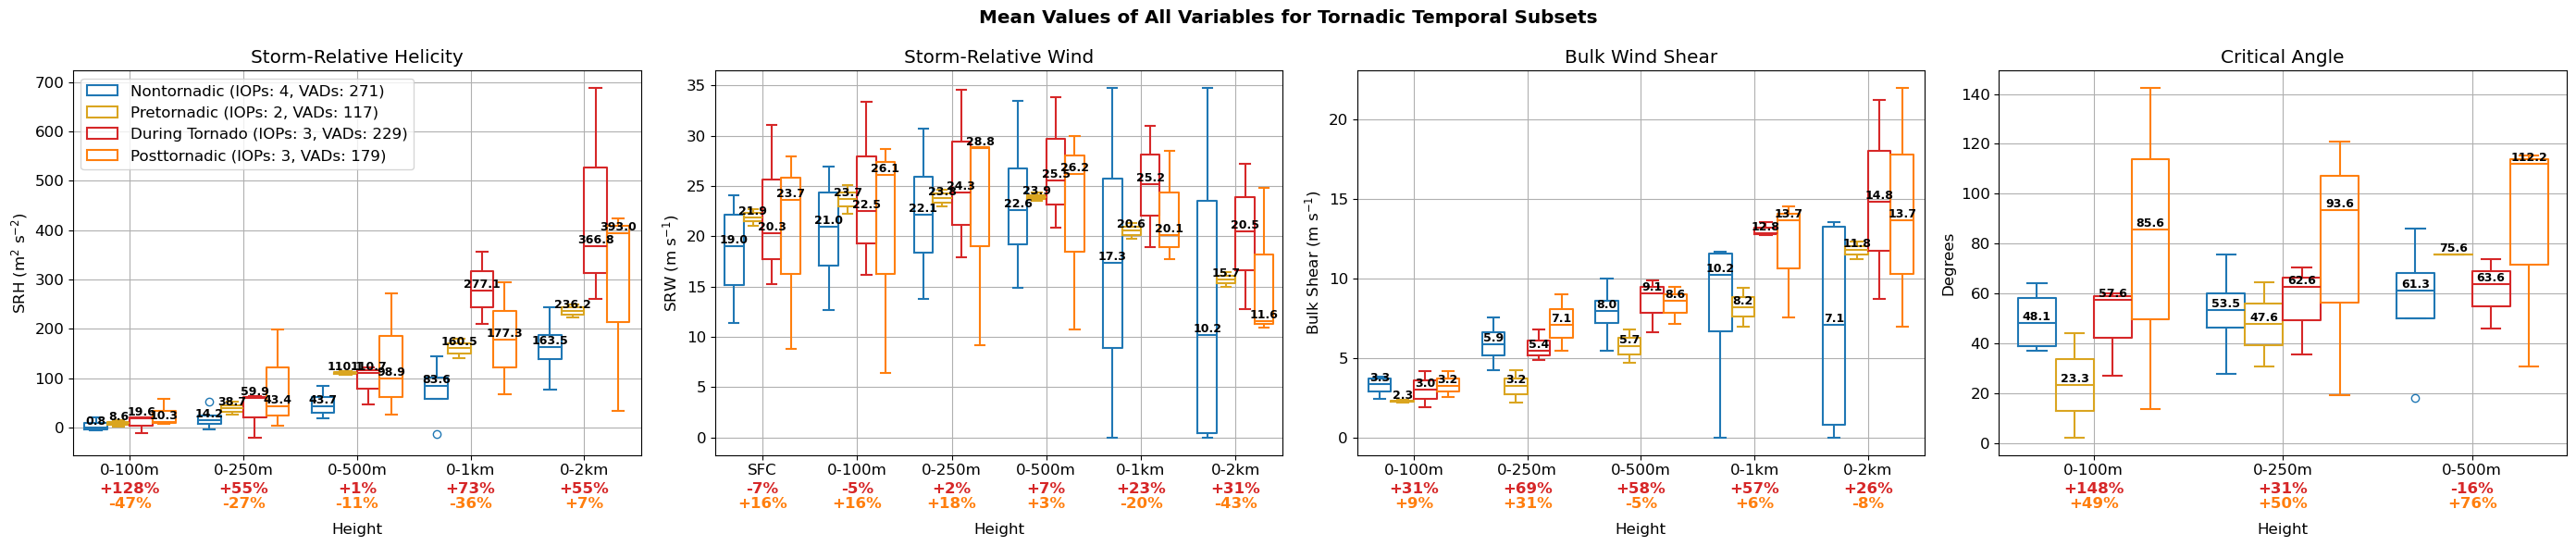

In [83]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
hue_order = ['nontor','pretor', 'dtor', 'posttor']
#fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig, axes = plt.subplots(1, 4, figsize=(28, 6))
plt.rcParams.update({'font.size': 12})

dfs = summary
cmap= ['tab:blue', 'goldenrod', 'tab:red', 'tab:orange']

pretor_boxplot(dfs, 'SRH', 'Height', 'Dist avg', 'Tor Time', False, 'SRH (m$^{2}$ s$^{-2})$', 'Storm-Relative Helicity', axes[0], cmap, height_order, hue_order)
pretor_boxplot(dfs, 'SRW', 'Height', 'Dist avg', 'Tor Time', False, 'SRW (m s$^{-1})$', 'Storm-Relative Wind', axes[1], cmap, sfc_order, hue_order)
pretor_boxplot(dfs, 'Bulk Shear', 'Height', 'Dist avg', 'Tor Time', False, 'Bulk Shear (m s$^{-1})$', 'Bulk Wind Shear', axes[2], cmap, height_order, hue_order)
pretor_boxplot(dfs, 'Critical Angle', 'Height', 'Dist avg', 'Tor Time', False, 'Degrees', 'Critical Angle', axes[3], cmap, ca_order, hue_order)

# Compute counts
counts = summary[
    (summary['Height'] == '0-1km') &
    (summary['SRW or SRH'] == 'SRH')
].dropna().groupby(['Tor Time']).size()

# Sum across all dates to get total per Tor Time
tor_counts = counts

df = df_all_new[(df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['u or v'] == 'v')]
a = df['Tor Time'].value_counts()

# Define color for each Tor Time
colors = {
    'nontor': 'tab:blue',
    'pretor': 'goldenrod',
    'dtor': 'tab:red',
    'posttor': 'tab:orange'
}

ttime_label_map = {'nontor': 'Nontornadic', 'pretor': 'Pretornadic', 'dtor': 'During Tornado', 'posttor':'Posttornadic'}
# Format strings for legend entries
legend_labels = [
    f"{ttime_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
    for tt in colors.keys()
    if tt in tor_counts
]
        
legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                ]

# Add legend box
#axes[0,0].legend(handles=legend_patches, title='IOPs, VADs Counts', loc='upper left', fontsize=10, title_fontsize=10, frameon=True)
axes[0].legend(handles=legend_patches, loc='upper left', fontsize=12, title_fontsize=12, frameon=True)
axes[2].get_legend().set_visible(False)
axes[1].get_legend().set_visible(False)
axes[3].get_legend().set_visible(False)

plt.suptitle('Mean Values of All Variables for Tornadic Temporal Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
hue_order = ['nontor','pretor', 'dtor', 'posttor']
#fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig, axes = plt.subplots(1, 4, figsize=(28, 6))
plt.rcParams.update({'font.size': 12})

dfs = summary
cmap= ['tab:blue', 'goldenrod', 'tab:red', 'tab:orange']

pretor_boxplot(dfs, 'SRH', 'Height', 'Dist avg', 'Tor Time', False, 'SRH (m$^{2}$ s$^{-2})$', 'Storm-Relative Helicity', axes[0], cmap, height_order, hue_order)
pretor_boxplot(dfs, 'SRW', 'Height', 'Dist avg', 'Tor Time', False, 'SRW (m s$^{-1})$', 'Storm-Relative Wind', axes[1], cmap, sfc_order, hue_order)
pretor_boxplot(dfs, 'Bulk Shear', 'Height', 'Dist avg', 'Tor Time', False, 'Bulk Shear (m s$^{-1})$', 'Bulk Wind Shear', axes[2], cmap, height_order, hue_order)
pretor_boxplot(dfs, 'Critical Angle', 'Height', 'Dist avg', 'Tor Time', False, 'Degrees', 'Critical Angle', axes[3], cmap, ca_order, hue_order)

# Compute counts
counts = summary[
    (summary['Height'] == '0-1km') &
    (summary['SRW or SRH'] == 'SRH')
].dropna().groupby(['Tor Time']).size()

# Sum across all dates to get total per Tor Time
tor_counts = counts

df = df_all_new[(df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['u or v'] == 'v')]
a = df['Tor Time'].value_counts()

# Define color for each Tor Time
colors = {
    'nontor': 'tab:blue',
    'pretor': 'goldenrod',
    'dtor': 'tab:red',
    'posttor': 'tab:orange'
}

ttime_label_map = {'nontor': 'Nontornadic', 'pretor': 'Pretornadic', 'dtor': 'During Tornado', 'posttor':'Posttornadic'}
# Format strings for legend entries
legend_labels = [
    f"{ttime_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
    for tt in colors.keys()
    if tt in tor_counts
]
        
legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                ]

# Add legend box
#axes[0,0].legend(handles=legend_patches, title='IOPs, VADs Counts', loc='upper left', fontsize=10, title_fontsize=10, frameon=True)
axes[0].legend(handles=legend_patches, loc='upper left', fontsize=12, title_fontsize=12, frameon=True)
axes[2].get_legend().set_visible(False)
axes[1].get_legend().set_visible(False)
axes[3].get_legend().set_visible(False)

plt.suptitle('Mean Values of All Variables for Tornadic Temporal Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
hue_order = ['nontor','pretor', 'dtor', 'posttor']
fig, axes = plt.subplots(1, 1, figsize=(12, 10))
plt.rcParams.update({'font.size': 12})
#fig, axes = plt.subplots(1, 2, figsize=(14, 7))
dfs = summary
cmap= ['tab:blue', 'goldenrod', 'tab:red', 'tab:orange']

pretor_boxplot(dfs, 'SRH', 'Height', 'Dist avg', 'Tor Time', False, 'SRH (m$^{2}$ s$^{-2})$', 'SRH', axes, cmap, height_order, hue_order)

# Sum across all dates to get total per Tor Time
tor_counts = counts

df = df_all_new[(df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['u or v'] == 'v')]
a = df['Tor Time'].value_counts()

# Define color for each Tor Time
colors = {
    'nontor': 'tab:blue',
    'pretor': 'goldenrod',
    'dtor': 'tab:red',
    'posttor': 'tab:orange'
}

ttime_label_map = {'nontor': 'Nontornadic', 'pretor': 'Pretornadic', 'dtor': 'During Tornado', 'posttor':'Posttornadic'}
# Format strings for legend entries
legend_labels = [
    f"{ttime_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
    for tt in colors.keys()
    if tt in tor_counts
]
        
legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                ]

# Add legend box
#axes[0,0].legend(handles=legend_patches, title='IOPs, VADs Counts', loc='upper left', fontsize=10, title_fontsize=10, frameon=True)
axes.legend(handles=legend_patches, loc='upper left', fontsize=12, title_fontsize=12, frameon=True)

plt.suptitle('Mean SRH for Tornadic Temporal Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
hue_order = ['nontor','pretor', 'dtor', 'posttor']
fig, axes = plt.subplots(1, 1, figsize=(12, 10))
plt.rcParams.update({'font.size': 12})
#fig, axes = plt.subplots(1, 2, figsize=(14, 7))
dfs = summary
cmap= ['tab:blue', 'goldenrod', 'tab:red', 'tab:orange']

pretor_boxplot(dfs, 'SRW', 'Height', 'Dist avg', 'Tor Time', False, 'SRW (m s$^{-1})$', 'SRW', axes, cmap, sfc_order, hue_order)

# Sum across all dates to get total per Tor Time
tor_counts = counts

df = df_all_new[(df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['u or v'] == 'v')]
a = df['Tor Time'].value_counts()

# Define color for each Tor Time
colors = {
    'nontor': 'tab:blue',
    'pretor': 'goldenrod',
    'dtor': 'tab:red',
    'posttor': 'tab:orange'
}

ttime_label_map = {'nontor': 'Nontornadic', 'pretor': 'Pretornadic', 'dtor': 'During Tornado', 'posttor':'Posttornadic'}
# Format strings for legend entries
legend_labels = [
    f"{ttime_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
    for tt in colors.keys()
    if tt in tor_counts
]
        
legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                ]

# Add legend box
#axes[0,0].legend(handles=legend_patches, title='IOPs, VADs Counts', loc='upper left', fontsize=10, title_fontsize=10, frameon=True)
axes.legend(handles=legend_patches, loc='lower left', fontsize=12, title_fontsize=12, frameon=True)

plt.suptitle('Mean SRW for Tornadic Temporal Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
hue_order = ['nontor','pretor', 'dtor', 'posttor']
fig, axes = plt.subplots(1, 1, figsize=(12, 10))
plt.rcParams.update({'font.size': 12})
#fig, axes = plt.subplots(1, 2, figsize=(14, 7))
dfs = summary
cmap= ['tab:blue', 'goldenrod', 'tab:red', 'tab:orange']

pretor_boxplot(dfs, 'Bulk Shear', 'Height', 'Dist avg', 'Tor Time', False, 'Bulk Shear (m s$^{-1})$', 'Bulk Shear', axes, cmap, height_order, hue_order)

# Sum across all dates to get total per Tor Time
tor_counts = counts

df = df_all_new[(df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['u or v'] == 'v')]
a = df['Tor Time'].value_counts()

# Define color for each Tor Time
colors = {
    'nontor': 'tab:blue',
    'pretor': 'goldenrod',
    'dtor': 'tab:red',
    'posttor': 'tab:orange'
}

ttime_label_map = {'nontor': 'Nontornadic', 'pretor': 'Pretornadic', 'dtor': 'During Tornado', 'posttor':'Posttornadic'}
# Format strings for legend entries
legend_labels = [
    f"{ttime_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
    for tt in colors.keys()
    if tt in tor_counts
]
        
legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                ]

# Add legend box
#axes[0,0].legend(handles=legend_patches, title='IOPs, VADs Counts', loc='upper left', fontsize=10, title_fontsize=10, frameon=True)
axes.legend(handles=legend_patches, loc='upper left', fontsize=12, title_fontsize=12, frameon=True)

plt.suptitle('Mean Bulk Shear for Tornadic Temporal Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
hue_order = ['nontor','pretor', 'dtor', 'posttor']
fig, axes = plt.subplots(1, 1, figsize=(12, 10))
plt.rcParams.update({'font.size': 12})
#fig, axes = plt.subplots(1, 2, figsize=(14, 7))
dfs = summary
cmap= ['tab:blue', 'goldenrod', 'tab:red', 'tab:orange']

pretor_boxplot(dfs, 'Critical Angle', 'Height', 'Dist avg', 'Tor Time', False, 'Angle (Degrees)', 'Critical Angle', axes, cmap, ca_order, hue_order)

# Sum across all dates to get total per Tor Time
tor_counts = counts

df = df_all_new[(df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50) & (df_all_new['u or v'] == 'v')]
a = df['Tor Time'].value_counts()

# Define color for each Tor Time
colors = {
    'nontor': 'tab:blue',
    'pretor': 'goldenrod',
    'dtor': 'tab:red',
    'posttor': 'tab:orange'
}

ttime_label_map = {'nontor': 'Nontornadic', 'pretor': 'Pretornadic', 'dtor': 'During Tornado', 'posttor':'Posttornadic'}
# Format strings for legend entries
legend_labels = [
    f"{ttime_label_map[tt]} (IOPs: {tor_counts.get(tt, 0)}, VADs: {a.get(tt,0)})"
    for tt in colors.keys()
    if tt in tor_counts
]
        
legend_patches = [
    Patch(facecolor='none', edgecolor=colors[tt], linewidth=1.5, label=label)
    for tt, label in zip(colors.keys(), legend_labels)
    if tt in tor_counts
                ]

# Add legend box
#axes[0,0].legend(handles=legend_patches, title='IOPs, VADs Counts', loc='upper left', fontsize=10, title_fontsize=10, frameon=True)
axes.legend(handles=legend_patches, loc='upper right', fontsize=12, title_fontsize=12, frameon=True)

plt.suptitle('Mean Critical Angle for Tornadic Temporal Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
height_order = ['0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
sfc_order = ['SFC', '0-100m', '0-250m', '0-500m', '0-1km', '0-2km']
ca_order = ['0-100m', '0-250m', '0-500m']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

dfs = pred_dist
cmap= ['darkred', 'tab:blue', 'darkgreen']

pretor_boxplot(dfs, 'SRH', 'Height', 'Dist avg', 'Tor Time', False, 'SRH (m2/s2)', 'Pretornadic vs During-Tornado SRH', axes[0,0], cmap, height_order)
pretor_boxplot(dfs, 'SRW', 'Height', 'Dist avg', 'Tor Time', False, 'SRW (m/s)', 'Pretornadic vs During-Tornado SRW', axes[0,1], cmap, sfc_order)
pretor_boxplot(dfs, 'Bulk Shear', 'Height', 'Dist avg', 'Tor Time', False, 'Bulk Shear (m/s)', 'Pretornadic vs During-Tornado Bulk Shear', axes[1,0], cmap, height_order)
pretor_boxplot(dfs, 'Critical Angle', 'Height', 'Dist avg', 'Tor Time', False, 'Degrees', 'Pretornadic vs During-Tornado Critical Angle', axes[1,1], cmap, ca_order)

plt.suptitle('Pretornadic vs During-Tornado Mean Variables', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(pred_dist[pred_dist['Height'] == '0-2km'], x='SRW or SRH', y='Dist avg', hue='Tor Time')
plt.title('0-2km Variable for Pretor vs Dtor')

In [ ]:
sns.boxplot(pred_dist[(pred_dist['SRW or SRH'] == 'SRH')], x='Height', y='Dist avg', hue='Tor Time', fill=False)
plt.ylabel('SRH (m2/s2)')
plt.title('0-2km SRH For Pretornadic and During Tornadic Periods')

In [ ]:
sns.boxplot(pred_dist[pred_dist['SRW or SRH'] == 'SRW'], x='Height', y='Dist avg', hue='Tor Time', fill=False)
plt.ylabel('SRW Magnitude (m/s)')
plt.title('0-2km SRW Magnitude For Pretornadic and During Tornadic Periods')
#plt.grid()

In [ ]:
sns.boxplot(pred_dist[pred_dist['SRW or SRH'] == 'Bulk Shear'], x='Height', y='Dist avg', hue='Tor Time', fill=False)
plt.ylabel('Bulk Shear Magnitude(m/s)')
plt.title('Bulk Shear Magnitude For Pretornadic and During Tornadic Periods')
#plt.grid()

In [ ]:
sns.boxplot(pred_dist[pred_dist['SRW or SRH'] == 'Critical Angle'], x='Height', y='Dist avg', hue='Tor Time', fill=False)
plt.ylabel('Critical Angle (degrees)')
plt.title('Critical Angle For Pretornadic and During Tornadic Periods')

#### dtor - pretor

In [ ]:
# Filter to only 'tor' and only pretor and dtor
tor_only = pred_dist[ 
                    (pred_dist['Tor Time'].isin(['pretor', 'dtor']))]

# Pivot the data to have 'pretor' and 'dtor' as columns
pivoted = tor_only.pivot_table(index=['Date', 'SRW or SRH', 'Height'],
                                columns='Tor Time',
                                values='Dist avg').reset_index()

# Drop rows where either pretor or dtor is missing
pivoted = pivoted.dropna(subset=['pretor', 'dtor'])

# Compute the difference
pivoted['dtor_minus_pretor'] = pivoted['dtor'] - pivoted['pretor']
pivoted['% Diff'] = 100* (pivoted['dtor'] - pivoted['pretor'])/(pivoted['dtor'] + pivoted['pretor'])


In [ ]:
pivoted.sort_values(by='% Diff')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'SRH'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height', fill=False)
plt.title('Dtor - Pretor Per IOP Values')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'SRW'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height', fill=False)
plt.title('Dtor - Pretor Per IOP Values')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'Bulk Shear'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height', fill=False)
plt.title('Dtor - Pretor Per IOP Values')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'Critical Angle'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height', fill=False)
plt.title('Dtor - Pretor Per IOP Values')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'SRH'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height')
plt.title('Dtor - Pretor Per IOP Values')

### u test

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = pred_dist
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH'])

# Loop over each group
for (height, param), group in grouped:
    # Split into tornadic and nontornadic
    pretor = group[group['Tor Time'] == 'pretor']['Dist avg'].dropna()
    dtor = group[group['Tor Time'] == 'dtor']['Dist avg'].dropna()
    #posttor = group[group['Tor Time'] == 'posttor']['Dist avg'].dropna()

    #a045 = group[group['Angle'] == '0-45']['Angle avg'].dropna()
    #a4590 = group[group['Angle'] == '45-90']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(pretor) > 1 and len(dtor) > 1 and len(posttor) > 1:
        stat_0, p_value_0 = mannwhitneyu(pretor, dtor, use_continuity=False)  # Whitney u-test
        #stat_1, p_value_1 = mannwhitneyu(dtor, posttor, use_continuity=False)  # Whitney u-test
        #stat_2, p_value_2 = mannwhitneyu(pretor, posttor, use_continuity=False)  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            #'Tor Time': tnt,
            'Pretor Mean': pretor.mean(),
            'Dtor Mean': dtor.mean(),
            'Posttor Mean': posttor.mean(),
            # '0-45 Mean': a045.mean(),
            # '45-90 Mean': a4590.mean(),
            'Pretor-Dtor % Diff': 100* (pretor.mean() - dtor.mean())/(pretor.mean() + dtor.mean()),
            #'Dtor-Posttor % Diff': 100* (dtor.mean() - posttor.mean())/(dtor.mean() + posttor.mean()),
            #'Pretor-Posttor % Diff': 100* (pretor.mean() - posttor.mean())/(pretor.mean() + posttor.mean()),
            'p-value (pretor vs dtor)': p_value_0,
            #'p-value (dtor vs posttor)': p_value_1,
            #'p-value (pretor vs posttor)': p_value_2,
            'n_pretor': len(pretor),
            'n_dtor': len(dtor),
            #'n_posttor': len(posttor),
            #'n_0-45': len(a045),
            #'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle = results_df.sort_values(by='p-value (pretor vs dtor)')


In [ ]:
results_df_dist_angle

## Composites statistical analysis (unsure whether to use this...)

In [ ]:
comp_tor_all_new_copy = comp_tor_all_new.copy()
comp_tor_all_new_copy['Tor or Nontor'] = 'tor'

comp_nontor_all_new_copy = comp_nontor_all_new.copy()
comp_nontor_all_new_copy['Tor or Nontor'] = 'nontor'

In [ ]:
comp_a = pd.DataFrame()
comp_ALL = pd.concat([comp_a, comp_tor_all_new_copy, comp_nontor_all_new_copy])

In [ ]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'v']
p = so.Plot(df, x=195, color='Tor or Nontor').add(
    sns.objects.Area(), sns.objects.KDE(common_norm=False), so.Stack()).label(
    x = 'Avg 0-2km v SRW', title = 'KDE Composite Tor Nontor 0-2km v SRW NEW').scale(x = so.Continuous().tick(every=5)).layout(size=(5,3))
p.show()

In [ ]:
comptor_02_v_mean, comptor_02_v_CI = mean_and_CI(comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'v'][195], 0.95)
compnontor_02_v_mean, compnontor_02_v_CI = mean_and_CI(comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'v'][195], 0.95)

In [ ]:
kde_plot(comp_ALL[comp_ALL['wind'] == 'v'], 195, 'Tor or Nontor', (7,3), 'SRW v component (m/s)', 'KDE Comp Tor Nontor 0-2km SRW v NEW',
         'blue', 'red', comptor_02_v_mean, compnontor_02_v_mean, comptor_02_v_CI, compnontor_02_v_CI)

In [ ]:
comptor_02_u_mean, comptor_02_u_CI = mean_and_CI(comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'u'][195], 0.95)
compnontor_02_u_mean, compnontor_02_u_CI = mean_and_CI(comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'u'][195], 0.95)

In [ ]:
kde_plot(comp_ALL[comp_ALL['wind'] == 'u'], 195, 'Tor or Nontor', (7,3), 'SRW u component (m/s)', 'KDE Comp Tor Nontor 0-2km SRW u NEW',
         'blue', 'red', comptor_02_u_mean, compnontor_02_u_mean, comptor_02_u_CI, compnontor_02_u_CI)

In [ ]:
pd.Series(sorted(set(comp_tor_all_new_copy['date'])))

In [ ]:
comp_tor_all_new_copy

Something is not right about this composite srh method...

In [ ]:
comp_tor_srh = pd.DataFrame()
srh_level = '0-2km SRH'

for d in sorted(set(comp_tor_all_new_copy['date'])):
    comp_tor_date = comp_tor_all_new_copy[comp_tor_all_new_copy['date'] == d]
    comp_tor_date_nf = comp_tor_date[comp_tor_date['label'].isin(['tor nf'])]

    comp_tor_date_ff = comp_tor_date[comp_tor_date['label'].isin(['tor ff'])]
    
    comptor02srh_nf = composite_srh_nan(comp_tor_date_nf[comp_tor_date_nf['wind'] == 'u'], 
                                     comp_tor_date_nf[comp_tor_date_nf['wind'] == 'v'])

    comptor02srh_ff = composite_srh_nan(comp_tor_date_ff[comp_tor_date_ff['wind'] == 'u'], 
                                     comp_tor_date_ff[comp_tor_date_ff['wind'] == 'v'])
    comp_tor_df = pd.DataFrame()
    comp_tor_df['Date'] = [d]
    comp_tor_df[srh_level + '_nf'] = [comptor02srh_nf]
    comp_tor_df[srh_level + '_ff'] = [comptor02srh_ff]

    comp_tor_srh = pd.concat([comp_tor_srh, comp_tor_df])

In [ ]:
comp_tor_srh

In [ ]:
comp_nontor_srh = pd.DataFrame()
srh_level = '0-2km SRH'

for d in sorted(set(comp_nontor_all_new_copy['date'])):
    comp_nontor_date = comp_nontor_all_new_copy[comp_nontor_all_new_copy['date'] == d]
    
    comp_nontor_date_nf = comp_nontor_date[comp_nontor_date['label'].isin(['nontor nf'])]

    comp_nontor_date_ff = comp_nontor_date[comp_nontor_date['label'].isin(['nontor ff'])]
    
    compnontor02srh_nf = composite_srh_nan(comp_nontor_date_nf[comp_nontor_date_nf['wind'] == 'u'], 
                                     comp_nontor_date_nf[comp_nontor_date_nf['wind'] == 'v'])

    compnontor02srh_ff = composite_srh_nan(comp_nontor_date_ff[comp_nontor_date_ff['wind'] == 'u'], 
                                     comp_nontor_date_ff[comp_nontor_date_ff['wind'] == 'v'])
    comp_nontor_df = pd.DataFrame()
    comp_nontor_df['Date'] = [d]
    comp_nontor_df[srh_level + '_nf'] = [compnontor02srh_nf]
    comp_nontor_df[srh_level + '_ff'] = [compnontor02srh_ff]

    comp_nontor_srh = pd.concat([comp_nontor_srh, comp_nontor_df])

In [ ]:
comp_nontor_srh

## Hodos

In [ ]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[i]**2), (v.iloc[i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [ ]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[i+1], v.iloc[i]], axis=0)
        b = -np.nanprod([u.iloc[i], v.iloc[i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [ ]:
def comp_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0) 
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        srh0 = np.nansum([a,b], axis=0)
        srh.append(srh0) # srh at each height

    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [ ]:
def srh_spatial_pert(comp_nontor_all_new, label):
    
    dates_eh = sorted(set(comp_nontor_all_new['date'].values))
    print(np.shape(dates_eh))
    print(dates_eh)
    nontor_srh_df_new = pd.DataFrame()
    nontor_winds_new = pd.DataFrame()
    nontor_both_date = []
    
    for d in dates_eh:
        print(d)
        comp_date = comp_nontor_all_new[comp_nontor_all_new['date'] == d]
        
        #if (comp_date['label'].eq('nontor nf').any()) or (comp_date['label'].eq('nontor ff').any()):
        if (comp_date['label'].eq(f'{label} ff').any()) and (comp_date['label'].eq(f'{label} nf').any()):
    
            nontor_nf_ff = pd.DataFrame()
    
            #print(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'nontor nf')].iloc[:, :50].values)

            u_nf0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :1].values, axis=0)
            v_nf0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :1].values, axis=0)
            u_ff0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :1].values, axis=0)
            v_ff0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :1].values, axis=0)
    
            u_nf500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :50].values, axis=0)
            v_nf500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :50].values, axis=0)
            u_ff500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :50].values, axis=0)
            v_ff500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :50].values, axis=0)
    
            u_nf1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :100].values, axis=0)
            v_nf1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :100].values, axis=0)
            u_ff1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :100].values, axis=0)
            v_ff1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :100].values, axis=0)
            
            u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :196].values, axis=0)
            v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :196].values, axis=0)
            u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :196].values, axis=0)
            v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :196].values, axis=0)
    
            #nontor_nf_ff = pd.DataFrame([d, u_nf, v_nf, u_ff, v_ff], columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean']).T
    
            #nontor_nf_ff = pd.DataFrame([d], [u_nf], [v_nf], [u_ff], [v_ff], index = [0,1,2,3,4])#, columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean'])
            
            #nontor_nf_ff['Date'] = [d]
            # nontor_nf_ff['NF_u_mean'] = [u_nf]
            # nontor_nf_ff['NF_v_mean'] = [v_nf]
            # nontor_nf_ff['FF_u_mean'] = [u_ff]
            # nontor_nf_ff['FF_v_mean'] = [v_ff]
    
    
            nontor_nf_ff['Date'] = [d] * len(u_nf)
    
            nontor_nf_ff['NF_u_mean_0-500m'] = pd.Series(u_nf500)
            nontor_nf_ff['NF_v_mean_0-500m'] = pd.Series(v_nf500)
            nontor_nf_ff['FF_u_mean_0-500m'] = pd.Series(u_ff500)
            nontor_nf_ff['FF_v_mean_0-500m'] = pd.Series(v_ff500)
    
            nontor_nf_ff['NF_u_mean_0-1km'] = pd.Series(u_nf1)
            nontor_nf_ff['NF_v_mean_0-1km'] = pd.Series(v_nf1)
            nontor_nf_ff['FF_u_mean_0-1km'] = pd.Series(u_ff1)
            nontor_nf_ff['FF_v_mean_0-1km'] = pd.Series(v_ff1)
            
            nontor_nf_ff['NF_u_mean_0-2km'] = pd.Series(u_nf)
            nontor_nf_ff['NF_v_mean_0-2km'] = pd.Series(v_nf)
            nontor_nf_ff['FF_u_mean_0-2km'] = pd.Series(u_ff)
            nontor_nf_ff['FF_v_mean_0-2km'] = pd.Series(v_ff)
    
            nontor_winds_new = pd.concat([nontor_winds_new, nontor_nf_ff])
            #nontor_both_date.append(d)

            # delta_u_sfc = u_nf0 - u_ff0
            # delta_v_sfc = v_nf0 - v_ff0

            # delta_u_500 = u_nf500 - u_ff500
            # delta_v_500 = v_nf500 - v_ff500

            # delta_u_1 = u_nf1 - u_ff1
            # delta_v_1 = v_nf1 - v_ff1
            print(np.shape(u_nf))
            delta_u_2 = pd.Series(u_nf - u_ff)
            delta_v_2 = pd.Series(v_nf - v_ff)

            u_nfser = pd.Series(u_nf)
            u_ffser = pd.Series(u_ff)

            v_nfser = pd.Series(v_nf)
            v_ffser = pd.Series(v_ff)

            
            
            hodo_plot([u_nf, u_ff, delta_u_2], [v_nf, v_ff, delta_v_2], heights, 25, f'{label} Composites Pert {d}', 
                      ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'upper left',5,5)
    
            nf_srh500 = comp_srh_nan(u_nf500, v_nf500)
            ff_srh500 = comp_srh_nan(u_ff500, v_ff500)
    
            nf_srh1 = comp_srh_nan(u_nf1, v_nf1)
            ff_srh1 = comp_srh_nan(u_ff1, v_ff1)
    
            nf_srh = comp_srh_nan(u_nf, v_nf)
            ff_srh = comp_srh_nan(u_ff, v_ff)

            
            delta_srh500 = nf_srh500 - ff_srh500
            delta_srh1 = nf_srh1 - ff_srh1
            delta_srh2 = nf_srh - ff_srh
            
            print(f'nf_srh-ff_srh = {delta_srh2}')



            # srw_sfc = comp_srw(delta_u_2, delta_v_2, 0)

            # srw_500 = comp_srw(delta_u_2, delta_v_2, 50)

            # srw_1 = comp_srw(delta_u_2, delta_v_2, 100)

            # srw_2 = comp_srw(delta_u_2, delta_v_2, 194)
            
            nf_srw0 = comp_srw(u_nfser, v_nfser, 0)
            ff_srw0 = comp_srw(u_ffser, v_ffser, 0)

            nf_srw500 = comp_srw(u_nfser, v_nfser, 50)
            ff_srw500 = comp_srw(u_ffser, v_ffser, 50)

            nf_srw1 = comp_srw(u_nfser, v_nfser, 100)
            ff_srw1 = comp_srw(u_ffser, v_ffser, 100)

            nf_srw2 = comp_srw(u_nfser, v_nfser, 194)
            ff_srw2 = comp_srw(u_ffser, v_ffser, 194)

            srw_sfc = nf_srw0 - ff_srw0
            srw_500 = nf_srw500 - ff_srw500
            srw_1 = nf_srw1 - ff_srw1
            srw_2 = nf_srw2 - ff_srw2
            
            # delta_srh = nf_srh - ff_srh
            # print(f'nf_srh-ff_srh = {delta_srh}')
    
            nontor_srh = pd.DataFrame()
    
            
            nontor_srh['Date'] = [d]
            
            nontor_srh['NF_SRH_0-500m'] = [nf_srh500]
            nontor_srh['FF_SRH_0-500m'] = [ff_srh500]
            
            nontor_srh['NF_SRH_0-1km'] = [nf_srh1]
            nontor_srh['FF_SRH_0-1km'] = [ff_srh1]
            
            nontor_srh['NF_SRH_0-2km'] = [nf_srh]
            nontor_srh['FF_SRH_0-2km'] = [ff_srh]
    
            nontor_srh['delta_SRH_0-500m'] = [delta_srh500]
            nontor_srh['delta_SRH_0-1km'] = [delta_srh1]
            nontor_srh['delta_SRH_0-2km'] = [delta_srh2]

            nontor_srh['delta_SRW_SFC'] = [srw_sfc]
            nontor_srh['delta_SRW_0-500m'] = [srw_500]
            nontor_srh['delta_SRW_0-1km'] = [srw_1]
            nontor_srh['delta_SRW_0-2km'] = [srw_2]
            
            nontor_srh_df_new = pd.concat([nontor_srh_df_new, nontor_srh])
            
    
        else:
            continue

    return nontor_winds_new, nontor_srh_df_new

In [ ]:
nontor_winds, nontor_srh_df = srh_spatial_pert(comp_nontor_all, 'nontor')

In [ ]:
nontor_winds_new, nontor_srh_df_new = srh_spatial_pert(comp_nontor_all_new, 'nontor')

In [ ]:
nontor_winds_new

In [ ]:
nontor_srh_df_new

In [ ]:
comp_tor_all_new

In [ ]:
tor_winds, tor_srh_df = srh_spatial_pert(comp_tor_all, 'tor')

In [ ]:
tor_srh_df

In [ ]:
tor_winds_new, tor_srh_df_new = srh_spatial_pert(comp_tor_all_new, 'tor')

In [ ]:
tor_winds_new

In [ ]:
tor_srh_df_new 

In [ ]:
dates_eh = sorted(set(comp_tor_all_nodist['date'].values))
#print(np.shape(dates_eh))
#print(dates_eh)
septor_srh_df = pd.DataFrame()

for d in dates_eh:
    #print(d)
    comp_date = comp_tor_all_nodist[comp_tor_all_nodist['date'] == d]
    
    if (comp_date['label'].eq('pretor').any()) and (comp_date['label'].eq('dtor').any()):

    #if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())):

        print(d)

        pre_u0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :1].values, axis=0)
        pre_v0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :1].values, axis=0)
        
        pre_u500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :50].values, axis=0)
        pre_v500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :50].values, axis=0)
        
        pre_u1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :100].values, axis=0)
        pre_v1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :100].values, axis=0)
        
        pre_u = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :196].values, axis=0)
        pre_v = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :196].values, axis=0)

        d_u0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :1].values, axis=0)
        d_v0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :1].values, axis=0)

        d_u500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :50].values, axis=0)
        d_v500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :50].values, axis=0)

        d_u1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :100].values, axis=0)
        d_v1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :100].values, axis=0)

        d_u = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :196].values, axis=0)
        d_v = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :196].values, axis=0)
    
        # pre_delta_u = pre_u_ff - pre_u_nf
        # pre_delta_v = pre_v_ff - pre_v_nf

        # d_delta_u = d_u_ff - d_u_nf
        # d_delta_v = d_v_ff - d_v_nf
        
        # hodo_plot([pre_u_nf, pre_u_ff, predelta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
        #           ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left')

        pre_u_ser = pd.Series(pre_u)
        pre_v_ser = pd.Series(pre_v)

        d_u_ser = pd.Series(d_u)
        d_v_ser = pd.Series(d_v)

        pre_srw0 = comp_srw(pre_u_ser, pre_v_ser, 0)
        pre_srw500 = comp_srw(pre_u_ser, pre_v_ser, 50)
        pre_srw1 = comp_srw(pre_u_ser, pre_v_ser, 100)
        pre_srw2 = comp_srw(pre_u_ser, pre_v_ser, 194)

        d_srw0 = comp_srw(d_u_ser, d_v_ser, 0)
        d_srw500 = comp_srw(d_u_ser, d_v_ser, 50)
        d_srw1 = comp_srw(d_u_ser, d_v_ser, 100)
        d_srw2 = comp_srw(d_u_ser, d_v_ser, 194)
        
        pre_srh0 = comp_srh_nan(pre_u0, pre_v0)
        pre_srh500 = comp_srh_nan(pre_u500, pre_v500)
        pre_srh1 = comp_srh_nan(pre_u1, pre_v1)
        pre_srh2 = comp_srh_nan(pre_u, pre_v)
        #pre_ff_srh = comp_srh_nan(pre_u_ff, pre_v_ff)

        d_srh0 = comp_srh_nan(d_u0, d_v0)
        d_srh500 = comp_srh_nan(d_u500, d_v500)
        d_srh1 = comp_srh_nan(d_u1, d_v1)
        d_srh2 = comp_srh_nan(d_u, d_v)
        #d_ff_srh = comp_srh_nan(d_u_ff, d_v_ff)
        
        #pre_delta_srh = pre_nf_srh - pre_ff_srh
        #d_delta_srh = d_nf_srh - d_ff_srh

        pre_d_delta_srw0 = d_srw0 - pre_srw0
        pre_d_delta_srw500 = d_srw500 - pre_srw500
        pre_d_delta_srw1 = d_srw1 - pre_srw1
        pre_d_delta_srw2 = d_srw2 - pre_srw2
        
        pre_d_delta_srh0 = d_srh0 - pre_srh0
        pre_d_delta_srh500 = d_srh500 - pre_srh500
        pre_d_delta_srh1 = d_srh1 - pre_srh1
        pre_d_delta_srh2 = d_srh2 - pre_srh2
        #print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]

        tor_srh['PRE_SFC_SRW'] = [pre_srw0]
        tor_srh['PRE_0-500m_SRW'] = [pre_srw500]
        tor_srh['PRE_0-1km_SRW'] = [pre_srw1]
        tor_srh['PRE_0-2km_SRW'] = [pre_srw2]

        tor_srh['PRE_0-500m_SRH'] = [pre_srh500]
        tor_srh['PRE_0-1km_SRH'] = [pre_srh1]
        tor_srh['PRE_0-2km_SRH'] = [pre_srh2]
        #tor_srh['PRE_FF_SRH'] = [pre_ff_srh]

        tor_srh['D_SFC_SRW'] = [d_srw0]
        tor_srh['D_0-500m_SRW'] = [d_srw500]
        tor_srh['D_0-1km_SRW'] = [d_srw1]
        tor_srh['D_0-2km_SRW'] = [d_srw2]

        tor_srh['D_0-500m_SRH'] = [d_srh500]
        tor_srh['D_0-1km_SRH'] = [d_srh1]
        tor_srh['D_0-2km_SRH'] = [d_srh2]
        #tor_srh['D_0-2km_SRH'] = [d_srh2]
        #tor_srh['D_FF_SRH'] = [d_ff_srh]
        
        #tor_srh['PRE_delta_SRH'] = [pre_delta_srh]
        #tor_srh['D_delta_SRH'] = [d_delta_srh]
        
        tor_srh['D_minus_PRE_SFC_SRW'] = [pre_d_delta_srw0]
        tor_srh['D_minus_PRE_0-500m_SRW'] = [pre_d_delta_srw500]
        tor_srh['D_minus_PRE_0-1km_SRW'] = [pre_d_delta_srw1]
        tor_srh['D_minus_PRE_0-2km_SRW'] = [pre_d_delta_srw2]

        tor_srh['D_minus_PRE_0-500m_SRH'] = [pre_d_delta_srh500]
        tor_srh['D_minus_PRE_0-1km_SRH'] = [pre_d_delta_srh1]
        tor_srh['D_minus_PRE_0-2km_SRH'] = [pre_d_delta_srh2]
        
        septor_srh_df = pd.concat([septor_srh_df, tor_srh])
        

    else:
        continue

## Box and Bar Plots

In [ ]:
#label = 'D_minus_PRE_SRH'
plt.boxplot([septor_srh_df['D_minus_PRE_SFC_SRW'], septor_srh_df['D_minus_PRE_0-500m_SRW'], 
             septor_srh_df['D_minus_PRE_0-1km_SRW'], septor_srh_df['D_minus_PRE_0-2km_SRW']],
           labels = ['D_minus_PRE_SFC_SRW','D_minus_PRE_0-500m_SRW', 'D_minus_PRE_0-1km_SRW', 'D_minus_PRE_0-2km_SRW'])

plt.ylabel('D-PRE SRW Perturbation (m/s)')
plt.xticks(rotation = 45)
plt.title(f'D - PRE SRH Per Level')
plt.grid()
plt.show()

In [ ]:
dates_eh = sorted(set(comp_tor_all['date'].values))
#print(np.shape(dates_eh))
#print(dates_eh)
septor_srh_df = pd.DataFrame()

for d in dates_eh:
    #print(d)
    comp_date = comp_tor_all[comp_tor_all['date'] == d]
    
    if ((comp_date['label'].eq('pretor nf').any()) or (comp_date['label'].eq('pretor ff').any())) and ((comp_date['label'].eq('dtor nf').any()) or (comp_date['label'].eq('dtor ff').any())):

    #if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())):

        print(d)
        
        pre_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)
        pre_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)

        d_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
        d_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
    
        pre_delta_u = pre_u_ff - pre_u_nf
        pre_delta_v = pre_v_ff - pre_v_nf

        d_delta_u = d_u_ff - d_u_nf
        d_delta_v = d_v_ff - d_v_nf
        
        # hodo_plot([pre_u_nf, pre_u_ff, predelta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
        #           ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left')

        pre_nf_srh = comp_srh_nan(pre_u_nf, pre_v_nf)
        pre_ff_srh = comp_srh_nan(pre_u_ff, pre_v_ff)

        d_nf_srh = comp_srh_nan(d_u_nf, d_v_nf)
        d_ff_srh = comp_srh_nan(d_u_ff, d_v_ff)
        
        pre_delta_srh = pre_nf_srh - pre_ff_srh
        d_delta_srh = d_nf_srh - d_ff_srh
        
        #print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]
        tor_srh['PRE_NF_SRH'] = [pre_nf_srh]
        tor_srh['PRE_FF_SRH'] = [pre_ff_srh]
        
        tor_srh['D_NF_SRH'] = [d_nf_srh]
        tor_srh['D_FF_SRH'] = [d_ff_srh]
        
        tor_srh['PRE_delta_SRH'] = [pre_delta_srh]
        tor_srh['D_delta_SRH'] = [d_delta_srh]
        
        septor_srh_df = pd.concat([septor_srh_df, tor_srh])
        

    else:
        continue

In [ ]:
nontor_srh_df_new

In [ ]:
tor_srh_df_new

In [ ]:
comp_tor_all

In [ ]:
comp_tor_all[comp_tor_all['date'] == '20220523']['label'].value_counts()

In [ ]:
comp_tor_all[comp_tor_all['date'] == '20230524']['label'].value_counts()

In [ ]:
comp_tor_all[comp_tor_all['date'] == '20230527']['label'].value_counts()

In [ ]:
comp_tor_all[comp_tor_all['date'] == '20230615']['label'].value_counts()

In [ ]:
tor_srh_df_new

In [ ]:
sns.barplot(x='Date', y='delta_SRH_0-2km' , data=tor_srh_df_new)
plt.show()

In [ ]:
sns.barplot(x='Date', y='delta_SRH_0-2km' , data=nontor_srh_df_new)
plt.show()

In [ ]:
label = 'delta_SRH_0-500m'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRH_0-1km'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRH_0-2km'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRW_SFC'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRW_0-500m'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRW_0-1km'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRW_0-2km'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

## Permutation Test (test for statistical significance)

Doing a permutation test shuffles the data randomly to see if the calculated test result is similar or not regardless of how the data is sorted (meaning there is not much difference in the data itself). For us, the test result that we're checking is the difference between the means of our nontornadic and tornadic nf-ff perturbation datasets.

In [ ]:
from scipy.stats import permutation_test

In [ ]:
np.array(nontor_srh_df_new[label])

Sample size too small

In [ ]:
label = 'delta_SRW_0-2km'
result = permutation_test((tor_srh_df_new[label], nontor_srh_df_new[label]), test_stat, permutation_type='independent')

In [ ]:
result

# Noncomposited avg hodographs

In [ ]:
def noncomposite_avg_uv(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, height, minangle, maxangle):

    '''
    max height = 196
    '''
    
    tor_u_nf = np.nanmean(nf_u_categories['tor'].iloc[:, :height], axis=0)
    tor_v_nf = np.nanmean(nf_v_categories['tor'].iloc[:, :height], axis=0)
    
    pretor_u_nf = np.nanmean(nf_u_categories['pretor'].iloc[:, :height], axis=0)
    pretor_v_nf = np.nanmean(nf_v_categories['pretor'].iloc[:, :height], axis=0)
    
    dtor_u_nf = np.nanmean(nf_u_categories['dtor'].iloc[:, :height], axis=0)
    dtor_v_nf = np.nanmean(nf_v_categories['dtor'].iloc[:, :height], axis=0)
    
    posttor_u_nf = np.nanmean(nf_u_categories['posttor'].iloc[:, :height], axis=0)
    posttor_v_nf = np.nanmean(nf_v_categories['posttor'].iloc[:, :height], axis=0)
    
    nontor_u_nf = np.nanmean(nf_u_categories['nontor'].iloc[:, :height], axis=0)
    nontor_v_nf = np.nanmean(nf_v_categories['nontor'].iloc[:, :height], axis=0)

    tor_u_ff = np.nanmean(ff_u_categories['tor'].iloc[:, :height], axis=0)
    tor_v_ff = np.nanmean(ff_v_categories['tor'].iloc[:, :height], axis=0)
    
    pretor_u_ff = np.nanmean(ff_u_categories['pretor'].iloc[:, :height], axis=0)
    pretor_v_ff = np.nanmean(ff_v_categories['pretor'].iloc[:, :height], axis=0)
    
    dtor_u_ff = np.nanmean(ff_u_categories['dtor'].iloc[:, :height], axis=0)
    dtor_v_ff = np.nanmean(ff_v_categories['dtor'].iloc[:, :height], axis=0)
    
    posttor_u_ff = np.nanmean(ff_u_categories['posttor'].iloc[:, :height], axis=0)
    posttor_v_ff = np.nanmean(ff_v_categories['posttor'].iloc[:, :height], axis=0)
    
    nontor_u_ff = np.nanmean(ff_u_categories['nontor'].iloc[:, :height], axis=0)
    nontor_v_ff = np.nanmean(ff_v_categories['nontor'].iloc[:, :height], axis=0)

    return locals()

In [ ]:
avg_noncomp_uv_02km = noncomposite_avg_uv(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 196)

In [ ]:
tor_u_nf = np.nanmean(nf_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_nf = np.nanmean(nf_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_nf = np.nanmean(nf_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_nf = np.nanmean(nf_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_nf = np.nanmean(nf_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_nf = np.nanmean(nf_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_nf = np.nanmean(nf_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_nf = np.nanmean(nf_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_nf = np.nanmean(nf_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_nf = np.nanmean(nf_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff = np.nanmean(ff_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_ff = np.nanmean(ff_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_ff = np.nanmean(ff_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_ff = np.nanmean(ff_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_ff = np.nanmean(ff_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_ff = np.nanmean(ff_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_ff = np.nanmean(ff_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_ff = np.nanmean(ff_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_ff = np.nanmean(ff_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_ff = np.nanmean(ff_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_nf_new = np.nanmean(nf_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_nf_new = np.nanmean(nf_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_nf_new = np.nanmean(nf_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_nf_new = np.nanmean(nf_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_nf_new = np.nanmean(nf_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_nf_new = np.nanmean(nf_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_nf_new = np.nanmean(nf_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_nf_new = np.nanmean(nf_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_nf_new = np.nanmean(nf_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_nf_new = np.nanmean(nf_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff_new = np.nanmean(ff_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_ff_new = np.nanmean(ff_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_ff_new = np.nanmean(ff_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_ff_new = np.nanmean(ff_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_ff_new = np.nanmean(ff_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_ff_new = np.nanmean(ff_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_ff_new = np.nanmean(ff_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_ff_new = np.nanmean(ff_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_ff_new = np.nanmean(ff_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_ff_new = np.nanmean(ff_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
hodo_plot([tor_u_nf, pretor_u_nf, dtor_u_nf, posttor_u_nf, nontor_u_nf], [tor_u_ff, pretor_v_nf, dtor_v_nf, posttor_v_nf, 
                                                                             nontor_v_nf], heights, 25, 
    'Near-Field Composites (No Comp Prior)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([tor_u_ff, pretor_u_ff, dtor_u_ff, posttor_u_ff, nontor_u_ff], [tor_v_ff, pretor_v_ff, dtor_v_ff, posttor_v_ff, 
                                                                             nontor_v_ff], heights, 25, 
    'Far-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_nf_new, dtor_u_nf_new, posttor_u_nf_new, nontor_u_nf_new], [pretor_v_nf_new, dtor_v_nf_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Near-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_ff_new, dtor_u_ff_new, posttor_u_ff_new, nontor_u_ff_new], [pretor_v_ff_new, dtor_v_ff_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Far-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'During Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 8,8)

# Same day NF - FF SRH and SRW Pert

In [ ]:
df_all_new[(df_all_new['Date'] == '20230615') & (df_all_new['Time From Tor (min)'] == 0)]['Datetime']

In [ ]:
avg_comp

In [ ]:
df = avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-2km') & (avg_comp['Tor or Nontor'] == 'tor')]
ax = sns.barplot(df, x='Date', y= 'Dist avg', hue='NF or FF')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Tor 0-2km SRH')

In [ ]:
df = avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-2km') & (avg_comp['Tor or Nontor'] == 'nontor')]
ax = sns.barplot(df, x='Date', y= 'Dist avg', hue='NF or FF')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Nontor 0-2km SRH')

In [ ]:
df = avg_comp[(avg_comp['SRW or SRH'] == 'SRW') & (avg_comp['Height'] == '0-2km') & (avg_comp['Tor or Nontor'] == 'tor')]
ax = sns.barplot(df, x='Date', y= 'Dist avg', hue='NF or FF')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Tor 0-2km SRW')

In [ ]:
df = avg_comp[(avg_comp['SRW or SRH'] == 'SRW') & (avg_comp['Height'] == '0-1km') & (avg_comp['Tor or Nontor'] == 'nontor')]
ax = sns.barplot(df, x='Date', y= 'Dist avg', hue='NF or FF')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Nontor 0-2km SRW')

In [ ]:
# First, group by date and check if both 'nf' and 'ff' are present
nonan = avg_comp.dropna(subset=['Dist avg'])
dates_with_both = (
    nonan.groupby('Date')['NF or FF']
    .apply(lambda x: set(x) >= {'nf', 'ff'})
)

# Get the dates where both 'nf' and 'ff' are present
valid_dates = dates_with_both[dates_with_both].index

# Filter the original DataFrame to include only these dates
filtered_df = avg_comp[avg_comp['Date'].isin(valid_dates)]

In [ ]:
valid_dates

In [ ]:
avg_comp

In [ ]:
avg_all_comp_per_date

In [ ]:
# Filter out rows with missing 'Dist avg' values
df = avg_comp

df_valid = df.dropna(subset=['Dist avg'])

# Pivot the table so 'nf' and 'ff' become columns
pivoted = avg_comp.pivot_table(
    index=['Date', 'SRW or SRH', 'Height', 'Tor or Nontor'],
    columns='NF or FF',
    values='Dist avg',
    aggfunc='first'
)

# Drop rows where either nf or ff is missing
pivoted = pivoted.dropna(subset=['nf', 'ff'])

# Compute the difference: nf - ff
pivoted['nf_minus_ff'] = np.nansum([pivoted['nf'], - pivoted['ff']], axis=0)
pivoted['%_diff'] = ((np.nansum([pivoted['nf'], - pivoted['ff']], axis=0))/(np.nansum([pivoted['ff'], pivoted['nf']], axis=0))/2) * 100

# If you want it back in a flat DataFrame:
result = pivoted.reset_index()

In [ ]:
pivoted

In [ ]:
result

In [ ]:
sns.barplot(result[(result['Tor or Nontor'] == 'tor') & (result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff', hue='Date')

In [ ]:
sns.barplot(result[(result['Tor or Nontor'] == 'tor') & (result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff')

In [ ]:
sns.barplot(result[(result['Tor or Nontor'] == 'nontor') & (result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff', hue='Date')

In [ ]:
sns.barplot(result[(result['Tor or Nontor'] == 'nontor') & (result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff')

In [ ]:
avg_comp

In [ ]:
dist_angle_avg_date

In [ ]:
# Filter out rows with missing 'Dist avg' values
df = dist_angle_avg_date

#df_valid = df.dropna(subset=['Dist avg'])

# Pivot the table so 'nf' and 'ff' become columns
pivoted = dist_angle_avg_date.pivot_table(
    index=['Date', 'SRW or SRH', 'Height', 'Tor or Nontor'],
    columns='NF or FF',
    values='Dist avg',
    aggfunc='first'
)

# Drop rows where either nf or ff is missing
#pivoted = pivoted.dropna(subset=['nf', 'ff'])

# Compute the difference: nf - ff
pivoted['nf_minus_ff'] = np.nansum([pivoted['nf'], - pivoted['ff']], axis=0)
pivoted['%_diff'] = ((np.nansum([pivoted['nf'], - pivoted['ff']], axis=0))/(np.nansum([pivoted['nf'], pivoted['ff']], axis=0))/2) * 100

# If you want it back in a flat DataFrame:
result = pivoted.reset_index()

In [ ]:
result[result['%_diff'] != 50]

In [ ]:
df = result[result['%_diff'] != 50]
sns.boxplot(df[(df['Height'] == '0-2km')], x='SRW or SRH', y='%_diff', hue='Tor or Nontor')

In [ ]:
# Filter out rows with missing 'Dist avg' values
df = avg_comp

df_valid = df.dropna(subset=['Dist avg'])

# Pivot the table so 'nf' and 'ff' become columns
pivoted = avg_comp.pivot_table(
    index=['Date', 'SRW or SRH', 'Height'],
    columns='Tor Time',
    values='Dist avg',
    aggfunc='first'
)

# Drop rows where either nf or ff is missing
#pivoted = pivoted.dropna(subset=['nf', 'ff'])

# Compute the difference: nf - ff
pivoted['pretor_minus_posttor'] = np.nansum([pivoted['pretor'], - pivoted['posttor']], axis=0)
pivoted['%_diff'] = ((np.nansum([pivoted['pretor'], - pivoted['posttor']], axis=0))/(np.nansum([pivoted['pretor'], pivoted['posttor']], axis=0))/2) * 100

# If you want it back in a flat DataFrame:
result = pivoted.reset_index()

In [ ]:
result

In [ ]:
sns.barplot(result[(result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff', hue='Date')

In [ ]:
sns.barplot(result[(result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff')

# Avg u and v SRW and SRH per VAD

SRW

Does this even mean anything? The average u and v component from 0-2km?

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
        
    tor_u_nf_per = np.nanmean(nf_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_nf_per = np.nanmean(nf_v_categories['tor'].iloc[:, h0:htop], axis=1)
    
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    tor_u_ff_per = np.nanmean(ff_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_ff_per = np.nanmean(ff_v_categories['tor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
avg_sfc_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 0, 5)
avg_500m_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 50, 55)
avg_1km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 100, 105)
avg_2km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 191, 196)

In [ ]:
avg_sfc_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 0, 5)
avg_500m_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 50, 55)
avg_1km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 100, 105)
avg_2km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 191, 196)

In [ ]:
np.shape(avg_sfc_wind['pretor_u_nf_per'])

In [ ]:
def tor_boxplot_uandv(data_dict, title_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height['nontor_u_nf_per'], height['tor_u_nf_per'], height['pretor_u_nf_per'], height['dtor_u_nf_per'], 
                 height['posttor_u_nf_per']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title_height} Storm-Relative Wind u Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height['nontor_v_nf_per'], height['tor_v_nf_per'], height['pretor_v_nf_per'], height['dtor_v_nf_per'], 
                 height['posttor_v_nf_per']], labels = labels)
    
    ax1.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title_height} Storm-Relative Wind v Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_uandv(avg_sfc_wind, '50m')

In [ ]:
tor_boxplot_uandv(avg_sfc_wind_new, '50m NEW')

In [ ]:
tor_boxplot_uandv(avg_500m_wind, '500m')

In [ ]:
tor_boxplot_uandv(avg_500m_wind_new, '500m NEW')

In [ ]:
tor_boxplot_uandv(avg_1km_wind, '1km')

In [ ]:
tor_boxplot_uandv(avg_1km_wind_new, '1km NEW')

In [ ]:
tor_boxplot_uandv(avg_2km_wind, '2km')

In [ ]:
tor_boxplot_uandv(avg_2km_wind_new, '2km NEW')

0-xkm Shear Vector Magnitudes

# SRH and SRW of u and v categories big breakdown (with boxplots)

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
def shear_magnitude(u, v, vector_height):
    delta_u = u.iloc[:, vector_height] - u.iloc[:, 0]
    delta_v = v.iloc[:, vector_height] - v.iloc[:, 0]
    mag = np.sqrt(np.nansum([(delta_u**2), (delta_v**2)], axis=0))

    return mag

In [ ]:
def shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, vector_height):

    nf_tor = shear_magnitude(nf_u_categories['tor'], nf_v_categories['tor'], vector_height)
    ff_tor = shear_magnitude(ff_u_categories['tor'], ff_v_categories['tor'], vector_height)

    nf_pretor = shear_magnitude(nf_u_categories['pretor'], nf_v_categories['pretor'], vector_height)
    ff_pretor = shear_magnitude(ff_u_categories['pretor'], ff_v_categories['pretor'], vector_height)

    nf_dtor = shear_magnitude(nf_u_categories['dtor'], nf_v_categories['dtor'], vector_height)
    ff_dtor = shear_magnitude(ff_u_categories['dtor'], ff_v_categories['dtor'], vector_height)

    nf_posttor = shear_magnitude(nf_u_categories['posttor'], nf_v_categories['posttor'], vector_height)
    ff_posttor = shear_magnitude(ff_u_categories['posttor'], ff_v_categories['posttor'], vector_height)

    nf_nontor = shear_magnitude(nf_u_categories['nontor'], nf_v_categories['nontor'], vector_height)
    ff_nontor = shear_magnitude(ff_u_categories['nontor'], ff_v_categories['nontor'], vector_height)

    return locals()

In [ ]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[:, i]**2), (v.iloc[:,i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [ ]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [ ]:
def srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srh(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srh(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srh(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srh(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srh(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srh(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srh(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srh(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srh(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srh(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
def srw_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srw(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srw(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srw(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srw(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srw(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srw(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srw(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srw(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srw(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srw(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
angle0to30_nf = np.array(nf_u_categories_new['Angle']) < 31
a = nf_u_categories['pretor'][angle0to30_nf]

In [ ]:
srh_all = srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories)

In [ ]:
srh_all_new = srh_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
def srh_per_level(srh_all):

    nf_tor_sfcto500 = np.nansum(srh_all['nf_tor'][:50], axis=0)
    nf_tor_sfcto1km = np.nansum(srh_all['nf_tor'][:100], axis=0)
    nf_tor_sfcto1halfkm = np.nansum(srh_all['nf_tor'][:150], axis=0)
    nf_tor_sfcto2km = np.nansum(srh_all['nf_tor'][:196], axis=0)

    ff_tor_sfcto500 = np.nansum(srh_all['ff_tor'][:50], axis=0)
    ff_tor_sfcto1km = np.nansum(srh_all['ff_tor'][:100], axis=0)
    ff_tor_sfcto1halfkm = np.nansum(srh_all['ff_tor'][:150], axis=0)
    ff_tor_sfcto2km = np.nansum(srh_all['ff_tor'][:196], axis=0)
    
    nf_pretor_sfcto500 = np.nansum(srh_all['nf_pretor'][:50], axis=0)
    nf_pretor_sfcto1km = np.nansum(srh_all['nf_pretor'][:100], axis=0)
    nf_pretor_sfcto1halfkm = np.nansum(srh_all['nf_pretor'][:150], axis=0)
    nf_pretor_sfcto2km = np.nansum(srh_all['nf_pretor'][:196], axis=0)

    ff_pretor_sfcto500 = np.nansum(srh_all['ff_pretor'][:50], axis=0)
    ff_pretor_sfcto1km = np.nansum(srh_all['ff_pretor'][:100], axis=0)
    ff_pretor_sfcto1halfkm = np.nansum(srh_all['ff_pretor'][:150], axis=0)
    ff_pretor_sfcto2km = np.nansum(srh_all['ff_pretor'][:196], axis=0)

    nf_dtor_sfcto500 = np.nansum(srh_all['nf_dtor'][:50], axis=0)
    nf_dtor_sfcto1km = np.nansum(srh_all['nf_dtor'][:100], axis=0)
    nf_dtor_sfcto1halfkm = np.nansum(srh_all['nf_dtor'][:150], axis=0)
    nf_dtor_sfcto2km = np.nansum(srh_all['nf_dtor'][:196], axis=0)

    ff_dtor_sfcto500 = np.nansum(srh_all['ff_dtor'][:50], axis=0)
    ff_dtor_sfcto1km = np.nansum(srh_all['ff_dtor'][:100], axis=0)
    ff_dtor_sfcto1halfkm = np.nansum(srh_all['ff_dtor'][:150], axis=0)
    ff_dtor_sfcto2km = np.nansum(srh_all['ff_dtor'][:196], axis=0)

    nf_posttor_sfcto500 = np.nansum(srh_all['nf_posttor'][:50], axis=0)
    nf_posttor_sfcto1km = np.nansum(srh_all['nf_posttor'][:100], axis=0)
    nf_posttor_sfcto1halfkm = np.nansum(srh_all['nf_posttor'][:150], axis=0)
    nf_posttor_sfcto2km = np.nansum(srh_all['nf_posttor'][:196], axis=0)

    ff_posttor_sfcto500 = np.nansum(srh_all['ff_posttor'][:50], axis=0)
    ff_posttor_sfcto1km = np.nansum(srh_all['ff_posttor'][:100], axis=0)
    ff_posttor_sfcto1halfkm = np.nansum(srh_all['ff_posttor'][:150], axis=0)
    ff_posttor_sfcto2km = np.nansum(srh_all['ff_posttor'][:196], axis=0)

    nf_nontor_sfcto500 = np.nansum(srh_all['nf_nontor'][:50], axis=0)
    nf_nontor_sfcto1km = np.nansum(srh_all['nf_nontor'][:100], axis=0)
    nf_nontor_sfcto1halfkm = np.nansum(srh_all['nf_nontor'][:150], axis=0)
    nf_nontor_sfcto2km = np.nansum(srh_all['nf_nontor'][:196], axis=0)

    ff_nontor_sfcto500 = np.nansum(srh_all['ff_nontor'][:50], axis=0)
    ff_nontor_sfcto1km = np.nansum(srh_all['ff_nontor'][:100], axis=0)
    ff_nontor_sfcto1halfkm = np.nansum(srh_all['ff_nontor'][:150], axis=0)
    ff_nontor_sfcto2km = np.nansum(srh_all['ff_nontor'][:196], axis=0)

    return locals()

In [ ]:
srh_sum_all = srh_per_level(srh_all)

In [ ]:
srh_sum_all_new = srh_per_level(srh_all_new)

In [ ]:
mag_all_500m = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 51)
mag_all_1km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 101)
mag_all_2km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 195)

In [ ]:
mag_all_500m_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 51)
mag_all_1km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 101)
mag_all_2km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 195)

In [ ]:
srw_all_new = srw_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
angle0to30_nf = nf_u_categories_new['Angle'] < 31
angle0to30_ff = ff_u_categories_new['Angle'] < 31
angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]

mag_all_500m_new_0to30 = shear_mag_all_cats(nf_u_categories_new[angle0to30_nf] , 
                                            nf_v_categories_new[angle0to30_nf], 
                                            ff_u_categories_new[angle0to30_ff], 
                                            ff_v_categories_new[angle0to30_ff], 51)

mag_all_500m_new_30to60 = shear_mag_all_cats(nf_u_categories_new[angle30to60_nf], nf_v_categories_new[angle30to60_nf], 
                                            ff_u_categories_new[angle30to60_ff], ff_v_categories_new[angle30to60_ff], 51)

mag_all_2km_new_60to90 = shear_mag_all_cats(nf_u_categories_new[angle600to90_nf], nf_v_categories_new[angle600to90_nf], 
                                            ff_u_categories_new[angle600to90_ff], ff_v_categories_new[angle600to90_ff], 51)

In [ ]:
def tor_boxplot_srh(data_dict, title_height, srh_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height[f'nf_nontor_sfcto{srh_height}'], height[f'nf_tor_sfcto{srh_height}'], height[f'nf_pretor_sfcto{srh_height}'], 
                 height[f'nf_dtor_sfcto{srh_height}'], height[f'nf_posttor_sfcto{srh_height}']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'0-{title_height} Storm-Relative Helicity Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height[f'ff_nontor_sfcto{srh_height}'], height[f'ff_tor_sfcto{srh_height}'], height[f'ff_pretor_sfcto{srh_height}'], 
                 height[f'ff_dtor_sfcto{srh_height}'], height[f'ff_posttor_sfcto{srh_height}']], labels = labels)
    
    ax1.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'0-{title_height} Storm-Relative Helicity Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_srh(srh_sum_all, '500m', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '500m NEW', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all, '1km', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '1km NEW', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all, '2km', '2km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '2km NEW', '2km')

# Seaborn Plots (SRH, SRW distributions)

## VAD Counts Per Value, Distance, etc.

In [ ]:
plt.figure(figsize = (12, 4))
sns.histplot(df_all_new, x = df_all_new['0-2km SRH'], hue = 'Tor or Nontor')
plt.title('0-2km SRH Distribution for ALL VADs')
plt.show()

In [ ]:
df = df_all_new
df = df[df['Distance'] <= 100]
df = df[df['Angle'] <= 90]

df['Rounded_Distance'] = df['Distance'].round(-1)
plt.figure(figsize = (12, 4))

ax = sns.histplot(df, x = df['Rounded_Distance'], hue = 'Tor or Nontor') #multiple='stack')
ax.bar_label(ax.containers[0])
plt.title('Rounded Distance Distribution for ALL VADs')
plt.show()

In [ ]:
df = df_all_new
df['Rounded_Angle'] = df['Angle'].round(-1)
plt.figure(figsize = (12, 4))

ax = sns.histplot(df, x = df['Rounded_Angle'], hue = 'Tor or Nontor') #multiple='stack')
ax.bar_label(ax.containers[0])
plt.title('Rounded Angle Distribution for ALL VADs')
plt.show()

## Barplots per 10km and 10 deg

In [ ]:
def custom_round(angle):
    angle = angle % 360  # Wrap around
    if 92.5 <= angle < 97.5:
        return 95
    else:
        return round(angle / 10) * 10 % 360  # Standard rounding to nearest 10

In [ ]:
def sns_barplot(df_all_new, field, tor_or_nontor, distance_or_angle, srw_or_srh, palette, figsize, ax, line, line_label, errorbar):
        
    df = df_all_new[df_all_new['Tor or Nontor'] == tor_or_nontor]

    df = df[df['Distance'] < 50]
    #df['Rounded_Angle'] = (df['Angle'].round(-1) % 360).replace(360, 0).astype(int)
    #df['Rounded_Angle'] = df['Angle'].apply(custom_round).replace(360,0).astype(int)
    # Wrap angles to [0, 360)
    df['Rounded_Angle'] = df['Angle'] % 360
    
    # Define bin edges and labels
    bins = np.arange(0, 361, 10)  # 0 to 360, step 10
    labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]  # '000-010', ..., '350-360'

    bins_dist = np.arange(0,51,10)
    labels_dist = [f"{bins_dist[i]}-{bins_dist[i+1]}" for i in range(len(bins_dist) - 1)] 
    # Bin the angles
    df['Rounded_Angle'] = pd.cut(df['Angle'], bins=bins, labels=labels, right=False, include_lowest=True)

    #df['Rounded_Angle'] = df['Angle'].round(-1)
    #df['Rounded_Distance'] = df['Distance'].round(-1)
    
    df['Rounded_Distance'] = pd.cut(df['Distance'], bins=bins_dist, labels=labels_dist, right=False, include_lowest=True)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif (srw_or_srh == 'SRW') or (srw_or_srh == 'Critical_Angle') or (srw_or_srh == 'Bulk Shear'):
        df[f'Rounded_{field}'] = df[field].round(-1)

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        a = df['Rounded_Distance'].value_counts() >= 20
        filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
        df['Rounded_Distance'] = filtered_values
        
    # Plot
    #plt.figure(figsize=figsize)
    sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, palette = palette, ax=ax, errorbar=errorbar)
    
    #plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    labels = ax.get_xticklabels()
    plt.setp(labels, rotation=90, horizontalalignment='center')
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    ax.set_title(f'{tor_or_nontor} {field}')
    l = ax.axvline(x=line, color='black', linestyle='--', label='Inflow Sector')
    plt.legend([l], [line_label])
    #plt.show()

In [ ]:
def sns_barplot_both(df_all_new, field, distance_or_angle, srw_or_srh, palette, figsize, ax, line, line_label, errorbar, vlinetrue):
        
    df = df_all_new

    df = df[df['Distance'] < 50]
    #df['Rounded_Angle'] = df['Angle'].round(-1)
    df['Rounded_Angle'] = (df['Angle'].round(-1) % 360).replace(360, 0).astype(int)

    bins_dist = np.arange(0,51,10)
    labels_dist = [f"{bins_dist[i]}-{bins_dist[i+1]}" for i in range(len(bins_dist) - 1)] 

    df['Rounded_Distance'] = pd.cut(df['Distance'], bins=bins_dist, labels=labels_dist, right=False, include_lowest=True)

    #df['Rounded_Distance'] = df['Distance'].round(-1)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif (srw_or_srh == 'SRW') or (srw_or_srh == 'Critical_Angle') or (srw_or_srh == 'Bulk Shear Mag'):
        df[f'Rounded_{field}'] = df[field].round(-1)
        

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        a = df['Rounded_Distance'].value_counts() >= 20
        filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
        df['Rounded_Distance'] = filtered_values
        
    # Plot
    #plt.figure(figsize=figsize)

    ax = sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, hue = 'Tor or Nontor', palette = palette, ax=ax, errorbar=errorbar)
    if vlinetrue == True:
        vline = ax.axvline(x=line, color='black', linestyle='--')
        plt.legend([vline], [line_label])
    
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    #plt.legend([vline], [line_label])
    ax.set_title(f'Tor vs Nontor {field}')
    #plt.xticks(rotation=45, ha='right')  # Rotate labels for readability

In [ ]:
figsize = (16,10)
fig, axes = plt.subplots(2, 2, figsize=figsize)

vline = 'Inflow Sector'
errorbar = None

df_nodtor = df_all_new[df_all_new['Tor Time'] != 'dtor']

sns_barplot(df_nodtor, 'SFC SRW Mag', 'tor', 'Rounded_Angle', 'SRW', 'Spectral', figsize, axes[0,0], 8.5, vline, errorbar)
sns_barplot(df_nodtor, '0-2km SRH', 'tor', 'Rounded_Angle', 'SRH', 'Spectral', figsize, axes[0,1], 8.5, vline, errorbar)

sns_barplot(df_nodtor, 'SFC SRW Mag', 'nontor', 'Rounded_Angle', 'SRW', 'Spectral', figsize, axes[1,0], 8.5, vline, errorbar)
sns_barplot(df_nodtor, '0-2km SRH', 'nontor', 'Rounded_Angle', 'SRH', 'Spectral', figsize, axes[1,1], 8.5, vline, errorbar)
axes[0,0].set_ylim(0, 30)
axes[0,0].set_xlabel('Binned Azimuth')
axes[1,0].set_ylim(0, 30)
axes[1,0].set_xlabel('Binned Azimuth')

axes[0,1].set_ylim(0, 750)
axes[0,1].set_xlabel('Binned Azimuth')
axes[1,1].set_ylim(0, 750)
axes[1,1].set_xlabel('Binned Azimuth')
plt.suptitle('Average SFC SRW and 0-2km SRH by Rounded Azimuth for Tornadic vs Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
figsize = (16,10)
fig, axes = plt.subplots(2, 2, figsize=figsize)

vline = 'Inflow Sector'
errorbar = None

df_nodtor = df_all_new[df_all_new['Tor Time'] != 'dtor']

sns_barplot(df_nodtor, '0-100m SRH', 'tor', 'Rounded_Angle', 'SRH', 'Spectral', figsize, axes[0,0], 8.5, vline, errorbar)
sns_barplot(df_nodtor, '0-250m SRH', 'tor', 'Rounded_Angle', 'SRH', 'Spectral', figsize, axes[0,1], 8.5, vline, errorbar)

sns_barplot(df_nodtor, '0-100m SRH', 'nontor', 'Rounded_Angle', 'SRH', 'Spectral', figsize, axes[1,0], 8.5, vline, errorbar)
sns_barplot(df_nodtor, '0-250m SRH', 'nontor', 'Rounded_Angle', 'SRH', 'Spectral', figsize, axes[1,1], 8.5, vline, errorbar)
axes[0,0].set_ylim(0, 50)
axes[0,0].set_xlabel('Binned Azimuth')
axes[1,0].set_ylim(0, 50)
axes[1,0].set_xlabel('Binned Azimuth')

axes[0,1].set_ylim(0, 250)
axes[0,1].set_xlabel('Binned Azimuth')
axes[1,1].set_ylim(0, 250)
axes[1,1].set_xlabel('Binned Azimuth')
plt.suptitle('Average 0-100 m and 0-250 m SRH by Rounded Azimuth for Tornadic vs Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_all_new['0-2km Bulk Shear Mag']

In [ ]:
figsize = (16,10)
fig, axes = plt.subplots(2, 2, figsize=figsize)

vline = 'Inflow Sector'
errorbar = None

sns_barplot(df_nodtor, '0-500m Bulk Shear Mag', 'tor', 'Rounded_Angle', 'Bulk Shear', 'Spectral', figsize, axes[0,0], 8.5, vline, errorbar)
sns_barplot(df_nodtor, '0-500m Critical_Angle', 'tor', 'Rounded_Angle', 'Critical_Angle', 'Spectral', figsize, axes[0,1], 8.5, vline, errorbar)

sns_barplot(df_nodtor, '0-500m Bulk Shear Mag', 'nontor', 'Rounded_Angle', 'Bulk Shear', 'Spectral', figsize, axes[1,0], 8.5, vline, errorbar)
sns_barplot(df_nodtor, '0-500m Critical_Angle', 'nontor', 'Rounded_Angle', 'Critical_Angle', 'Spectral', figsize, axes[1,1], 8.5, vline, errorbar)

axes[0,0].set_ylim(0, 25)
axes[0,0].set_xlabel('Binned Azimuth')
axes[1,0].set_ylim(0, 25)
axes[1,0].set_xlabel('Binned Azimuth')
axes[0,1].set_ylim(0, 160)
axes[0,1].set_xlabel('Binned Azimuth')
axes[1,1].set_ylim(0, 160)
axes[1,1].set_xlabel('Binned Azimuth')
axes[0, 1].axhline(y=90, color='grey', linestyle='--', linewidth=1.5)

# Optionally, label it
axes[0, 1].text(axes[1,1].get_xlim()[0], 93, '90 deg (most streamwise)', va='center', ha='left', color='grey')

# Add a horizontal line at y=45 (change this value as needed)
axes[1, 1].axhline(y=90, color='grey', linestyle='--', linewidth=1.5)

# Optionally, label it
axes[1, 1].text(axes[1,1].get_xlim()[0], 93, '90 deg (most streamwise)', va='center', ha='left', color='grey')

plt.suptitle('Average 0-500m Critical Angle and 0-500m Bulk Wind Shear by Rounded Azimuth for Tornadic vs Nontornadic Subsets', fontweight='bold', wrap=True)
plt.tight_layout()
plt.show()

In [ ]:
figsize = (16,10)
fig, axes = plt.subplots(2, 2, figsize=figsize)

vline = 'Inflow Sector'
errorbar = None

sns_barplot(df_nodtor, '0-100m SRW Mag', 'tor', 'Rounded_Angle', 'SRW', 'Spectral', figsize, axes[0,0], 9.5, vline, errorbar)
sns_barplot(df_nodtor, '0-100m SRH', 'tor', 'Rounded_Angle', 'SRH', 'Spectral', figsize, axes[0,1], 9.5, vline, errorbar)

sns_barplot(df_nodtor, '0-100m SRW Mag', 'nontor', 'Rounded_Angle', 'SRW', 'Spectral', figsize, axes[1,0], 9.5, vline, errorbar)
sns_barplot(df_nodtor, '0-100m SRH', 'nontor', 'Rounded_Angle', 'SRH', 'Spectral', figsize, axes[1,1], 9.5, vline, errorbar)

plt.suptitle('SFC SRW and 0-2km SRH by Rounded Angle for Tornadic vs Nontornadic Subsets')
plt.tight_layout()
plt.show()

In [ ]:
figsize = (16,6)
fig, axes = plt.subplots(1, 5, figsize=figsize)

vline = 'Inflow Sector'
errorbar = None

df = df_all_new

sns_barplot_both(df, '0-100m SRH', 'Rounded_Distance', 'SRH', 'rocket', figsize, axes[0], 9.5, vline, errorbar, False)
sns_barplot_both(df, '0-250m SRH', 'Rounded_Distance', 'SRH', 'rocket', figsize, axes[1], 9.5, vline, errorbar, False)
sns_barplot_both(df, '0-500m SRH', 'Rounded_Distance', 'SRH', 'rocket', figsize, axes[2], 9.5, vline, errorbar, False)
sns_barplot_both(df, '0-1km SRH', 'Rounded_Distance', 'SRH', 'rocket', figsize, axes[3], 9.5, vline, errorbar, False)
sns_barplot_both(df, '0-2km SRH', 'Rounded_Distance', 'SRH', 'rocket', figsize, axes[4], 9.5, vline, errorbar, False)

# axes[0].set_ylim([0,750])
# axes[1].set_ylim([0,750])
# axes[2].set_ylim([0,750])
# axes[3].set_ylim([0,750])
# axes[4].set_ylim([0,750])
plt.suptitle('Tornadic vs Nontornadic SRH Over Rounded Distance From the Mesocyclone', fontweight='bold')
plt.tight_layout()
plt.show()

## Barplots Per IOP

In [ ]:
def sns_barplot_both(df, field, distance_or_angle, srw_or_srh, palette, figsize, ax, hue_order, legend_loc):

    df = df.copy()
    df = df[df['Distance'] < 51]
    #df['Rounded_Angle'] = df['Angle'].round(-1)
    #df['Rounded_Distance'] = df['Distance'].round(-1)

    df['Rounded_Angle'] = df['Angle'] % 360
    
    # Define bin edges and labels
    bins = np.arange(0, 361, 10)  # 0 to 360, step 10
    labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]  # '000-010', ..., '350-360'
    df['Rounded_Angle'] = pd.cut(df['Angle'], bins=bins, labels=labels, right=False, include_lowest=True)


    bins_dist = np.arange(0,51,10)
    labels_dist = [f"{bins_dist[i]}-{bins_dist[i+1]}" for i in range(len(bins_dist) - 1)] 

    df['Rounded_Distance'] = pd.cut(df['Distance'], bins=bins_dist, labels=labels_dist, right=False, include_lowest=True)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif (srw_or_srh == 'SRW') or (srw_or_srh == 'Critical_Angle') or (srw_or_srh == 'Bulk Shear Mag') or (srw_or_srh == 'Time From Tor (min)'):
        df[f'Rounded_{field}'] = df[field].round(-1)
        

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        counts = df['Rounded_Distance'].value_counts()
        keepers = counts[counts >= 20].index
        df = df[df['Rounded_Distance'].isin(keepers)]

        
    # Plot
    #plt.figure(figsize=figsize)
    ax = sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, hue = 'Tor or Nontor', palette = palette, ax=ax, hue_order=hue_order)
    ax.set_axisbelow(True)  # <-- Ensure grid is behind bars
    ax.grid(True)
    #plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    ax.legend(loc=legend_loc)
    ax.set_title(f'{field}')
    #plt.tight_layout()
    #plt.show()

In [ ]:
def sns_barplot_both(df, field, distance_or_angle, srw_or_srh, palette, figsize, ax, hue_order, legend_loc):

    df = df.copy()
    df = df[df['Distance'] < 51]

    # Angle bins
    bins = np.arange(0, 361, 10)
    labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]
    df['Rounded_Angle'] = pd.cut(df['Angle'], bins=bins, labels=labels, right=False, include_lowest=True)

    # Distance bins
    bins_dist = np.arange(0, 51, 10)
    labels_dist = [f"{bins_dist[i]}-{bins_dist[i+1]}" for i in range(len(bins_dist) - 1)] 
    df['Rounded_Distance'] = pd.cut(df['Distance'], bins=bins_dist, labels=labels_dist, right=False, include_lowest=True)
    
    # Rounding field values
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)
    elif srw_or_srh in ['SRW', 'Critical_Angle', 'Bulk Shear Mag', 'Time From Tor (min)']:
        df[f'Rounded_{field}'] = df[field].round(-1)

    # Restrict to certain bins if using distance
    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        counts = df['Rounded_Distance'].value_counts()
        keepers = counts[counts >= 10].index
        df = df[df['Rounded_Distance'].isin(keepers)]

    # Main plot
    ax = sns.barplot(
        x=distance_or_angle, 
        y=f'Rounded_{field}', 
        data=df, 
        hue='Tor or Nontor', 
        palette=palette, 
        ax=ax, 
        hue_order=hue_order,
        estimator=np.mean
    )
    ax.set_axisbelow(True)
    ax.grid(True)
    ax.set_xlabel(distance_or_angle)
    ax.set_ylabel(f'Rounded {field}')
    ax.legend(loc=legend_loc)
    ax.set_title(f'{field}')

    # --- Compute stats (mean + count) ---
    grouped_stats = (
        df.groupby([distance_or_angle, 'Tor or Nontor'])[f'Rounded_{field}']
        .agg(['mean','count'])
        .reset_index()
    )

    # Ensure ordering matches seaborn plot
    order = ax.get_xticklabels()
    hue_order = hue_order if hue_order is not None else df['Tor or Nontor'].unique()

    labels_all = []
    for x in order:
        for h in hue_order:
            row = grouped_stats[
                (grouped_stats[distance_or_angle] == x.get_text()) &
                (grouped_stats['Tor or Nontor'] == h)
            ]
            if not row.empty:
                labels_all.append(f"{int(row['count'])}\nmean={row['mean'].iloc[0]:.1f}")
            else:
                labels_all.append("")

    # --- Apply one label per bar ---
    for container in ax.containers:
        n = len(container)
        ax.bar_label(container, labels=labels_all[:n], label_type='edge', fontsize=10)
        labels_all = labels_all[n:]

    return ax

In [ ]:
df_nodtor = df_all_new[df_all_new['Tor Time'] != 'dtor']
df = df_nodtor #df_all_new

In [ ]:
df['Tor or Nontor']

In [ ]:
figsize = (21,6)
fig, axes = plt.subplots(1, 5, figsize=figsize)

co = 'rocket'
hue_order = ['nontor', 'tor']
legend_loc = 'upper right'

df = df_all_new

sns_barplot_both(df, '0-100m SRH', 'Rounded_Distance', 'SRH', co, figsize, axes[0], hue_order, legend_loc)
sns_barplot_both(df, '0-250m SRH', 'Rounded_Distance', 'SRH', co, figsize, axes[1], hue_order, legend_loc)
sns_barplot_both(df, '0-500m SRH', 'Rounded_Distance', 'SRH', co, figsize, axes[2], hue_order, legend_loc)
sns_barplot_both(df, '0-1km SRH', 'Rounded_Distance', 'SRH', co, figsize, axes[3], hue_order, legend_loc)
sns_barplot_both(df, '0-2km SRH', 'Rounded_Distance', 'SRH', co, figsize, axes[4], hue_order, legend_loc)

plt.suptitle('Tornadic vs Nontornadic SRH Per IOP Over Rounded Distance From the Mesocyclone', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
figsize = (21,6)
fig, axes = plt.subplots(1, 1, figsize=figsize)

co = 'rocket'
hue_order = ['tor']
legend_loc = 'upper right'

onlytor = df_all_new[df_all_new['Tor or Nontor'] != 'nontor']

sns_barplot_both(onlytor, 'Time From Tor (min)', 'Rounded_Distance', 'Time From Tor (min)', co, figsize, axes, hue_order, legend_loc)

plt.suptitle('Tornadic vs Nontornadic Average Time Relative to Tornadogenesis Per IOP Over Rounded Distance From the Mesocyclone', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
figsize = (12,12)
fig, axes = plt.subplots(3, 2, figsize=figsize)

co = ['tab:blue', 'tab:red']
hue_order = ['nontor', 'tor']
legend_loc = 'upper right'
sns_barplot_both(df, 'SFC SRW Mag', 'Rounded_Distance', 'SRW', 'mako', figsize, axes[0,0], hue_order, legend_loc)
sns_barplot_both(df, '0-100m SRW Mag', 'Rounded_Distance', 'SRW', 'mako', figsize, axes[0,1], hue_order, legend_loc)
sns_barplot_both(df, '0-250m SRW Mag', 'Rounded_Distance', 'SRW', 'mako', figsize, axes[1,0], hue_order, legend_loc)
sns_barplot_both(df, '0-500m SRW Mag', 'Rounded_Distance', 'SRW', 'mako', figsize, axes[1,1], hue_order, legend_loc)
sns_barplot_both(df, '0-1km SRW Mag', 'Rounded_Distance', 'SRW', 'mako', figsize, axes[2,0], hue_order, legend_loc)
sns_barplot_both(df, '0-2km SRW Mag', 'Rounded_Distance', 'SRW', 'mako', figsize, axes[2,1], hue_order, legend_loc)

for a in axes.flat:
    a.set_ylim([0,40])

plt.suptitle('Tornadic vs Nontornadic SRW Per IOP Over Rounded Distance From the Mesocyclone', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_all_new[(df_all_new['Distance'] < 10) & (df_all_new['Tor or Nontor'] == 'tor')]['Distance'].round(-1).value_counts()

In [ ]:
figsize = (16,6)
fig, axes = plt.subplots(1, 3, figsize=figsize)

pal = ['darkgreen', 'lightgreen']
hue_order = ['nontor', 'tor']
legend_loc = 'upper right'
sns_barplot_both(df, '0-100m Critical_Angle', 'Rounded_Distance', 'Critical_Angle', pal, figsize, axes[0], hue_order, legend_loc)
sns_barplot_both(df, '0-250m Critical_Angle', 'Rounded_Distance', 'Critical_Angle', pal, figsize, axes[1], hue_order, legend_loc)
sns_barplot_both(df, '0-500m Critical_Angle', 'Rounded_Distance', 'Critical_Angle', pal, figsize, axes[2], hue_order, legend_loc)

for ax in axes.flat:
    ax.axhline(y=90, color='grey', linestyle='--', linewidth=1.5)
    ax.set_ylim([0,120])

# Optionally, label it
axes[2].text(axes[2].get_xlim()[0], 93, '90 deg (most streamwise)', va='center', ha='left', color='grey')

plt.suptitle('Tornadic vs Nontornadic Critical Angle Per IOP Over Rounded Distance From the Mesocyclone', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_all_new['0-100m Bulk Shear Mag']

In [ ]:
figsize = (21,6)
fig, axes = plt.subplots(1, 5, figsize=figsize)
col = 'Bulk Shear Mag'
pal = ['darkred', 'salmon']
hue_order = ['nontor', 'tor']
legend_loc = 'upper right'
sns_barplot_both(df, f'0-100m {col}', 'Rounded_Distance', col, pal, figsize, axes[0], hue_order, legend_loc)
sns_barplot_both(df, f'0-250m {col}', 'Rounded_Distance', col, pal, figsize, axes[1], hue_order, legend_loc)
sns_barplot_both(df, f'0-500m {col}', 'Rounded_Distance', col, pal, figsize, axes[2], hue_order, legend_loc)
sns_barplot_both(df, f'0-1km {col}', 'Rounded_Distance', col, pal, figsize, axes[3], hue_order, legend_loc)
sns_barplot_both(df, f'0-2km {col}', 'Rounded_Distance', col, pal, figsize, axes[4], hue_order, legend_loc)

for a in axes.flat:
    a.set_ylim([0,25])

plt.suptitle(f'Tornadic vs Nontornadic {col} Per IOP Over Rounded Distance From the Mesocyclone', fontweight='bold')
plt.tight_layout()
plt.show()

## VAD SRH and SRW Distribution Based on Time from Tor

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Time_From_Tor_(min)', y='Rounded_SRH', data=df, hue='Rounded_Time_From_Tor_(min)', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Time From Tor (min) (-:before, +: after, 0:during)")
plt.ylabel("Total 0-2km SRH")
plt.title("Time From Tor 0-2km SRH Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Time_From_Tor_(min)', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Time_From_Tor_(min)', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Time From Tor (min) (-:before, +: after, 0:during)")
plt.ylabel("Total SFC SRW Mag")
plt.title("Time From Tor 0-2km SRH Distribution by Rounded Angle")
plt.show()

This may not be a good indication of wind speed differences; should look for the CHANGE in wind speed up to torgen, not just the raw srw speed because some days just have faster wind than others.

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) < 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)

a = df['Rounded_Angle'].value_counts() >= 20
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("PreTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) < 0]

df['Rounded_Distance'] = df['Distance'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)

a = df['Rounded_Distance'].value_counts() >= 20
filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
df['Rounded_Distance'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Distance', y='Rounded_SRH', data=df, hue='Rounded_Distance', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total 0-2km SRH")
plt.title("PreTor 0-2km SRH Distribution by Rounded Distance")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
a = df['Rounded_Angle'].value_counts() >= 5
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("DTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) > 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)

a = df['Rounded_Angle'].value_counts() >= 20
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("PostTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) < 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
a = df['Rounded_Angle'].value_counts() >= 20
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total 0-2km SRH Mag")
plt.title("PreTor 0-2km SRH Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) == 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("DTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) > 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("PostTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

## Barplots of SRH, SRW Relative to Tor Time Per IOP

In [ ]:
def barplot_tortimes(d, df_all_new, col, srw_or_srh, dist_or_ang):
    
    labels = ['Pretor', 'Dtor', 'Posttor', 'Pretor', 'Dtor', 'Posttor']
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey= True)
    axes = axes.flatten()
    #plt.figure(figsize=(8, 4))
    
    df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    df = df[df['Date'] == d]
    pretor = df[df['Time From Tor (min)'].astype(float) < 0]
    dtor = df[df['Time From Tor (min)'].astype(float) == 0]
    posttor = df[df['Time From Tor (min)'].astype(float) > 0]
              
    tortimes = [pretor, dtor, posttor]
    
    #print(t)
    for i, l, t in zip(np.arange(0,3), labels, tortimes):
        df = t
        ax = axes[i]
        if dist_or_ang == 'Distance':
            df['Rounded_Distance'] = df['Distance'].round(-1)

        elif dist_or_ang == 'Angle':
            df['Rounded_Angle'] = df['Angle'].round(-1)
            
        if srw_or_srh == 'SRH':
            df[f'Rounded_{col}'] = df[col].round(-2)

        elif srw_or_srh == 'SRW':
            df[f'Rounded_{col}'] = df[col].round(-1)
            
        df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
        
        sns.barplot(x=f'Rounded_{dist_or_ang}', y=f'Rounded_{col}', data=df, hue=f'Rounded_{dist_or_ang}', 
                    palette = "Spectral", legend=False, ax=ax)
        
        #ax.set_xticks(rotation=45, ha='right')  # Rotate labels for readability
        ax.set_xlabel(f"Rounded {dist_or_ang}")
        ax.set_ylabel(f"Total {col}")
        ax.set_title(f"{l} {col}", wrap=True, fontsize=10.5)
    
    plt.suptitle(f'{col} Distribution by Rounded {dist_or_ang} {d}')
    plt.tight_layout()
    plt.show()

In [ ]:
barplot_tortimes('20220523', df_all_new, '0-2km SRH', 'SRH', 'Distance')

In [ ]:
barplot_tortimes('20220523', df_all_new, 'SFC SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20220523', df_all_new, '0-2km SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20220523', df_all_new, '0-2km SRH', 'SRH', 'Angle')

In [ ]:
barplot_tortimes('20220523', df_all_new, 'SFC SRW Mag', 'SRW', 'Angle')

In [ ]:
barplot_tortimes('20220523', df_all_new, '0-2km SRW Mag', 'SRW', 'Angle')

In [ ]:
barplot_tortimes('20230524', df_all_new, '0-2km SRH', 'SRH', 'Distance')

In [ ]:
barplot_tortimes('20230524', df_all_new, 'SFC SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20230524', df_all_new, '0-2km SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20230524', df_all_new, '0-2km SRH', 'SRH', 'Angle')

In [ ]:
barplot_tortimes('20230524', df_all_new, 'SFC SRW Mag', 'SRW', 'Angle')

In [ ]:
barplot_tortimes('20230527', df_all_new, '0-2km SRH', 'SRH', 'Distance')

In [ ]:
barplot_tortimes('20230527', df_all_new, 'SFC SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20230527', df_all_new, '0-2km SRH', 'SRH', 'Angle')

In [ ]:
barplot_tortimes('20230527', df_all_new, 'SFC SRW Mag', 'SRW', 'Angle')

In [ ]:
barplot_tortimes('20230615', df_all_new, '0-2km SRH', 'SRH', 'Distance')

In [ ]:
barplot_tortimes('20230615', df_all_new, 'SFC SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20230615', df_all_new, '0-2km SRH', 'SRH', 'Angle')

In [ ]:
barplot_tortimes('20230615', df_all_new, 'SFC SRW Mag', 'SRW', 'Angle')

## VAD Distribution Based on Distance, Angle: Tor vs Nontor

In [ ]:
def sns_barplot(df_all_new, field, tor_or_nontor, distance_or_angle, srw_or_srh, palette, figsize):
        
    df = df_all_new[df_all_new['Tor or Nontor'] == tor_or_nontor]

    df = df[df['Distance'] <= 100]
    df['Rounded_Angle'] = df['Angle'].round(-1)
    df['Rounded_Distance'] = df['Distance'].round(-1)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif srw_or_srh == 'SRW':
        df[f'Rounded_{field}'] = df[field].round(-1)

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        a = df['Rounded_Distance'].value_counts() >= 20
        filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
        df['Rounded_Distance'] = filtered_values
        
    # Plot
    plt.figure(figsize=figsize)
    sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, palette = palette)
    
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    plt.title(f'{tor_or_nontor} {field} Distribution by {distance_or_angle}')
    plt.show()

In [ ]:
def sns_barplot_both(df_all_new, field, distance_or_angle, srw_or_srh, palette, figsize):
        
    df = df_all_new

    df = df[df['Distance'] <= 100]
    df['Rounded_Angle'] = df['Angle'].round(-1)
    df['Rounded_Distance'] = df['Distance'].round(-1)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif srw_or_srh == 'SRW':
        df[f'Rounded_{field}'] = df[field].round(-1)

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        a = df['Rounded_Distance'].value_counts() >= 20
        filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
        df['Rounded_Distance'] = filtered_values
        
    # Plot
    plt.figure(figsize=figsize)
    ax = sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, hue = 'Tor or Nontor', palette = palette)
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    plt.title(f'Tor vs Nontor {field} Distribution by {distance_or_angle}')
    plt.show()

In [ ]:
sns_barplot_both(df_all_new, '0-1km SRH', 'Rounded_Distance', 'SRH', 'rocket', (8,4))

In [ ]:
sns_barplot_both(df_all_new, '0-2km SRH', 'Rounded_Distance', 'SRH', 'rocket', (8,4))

In [ ]:
sns_barplot_both(df_all_new, '0-1km SRW Mag', 'Rounded_Distance', 'SRW', 'ch:start=-.1,rot=-.3_r', (8,4))

In [ ]:
sns_barplot_both(df_all_new, '0-2km SRW Mag', 'Rounded_Distance', 'SRW', 'ch:start=-.1,rot=-.3_r', (8,4))

In [ ]:
sns_barplot(df_all_new, '0-1km SRH', 'tor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

In [ ]:
sns_barplot(df_all_new, '0-1km SRH', 'nontor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

In [ ]:
sns_barplot(df_all_new, '0-2km SRH', 'tor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

In [ ]:
sns_barplot(df_all_new, '0-2km SRH', 'nontor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

In [ ]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'tor', 'Rounded_Distance', 'SRW', 'ch:start=-.1,rot=-.3', (8,4))

In [ ]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'nontor', 'Rounded_Distance', 'SRW', "ch:start=.2,rot=-.3", (8,4))

In [ ]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'tor', 'Rounded_Angle', 'SRW', 'Spectral', (12,6))

In [ ]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'nontor', 'Rounded_Angle', 'SRW', 'Spectral', (12,6))

In [ ]:
sns_barplot(df_all_new, '0-2km SRH', 'tor', 'Rounded_Angle', 'SRH', 'Spectral', (12,6))

In [ ]:
sns_barplot(df_all_new, '0-2km SRH', 'nontor', 'Rounded_Angle', 'SRH', 'Spectral', (12,6))

# SRW SRH Boxplots for NF FF and Angle Per IOP

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)]['0-2km SRH']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} 0-2km SRH per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)]['0-2km SRH']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} 0-2km SRH per VAD NEW')

    plt.show()

In [ ]:
column = 'SFC SRW Mag'
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)][f'{column}']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} SFC SRW Mag per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)][f'{column}']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} SFC SRW Mag per VAD NEW')

    plt.show()

# SRW SRH Polar Plots

In [84]:
def srw_srh_polar_plot(field, vmax, vmin, max_radius, cbar_label):
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    
    # Tornadic points
    tor_points = ax0.scatter(df_all_new_tor['Angle'] * (np.pi/180), df_all_new_tor['Distance'], 
                             c=df_all_new_tor[field], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)
    
    ax0.set_title(f'All Tor {field} Per VAD')
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    
    nontor_points = ax1.scatter(df_all_new_nontor['Angle'] * (np.pi/180), df_all_new_nontor['Distance'], 
                             c=df_all_new_nontor['0-2km SRH'], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)
    ax1.set_title(f'All Nontor {field} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

In [85]:
def srw_srh_polar_plot(df_all_new, field, vmax, vmin, max_radius, cbar_label, cmap):
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5), constrained_layout=True)
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    ax0.tick_params(axis='x', labelsize=11)  # x = angular in polar
    ax1.tick_params(axis='x', labelsize=11)  # x = angular in polar
    # Set font size for radial ticks (r)
    ax0.tick_params(axis='y', labelsize=11)  # y = radial in polar
    ax1.tick_params(axis='y', labelsize=11)  # y = radial in polar
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    #alpha=0.5,
    #alpha=0.3, 
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 30, color='gray', alpha=0.5, label='Near-Field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 30, max_radius, color='lightgrey', alpha= 0.3, label='Far-Field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    
    # Tornadic points
    tor_points = ax0.scatter(df_all_new_tor['Angle'] * (np.pi/180), df_all_new_tor['Distance'], 
                             c=df_all_new_tor[field], s=20, cmap=cmap, vmin=vmin, vmax=vmax)
    
    #ax0.set_title(f'All Tornadic {field} Per VAD')
    ax0.set_title('Tornadic VADs', fontsize=13)
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 30, color='gray', alpha=0.5, label='Near-Field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 30, max_radius, color='lightgrey', alpha=0.3, label='Far-Field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    
    nontor_points = ax1.scatter(df_all_new_nontor['Angle'] * (np.pi/180), df_all_new_nontor['Distance'], 
                             c=df_all_new_nontor[field], s=20, cmap=cmap, vmin=vmin, vmax=vmax)
    #ax1.set_title(f'All Nontornadic {field} Per VAD')
    ax1.set_title('Nontornadic VADs', fontsize=13)
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

    #r0 = 0.5                      # radial position of arrow base
    #magnitude = 20    
    #theta_start = np.deg2rad(100)

    theta = np.deg2rad(0)  # 90 degrees in radians → due east
    r_start = 0
    r_end = 30

# Draw arrow from (theta, r=0) to (theta, r=20)
    storm_motion = ax0.annotate('', 
            xy=(theta, r_end), 
            xytext=(theta, r_start),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            annotation_clip=False)
    #ax0.quiver(theta_start, 0.5, 20, 0, scale=1, scale_units='xy', color='black', label='Storm Motion')
    meso = ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

    #ax1.quiver(theta_start, 0.5, 20, 0, scale=1, scale_units='xy', color='black', label='Storm Motion')
    ax1.annotate('', 
            xy=(theta, r_end), 
            xytext=(theta, r_start),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            annotation_clip=False)
    
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

    # scale=0.2,
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)

    legend_arrow = Line2D([0], [0], color='black', linestyle='-', lw=2, marker='>', markerfacecolor='black', label='Storm Motion')
    legend_meso = Line2D([0], [0], color='black', marker='x', markerfacecolor='white', label='Mesocyclone')
    legend_nf = Patch(facecolor='gray', edgecolor='none', label='Near-Field')
    legend_ff = Patch(facecolor='lightgrey', edgecolor='none', label='Far-Field')
    
    # Add legend with proxy artist
    ax0.legend(handles=[legend_arrow, legend_meso, legend_nf, legend_ff], loc= 'upper left', fontsize=11)
    #ax1.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.suptitle(f'{field} for All Tornadic and Nontornadic VADs of Eligible IOPs', fontweight='bold', fontsize=14)
    plt.show()

In [ ]:
tor_srh_points = []
nontor_srh_points = []
for d in sorted(set(df_all_new['Date'])):
    title = f'{d} 0-2km SRH Per VAD'
    vmax = 900
    vmin = -900
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    max_radius = 60
    #vmin = 0
    #vmax = 30
    
    # Create two subplots side by side
    fig, (ax0) = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
   # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    ff = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    df_all_new_date = df_all_new[(df_all_new['Date'] == d)]

    if df_all_new_date['Time From Tor (min)'].ne('nontor').any():
        
        # Tornadic points
        tor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-1km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        tor_srh_points.append(tor_points)
        
        plt.title(f'Tor {d} SRH Per VAD')

    if df_all_new_date['Time From Tor (min)'].eq('nontor').any():
    
        nontor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-1km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        nontor_srh_points.append(nontor_points)
        
        plt.title(f'Nontor {d} SRH Per VAD')
        
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax0], pad=0.1, shrink=0.8)
    cbar.set_label('0-1km SRH (m$^{2}$s$^{-2})$')
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
   # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

In [ ]:
srw_srh_polar_plot(df_all_new, '0-2km SRH', 800, -800, 60, '0-2km SRH (m$^{2}$ s$^{-2})$', 'pyart_BuDRd12')

In [ ]:
srw_srh_polar_plot(df_all_new, '0-500m SRH', 200, -200, 60, '0-500m SRH (m$^{2}$ s$^{-2})$', 'pyart_BuDRd12')

In [ ]:
srw_srh_polar_plot(df_all_new, 'SFC SRW Mag', 35, 0, 60, 'SFC SRW (m s)', 'pyart_BuDRd12')

In [ ]:
srw_srh_polar_plot('0-500m SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

In [ ]:
srw_srh_polar_plot('0-1km SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

In [ ]:
srw_srh_polar_plot('0-2km SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

Would I have to do Barnes analysis for the wind barb distributions?

In [ ]:
def srw_srh_polar_plots_barbs(field, vmax, vmin, max_radius, cbar_label, col, skipby, title):
    import matplotlib.colors as mcolors
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
    t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']
    
    # Compute wind speed
    ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
    tspeed = np.sqrt(ta)
    
    # Get Py-ART colormap
    #cmap = pyart.graph.cm.pyart_BuDRd18
    
    # Normalize speed for colormap (adjust vmin/vmax as needed)
    #norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
    tcolors = sm.to_rgba(tspeed)
    # Tornadic points
    tor_points = ax0.barbs(t_u['Angle'][::skipby] * (np.pi/180), t_u['Distance'][::skipby], 
                              t_u[col][::skipby], t_v[col][::skipby], t_u[field][::skipby], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    
    ax0.set_title(f'All Tor {col} Per VAD')
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
    nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']
    
    # Compute wind speed
    nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
    ntspeed = np.sqrt(nta)
    
    nontor_points = ax1.barbs(nt_u['Angle'][::skipby] * (np.pi/180), nt_u['Distance'][::skipby], 
                             nt_u[col][::skipby], nt_v[col][::skipby], ntspeed[::skipby], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    ax1.set_title(f'All Nontor {col} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(f'{field} ' + cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    #plt.tight_layout()
    plt.suptitle(f'{field} ' + title)
    plt.show()

In [86]:
from matplotlib.colors import Normalize
def srw_srh_polar_plots_barbs(field, v_max, v_min, max_radius, cbar_label, col, skipby, title, subtitle_field):
    import matplotlib.colors as mcolors
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5), constrained_layout=True)
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])

    ax0.tick_params(axis='x', labelsize=11)  # x = angular in polar
    ax1.tick_params(axis='x', labelsize=11)  # x = angular in polar
    # Set font size for radial ticks (r)
    ax0.tick_params(axis='y', labelsize=11)  # y = radial in polar
    ax1.tick_params(axis='y', labelsize=11)  # y = radial in polar
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
    t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']
    
    # Compute wind speed
    ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
    tspeed = np.sqrt(ta)
    cmap = pyart.graph.cm.BuDRd18
    norm = Normalize(vmin=v_min, vmax=v_max)
    
    for angle, dist, u_val, v_val, color_val in zip(t_u['Angle'][::skipby] * (np.pi/180), t_u['Distance'][::skipby], t_u[col][::skipby],t_v[col][::skipby], t_u[field][::skipby]):
        color = cmap(norm(color_val))
        ax0.barbs(angle, dist, u_val, v_val,
                  color=color,
                  length=5,
                  sizes=dict(spacing=0.2))

# Optional: add colorbar
    #sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    #sm.set_array([])
    #cbar = plt.colorbar(sm, ax=ax0, orientation='vertical', label=f'{field} ' + cbar_label)
            
    #tor_points = ax0.barbs(t_u['Angle'][::skipby] * (np.pi/180), t_u['Distance'][::skipby], 
                              #t_u[col][::skipby], t_v[col][::skipby], t_u[field][::skipby], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    
    ax0.set_title(f'Tornadic {subtitle_field}', fontsize=13)
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
    nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']
    
    # Compute wind speed
    nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
    ntspeed = np.sqrt(nta)

    #cmap = pyart.graph.cm.BuDRd18
    #norm = Normalize(vmin=vmin, vmax=vmax)
    # nontor_points = ax1.barbs(nt_u['Angle'][::skipby] * (np.pi/180), nt_u['Distance'][::skipby], nt_u[col][::skipby], nt_v[col][::skipby], 
    #                           ntspeed[::skipby], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    for angle, dist, u_val, v_val, color_val in zip(nt_u['Angle'][::skipby] * (np.pi/180), nt_u['Distance'][::skipby], nt_u[col][::skipby],nt_v[col][::skipby], nt_u[field][::skipby]):
        color = cmap(norm(color_val))
        ax1.barbs(angle, dist, u_val, v_val,
                  color=color,
                  length=5,
                  sizes=dict(spacing=0.2))
        
    ax1.set_title(f'Nontornadic {subtitle_field}', fontsize=13)

    theta = np.deg2rad(0)  # 90 degrees in radians → due east
    r_start = 0
    r_end = 30
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    #theta_start = np.deg2rad(100)
    #ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.annotate('', 
            xy=(theta, r_end), 
            xytext=(theta, r_start),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            annotation_clip=False)
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
   # ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.annotate('', 
            xy=(theta, r_end), 
            xytext=(theta, r_start),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            annotation_clip=False)
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(f'{field} ' + cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    #plt.tight_layout()

    legend_arrow = Line2D([0], [0], color='black', lw=2, linestyle='-', marker='>', label='Storm Motion')
    legend_meso = Line2D([0], [0], color='black', marker='x', label='Mesocyclone')
    legend_nf = Patch(facecolor='gray', edgecolor='none', label='Near-Field')
    legend_ff = Patch(facecolor='lightgrey', edgecolor='none', label='Far-Field')
    
    # Add legend with proxy artist
    ax0.legend(handles=[legend_arrow, legend_meso, legend_nf, legend_ff], loc= 'upper left', fontsize=11)
    
    plt.suptitle(f'{field} ' + title, fontweight='bold', fontsize=14)
    plt.show()

In [ ]:
srw_srh_polar_plots_barbs('SFC SRW Mag', 30, 0, 60, '(ms$^{-1})$', '0', 10, 'Every 10 VADs', 'a')

In [ ]:
(field, vmax, vmin, max_radius, cbar_label, col, skipby, title, subtitle_field):

In [ ]:
vmax = 1000
vmin = -200
srw_srh_polar_plots_barbs('0-2km SRH', vmax, vmin, 60, '(m$^{2}$ s$^{-2})$', '0', 5, 'and SFC SRW Every 5 VADs For All Eligible IOPs', 'SFC SRW')

In [ ]:
srw_srh_polar_plots_barbs('0-2km SRH', 30, 0, 60, '(ms$^{-1})$', '194', 10, 'and 0-2km SRW Every 10 VADs')

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30

col = '0'
# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

# Shade regions
nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

df0 = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']#[df_all_new['Date'] == '20230527']
df = df0[df0['Date'] == '20230615']
df_all_new_tor = df.iloc[np.where(df['Time From Tor (min)'].astype(int) < 0)]
t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']

# Compute wind speed
ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
tspeed = np.sqrt(ta)

# Get Py-ART colormap
#cmap = pyart.graph.cm.pyart_BuDRd18

# Normalize speed for colormap (adjust vmin/vmax as needed)
norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
tcolors = sm.to_rgba(tspeed)
# Tornadic points
# tor_points = ax0.barbs(t_u['Angle'][::10] * (np.pi/180), t_u['Distance'][::10], 
#                           t_u[col][::10], t_v[col][::10], t_u['0-2km SRH'][::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

tor_points = ax0.barbs(t_u['Angle'] * (np.pi/180), t_u['Distance'], 
                          t_u[col], t_v[col], t_u['0-2km SRH'], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

ax0.set_title(f'All PreTor Per VAD')

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])
# Shade regions
nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')


df_all_new_nontor = df.iloc[np.where(df['Time From Tor (min)'].astype(int) == 0)]
nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']

# Compute wind speed
nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
ntspeed = np.sqrt(nta)

# nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
#                          nt_u[col][::10], nt_v[col][::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

nontor_points = ax1.barbs(nt_u['Angle'] * (np.pi/180), nt_u['Distance'], 
                         nt_u[col], nt_v[col], ntspeed, cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
ax1.set_title(f'All During Tor Per VAD')

# nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
# ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion', alpha=0.5)
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion', alpha=0.5)
ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
cbar.set_label('SRH (m$^{2}$s$^{-1})$')

#plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
# Legend
#plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
# plt.legend([storm_motion, nf, ff, meso], 
           #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)

#plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
#fig.tight_layout()
#plt.tight_layout()
plt.suptitle('SFC SRW Pretor vs During Tor 20220523')
plt.show()

In [87]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30

col = '0'
# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

# Shade regions
nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']

t_u_02km = np.nansum([t_u['195'], - t_u['0']], axis=0)
t_v_02km = np.nansum([t_v['195'], - t_v['0']], axis=0)
# Compute wind speed
ta = np.nansum([t_u_02km**2, t_v_02km**2], axis=0)
tspeed = np.sqrt(ta)

# Get Py-ART colormap
#cmap = pyart.graph.cm.pyart_BuDRd18

# Normalize speed for colormap (adjust vmin/vmax as needed)
norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
tcolors = sm.to_rgba(tspeed)
# Tornadic points
tor_points = ax0.barbs(t_u['Angle'][::10] * (np.pi/180), t_u['Distance'][::10], 
                          t_u_02km[::10], t_v_02km[::10], tspeed[::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

ax0.set_title(f'All Tor {col} Per VAD')

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])
# Shade regions
nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')


df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']

nt_u_02km = np.nansum([nt_u['195'], - nt_u['0']], axis=0)
nt_v_02km = np.nansum([nt_v['195'], - nt_v['0']], axis=0)
# Compute wind speed
nta = np.nansum([nt_u_02km**2, nt_v_02km**2], axis=0)
ntspeed = np.sqrt(nta)

nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
                         nt_u_02km[::10], nt_v_02km[::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
ax1.set_title(f'All Nontor 0-2km Vertical Shear Per VAD')

# nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
# ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
cbar.set_label('Shear (ms$^{-1})$')

#plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
# Legend
#plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
# plt.legend([storm_motion, nf, ff, meso], 
           #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)

#plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
#fig.tight_layout()
#plt.tight_layout()
plt.suptitle('0-2km Vertical Wind Shear Every 10 points', style='oblique')
plt.show()

ValueError: 'pyart_BuDRd18' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'BlueBrown10', 'BlueBrown10_r', 'BlueBrown11', 'BlueBrown11_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BrBu10', 'BrBu10_r', 'BrBu12', 'BrBu12_r', 'Bu10', 'Bu10_r', 'Bu7', 'Bu7_r', 'BuDOr12', 'BuDOr12_r', 'BuDOr18', 'BuDOr18_r', 'BuDRd12', 'BuDRd12_r', 'BuDRd18', 'BuDRd18_r', 'BuGn', 'BuGn_r', 'BuGr14', 'BuGr14_r', 'BuGy8', 'BuGy8_r', 'BuOr10', 'BuOr10_r', 'BuOr12', 'BuOr12_r', 'BuOr8', 'BuOr8_r', 'BuOrR14', 'BuOrR14_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'CM_depol', 'CM_depol_r', 'CM_rhohv', 'CM_rhohv_r', 'Carbone11', 'Carbone11_r', 'Carbone17', 'Carbone17_r', 'Carbone42', 'Carbone42_r', 'Cat12', 'Cat12_r', 'ChaseSpectral', 'ChaseSpectral_r', 'Dark2', 'Dark2_r', 'EWilson17', 'EWilson17_r', 'GnBu', 'GnBu_r', 'GrMg16', 'GrMg16_r', 'Gray5', 'Gray5_r', 'Gray9', 'Gray9_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'HomeyerRainbow', 'HomeyerRainbow_r', 'LangRainbow12

In [120]:
def polar_plot_color_dots(title_string, vad_df):
    # bring in the figure
    from matplotlib import rcParams, rcParamsDefault
    
    rcParams.update(rcParamsDefault)
    
    max_radius = 50
    # bring in the figure
    
    fig = plt.figure(figsize = (10,6))
    plt.clf()
    sp = plt.subplot(111,projection = 'polar')
    sp.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
    sp.grid(True, linestyle = ':') # makes grid lines dotted
    sp.set_title(title_string, fontsize=13, fontweight='bold')
    sp.set_theta_zero_location('E')
    sp.set_theta_direction(-1)
    sp.set_ylim([0,max_radius])
    # now that we have the figure set up, we can plot on it
    # r --> great circle distance from lat and lon of storm to lat and lon of vehicle
    # theta --> corrected bearing
    # in polar plots the order of plotting is (theta, r)
    
    theta_shade = np.linspace(0, np.pi/2)  # Angular range from 0° to 90°
    r_shade = np.linspace(0, max_radius)  # Radial range from 0 to the maximum distance
    
    # Create a meshgrid for the filled area
    #alpha =0.3
    nf = sp.fill_between(theta_shade, 0, 30, color='#888', alpha=1, label = 'Nearfield')
    ff = sp.fill_between(theta_shade, 30, max_radius, color='#c5c7c9', alpha=1, label = 'Farfield')

    tor_theta = vad_df[vad_df['Tor or Nontor'] == 'tor']['Angle'].values * (np.pi/180)
    tor_r = vad_df[vad_df['Tor or Nontor'] == 'tor']['Distance'].values

    # pretor_theta = vad_df[vad_df['Tor Time'] == 'pretor']['Angle'].values * (np.pi/180)
    # pretor_r = vad_df[vad_df['Tor Time'] == 'pretor']['Distance'].values

    # dtor_theta = vad_df[vad_df['Tor Time'] == 'dtor']['Angle'].values * (np.pi/180)
    # dtor_r = vad_df[vad_df['Tor Time'] == 'dtor']['Distance'].values

    # posttor_theta = vad_df[vad_df['Tor Time'] == 'posttor']['Angle'].values * (np.pi/180)
    # posttor_r = vad_df[vad_df['Tor Time'] == 'posttor']['Distance'].values
    
    nontor_theta = vad_df[vad_df['Tor or Nontor'] == 'nontor']['Angle'].values * (np.pi/180)
    nontor_r = vad_df[vad_df['Tor or Nontor'] == 'nontor']['Distance'].values

    #nontor_later_theta = vad_df[vad_df['Tor or Nontor'] == 'nontor (tor later)']['Angle'].values * (np.pi/180)
    #nontor_later_r = vad_df[vad_df['Tor or Nontor'] == 'nontor (tor later)']['Distance'].values
#theta2 = ka2_storm_rel_position_rad
#r2 = distance_ka2_from_storm

#ka2 = ax.scatter(theta, r, s = 10) # s changes point size
#ka2 = ax.scatter(theta2, r2, s = 10)
#ka2  = sp.scatter(theta, r, s=10, label = f'{Ka}')

    tor_points = plt.scatter(tor_theta, tor_r, s=10, color = 'tab:red')
    

 #   pretor_points = plt.scatter(pretor_theta, pretor_r, s=10, color = 'goldenrod') #label = 'Tornadic VADs')
  #  dtor_points = plt.scatter(dtor_theta, dtor_r, s=10, color = 'tab:red') #label = 'Tornadic VADs')
  #  posttor_points = plt.scatter(posttor_theta, posttor_r, s=10, color = 'tab:orange') #label = 'Tornadic VADs')
    nontor_points = plt.scatter(nontor_theta, nontor_r, s=10, color = 'tab:blue') #label = 'Nontornadic VADs')
    #nontor_later_points = plt.scatter(nontor_later_theta, nontor_later_r, s=10, color = 'tab:blue') #label = 'Nontornadic VADs (Tornadic Case)')

    
    # Plot a vector along the 0° line
    theta_start = np.deg2rad(100)  # 0° in radians
    r_start = 0      # Start from the origin
    r_vector = 50    # Length of the vector
    
    inflow, = plt.plot([0, 0], [r_start, r_vector], color='k', linestyle='--', label='Inflow') # comma returns single object instead of whole list so legend works
    plt.plot([np.pi/2, np.pi/2], [r_start, r_vector], color='k', linestyle='--')
    # 1. Draw the radial line at 180° (pi radians)
    #sp.plot([np.pi/2, np.pi/2], [0, max_radius], color='gray', linewidth=2)
    
    # 2. Draw the radial line at 270° (3*pi/2 radians)
    #sp.plot([0,0], [0, max_radius], color='gray', linewidth=2, alpha = 0.5)
    
    # 3. Draw the arc from 180° to 270° at the max radius
    #sp.plot(np.linspace(0, np.pi / 2, 100), [max_radius] * 100, color='gray', linewidth=2)

    # Draw the radial line at 90 and 315 for nontornadic inflow
    #sp.plot([np.pi/2, np.pi/2], [0, 20], color='gray', linewidth=2)
    #sp.plot([np.radians(0), np.radians(0)], [0,20], color='gray', linewidth=2)
    #sp.plot(np.linspace(0, np.pi/2, 100), [20] *100, color='gray', linewidth=2)
    #sp.plot(np.linspace(np.radians(0), np.radians(90), 100), [max_radius] * 100, color='gray', linewidth=2)
    #sp.tick_params(axis ='y', labelsize = 13, width=2)
    
    # Use quiver to plot the vector (dx=1 means it's along the theta=0 direction, dy=0 means no angular component)
    storm_motion = sp.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label = 'Storm Motion', alpha=0.9)
    meso = plt.scatter(0,0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

    # plt.legend([pretor_points, dtor_points, posttor_points, nontor_points, storm_motion, nf, ff, meso], 
    #            ['Pretornadic VADs', 'During-Tornado VADs', 'Post-Tornadic VADs', 'Nontornadic VADs', 'Observed Storm Motion', 
    #             'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper left', fontsize=11)

    plt.legend([tor_points, nontor_points, storm_motion, inflow, nf, ff, meso], 
               ['Tornadic VADs', 'Nontornadic VADs', 'Observed Storm Motion', 'Inflow',
                'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper left', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/AMS2025 Poster Figures/PolarPlot', bbox_inches='tight')
    
    plt.tight_layout()
    sp.plot()
    plt.show()
    #return theta, r

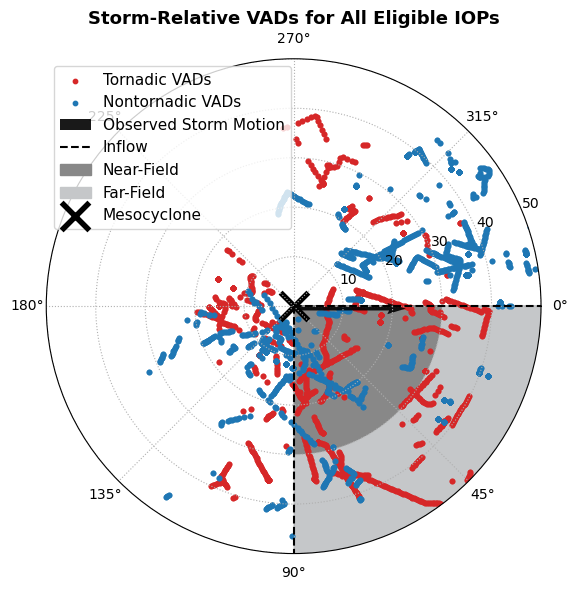

In [121]:
title = 'Storm-Relative VADs for All Eligible IOPs'
polar_plot_color_dots(title, df_all_new)

# Shear mag boxplots

In [ ]:
def tor_boxplot(data_dict, title):
    
    labels = ['NonTor', 'TorAll', 'PreTor', 'DuringTor', 'PostTor']

    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([data_dict['nf_nontor'], data_dict['nf_tor'], data_dict['nf_pretor'], data_dict['nf_dtor'], 
                 data_dict['nf_posttor']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title} Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([data_dict['ff_nontor'], data_dict['ff_tor'], data_dict['ff_pretor'], data_dict['ff_dtor'], 
                 data_dict['ff_posttor']], labels = labels)
    
    ax1.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title} Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot(mag_all_500m, '0-500m Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_500m_new, '0-500m Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_1km, '0-1km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_1km_new, '0-1km Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_2km, '0-2km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_2km_new, '0-2km Shear Magnitude NEW')

# Case Metadata

Per Case

In [ ]:
df_all_new['Tor or Nontor'].value_counts()

In [ ]:
df_all_new['Tor Time'].value_counts()

In [ ]:
df_all_new['NF or FF'].value_counts()

In [ ]:
inflow = df_all_new[(df_all_new['Angle'] <= 90) & (df_all_new['Distance'] <= 50)]
inflow['Tor or Nontor'].value_counts()

In [ ]:
inflow[inflow['NF or FF'] == 'nf']['Tor or Nontor'].value_counts()

In [ ]:
inflow[inflow['NF or FF'] == 'ff']['Tor or Nontor'].value_counts()

In [ ]:
nf = inflow[inflow['Distance'] <= 20]
nf['Tor or Nontor'].value_counts()

In [ ]:
ff = inflow[inflow['Distance'] > 20]
ff['Tor or Nontor'].value_counts()

In [ ]:
east = df_all_new[df_all_new['Angle'] < 46]
east['Tor or Nontor'].value_counts()

In [ ]:
south = df_all_new[(df_all_new['Angle'] > 45) & (df_all_new['Angle'] < 91)]
south['Tor or Nontor'].value_counts()

In [ ]:
df_all_new_copy = df_all_new.copy()



In [ ]:
df_all_new_copy['Tor Time']

In [ ]:
# Group by 'Tor', 'FieldType', and 'Azimuth' and count occurrences
#group_counts = df_all_new.groupby(['Tor or Nontor', 'NF or FF', 'Azimuth']).size().unstack(fill_value=0)
df = df_all_new[(df_all_new['Angle'] < 90) & (df_all_new['Distance'] < 50) ]
group_counts = df.groupby(['Tor Time', 'Date']).size().unstack(fill_value=0)
print(group_counts)

In [ ]:
df_all_new['Tor Time'].value_counts()

In [ ]:
df = df_all_new[(df_all_new['Angle'] < 90)]
tor_time_counts = df['Tor Time'].value_counts().sort_values(ascending=True)
color = ['goldenrod', 'tab:orange', 'tab:red', 'tab:blue']
# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=tor_time_counts.index, y=tor_time_counts.values, palette=color)
for i, v in enumerate(tor_time_counts.values):
    plt.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=13)

# Formatting
plt.title('Counts of Inflow VADs per Tor Time', fontsize=14, fontweight='bold')
plt.xlabel('Tor Time', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
styled_table = group_counts.style.background_gradient(cmap='Blues').set_caption("Counts by Tor Time and Date")
styled_table

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Date'] == d]['Distance'])
    counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Date'] == d]['Angle'])
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
    ax0.set_xlabel('Distance From Meso (km)')
    ax0.set_ylabel('VADs Count')
    ax0.set_title(f'Tornadic Case VADs Count per Distance {d} NEW')
    ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
    ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
    ax1.set_title(f'Case VADs Count per Angle {d} NEW')
    fig.suptitle(f'{d} VADs Distance and Angle Relative to Meso NEW')
    plt.show()

All Cases

In [ ]:
counts_dist, bins_dist = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle')
plt.show()

In [ ]:
counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance (New 2ndTrip)')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle (New 2ndTrip)')
plt.show()

# Temporal SRH and SRW?

In [ ]:
df_all_new['Datetime']

In [ ]:
a = df_all_new.loc[df_all_new['Time From Tor (min)'] == 0]['Datetime'].index[0]

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        plt.plot(df['Datetime'], df['0-2km SRH'])

        tor_ongoing = df[df['Time From Tor (min)'] == 0]
        
        if not tor_ongoing.empty:
            tor_start = tor_ongoing.iloc[0]['Datetime']
            tor_end = tor_ongoing.iloc[-1]['Datetime']
            plt.axvline(tor_start, color='red', linestyle='--')
            plt.axvline(tor_end, color='red', linestyle='--', label='Tor')
        plt.title(f'{d} 0-2km SRH Over Time')
        plt.xlabel('Datetime')
        plt.ylabel('SRH')
        plt.legend()
        plt.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        plt.plot(df['Datetime'], df['0-100m SRH'])

        tor_ongoing = df[df['Time From Tor (min)'] == 0]
        
        if not tor_ongoing.empty:
            tor_start = tor_ongoing.iloc[0]['Datetime']
            tor_end = tor_ongoing.iloc[-1]['Datetime']
            plt.axvline(tor_start, color='red', linestyle='--')
            plt.axvline(tor_end, color='red', linestyle='--', label='Tor')
        plt.title(f'{d} 0-100m SRH Over Time')
        plt.xlabel('Datetime')
        plt.ylabel('SRH')
        plt.legend()
        plt.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH relative to torgen')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW relative to torgen')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW relative to torgen')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df0 = df_all_new[df_all_new['Date'] == d]
        df = df0[df0['Time From Tor (min)'] == 0]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW During Tor')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df0 = df_all_new[df_all_new['Date'] == d]
        df = df0[df0['Time From Tor (min)'] > 0]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW Pre Tor')
        p.show()

In [ ]:
df_all_new

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
col = 'SFC SRW Mag'
n = 10

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            # ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            # ax0.set_ylabel(col)
            # ax0.set_xlabel('Time (UTC)')
            # plt.suptitle(f'{d} {col} Tor')
            
            #df = df_all_new[df_all_new['Date'] == d]
            fig, (ax0, ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=4, figsize=(16,4))
            #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
            ax0.plot(df['Datetime'], df['SFC SRW Mag'])
            #ax0.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax0.set_title('SFC SRW Mag')
        
            ax1.plot(df['Datetime'], df['0-500m SRW Mag'])
            #ax1.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax1.set_title('0-500m SRW Mag')
        
            ax2.plot(df['Datetime'], df['0-1km SRW Mag'])
            #ax2.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax2.set_title('0-1km SRW Mag')
        
            ax3.plot(df['Datetime'], df['0-2km SRW Mag'])
            ax3.set_title('0-2km SRW Mag')
            #ax3.xticks(df['Datetime'][::20], rotation=45, ha='right')
            #plt.setp(plot.axes.get_xticklabels(), visible=False)
            #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)

            ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            ax0.set_ylabel('SRW')
            ax0.set_xlabel('Time (UTC)')

            ax1.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax1.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            ax3.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax3.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            plt.suptitle(f'{d} {col} Tor')

            plt.show()
            
        # if not df[df['Time From Tor (min)'] == 0].empty:
        #     tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
        #     #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
        #     tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
        #     #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
        #     plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
        #     plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
        #     plt.ylabel(col)
        #     plt.xlabel('Time (UTC)')
        #     plt.title(f'{d} {col} Tor')
            
        #     plt.show()
            
        # else:
        #     plt.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
n = 10

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            # ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            # ax0.set_ylabel(col)
            # ax0.set_xlabel('Time (UTC)')
            # plt.suptitle(f'{d} {col} Tor')
            
            #df = df_all_new[df_all_new['Date'] == d]
            fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, figsize=(16,4))
            #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
            ax0.plot(df['Datetime'], df['0-500m SRH'])
            #ax0.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax0.set_title('0-500m SRH')
        
            ax1.plot(df['Datetime'], df['0-1km SRH'])
            #ax1.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax1.set_title('0-1km SRH')
        
            ax2.plot(df['Datetime'], df['0-2km SRH'])
            #ax2.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax2.set_title('0-2km SRH')
        
            # ax3.plot(df['Datetime'], df['0-2km SRW Mag'])
            # ax3.set_title('0-2km SRW Mag')
            #ax3.xticks(df['Datetime'][::20], rotation=45, ha='right')
            #plt.setp(plot.axes.get_xticklabels(), visible=False)
            #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)

            ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            ax0.set_ylabel('SRH')
            ax0.set_xlabel('Time (UTC)')

            ax1.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax1.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            # ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            # ax3.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax3.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            plt.suptitle(f'{d} SRH Over Time')

            plt.show()
            
        # if not df[df['Time From Tor (min)'] == 0].empty:
        #     tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
        #     #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
        #     tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
        #     #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
        #     plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
        #     plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
        #     plt.ylabel(col)
        #     plt.xlabel('Time (UTC)')
        #     plt.title(f'{d} {col} Tor')
            
        #     plt.show()
            
        # else:
        #     plt.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
col = '0-500m SRW Mag'
n = 10
for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
        plot = plt.plot(df['Datetime'], df[col])
        plt.xticks(df['Datetime'][::20], rotation=45, ha='right')
        #plt.setp(plot.axes.get_xticklabels(), visible=False)
        #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            plt.ylabel(col)
            plt.xlabel('Time (UTC)')
            plt.title(f'{d} {col} Tor')
            
            plt.show()
            
        else:
            plt.show()

# Mesocyclone strength

In [129]:
def meso_stats_get(meso_stats, features_shear_xr, d, meso_id, df_all_new):
    meso_max = []
    dates = []
    if not isinstance(meso_id, (list, set)):
        meso_id = [meso_id]
        
        meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)
    
    meso_ids = meso_indeces.index
    
    if not isinstance(meso_ids, (list, set)):
        meso_ids = [meso_ids]
        
        meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)
    
    meso_ids_stats = meso_indeces2.index

    nearest_vad_time_idx = []
    
    df_all_new_date = df_all_new[df_all_new['Date'] == d]

    #df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    
    for i in df_all_new_date['Datetime']:
        timet = meso_stats['time'].to_pandas()    
        time = pd.to_datetime(timet)
        dt_df = pd.Series(i)
        dta = pd.to_datetime(dt_df)
        dt = np.array(dta)
        nearest_vad_time = find_nearest(time, dt)
        nearest_vad_time_idx.append(nearest_vad_time)

    # timet = meso_stats['time'].to_pandas()
    # for i in timet:
    #     #timet = meso_stats['time'].to_pandas()
    #     # for t in timet:
    #     #     t0 = datetime.strptime(t, '%Y-%m-%d %H:%M:%S')
    #     #     t1 = np.array(t0)
    #     #     t2 = t1.astype('datetime64[ns]')
            
    #     #time = pd.to_datetime(i)
    #     #dt = datetime.fromtimestamp(dt_ts)
    #     #dt = to_dt[i]
    #     #dt_strp = datetime.strptime(i, '%Y-%m-%d %H:%M:%S')
    #     #dt_array = np.array(dt_strp)
    #     #dt = dt_array.astype('datetime64[ns]')
    #     time_df = pd.Series(i)
    #     timea = pd.to_datetime(time_df)
    #     time = np.array(timea)
    #     #dta = pd.to_datetime(dt_df)
    #     #dt = np.array(dta)
    #     df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    #     #print(f'i dtype: {dt.dtype}')
    #     #print((df_datetime).dtype)
    #     #print(f'time dtype: {(time).dtype}')
        
    #     #print(f'time shape:{np.shape(time)}')
    #     #print(f'i shape:{np.shape(dt)}')
    #     nearest_vad_time = find_nearest(df_datetime, time)
        #nearest_vad_time_idx.append(nearest_vad_time)
    
    wanted_meso_max = meso_stats['max'][meso_ids_stats].values
    meso_max.append(wanted_meso_max)
    wanted_meso_max_nearest = meso_stats['max'][nearest_vad_time_idx].values
    dates.append(d)

    time = meso_stats['time'][nearest_vad_time_idx]

    fig = plt.figure()
    plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
    plt.title(f'Maximum Azimuthal Shear Over Time Of Target Mesocyclones {d}')
    plt.xlabel('Time')
    plt.ylabel('Azshear')
    plt.show()

    return wanted_meso_max_nearest, dates, time

In [130]:
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
          '20240523', '20240528', '20240602']

In [131]:
meso_ids_dict = {
    
    '20220523': [8, 24, 44, 10, 26],
    '20220524': [1, 11],
    '20220611': [9, 18, 59, 119, 186, 236, 289, 427],
    '20230524': [8, 27],
    '20230527': [8,16, 36, 57],
    '20230601': [3, 5],
    '20230609': [1, 13, 15],
    '20230611': [13, 27, 43,55, 80, 82, 84, 145, 162],
    '20230612': [21, 32, 81, 106, 136],
    '20230613': [1],
    '20230615': [201, 481, 749, 1178],
    '20240427': [15, 191, 506],
    '20240501': [1, 4, 6, 11, 15],
    '20240502': [1, 23, 38, 58],
    '20240504': [15, 192, 224, 311],
    '20240519': [3, 9, 12, 27, 29, 43],
    '20240523': [1, 10, 17, 20],
    '20240528': [49, 194, 237, 308],
    '20240602': [1, 5, 8]
}
    


20220523
[ 8 24 44 10 26]


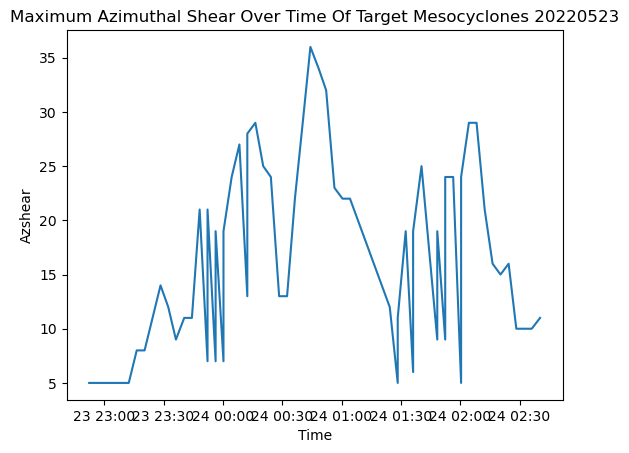

(140,)
(140,)
20220524
[ 1 11]


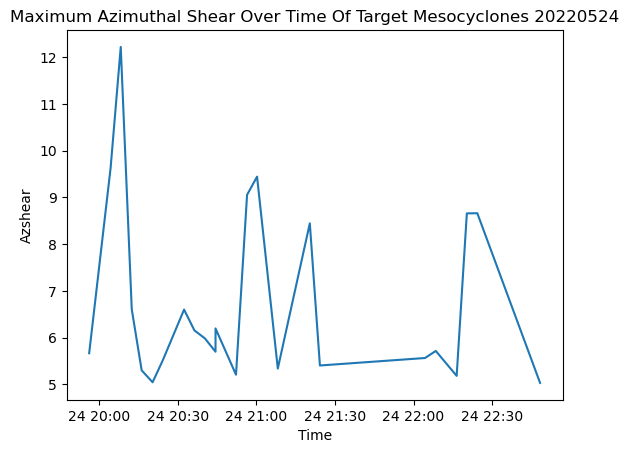

(100,)
(100,)
20220611
[  9  18  59 119 186 236 289 427]


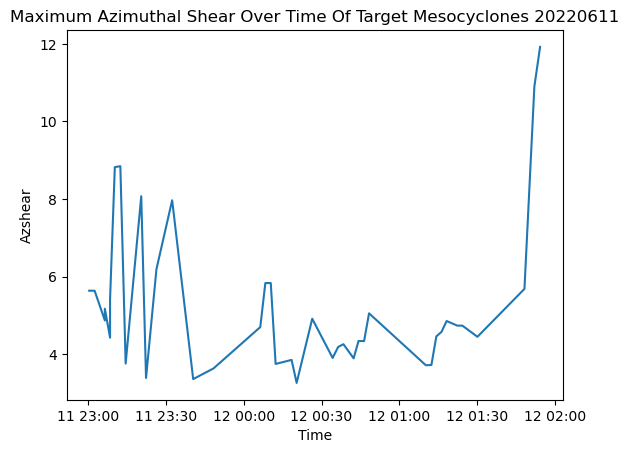

(0,)
(0,)
20230524
[ 8 27]


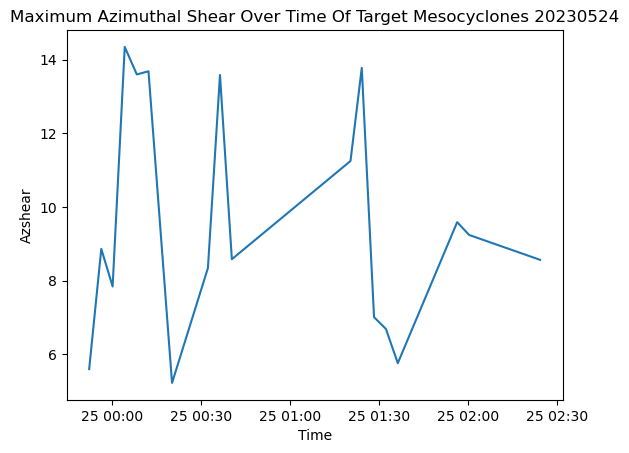

(284,)
(284,)
20230527
[ 8 16 36 57]


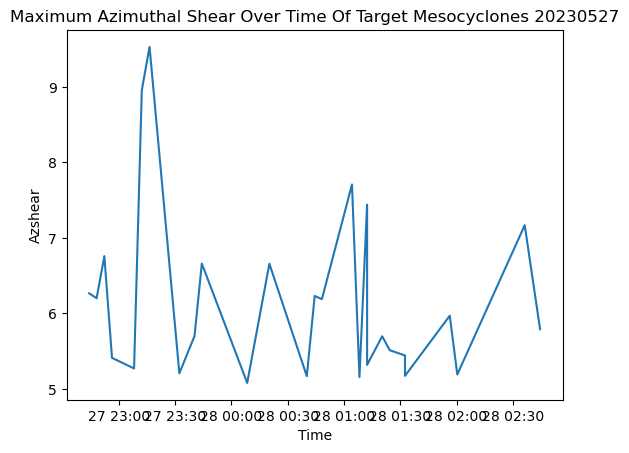

(506,)
(506,)
20230601
[3 5]


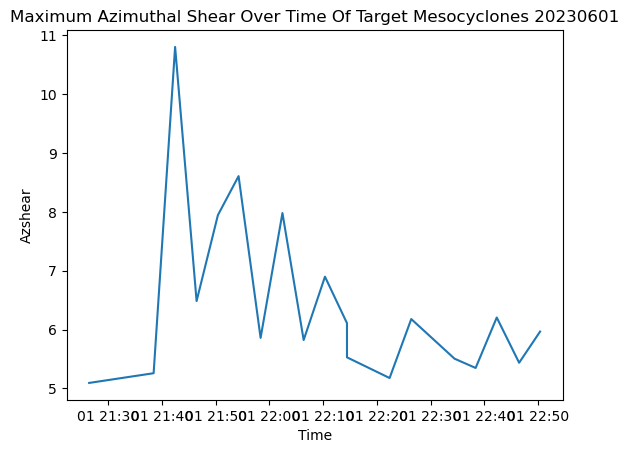

(0,)
(0,)
20230609
[ 1 13 15]


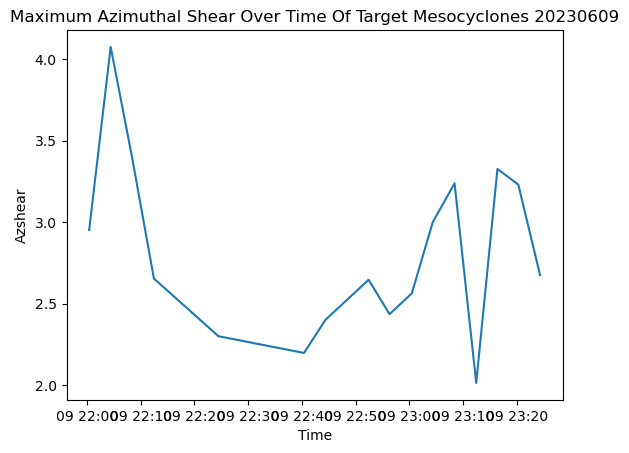

(0,)
(0,)
20230611
[ 13  27  43  55  80  82  84 145 162]


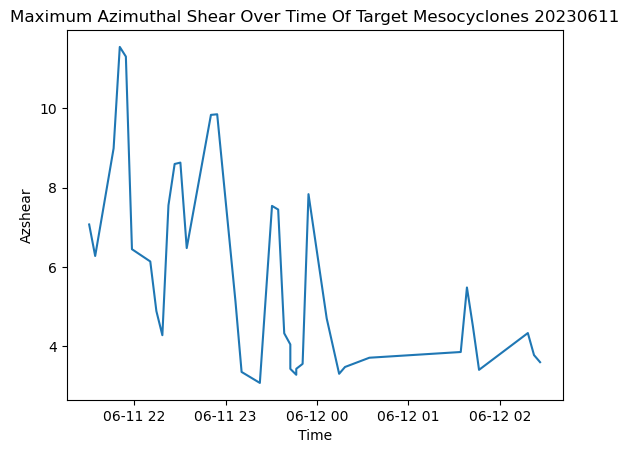

(388,)
(388,)
20230612
[ 21  32  81 106 136]


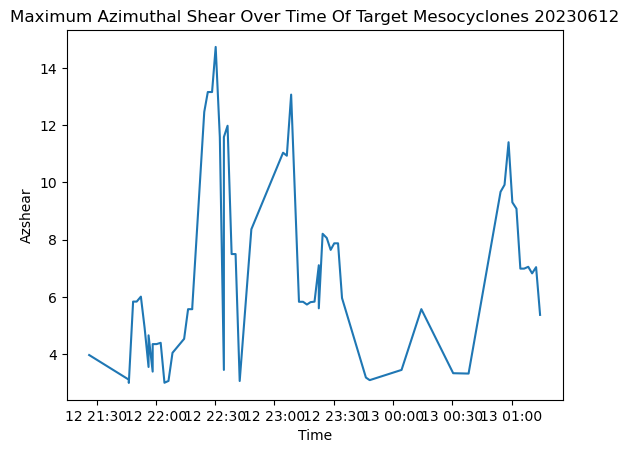

(198,)
(198,)
20230613
[1]


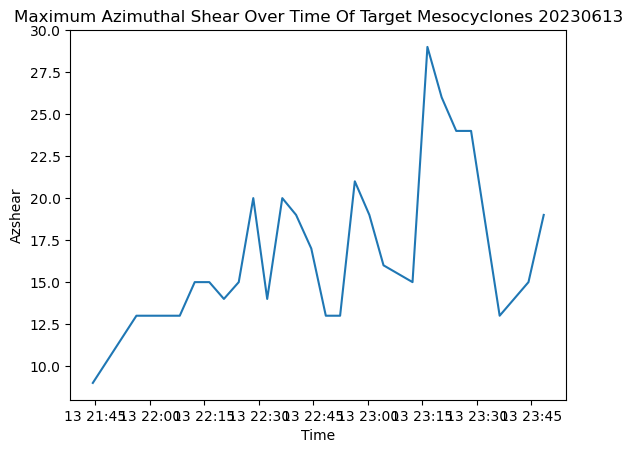

(20,)
(20,)
20230615
[ 201  481  749 1178]


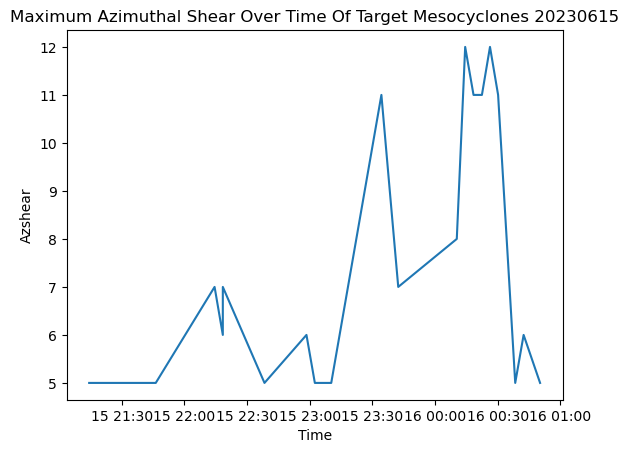

(924,)
(924,)
20240427
[ 15 191 506]


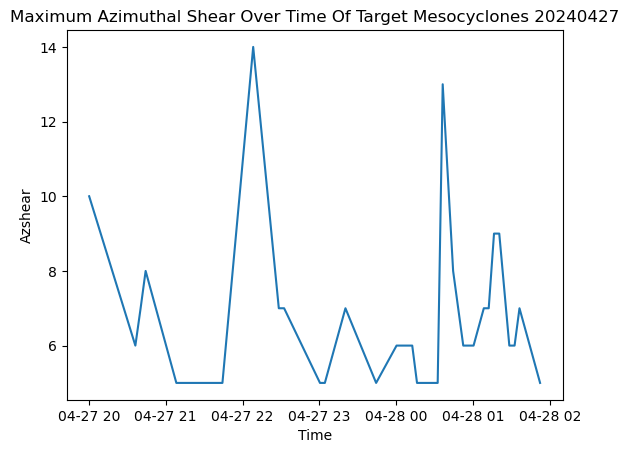

(314,)
(314,)
20240501
[ 1  4  6 11 15]


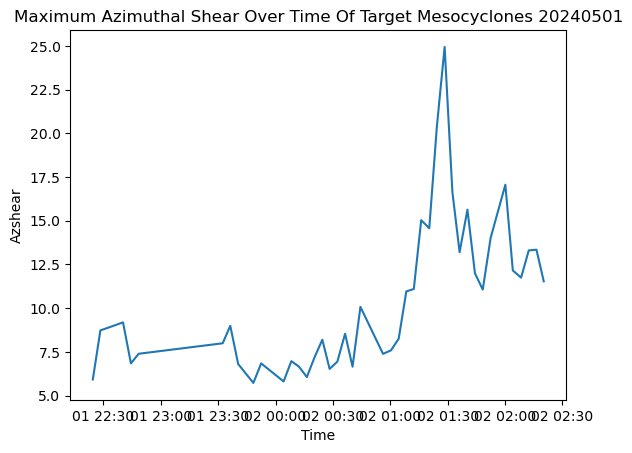

(850,)
(850,)
20240502
[ 1 23 38 58]


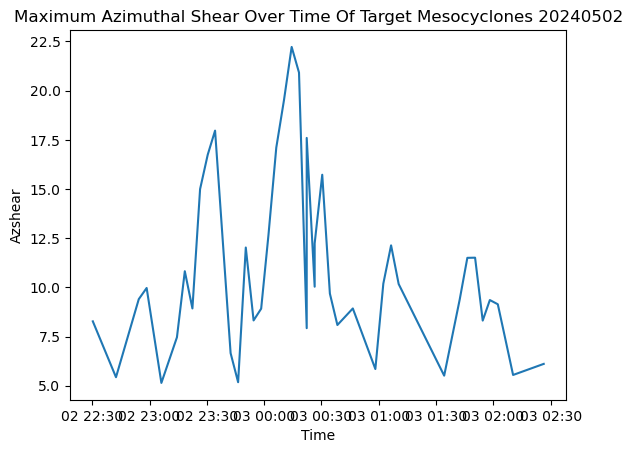

(0,)
(0,)
20240504
[ 15 192 224 311]


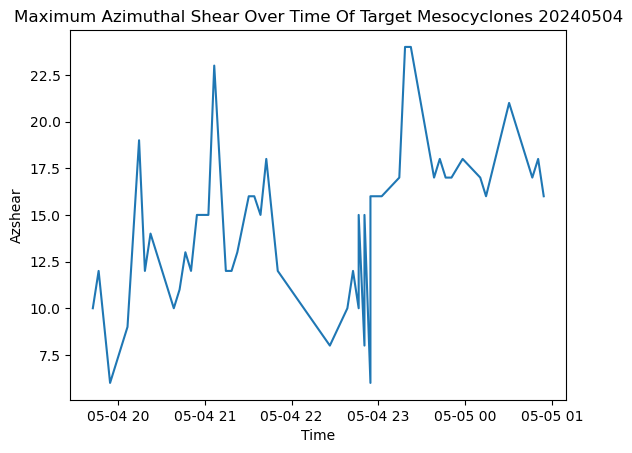

(0,)
(0,)
20240519
[ 3  9 12 27 29 43]


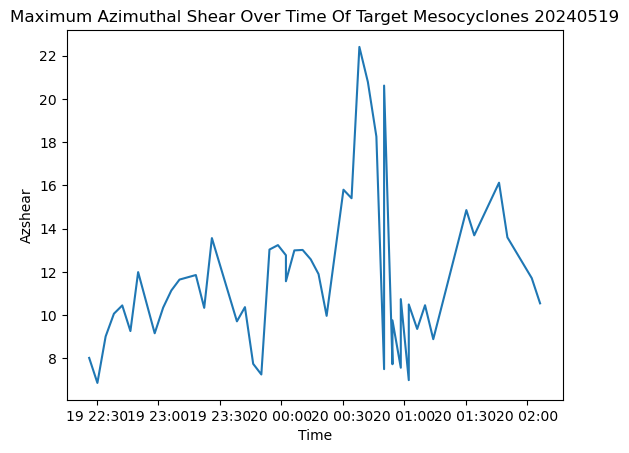

(0,)
(0,)
20240523
[ 1 10 17 20]


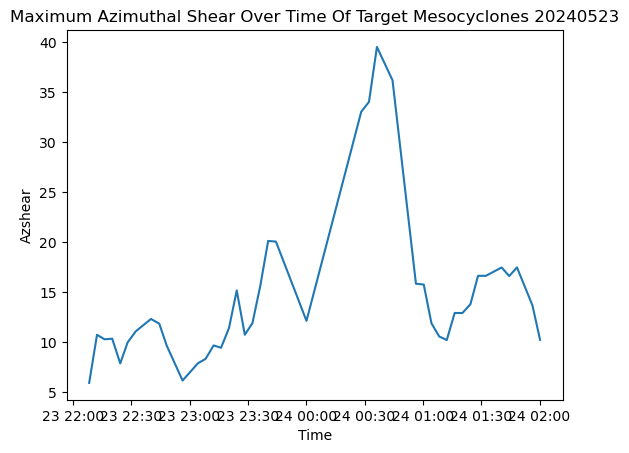

(0,)
(0,)
20240528
[ 49 194 237 308]


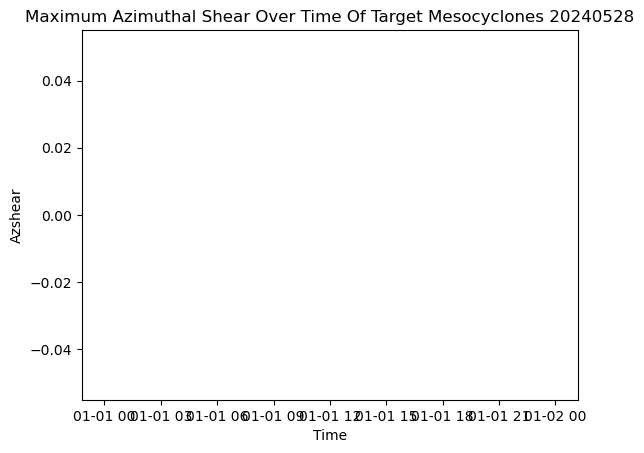

(1050,)
(1050,)
20240602
[1 5 8]


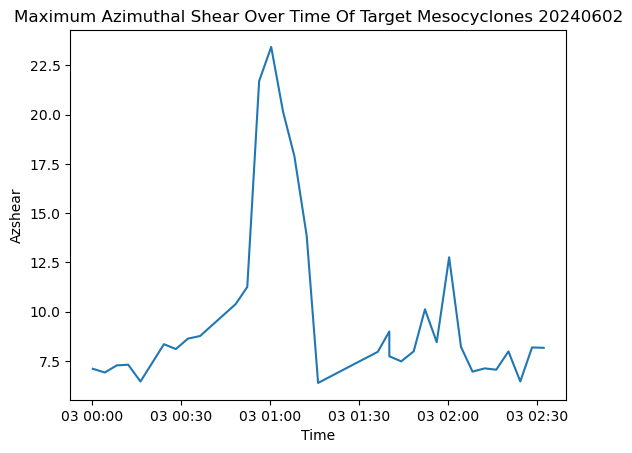

(262,)
(262,)


In [132]:
meso_azshear_df = pd.DataFrame()

for key in meso_ids_dict:
    d = key
    print(d)
    meso_id = np.array(meso_ids_dict[d])
    print(meso_id)
    meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')
    tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')
    # tobac_df_shear = tobac_id(tobac_features_xr_shear, meso_id)
    # latitude_weighted_tobac_meso, longitude_weighted_tobac_meso, meso_bearing, meso_speed, meso_times = storm_speed_and_bearing(tobac_df_shear, weights)
    # meso_vad_times, meso_times, meso_indeces, meso_lats, meso_lons = nearest_tobac_time(easterlies_vads, 
    #                                                                            np.array(latitude_weighted_tobac_meso),
    #                                                                            np.array(longitude_weighted_tobac_meso),
    #                                                                            meso_times[:-1])
    meso_max, dates, time = meso_stats_get(meso_stats, tobac_features_xr_shear, d, meso_id, df_all_new)

    df = pd.DataFrame()
    df['Time'] = time
    print(np.shape(time))
    df['Meso_Max'] = pd.Series(np.array(meso_max).flatten())
    print(np.shape(df['Meso_Max']))
    df['Date'] = dates * np.size(df['Meso_Max'])

    meso_azshear_df = pd.concat([meso_azshear_df, df], ignore_index=True)

In [ ]:
meso_azshear_df

In [133]:
df_all_new['Meso Max'] = meso_azshear_df['Meso_Max']

In [ ]:
df_all_new

In [ ]:
meso_azshear_df['Date'].value_counts()

In [ ]:
df_all_new['Date'].value_counts()

In [ ]:
meso_ids_dict

In [ ]:
df_all_new['0-2km SRH']

In [ ]:
        timet = meso_stats['time'].to_pandas()    
        time = pd.to_datetime(timet)
        dt_df = pd.Series(i)
        dta = pd.to_datetime(dt_df)
        dt = np.array(dta)
        nearest_vad_time = find_nearest(time, dt)
        nearest_vad_time_idx.append(nearest_vad_time)

In [ ]:
df_copy['Datetime Int']

In [ ]:
df_copy = df_all_new.copy()
df_copy['Datetime Int'] = pd.to_datetime(df_all_new['Datetime'])

In [ ]:
df_copy = df_all_new.copy()
df_copy['Datetime Int'] = pd.to_datetime(df_all_new['Datetime'])

for d in sorted(set(df_copy['Date'])):
    df = df_copy[df_copy['Date'] == d]
    fig, ax = plt.subplots(2,1, figsize= (10,6))
    ax[0].plot(np.array(df['Datetime Int']), df['Meso Max'])
    ax[1].plot(np.array(df['Datetime Int']), df['0-1km SRH'].values)
    ax[0].set_title('Meso Max')
    ax[1].set_title('0-1km SRH')
    plt.suptitle(f'{d} Meso Max')
    fig.tight_layout()
    plt.show()

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30
for d in sorted(set(meso_azshear_df['Date'])):
    
    col = '0'
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

    df_all_new_d = df_all_new[df_all_new['Date'] == d]
    #df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    u = df_all_new_d[df_all_new_d['u or v'] == 'u']
    v = df_all_new_d[df_all_new_d['u or v'] == 'v']

    print(f'u shape: {np.shape(u)}')

    meso_d = meso_azshear_df[meso_azshear_df['Date'] == d]
    meso_max = meso_d['Meso_Max']
    
    print(f' meso shape: {np.shape(meso_max)}')
    
    # Compute wind speed
    ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
    tspeed = np.sqrt(ta)
    
    # Get Py-ART colormap
    #cmap = pyart.graph.cm.pyart_BuDRd18
    
    # Normalize speed for colormap (adjust vmin/vmax as needed)
    norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
    sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
    tcolors = sm.to_rgba(tspeed)
    # Tornadic points
    points = ax0.barbs(u['Angle'][::10] * (np.pi/180), u['Distance'][::10], 
                              u[col][::10], v[col][::10], meso_d['Meso_Max'][::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

    if df_all_new_d['Time From Tor (min)'].ne('nontor').any():
        ax0.set_title(f'All Tor {d} Per VAD')

    else:
        ax0.set_title(f'All NonTor {d} Per VAD')
    
    # ax1.set_rlabel_position(-22.5)
    # ax1.grid(True, linestyle=':')
    # # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    # ax1.set_theta_zero_location('E')
    # ax1.set_theta_direction(-1)
    # ax1.set_ylim([0, max_radius])
    # # Shade regions
    # nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    # ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    # df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    # nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
    # nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']
    
    # # Compute wind speed
    # nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
    # ntspeed = np.sqrt(nta)
    
    # nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
    #                          nt_u[col][::10], nt_v[col][::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    # ax1.set_title(f'All Nontor {col} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    # ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    # ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label('Meso AzShear (s$^{-1})$')
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    #plt.tight_layout()
    plt.suptitle('SFC SRW Every 10 points')
    plt.show()